In [ ]:
# ============================================================
# CIAS + SSRA + MULTIMODAL (FAST/MEDIUM-QUALITY COLAB VERSION)
# Raw videos -> pose-based crops -> frozen embeddings -> CIAS+SSRA test
# ------------------------------------------------------------
# What this code does:
# 1) Downloads first 50 BEAT videos using your exact HF logic
# 2) Extracts lightweight face/body features from sampled frames
# 3) Builds positive/negative multimodal pairs (self-supervised congruence proxy)
# 4) Trains CIAS + SSRA model
# 5) Reports held-out AUC / AP / Accuracy / F1
#

import os
import cv2
import json
import math
import copy
import time
import shutil
import random
import warnings
from dataclasses import dataclass, asdict
from typing import List, Tuple, Dict, Optional

import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, f1_score

warnings.filterwarnings("ignore")

# =========================
# 2) Config

@dataclass
class CFG:
    # ---------- paths ----------
    out_vid_dir: str = "/content/BEAT_video"
    cache_path: str = "/content/cias_ssra_cache_fast.npz"
    work_dir: str = "/content/cias_ssra_runs"
    best_model_path: str = "/content/cias_ssra_runs/best_cias_ssra.pt"
    last_model_path: str = "/content/cias_ssra_runs/last_cias_ssra.pt"
    metrics_path: str = "/content/cias_ssra_runs/metrics.json"
    pred_path: str = "/content/cias_ssra_runs/test_predictions.npz"

    # ---------- download ----------
    repo_id: str = "H-Liu1997/BEAT_Rendered_Videos"
    n_videos: int = 50

    # ---------- reproducibility ----------
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    use_amp: bool = True


    segments_per_video: int = 4
    frames_per_segment: int = 3
    yolo_imgsz: int = 320
    pose_conf: float = 0.25
    keypoint_conf: float = 0.25
    crop_size: int = 96
    embed_input_size: int = 160   # smaller than 224 -> faster, small quality drop
    feature_batch_size: int = 64

    # ---------- dataset ----------
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    neg_per_pos_train: int = 2
    neg_per_pos_eval: int = 1

    # ---------- model ----------
    feat_dim: int = 512
    hidden_dim: int = 256
    latent_dim: int = 128
    ssra_steps: int = 2
    dropout: float = 0.15

    # ---------- training ----------
    batch_size: int = 128
    num_workers: int = 2
    lr: float = 2e-4
    weight_decay: float = 1e-4
    epochs: int = 18
    early_stop_patience: int = 5
    grad_clip: float = 1.0

    # ---------- losses ----------
    w_bce: float = 1.0
    w_pos_align: float = 0.20
    w_refine_reg: float = 0.02

    # ---------- misc ----------
    save_cache_every_video: bool = False

cfg = CFG()
os.makedirs(cfg.out_vid_dir, exist_ok=True)
os.makedirs(cfg.work_dir, exist_ok=True)

# =========================
# 3) Utils
# =========================
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)
print("device:", cfg.device)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def ensure_dir(p):
    os.makedirs(p, exist_ok=True)


def clip_box(x1, y1, x2, y2, w, h):
    x1 = int(max(0, min(w - 1, x1)))
    y1 = int(max(0, min(h - 1, y1)))
    x2 = int(max(0, min(w, x2)))
    y2 = int(max(0, min(h, y2)))
    if x2 <= x1 or y2 <= y1:
        return None
    return x1, y1, x2, y2


def expand_xyxy(box, scale, img_w, img_h):
    x1, y1, x2, y2 = box
    cx = 0.5 * (x1 + x2)
    cy = 0.5 * (y1 + y2)
    bw = (x2 - x1) * scale
    bh = (y2 - y1) * scale
    return clip_box(cx - bw / 2, cy - bh / 2, cx + bw / 2, cy + bh / 2, img_w, img_h)


# =========================
# 4) Download videos (your exact logic)
# =========================
def download_videos(cfg: CFG):
    from huggingface_hub import HfApi, hf_hub_download

    repo_id = cfg.repo_id
    api = HfApi()
    os.makedirs(cfg.out_vid_dir, exist_ok=True)

    existing = sorted([os.path.join(cfg.out_vid_dir, f) for f in os.listdir(cfg.out_vid_dir) if f.lower().endswith(".mp4")])
    if len(existing) >= cfg.n_videos:
        print(f"Videos already present: {len(existing)}")
        return existing[:cfg.n_videos]

    files = api.list_repo_files(repo_id=repo_id, repo_type="dataset")
    mp4_files = sorted([f for f in files if f.lower().endswith(".mp4")])

    print("Total mp4 in repo:", len(mp4_files))
    mp4_files = mp4_files[:cfg.n_videos]

    saved = []
    for i, f in enumerate(tqdm(mp4_files, desc="Downloading videos")):
        local = hf_hub_download(repo_id=repo_id, repo_type="dataset", filename=f)
        dst = os.path.join(cfg.out_vid_dir, f"{i:05d}.mp4")
        if not os.path.exists(dst):
            shutil.copy(local, dst)
        saved.append(dst)

    print("Saved:", len(saved), "to", cfg.out_vid_dir)
    if len(saved) > 0:
        print("Example:", saved[0])
    return saved


# =========================
# 5) Models for feature extraction
# =========================
class FrozenResNet18(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()
        for p in backbone.parameters():
            p.requires_grad = False
        self.backbone = backbone.eval()
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1), persistent=False)
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1), persistent=False)

    def forward(self, x):
        x = x.float() / 255.0
        x = F.interpolate(x, size=(cfg.embed_input_size, cfg.embed_input_size), mode="bilinear", align_corners=False)
        x = (x - self.mean) / self.std
        feat = self.backbone(x)
        feat = F.normalize(feat, dim=-1)
        return feat


# =========================
# 6) Frame sampling and crops
# =========================
def get_segment_frame_indices(total_frames: int, segments_per_video: int, frames_per_segment: int):
    if total_frames <= 0:
        return []

    bounds = np.linspace(0, max(1, total_frames - 1), segments_per_video + 1).astype(int)
    all_segments = []
    for s in range(segments_per_video):
        a = int(bounds[s])
        b = int(bounds[s + 1])
        if b <= a:
            b = min(total_frames - 1, a + 1)
        segment_len = max(1, b - a)
        if segment_len <= frames_per_segment:
            idxs = np.linspace(a, max(a, b - 1), segment_len).astype(int).tolist()
        else:
            idxs = np.linspace(a, b - 1, frames_per_segment).astype(int).tolist()
        all_segments.append(idxs)
    return all_segments


def read_frame(cap, frame_idx: int):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    if not ok:
        return None
    return frame


def get_best_person_from_result(result):
    if result is None or result.boxes is None or result.keypoints is None:
        return None
    if len(result.boxes) == 0:
        return None

    boxes_xyxy = result.boxes.xyxy.detach().cpu().numpy()
    boxes_conf = result.boxes.conf.detach().cpu().numpy() if result.boxes.conf is not None else np.ones(len(boxes_xyxy), dtype=np.float32)
    best_idx = int(np.argmax(boxes_conf))

    kpts_xy = result.keypoints.xy.detach().cpu().numpy()[best_idx]
    if result.keypoints.conf is not None:
        kpts_conf = result.keypoints.conf.detach().cpu().numpy()[best_idx]
    else:
        kpts_conf = np.ones(len(kpts_xy), dtype=np.float32)

    return boxes_xyxy[best_idx], kpts_xy, kpts_conf


def make_face_body_crops(frame_bgr, pose_model, cfg: CFG):
    h, w = frame_bgr.shape[:2]
    try:
        result = pose_model.predict(
            source=frame_bgr,
            imgsz=cfg.yolo_imgsz,
            conf=cfg.pose_conf,
            verbose=False,
            device=cfg.device,
            max_det=1,
        )[0]
    except Exception:
        return None, None

    best = get_best_person_from_result(result)
    if best is None:
        return None, None

    body_box, kpts_xy, kpts_conf = best
    body_box = expand_xyxy(body_box, scale=1.08, img_w=w, img_h=h)
    if body_box is None:
        return None, None

    # head keypoints in COCO order: 0 nose, 1 left_eye, 2 right_eye, 3 left_ear, 4 right_ear
    head_pts = []
    for idx in [0, 1, 2, 3, 4]:
        x, y = kpts_xy[idx]
        c = kpts_conf[idx]
        if c >= cfg.keypoint_conf and x > 1 and y > 1:
            head_pts.append([x, y])

    if len(head_pts) >= 2:
        head_pts = np.asarray(head_pts, dtype=np.float32)
        x1, y1 = head_pts.min(axis=0)
        x2, y2 = head_pts.max(axis=0)
        size = max(x2 - x1, y2 - y1, 12.0) * 2.2
        cx = 0.5 * (x1 + x2)
        cy = 0.5 * (y1 + y2)
        face_box = clip_box(cx - size / 2, cy - 0.60 * size, cx + size / 2, cy + 0.80 * size, w, h)
    else:
        bx1, by1, bx2, by2 = body_box
        bh = by2 - by1
        face_box = clip_box(bx1, by1, bx2, by1 + 0.38 * bh, w, h)

    if face_box is None:
        return None, None

    bx1, by1, bx2, by2 = body_box
    fx1, fy1, fx2, fy2 = face_box

    body_crop = frame_bgr[by1:by2, bx1:bx2]
    face_crop = frame_bgr[fy1:fy2, fx1:fx2]

    if body_crop.size == 0 or face_crop.size == 0:
        return None, None

    face_crop = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
    body_crop = cv2.cvtColor(body_crop, cv2.COLOR_BGR2RGB)
    face_crop = cv2.resize(face_crop, (cfg.crop_size, cfg.crop_size), interpolation=cv2.INTER_AREA)
    body_crop = cv2.resize(body_crop, (cfg.crop_size, cfg.crop_size), interpolation=cv2.INTER_AREA)
    return face_crop, body_crop


# =========================
# 7) Feature extraction cache
# =========================
def batch_extract_embeddings(crops_rgb: List[np.ndarray], backbone: FrozenResNet18, device: str, batch_size: int):
    if len(crops_rgb) == 0:
        return np.zeros((0, cfg.feat_dim), dtype=np.float32)

    feats = []
    backbone.eval()
    with torch.inference_mode():
        for i in range(0, len(crops_rgb), batch_size):
            batch = np.stack(crops_rgb[i:i + batch_size], axis=0)
            x = torch.from_numpy(batch).permute(0, 3, 1, 2).contiguous().to(device)
            use_amp = (cfg.use_amp and device.startswith("cuda"))
            with torch.autocast(device_type="cuda", enabled=use_amp):
                f = backbone(x)
            feats.append(f.float().cpu().numpy())
    return np.concatenate(feats, axis=0)


def extract_or_load_cache(video_paths: List[str], cfg: CFG):
    if os.path.exists(cfg.cache_path):
        print("Loading cache:", cfg.cache_path)
        data = np.load(cfg.cache_path, allow_pickle=True)
        return {
            "face": data["face"].astype(np.float32),
            "body": data["body"].astype(np.float32),
            "video_id": data["video_id"].astype(np.int32),
            "segment_id": data["segment_id"].astype(np.int32),
            "video_path": data["video_path"],
        }

    from ultralytics import YOLO

    print("Building cache from videos...")
    pose_model = YOLO("yolov8n-pose.pt")
    pose_model.to(cfg.device)

    backbone = FrozenResNet18().to(cfg.device).eval()

    all_face_feats = []
    all_body_feats = []
    all_video_ids = []
    all_segment_ids = []
    all_video_paths = []

    valid_video_counter = 0

    for vid_idx, video_path in enumerate(tqdm(video_paths, desc="Videos -> cache")):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            continue

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        seg_to_indices = get_segment_frame_indices(total_frames, cfg.segments_per_video, cfg.frames_per_segment)
        if len(seg_to_indices) == 0:
            cap.release()
            continue

        video_face_feats = []
        video_body_feats = []
        video_seg_ids = []

        for seg_id, idx_list in enumerate(seg_to_indices):
            face_crops = []
            body_crops = []

            for frame_idx in idx_list:
                frame = read_frame(cap, frame_idx)
                if frame is None:
                    continue
                face_crop, body_crop = make_face_body_crops(frame, pose_model, cfg)
                if face_crop is None or body_crop is None:
                    continue
                face_crops.append(face_crop)
                body_crops.append(body_crop)

            if len(face_crops) == 0 or len(body_crops) == 0:
                continue

            face_emb = batch_extract_embeddings(face_crops, backbone, cfg.device, cfg.feature_batch_size)
            body_emb = batch_extract_embeddings(body_crops, backbone, cfg.device, cfg.feature_batch_size)

            if len(face_emb) == 0 or len(body_emb) == 0:
                continue

            face_feat = face_emb.mean(axis=0)
            body_feat = body_emb.mean(axis=0)
            face_feat = face_feat / (np.linalg.norm(face_feat) + 1e-8)
            body_feat = body_feat / (np.linalg.norm(body_feat) + 1e-8)

            video_face_feats.append(face_feat.astype(np.float32))
            video_body_feats.append(body_feat.astype(np.float32))
            video_seg_ids.append(seg_id)

        cap.release()

        if len(video_face_feats) == 0:
            continue

        valid_video_counter += 1
        for j in range(len(video_face_feats)):
            all_face_feats.append(video_face_feats[j])
            all_body_feats.append(video_body_feats[j])
            all_video_ids.append(valid_video_counter - 1)
            all_segment_ids.append(video_seg_ids[j])
            all_video_paths.append(video_path)

        if cfg.device.startswith("cuda"):
            torch.cuda.empty_cache()

    face = np.asarray(all_face_feats, dtype=np.float16)
    body = np.asarray(all_body_feats, dtype=np.float16)
    video_id = np.asarray(all_video_ids, dtype=np.int32)
    segment_id = np.asarray(all_segment_ids, dtype=np.int32)
    video_path = np.asarray(all_video_paths, dtype=object)

    np.savez_compressed(
        cfg.cache_path,
        face=face,
        body=body,
        video_id=video_id,
        segment_id=segment_id,
        video_path=video_path,
    )
    print("Cache saved:", cfg.cache_path)
    print("Valid cached segments:", len(face), "| valid videos:", len(np.unique(video_id)))

    return {
        "face": face.astype(np.float32),
        "body": body.astype(np.float32),
        "video_id": video_id,
        "segment_id": segment_id,
        "video_path": video_path,
    }


# =========================
# 8) Build train/val/test splits by video
# =========================
def split_by_video(video_ids: np.ndarray, cfg: CFG):
    uniq = np.unique(video_ids)
    rng = np.random.RandomState(cfg.seed)
    rng.shuffle(uniq)

    n = len(uniq)
    n_test = max(1, int(round(n * cfg.test_ratio)))
    n_val = max(1, int(round(n * cfg.val_ratio)))
    n_train = max(1, n - n_val - n_test)

    train_v = uniq[:n_train]
    val_v = uniq[n_train:n_train + n_val]
    test_v = uniq[n_train + n_val:]

    return set(train_v.tolist()), set(val_v.tolist()), set(test_v.tolist())


def subset_indices_by_video(video_ids: np.ndarray, chosen_set: set):
    idx = [i for i, v in enumerate(video_ids.tolist()) if v in chosen_set]
    return np.asarray(idx, dtype=np.int64)


# =========================
# 9) Pair dataset
# =========================
class PairDataset(Dataset):
    def __init__(self, face_pairs, body_pairs, labels, face_src_idx, body_src_idx):
        self.face_pairs = torch.tensor(face_pairs, dtype=torch.float32)
        self.body_pairs = torch.tensor(body_pairs, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.face_src_idx = np.asarray(face_src_idx)
        self.body_src_idx = np.asarray(body_src_idx)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "face": self.face_pairs[idx],
            "body": self.body_pairs[idx],
            "label": self.labels[idx],
            "face_src_idx": int(self.face_src_idx[idx]),
            "body_src_idx": int(self.body_src_idx[idx]),
        }


def build_pairs(face_feats, body_feats, video_ids, indices, neg_per_pos=1, seed=42):
    rng = np.random.RandomState(seed)
    idxs = np.asarray(indices, dtype=np.int64)
    if len(idxs) == 0:
        raise RuntimeError("Empty subset for pair building.")

    face_pairs = []
    body_pairs = []
    labels = []
    face_src_idx = []
    body_src_idx = []

    # positive pairs
    for i in idxs:
        face_pairs.append(face_feats[i])
        body_pairs.append(body_feats[i])
        labels.append(1.0)
        face_src_idx.append(int(i))
        body_src_idx.append(int(i))

    # negative pairs: same face, body from another video
    id_to_vid = {int(i): int(video_ids[i]) for i in idxs}
    by_vid = {}
    for i in idxs:
        by_vid.setdefault(int(video_ids[i]), []).append(int(i))

    other_pool = idxs.tolist()
    for i in idxs:
        current_vid = id_to_vid[int(i)]
        candidate = [j for j in other_pool if id_to_vid[int(j)] != current_vid]
        if len(candidate) == 0:
            continue
        chosen = rng.choice(candidate, size=min(neg_per_pos, len(candidate)), replace=False)
        for j in chosen.tolist():
            face_pairs.append(face_feats[i])
            body_pairs.append(body_feats[j])
            labels.append(0.0)
            face_src_idx.append(int(i))
            body_src_idx.append(int(j))

    face_pairs = np.asarray(face_pairs, dtype=np.float32)
    body_pairs = np.asarray(body_pairs, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.float32)
    face_src_idx = np.asarray(face_src_idx, dtype=np.int64)
    body_src_idx = np.asarray(body_src_idx, dtype=np.int64)

    order = np.arange(len(labels))
    rng.shuffle(order)
    return PairDataset(face_pairs[order], body_pairs[order], labels[order], face_src_idx[order], body_src_idx[order])


# =========================
# 10) CIAS + SSRA model
# =========================
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class SSRARefiner(nn.Module):
    def __init__(self, latent_dim, hidden_dim, steps=2, dropout=0.1):
        super().__init__()
        self.steps = steps
        self.gate = nn.Sequential(
            nn.Linear(latent_dim * 3, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, latent_dim),
            nn.Sigmoid(),
        )
        self.delta = nn.Sequential(
            nn.Linear(latent_dim * 3, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, z_shared, z_face, z_body):
        z = z_shared
        gate_acc = 0.0
        delta_acc = 0.0
        for _ in range(self.steps):
            inp = torch.cat([z, z_face - z, z_body - z], dim=-1)
            g = self.gate(inp)
            d = self.delta(inp)
            z = z + g * d
            gate_acc = gate_acc + g.mean()
            delta_acc = delta_acc + d.pow(2).mean()
        aux = {
            "gate_mean": gate_acc / self.steps,
            "delta_sq": delta_acc / self.steps,
        }
        return z, aux


class CIASSSRAModel(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.face_enc = MLP(cfg.feat_dim, cfg.hidden_dim, cfg.latent_dim, cfg.dropout)
        self.body_enc = MLP(cfg.feat_dim, cfg.hidden_dim, cfg.latent_dim, cfg.dropout)
        self.shared_proj = MLP(cfg.latent_dim * 2, cfg.hidden_dim, cfg.latent_dim, cfg.dropout)
        self.refiner = SSRARefiner(cfg.latent_dim, cfg.hidden_dim, cfg.ssra_steps, cfg.dropout)

        self.score_head = nn.Sequential(
            nn.Linear(6, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def forward(self, face_feat, body_feat):
        zf = self.face_enc(face_feat)
        zb = self.body_enc(body_feat)
        z0 = self.shared_proj(torch.cat([zf, zb], dim=-1))
        zs, aux = self.refiner(z0, zf, zb)

        cos_fb = F.cosine_similarity(zf, zb, dim=-1).unsqueeze(-1)
        cos_fs = F.cosine_similarity(zf, zs, dim=-1).unsqueeze(-1)
        cos_bs = F.cosine_similarity(zb, zs, dim=-1).unsqueeze(-1)
        l2_fb = ((zf - zb) ** 2).mean(dim=-1, keepdim=True)
        l2_fs = ((zf - zs) ** 2).mean(dim=-1, keepdim=True)
        l2_bs = ((zb - zs) ** 2).mean(dim=-1, keepdim=True)

        feats = torch.cat([cos_fb, cos_fs, cos_bs, l2_fb, l2_fs, l2_bs], dim=-1)
        logit = self.score_head(feats).squeeze(-1)

        out = {
            "logit": logit,
            "zf": zf,
            "zb": zb,
            "zs": zs,
            "cos_fb": cos_fb.squeeze(-1),
            "cos_fs": cos_fs.squeeze(-1),
            "cos_bs": cos_bs.squeeze(-1),
            **aux,
        }
        return out


# =========================
# 11) Training / evaluation
# =========================
def compute_loss(model_out, labels, cfg: CFG):
    labels = labels.float()
    bce = F.binary_cross_entropy_with_logits(model_out["logit"], labels)

    pos_mask = labels > 0.5
    if pos_mask.any():
        pos_align = (
            (1.0 - model_out["cos_fb"][pos_mask]).mean() +
            0.5 * (1.0 - model_out["cos_fs"][pos_mask]).mean() +
            0.5 * (1.0 - model_out["cos_bs"][pos_mask]).mean()
        )
    else:
        pos_align = labels.new_tensor(0.0)

    refine_reg = model_out["delta_sq"]

    loss = cfg.w_bce * bce + cfg.w_pos_align * pos_align + cfg.w_refine_reg * refine_reg
    parts = {
        "loss": float(loss.detach().cpu()),
        "bce": float(bce.detach().cpu()),
        "pos_align": float(pos_align.detach().cpu()),
        "refine_reg": float(refine_reg.detach().cpu()),
        "gate_mean": float(model_out["gate_mean"].detach().cpu()),
    }
    return loss, parts


@torch.no_grad()
def evaluate(model, loader, device, cfg: CFG):
    model.eval()
    ys = []
    probs = []
    loss_meter = []
    all_face_src = []
    all_body_src = []

    for batch in loader:
        face = batch["face"].to(device)
        body = batch["body"].to(device)
        labels = batch["label"].to(device)

        use_amp = (cfg.use_amp and device.startswith("cuda"))
        with torch.autocast(device_type="cuda", enabled=use_amp):
            out = model(face, body)
            loss, parts = compute_loss(out, labels, cfg)

        prob = torch.sigmoid(out["logit"])
        ys.append(labels.cpu().numpy())
        probs.append(prob.cpu().numpy())
        loss_meter.append(parts["loss"])
        all_face_src.extend(batch["face_src_idx"])
        all_body_src.extend(batch["body_src_idx"])

    ys = np.concatenate(ys)
    probs = np.concatenate(probs)
    preds = (probs >= 0.5).astype(np.int32)

    metrics = {
        "loss": float(np.mean(loss_meter)) if len(loss_meter) else float("nan"),
        "auc": safe_auc(ys, probs),
        "ap": safe_ap(ys, probs),
        "acc": float(accuracy_score(ys, preds)),
        "f1": float(f1_score(ys, preds)),
    }
    pred_dump = {
        "y_true": ys,
        "y_prob": probs,
        "y_pred": preds,
        "face_src_idx": np.asarray(all_face_src),
        "body_src_idx": np.asarray(all_body_src),
    }
    return metrics, pred_dump


def train_model(train_ds, val_ds, cfg: CFG):
    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=True,
        drop_last=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
        drop_last=False,
    )

    model = CIASSSRAModel(cfg).to(cfg.device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and cfg.device.startswith("cuda")))

    history = {"train": [], "val": []}
    best_auc = -1.0
    best_state = None
    patience = 0

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        train_losses = []
        train_probs = []
        train_labels = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{cfg.epochs}")
        for batch in pbar:
            face = batch["face"].to(cfg.device, non_blocking=True)
            body = batch["body"].to(cfg.device, non_blocking=True)
            labels = batch["label"].to(cfg.device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            use_amp = (cfg.use_amp and cfg.device.startswith("cuda"))
            with torch.autocast(device_type="cuda", enabled=use_amp):
                out = model(face, body)
                loss, parts = compute_loss(out, labels, cfg)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()

            prob = torch.sigmoid(out["logit"])
            train_losses.append(parts["loss"])
            train_probs.append(prob.detach().cpu().numpy())
            train_labels.append(labels.detach().cpu().numpy())
            pbar.set_postfix(loss=f"{parts['loss']:.4f}", bce=f"{parts['bce']:.4f}", gate=f"{parts['gate_mean']:.3f}")

        train_probs = np.concatenate(train_probs)
        train_labels = np.concatenate(train_labels)
        train_preds = (train_probs >= 0.5).astype(np.int32)
        train_metrics = {
            "loss": float(np.mean(train_losses)),
            "auc": safe_auc(train_labels, train_probs),
            "ap": safe_ap(train_labels, train_probs),
            "acc": float(accuracy_score(train_labels, train_preds)),
            "f1": float(f1_score(train_labels, train_preds)),
        }

        val_metrics, _ = evaluate(model, val_loader, cfg.device, cfg)
        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        print(
            f"epoch {epoch:02d} | "
            f"train loss {train_metrics['loss']:.4f} auc {train_metrics['auc']:.4f} acc {train_metrics['acc']:.4f} | "
            f"val loss {val_metrics['loss']:.4f} auc {val_metrics['auc']:.4f} acc {val_metrics['acc']:.4f}"
        )

        score = val_metrics["auc"] if not math.isnan(val_metrics["auc"]) else val_metrics["acc"]
        if score > best_auc:
            best_auc = score
            patience = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save({"model": best_state, "cfg": asdict(cfg), "best_auc": best_auc}, cfg.best_model_path)
        else:
            patience += 1
            if patience >= cfg.early_stop_patience:
                print("Early stopping.")
                break

    torch.save({"model": model.state_dict(), "cfg": asdict(cfg)}, cfg.last_model_path)

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


# =========================
# 12) Main
# =========================
def main(cfg: CFG):
    ensure_dir(cfg.out_vid_dir)
    ensure_dir(cfg.work_dir)

    # Step A: download videos using your exact logic
    video_paths = download_videos(cfg)
    video_paths = sorted(video_paths)[:cfg.n_videos]
    print("Using videos:", len(video_paths))

    # Step B: extract cache or load it
    cache = extract_or_load_cache(video_paths, cfg)
    face = cache["face"]
    body = cache["body"]
    video_id = cache["video_id"]
    segment_id = cache["segment_id"]
    video_path = cache["video_path"]

    print("Cached segments:", len(face))
    print("Unique videos in cache:", len(np.unique(video_id)))
    if len(face) < 10:
        raise RuntimeError("Too few valid cached samples. Increase N_VIDEOS or relax detection settings.")

    # Step C: split by video to avoid leakage
    train_v, val_v, test_v = split_by_video(video_id, cfg)
    tr_idx = subset_indices_by_video(video_id, train_v)
    va_idx = subset_indices_by_video(video_id, val_v)
    te_idx = subset_indices_by_video(video_id, test_v)

    print("Segments per split:", {"train": len(tr_idx), "val": len(va_idx), "test": len(te_idx)})

    # Step D: build self-supervised congruence pairs
    train_ds = build_pairs(face, body, video_id, tr_idx, neg_per_pos=cfg.neg_per_pos_train, seed=cfg.seed)
    val_ds = build_pairs(face, body, video_id, va_idx, neg_per_pos=cfg.neg_per_pos_eval, seed=cfg.seed + 1)
    test_ds = build_pairs(face, body, video_id, te_idx, neg_per_pos=cfg.neg_per_pos_eval, seed=cfg.seed + 2)

    print("Pairs:", {"train": len(train_ds), "val": len(val_ds), "test": len(test_ds)})

    # Step E: train
    model, history = train_model(train_ds, val_ds, cfg)

    # Step F: test
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )
    test_metrics, test_dump = evaluate(model, test_loader, cfg.device, cfg)
    print("TEST:", test_metrics)

    # Save outputs
    np.savez_compressed(cfg.pred_path, **test_dump)
    summary = {
        "cfg": asdict(cfg),
        "history": history,
        "test": test_metrics,
        "cache_segments": int(len(face)),
        "cache_videos": int(len(np.unique(video_id))),
    }
    with open(cfg.metrics_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print("Saved best model:", cfg.best_model_path)
    print("Saved last model:", cfg.last_model_path)
    print("Saved metrics:", cfg.metrics_path)
    print("Saved preds:", cfg.pred_path)
    return summary


if __name__ == "__main__":
    summary = main(cfg)
    print(json.dumps(summary["test"], indent=2))


KeyboardInterrupt: 

In [ ]:
! pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.0 MB/s eta 0:00:00


In [ ]:
# ============================================================
# CIAS + SSRA + MULTIMODAL (COLAB-OPTIMIZED v3)
# ------------------------------------------------------------
# Practical Colab/T4 pipeline:
# 1) Download first 50 BEAT videos with the user's exact logic
# 2) Build a sparse face/body feature cache from videos
# 3) Train CIAS + SSRA on dynamically sampled proxy pairs
# 4) Evaluate with validation-selected threshold
#

import os
import cv2
import json
import math
import copy
import shutil
import random
import warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, f1_score

warnings.filterwarnings("ignore")


# =========================
# 2) Config
# =========================
@dataclass
class CFG:
    # ---------- paths ----------
    out_vid_dir: str = "/content/BEAT_video"
    cache_path: str = "/content/cias_ssra_cache_v3.npz"
    work_dir: str = "/content/cias_ssra_runs_v3"
    best_model_path: str = "/content/cias_ssra_runs_v3/best_cias_ssra.pt"
    last_model_path: str = "/content/cias_ssra_runs_v3/last_cias_ssra.pt"
    metrics_path: str = "/content/cias_ssra_runs_v3/metrics.json"
    pred_path: str = "/content/cias_ssra_runs_v3/test_predictions.npz"

    # ---------- download ----------
    repo_id: str = "H-Liu1997/BEAT_Rendered_Videos"
    n_videos: int = 50

    # ---------- reproducibility ----------
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    use_amp: bool = True

    # ---------- cache build ----------
    force_rebuild_cache: bool = False
    segments_per_video: int = 5
    frames_per_segment: int = 4
    yolo_imgsz: int = 320
    pose_conf: float = 0.25
    keypoint_conf: float = 0.25
    crop_size: int = 96
    embed_input_size: int = 160
    feature_batch_size: int = 64

    # ---------- split ----------
    val_ratio: float = 0.16
    test_ratio: float = 0.16

    # ---------- pair sampling ----------
    train_pairs_per_epoch: int = 4096
    val_pairs: int = 1024
    test_pairs: int = 1024
    positive_prob: float = 0.50
    prob_same_video_negative: float = 0.70
    min_segment_gap_same_video_neg: int = 1

    # ---------- model ----------
    feat_dim: int = 512
    hidden_dim: int = 192
    latent_dim: int = 96
    ssra_steps: int = 2
    dropout: float = 0.10
    refine_scale: float = 0.16

    # ---------- training ----------
    batch_size: int = 128
    num_workers: int = 0
    lr: float = 3e-4
    weight_decay: float = 1e-4
    epochs: int = 16
    early_stop_patience: int = 5
    grad_clip: float = 1.0

    # ---------- losses ----------
    w_bce: float = 1.0
    w_rank: float = 0.25
    w_pos_align: float = 0.12
    w_neg_sep: float = 0.06
    w_type_ce: float = 0.18
    w_refine_reg: float = 0.008
    rank_margin: float = 0.20

cfg = CFG()
os.makedirs(cfg.out_vid_dir, exist_ok=True)
os.makedirs(cfg.work_dir, exist_ok=True)


# =========================
# 3) Utils
# =========================
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def clip_box(x1, y1, x2, y2, w, h):
    x1 = int(max(0, min(w - 1, x1)))
    y1 = int(max(0, min(h - 1, y1)))
    x2 = int(max(0, min(w, x2)))
    y2 = int(max(0, min(h, y2)))
    if x2 <= x1 or y2 <= y1:
        return None
    return x1, y1, x2, y2


def expand_xyxy(box, scale, img_w, img_h):
    x1, y1, x2, y2 = box
    cx = 0.5 * (x1 + x2)
    cy = 0.5 * (y1 + y2)
    bw = (x2 - x1) * scale
    bh = (y2 - y1) * scale
    return clip_box(cx - bw / 2, cy - bh / 2, cx + bw / 2, cy + bh / 2, img_w, img_h)


def balanced_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true).astype(np.int32)
    y_pred = np.asarray(y_pred).astype(np.int32)
    pos_mask = y_true == 1
    neg_mask = y_true == 0
    tpr = float((y_pred[pos_mask] == 1).mean()) if pos_mask.any() else 0.5
    tnr = float((y_pred[neg_mask] == 0).mean()) if neg_mask.any() else 0.5
    return 0.5 * (tpr + tnr)


seed_everything(cfg.seed)
print("device:", cfg.device)


# =========================
# 4) Download videos (user's exact logic)
# =========================
def download_videos(cfg: CFG):
    from huggingface_hub import HfApi, hf_hub_download

    repo_id = cfg.repo_id
    api = HfApi()

    os.makedirs(cfg.out_vid_dir, exist_ok=True)
    existing = sorted([
        os.path.join(cfg.out_vid_dir, f)
        for f in os.listdir(cfg.out_vid_dir)
        if f.lower().endswith(".mp4")
    ])
    if len(existing) >= cfg.n_videos:
        print("Videos already present:", len(existing))
        return existing[:cfg.n_videos]

    files = api.list_repo_files(repo_id=repo_id, repo_type="dataset")
    mp4_files = sorted([f for f in files if f.lower().endswith(".mp4")])

    print("Total mp4 in repo:", len(mp4_files))
    mp4_files = mp4_files[:cfg.n_videos]

    saved = []
    for i, f in enumerate(mp4_files):
        local = hf_hub_download(repo_id=repo_id, repo_type="dataset", filename=f)
        dst = os.path.join(cfg.out_vid_dir, f"{i:05d}.mp4")
        if not os.path.exists(dst):
            shutil.copy(local, dst)
        saved.append(dst)

    print("Saved:", len(saved), "to", cfg.out_vid_dir)
    if len(saved) > 0:
        print("Example:", saved[0])
    return saved


# =========================
# 5) Frozen embedding model
# =========================
class FrozenResNet18(nn.Module):
    def __init__(self, image_size=160):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT
        backbone = models.resnet18(weights=weights)
        backbone.fc = nn.Identity()
        for p in backbone.parameters():
            p.requires_grad = False
        self.backbone = backbone.eval()
        self.image_size = image_size
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1), persistent=False)
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1), persistent=False)

    def forward(self, x):
        x = x.float() / 255.0
        x = F.interpolate(x, size=(self.image_size, self.image_size), mode="bilinear", align_corners=False)
        x = (x - self.mean) / self.std
        feat = self.backbone(x)
        feat = F.normalize(feat, dim=-1)
        return feat


# =========================
# 6) Sparse frame sampling and crops
# =========================
def get_segment_frame_indices(total_frames: int, segments_per_video: int, frames_per_segment: int):
    if total_frames <= 0:
        return []
    bounds = np.linspace(0, max(1, total_frames - 1), segments_per_video + 1).astype(int)
    all_segments = []
    for s in range(segments_per_video):
        start = int(bounds[s])
        end = int(max(start + 1, bounds[s + 1]))
        if end <= start:
            end = min(total_frames, start + 1)
        n = max(1, end - start)
        if n >= frames_per_segment:
            idx = np.linspace(start, end - 1, frames_per_segment).astype(int).tolist()
        else:
            base = np.linspace(start, end - 1, n).astype(int).tolist()
            while len(base) < frames_per_segment:
                base.append(base[-1])
            idx = base
        all_segments.append(idx)
    return all_segments


def select_best_person(result):
    if result.keypoints is None or result.boxes is None or len(result.boxes) == 0:
        return None
    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy() if result.boxes.conf is not None else np.ones(len(boxes), dtype=np.float32)
    kps = result.keypoints.xy.cpu().numpy() if result.keypoints.xy is not None else None
    kp_conf = result.keypoints.conf.cpu().numpy() if result.keypoints.conf is not None else None
    if kps is None:
        return None

    best_idx = None
    best_score = -1e9
    for i in range(len(boxes)):
        area = max(1.0, (boxes[i][2] - boxes[i][0]) * (boxes[i][3] - boxes[i][1]))
        score = float(confs[i]) + 1e-6 * area
        if score > best_score:
            best_score = score
            best_idx = i

    if best_idx is None:
        return None
    return {
        "box": boxes[best_idx],
        "conf": float(confs[best_idx]),
        "kps": kps[best_idx],
        "kp_conf": kp_conf[best_idx] if kp_conf is not None else None,
    }


def make_face_body_crops(frame_bgr, person, cfg: CFG):
    h, w = frame_bgr.shape[:2]
    box = person["box"]
    kps = person["kps"]
    kp_conf = person["kp_conf"]

    nose = kps[0]
    left_eye = kps[1]
    right_eye = kps[2]
    left_ear = kps[3]
    right_ear = kps[4]
    left_shoulder = kps[5]
    right_shoulder = kps[6]

    valid_head_pts = []
    for idx in [0, 1, 2, 3, 4]:
        if kp_conf is None or float(kp_conf[idx]) >= cfg.keypoint_conf:
            valid_head_pts.append(kps[idx])

    if len(valid_head_pts) >= 2:
        pts = np.array(valid_head_pts, dtype=np.float32)
        x1 = float(np.min(pts[:, 0]))
        y1 = float(np.min(pts[:, 1]))
        x2 = float(np.max(pts[:, 0]))
        y2 = float(np.max(pts[:, 1]))
        face_box = expand_xyxy([x1, y1, x2, y2], scale=2.2, img_w=w, img_h=h)
    else:
        bx1, by1, bx2, by2 = box.tolist()
        head_h = 0.35 * (by2 - by1)
        face_box = expand_xyxy([bx1, by1, bx2, by1 + head_h], scale=1.2, img_w=w, img_h=h)

    body_box = expand_xyxy(box.tolist(), scale=1.05, img_w=w, img_h=h)

    if face_box is None or body_box is None:
        return None, None

    fx1, fy1, fx2, fy2 = face_box
    bx1, by1, bx2, by2 = body_box
    face = frame_bgr[fy1:fy2, fx1:fx2]
    body = frame_bgr[by1:by2, bx1:bx2]

    if face.size == 0 or body.size == 0:
        return None, None

    face = cv2.resize(face, (cfg.crop_size, cfg.crop_size), interpolation=cv2.INTER_AREA)
    body = cv2.resize(body, (cfg.crop_size, cfg.crop_size), interpolation=cv2.INTER_AREA)
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    body = cv2.cvtColor(body, cv2.COLOR_BGR2RGB)
    return face, body


# =========================
# 7) Cache extraction / loading
# =========================
def extract_or_load_cache(video_paths: List[str], cfg: CFG):
    if os.path.exists(cfg.cache_path) and not cfg.force_rebuild_cache:
        print("Loading cache:", cfg.cache_path)
        d = np.load(cfg.cache_path, allow_pickle=True)
        return {k: d[k] for k in d.files}

    print("Building cache from videos...")
    from ultralytics import YOLO

    pose_model = YOLO("yolov8n-pose.pt")
    embed_model = FrozenResNet18(image_size=cfg.embed_input_size).to(cfg.device).eval()

    face_feats_all = []
    body_feats_all = []
    video_ids_all = []
    segment_ids_all = []
    frame_counts_all = []

    for vid, vp in enumerate(tqdm(video_paths, desc="Videos -> cache")):
        cap = cv2.VideoCapture(vp)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames <= 0:
            cap.release()
            continue

        seg_to_indices = get_segment_frame_indices(total_frames, cfg.segments_per_video, cfg.frames_per_segment)
        for seg_id, frame_ids in enumerate(seg_to_indices):
            face_imgs = []
            body_imgs = []

            for fi in frame_ids:
                cap.set(cv2.CAP_PROP_POS_FRAMES, int(fi))
                ok, frame = cap.read()
                if not ok or frame is None:
                    continue

                results = pose_model.predict(
                    source=frame,
                    verbose=False,
                    imgsz=cfg.yolo_imgsz,
                    conf=cfg.pose_conf,
                    device=0 if cfg.device.startswith("cuda") else "cpu",
                )
                if results is None or len(results) == 0:
                    continue
                person = select_best_person(results[0])
                if person is None:
                    continue

                face, body = make_face_body_crops(frame, person, cfg)
                if face is None or body is None:
                    continue
                face_imgs.append(face)
                body_imgs.append(body)

            if len(face_imgs) == 0:
                continue

            with torch.no_grad():
                ff_list = []
                bf_list = []
                for start in range(0, len(face_imgs), cfg.feature_batch_size):
                    face_batch = np.stack(face_imgs[start:start + cfg.feature_batch_size], axis=0)
                    body_batch = np.stack(body_imgs[start:start + cfg.feature_batch_size], axis=0)
                    face_t = torch.from_numpy(face_batch).permute(0, 3, 1, 2).contiguous().to(cfg.device)
                    body_t = torch.from_numpy(body_batch).permute(0, 3, 1, 2).contiguous().to(cfg.device)
                    use_amp = bool(cfg.use_amp and cfg.device.startswith("cuda"))
                    if cfg.device.startswith("cuda"):
                        with torch.autocast(device_type="cuda", enabled=use_amp):
                            ff = embed_model(face_t)
                            bf = embed_model(body_t)
                    else:
                        ff = embed_model(face_t)
                        bf = embed_model(body_t)
                    ff_list.append(ff.float().cpu().numpy())
                    bf_list.append(bf.float().cpu().numpy())

                ff = np.concatenate(ff_list, axis=0)
                bf = np.concatenate(bf_list, axis=0)
                face_feat = ff.mean(axis=0)
                body_feat = bf.mean(axis=0)

            face_feats_all.append(face_feat.astype(np.float16))
            body_feats_all.append(body_feat.astype(np.float16))
            video_ids_all.append(vid)
            segment_ids_all.append(seg_id)
            frame_counts_all.append(len(face_imgs))

        cap.release()

    if len(face_feats_all) == 0:
        raise RuntimeError("No valid face/body features extracted from videos.")

    cache = {
        "face": np.asarray(face_feats_all, dtype=np.float16),
        "body": np.asarray(body_feats_all, dtype=np.float16),
        "video_id": np.asarray(video_ids_all, dtype=np.int32),
        "segment_id": np.asarray(segment_ids_all, dtype=np.int32),
        "n_frames_used": np.asarray(frame_counts_all, dtype=np.int32),
    }
    np.savez_compressed(cfg.cache_path, **cache)
    print("Cache saved:", cfg.cache_path)
    print("Valid cached segments:", len(cache["face"]), "| valid videos:", len(np.unique(cache["video_id"])))
    return cache


# =========================
# 8) Splits by video
# =========================
def split_by_video(video_ids: np.ndarray, cfg: CFG):
    uniq = np.unique(video_ids)
    rng = np.random.RandomState(cfg.seed)
    rng.shuffle(uniq)
    n = len(uniq)
    n_val = max(1, int(round(n * cfg.val_ratio)))
    n_test = max(1, int(round(n * cfg.test_ratio)))
    n_train = max(1, n - n_val - n_test)
    if n_train + n_val + n_test > n:
        n_train = n - n_val - n_test
    train_v = uniq[:n_train]
    val_v = uniq[n_train:n_train + n_val]
    test_v = uniq[n_train + n_val:n_train + n_val + n_test]
    return set(train_v.tolist()), set(val_v.tolist()), set(test_v.tolist())


def subset_indices_by_video(video_ids: np.ndarray, chosen_set: set):
    idx = [i for i, v in enumerate(video_ids.tolist()) if v in chosen_set]
    return np.asarray(idx, dtype=np.int64)


# =========================
# 9) Dynamic pair sampling
# pair_type: 2=positive, 1=same-video negative, 0=cross-video negative
# =========================
class PairSampler:
    def __init__(self, face_feats, body_feats, video_ids, segment_ids, indices, cfg: CFG):
        self.face_feats = np.asarray(face_feats, dtype=np.float32)
        self.body_feats = np.asarray(body_feats, dtype=np.float32)
        self.video_ids = np.asarray(video_ids, dtype=np.int32)
        self.segment_ids = np.asarray(segment_ids, dtype=np.int32)
        self.indices = np.asarray(indices, dtype=np.int64)
        self.cfg = cfg
        self.all_idx_list = self.indices.tolist()
        if len(self.all_idx_list) == 0:
            raise RuntimeError("Empty subset for pair sampling.")

        self.by_vid = {}
        for i in self.all_idx_list:
            self.by_vid.setdefault(int(self.video_ids[i]), []).append(int(i))

        self.cross_candidates = {}
        for i in self.all_idx_list:
            vid = int(self.video_ids[i])
            self.cross_candidates[i] = [j for j in self.all_idx_list if int(self.video_ids[j]) != vid]

    def _same_video_negative_candidates(self, i: int):
        vid = int(self.video_ids[i])
        seg_i = int(self.segment_ids[i])
        cands = [
            j for j in self.by_vid.get(vid, [])
            if j != i and abs(int(self.segment_ids[j]) - seg_i) >= self.cfg.min_segment_gap_same_video_neg
        ]
        return cands

    def sample_positive(self, rng: np.random.RandomState):
        i = int(rng.choice(self.all_idx_list))
        return i, i, 1.0, 2

    def sample_negative(self, rng: np.random.RandomState):
        i = int(rng.choice(self.all_idx_list))
        same_cands = self._same_video_negative_candidates(i)
        cross_cands = self.cross_candidates[i]

        use_same = (len(same_cands) > 0) and (rng.rand() < self.cfg.prob_same_video_negative)
        if use_same:
            j = int(rng.choice(same_cands))
            return i, j, 0.0, 1
        if len(cross_cands) > 0:
            j = int(rng.choice(cross_cands))
            return i, j, 0.0, 0
        if len(same_cands) > 0:
            j = int(rng.choice(same_cands))
            return i, j, 0.0, 1
        return i, i, 1.0, 2

    def sample_pair(self, rng: np.random.RandomState, positive_prob: float = 0.5):
        if rng.rand() < positive_prob:
            return self.sample_positive(rng)
        return self.sample_negative(rng)

    def make_fixed_pairs(self, n_pairs: int, seed: int = 42, positive_prob: float = 0.5):
        rng = np.random.RandomState(seed)
        face_pairs, body_pairs, labels, pair_types = [], [], [], []
        face_src_idx, body_src_idx = [], []
        for _ in range(n_pairs):
            i, j, y, pt = self.sample_pair(rng, positive_prob=positive_prob)
            face_pairs.append(self.face_feats[i])
            body_pairs.append(self.body_feats[j])
            labels.append(y)
            pair_types.append(pt)
            face_src_idx.append(i)
            body_src_idx.append(j)
        return PairArrayDataset(
            np.asarray(face_pairs, dtype=np.float32),
            np.asarray(body_pairs, dtype=np.float32),
            np.asarray(labels, dtype=np.float32),
            np.asarray(pair_types, dtype=np.int64),
            np.asarray(face_src_idx, dtype=np.int64),
            np.asarray(body_src_idx, dtype=np.int64),
        )


class OnlinePairDataset(Dataset):
    def __init__(self, sampler: PairSampler, n_pairs: int, seed: int = 42, positive_prob: float = 0.5):
        self.sampler = sampler
        self.n_pairs = int(n_pairs)
        self.seed = int(seed)
        self.positive_prob = float(positive_prob)
        self.epoch = 0

    def set_epoch(self, epoch: int):
        self.epoch = int(epoch)

    def __len__(self):
        return self.n_pairs

    def __getitem__(self, idx):
        rng = np.random.RandomState(self.seed + self.epoch * 1000003 + idx)
        i, j, y, pt = self.sampler.sample_pair(rng, positive_prob=self.positive_prob)
        return {
            "face": torch.tensor(self.sampler.face_feats[i], dtype=torch.float32),
            "body": torch.tensor(self.sampler.body_feats[j], dtype=torch.float32),
            "label": torch.tensor(y, dtype=torch.float32),
            "pair_type": torch.tensor(pt, dtype=torch.long),
            "face_src_idx": int(i),
            "body_src_idx": int(j),
        }


class PairArrayDataset(Dataset):
    def __init__(self, face_pairs, body_pairs, labels, pair_type, face_src_idx, body_src_idx):
        self.face_pairs = torch.tensor(face_pairs, dtype=torch.float32)
        self.body_pairs = torch.tensor(body_pairs, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.pair_type = torch.tensor(pair_type, dtype=torch.long)
        self.face_src_idx = np.asarray(face_src_idx)
        self.body_src_idx = np.asarray(body_src_idx)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "face": self.face_pairs[idx],
            "body": self.body_pairs[idx],
            "label": self.labels[idx],
            "pair_type": self.pair_type[idx],
            "face_src_idx": int(self.face_src_idx[idx]),
            "body_src_idx": int(self.body_src_idx[idx]),
        }


# =========================
# 10) CIAS + SSRA model
# =========================
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class SSRARefiner(nn.Module):
    def __init__(self, latent_dim, hidden_dim, steps=2, dropout=0.1, refine_scale=0.16):
        super().__init__()
        self.steps = steps
        self.refine_scale = refine_scale
        self.gate = nn.Sequential(
            nn.Linear(latent_dim * 3, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, latent_dim),
        )
        self.delta = nn.Sequential(
            nn.Linear(latent_dim * 3, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, z_shared, z_face, z_body):
        z = z_shared
        gate_acc = 0.0
        delta_acc = 0.0
        gate_sample_acc = []
        delta_sample_acc = []
        for _ in range(self.steps):
            inp = torch.cat([z, z_face - z, z_body - z], dim=-1)
            g = torch.sigmoid(self.gate(inp))
            d = torch.tanh(self.delta(inp))
            step = self.refine_scale * g * d
            z = z + step
            gate_acc = gate_acc + g.mean()
            delta_acc = delta_acc + step.pow(2).mean()
            gate_sample_acc.append(g.mean(dim=-1, keepdim=True))
            delta_sample_acc.append(step.pow(2).mean(dim=-1, keepdim=True))
        aux = {
            "gate_mean": gate_acc / self.steps,
            "delta_sq": delta_acc / self.steps,
            "gate_per_sample": torch.stack(gate_sample_acc, dim=0).mean(dim=0),
            "delta_per_sample": torch.stack(delta_sample_acc, dim=0).mean(dim=0),
        }
        return z, aux


class CIASSSRAModel(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.face_enc = MLP(cfg.feat_dim, cfg.hidden_dim, cfg.latent_dim, cfg.dropout)
        self.body_enc = MLP(cfg.feat_dim, cfg.hidden_dim, cfg.latent_dim, cfg.dropout)
        self.shared_proj = MLP(cfg.latent_dim * 2, cfg.hidden_dim, cfg.latent_dim, cfg.dropout)
        self.refiner = SSRARefiner(cfg.latent_dim, cfg.hidden_dim, cfg.ssra_steps, cfg.dropout, cfg.refine_scale)

        feat_in = 12
        self.score_head = nn.Sequential(
            nn.Linear(feat_in, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )
        self.type_head = nn.Sequential(
            nn.Linear(feat_in, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 3),
        )

    def forward(self, face_feat, body_feat):
        zf = self.face_enc(face_feat)
        zb = self.body_enc(body_feat)
        z0 = self.shared_proj(torch.cat([zf, zb], dim=-1))
        zs, aux = self.refiner(z0, zf, zb)

        raw_cos = F.cosine_similarity(face_feat, body_feat, dim=-1).unsqueeze(-1)
        raw_l2 = ((face_feat - body_feat) ** 2).mean(dim=-1, keepdim=True)

        cos_fb = F.cosine_similarity(zf, zb, dim=-1).unsqueeze(-1)
        cos_fs = F.cosine_similarity(zf, zs, dim=-1).unsqueeze(-1)
        cos_bs = F.cosine_similarity(zb, zs, dim=-1).unsqueeze(-1)
        l2_fb = ((zf - zb) ** 2).mean(dim=-1, keepdim=True)
        l2_fs = ((zf - zs) ** 2).mean(dim=-1, keepdim=True)
        l2_bs = ((zb - zs) ** 2).mean(dim=-1, keepdim=True)
        gate_ps = aux["gate_per_sample"]
        delta_ps = aux["delta_per_sample"]

        abs_diff_raw = torch.abs(face_feat - body_feat).mean(dim=-1, keepdim=True)
        abs_diff_lat = torch.abs(zf - zb).mean(dim=-1, keepdim=True)

        feats = torch.cat([
            raw_cos, raw_l2, abs_diff_raw,
            cos_fb, cos_fs, cos_bs,
            l2_fb, l2_fs, l2_bs,
            abs_diff_lat,
            gate_ps, delta_ps,
        ], dim=-1)

        logit = self.score_head(feats).squeeze(-1)
        type_logits = self.type_head(feats)

        return {
            "logit": logit,
            "type_logits": type_logits,
            "raw_cos": raw_cos.squeeze(-1),
            "cos_fb": cos_fb.squeeze(-1),
            "cos_fs": cos_fs.squeeze(-1),
            "cos_bs": cos_bs.squeeze(-1),
            "gate_per_sample": gate_ps.squeeze(-1),
            "delta_per_sample": delta_ps.squeeze(-1),
            **aux,
        }


# =========================
# 11) Loss / metrics
# =========================
def compute_loss(model_out, labels, pair_type, cfg: CFG):
    labels = labels.float()
    pair_type = pair_type.long()

    pos = (labels > 0.5).float().sum().clamp_min(1.0)
    neg = (labels <= 0.5).float().sum().clamp_min(1.0)
    pos_weight = (neg / pos).detach()

    bce = F.binary_cross_entropy_with_logits(
        model_out["logit"],
        labels,
        pos_weight=pos_weight,
    )

    pos_mask = labels > 0.5
    neg_mask = ~pos_mask

    if pos_mask.any():
        pos_align = (
            (1.0 - model_out["cos_fb"][pos_mask]).mean() +
            0.5 * (1.0 - model_out["cos_fs"][pos_mask]).mean() +
            0.5 * (1.0 - model_out["cos_bs"][pos_mask]).mean()
        )
    else:
        pos_align = labels.new_tensor(0.0)

    if neg_mask.any():
        neg_sep = (
            F.relu(model_out["raw_cos"][neg_mask] - 0.25).mean() +
            0.5 * F.relu(model_out["cos_fb"][neg_mask] - 0.25).mean()
        )
    else:
        neg_sep = labels.new_tensor(0.0)

    if pos_mask.any() and neg_mask.any():
        pos_logits = model_out["logit"][pos_mask]
        neg_logits = model_out["logit"][neg_mask]
        rank = F.relu(cfg.rank_margin - (pos_logits[:, None] - neg_logits[None, :])).mean()
    else:
        rank = labels.new_tensor(0.0)

    type_ce = F.cross_entropy(model_out["type_logits"], pair_type)
    refine_reg = model_out["delta_sq"]

    loss = (
        cfg.w_bce * bce +
        cfg.w_rank * rank +
        cfg.w_pos_align * pos_align +
        cfg.w_neg_sep * neg_sep +
        cfg.w_type_ce * type_ce +
        cfg.w_refine_reg * refine_reg
    )

    parts = {
        "loss": float(loss.detach().cpu()),
        "bce": float(bce.detach().cpu()),
        "rank": float(rank.detach().cpu()),
        "type_ce": float(type_ce.detach().cpu()),
        "pos_align": float(pos_align.detach().cpu()),
        "neg_sep": float(neg_sep.detach().cpu()),
        "refine_reg": float(refine_reg.detach().cpu()),
        "gate_mean": float(model_out["gate_mean"].detach().cpu()),
        "pos_weight": float(pos_weight.detach().cpu()),
    }
    return loss, parts


def find_best_threshold(y_true, y_prob):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    best_thr = 0.5
    best_bacc = -1.0
    best_f1 = -1.0
    for thr in np.linspace(0.05, 0.95, 91):
        pred = (y_prob >= thr).astype(np.int32)
        pos_rate = float(pred.mean())
        if pos_rate < 0.02 or pos_rate > 0.98:
            continue
        bacc = balanced_accuracy(y_true, pred)
        try:
            f1 = f1_score(y_true, pred)
        except Exception:
            f1 = -1.0
        if (bacc > best_bacc) or (abs(bacc - best_bacc) < 1e-12 and f1 > best_f1):
            best_bacc = bacc
            best_f1 = f1
            best_thr = float(thr)
    if best_bacc < 0:
        best_thr = 0.5
        pred = (y_prob >= best_thr).astype(np.int32)
        best_bacc = balanced_accuracy(y_true, pred)
        best_f1 = f1_score(y_true, pred) if len(np.unique(pred)) > 1 else 0.0
    return best_thr, float(best_bacc), float(best_f1)


@torch.no_grad()
def predict_dataset(model, loader, device, cfg: CFG):
    model.eval()
    ys, probs, losses = [], [], []
    face_src, body_src, pair_types = [], [], []

    for batch in loader:
        face = batch["face"].to(device)
        body = batch["body"].to(device)
        labels = batch["label"].to(device)
        ptype = batch["pair_type"].to(device)

        use_amp = bool(cfg.use_amp and device.startswith("cuda"))
        if device.startswith("cuda"):
            with torch.autocast(device_type="cuda", enabled=use_amp):
                out = model(face, body)
                loss, parts = compute_loss(out, labels, ptype, cfg)
        else:
            out = model(face, body)
            loss, parts = compute_loss(out, labels, ptype, cfg)

        prob = torch.sigmoid(out["logit"])
        ys.append(labels.cpu().numpy())
        probs.append(prob.cpu().numpy())
        losses.append(parts["loss"])
        face_src.extend(batch["face_src_idx"])
        body_src.extend(batch["body_src_idx"])
        pair_types.extend(batch["pair_type"].cpu().numpy())

    ys = np.concatenate(ys)
    probs = np.concatenate(probs)
    dump = {
        "y_true": ys,
        "y_prob": probs,
        "face_src_idx": np.asarray(face_src),
        "body_src_idx": np.asarray(body_src),
        "pair_type": np.asarray(pair_types),
    }
    return float(np.mean(losses)), dump


def summarize_metrics(y_true, y_prob, thr):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    y_pred = (y_prob >= thr).astype(np.int32)
    return {
        "auc": safe_auc(y_true, y_prob),
        "ap": safe_ap(y_true, y_prob),
        "acc": float(accuracy_score(y_true, y_pred)),
        "bacc": float(balanced_accuracy(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)) if len(np.unique(y_pred)) > 1 else 0.0,
        "threshold": float(thr),
        "pred_pos_rate": float(y_pred.mean()),
        "prob_mean": float(y_prob.mean()),
    }


# =========================
# 12) Training
# =========================
def train_model(train_ds, val_ds, cfg: CFG):
    pin_memory = bool(cfg.device.startswith("cuda"))

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=pin_memory,
        drop_last=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=pin_memory,
        drop_last=False,
    )

    model = CIASSSRAModel(cfg).to(cfg.device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=bool(cfg.use_amp and cfg.device.startswith("cuda")))

    history = {"train": [], "val": []}
    best_score = -1.0
    best_state = None
    best_thr = 0.5
    patience = 0

    for epoch in range(1, cfg.epochs + 1):
        if hasattr(train_ds, "set_epoch"):
            train_ds.set_epoch(epoch)

        model.train()
        train_losses = []
        train_probs = []
        train_labels = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{cfg.epochs}")
        for batch in pbar:
            face = batch["face"].to(cfg.device, non_blocking=True)
            body = batch["body"].to(cfg.device, non_blocking=True)
            labels = batch["label"].to(cfg.device, non_blocking=True)
            ptype = batch["pair_type"].to(cfg.device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            use_amp = bool(cfg.use_amp and cfg.device.startswith("cuda"))
            if cfg.device.startswith("cuda"):
                with torch.autocast(device_type="cuda", enabled=use_amp):
                    out = model(face, body)
                    loss, parts = compute_loss(out, labels, ptype, cfg)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                out = model(face, body)
                loss, parts = compute_loss(out, labels, ptype, cfg)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                optimizer.step()

            prob = torch.sigmoid(out["logit"])
            train_losses.append(parts["loss"])
            train_probs.append(prob.detach().cpu().numpy())
            train_labels.append(labels.detach().cpu().numpy())

            pbar.set_postfix(
                loss=f"{parts['loss']:.4f}",
                bce=f"{parts['bce']:.4f}",
                rank=f"{parts['rank']:.4f}",
                gate=f"{parts['gate_mean']:.3f}",
            )

        train_probs = np.concatenate(train_probs)
        train_labels = np.concatenate(train_labels)
        train_thr, _, _ = find_best_threshold(train_labels, train_probs)
        train_metrics = summarize_metrics(train_labels, train_probs, train_thr)
        train_metrics["loss"] = float(np.mean(train_losses))

        val_loss, val_dump = predict_dataset(model, val_loader, cfg.device, cfg)
        val_thr, val_bacc_scan, val_best_f1 = find_best_threshold(val_dump["y_true"], val_dump["y_prob"])
        val_metrics = summarize_metrics(val_dump["y_true"], val_dump["y_prob"], val_thr)
        val_metrics["loss"] = val_loss
        val_metrics["best_bacc_scan"] = float(val_bacc_scan)
        val_metrics["best_f1_scan"] = float(val_best_f1)

        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        print(
            f"epoch {epoch:02d} | "
            f"train loss {train_metrics['loss']:.4f} auc {train_metrics['auc']:.4f} f1 {train_metrics['f1']:.4f} | "
            f"val loss {val_metrics['loss']:.4f} auc {val_metrics['auc']:.4f} bacc {val_metrics['bacc']:.4f} f1 {val_metrics['f1']:.4f} thr {val_metrics['threshold']:.2f}"
        )

        score = val_metrics["auc"] if not math.isnan(val_metrics["auc"]) else val_metrics["bacc"]
        if score > best_score:
            best_score = score
            best_thr = val_thr
            patience = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save({
                "model": best_state,
                "cfg": asdict(cfg),
                "best_score": best_score,
                "best_threshold": best_thr,
            }, cfg.best_model_path)
        else:
            patience += 1
            if patience >= cfg.early_stop_patience:
                print("Early stopping.")
                break

    torch.save({"model": model.state_dict(), "cfg": asdict(cfg)}, cfg.last_model_path)
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_thr


# =========================
# 13) Main
# =========================
def main(cfg: CFG):
    ensure_dir(cfg.out_vid_dir)
    ensure_dir(cfg.work_dir)

    video_paths = download_videos(cfg)
    video_paths = sorted(video_paths)[:cfg.n_videos]
    print("Using videos:", len(video_paths))

    cache = extract_or_load_cache(video_paths, cfg)
    face = cache["face"].astype(np.float32)
    body = cache["body"].astype(np.float32)
    video_id = cache["video_id"]
    segment_id = cache["segment_id"]

    print("Cached segments:", len(face))
    print("Unique videos in cache:", len(np.unique(video_id)))
    if len(face) < 10:
        raise RuntimeError("Too few valid cached samples. Increase videos or relax detection settings.")

    train_v, val_v, test_v = split_by_video(video_id, cfg)
    tr_idx = subset_indices_by_video(video_id, train_v)
    va_idx = subset_indices_by_video(video_id, val_v)
    te_idx = subset_indices_by_video(video_id, test_v)
    print("Segments per split:", {"train": len(tr_idx), "val": len(va_idx), "test": len(te_idx)})

    train_sampler = PairSampler(face, body, video_id, segment_id, tr_idx, cfg)
    val_sampler = PairSampler(face, body, video_id, segment_id, va_idx, cfg)
    test_sampler = PairSampler(face, body, video_id, segment_id, te_idx, cfg)

    train_ds = OnlinePairDataset(
        sampler=train_sampler,
        n_pairs=cfg.train_pairs_per_epoch,
        seed=cfg.seed,
        positive_prob=cfg.positive_prob,
    )
    val_ds = val_sampler.make_fixed_pairs(cfg.val_pairs, seed=cfg.seed + 1, positive_prob=0.5)
    test_ds = test_sampler.make_fixed_pairs(cfg.test_pairs, seed=cfg.seed + 2, positive_prob=0.5)
    print("Pairs:", {"train_per_epoch": len(train_ds), "val": len(val_ds), "test": len(test_ds)})

    model, history, best_thr = train_model(train_ds, val_ds, cfg)

    pin_memory = bool(cfg.device.startswith("cuda"))
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=pin_memory,
        drop_last=False,
    )
    test_loss, test_dump = predict_dataset(model, test_loader, cfg.device, cfg)
    test_metrics = summarize_metrics(test_dump["y_true"], test_dump["y_prob"], best_thr)
    test_metrics["loss"] = test_loss
    print("TEST:", test_metrics)

    test_dump["y_pred"] = (test_dump["y_prob"] >= best_thr).astype(np.int32)
    np.savez_compressed(cfg.pred_path, **test_dump)

    summary = {
        "cfg": asdict(cfg),
        "history": history,
        "test": test_metrics,
        "selected_threshold": float(best_thr),
        "cache_segments": int(len(face)),
        "cache_videos": int(len(np.unique(video_id))),
    }
    with open(cfg.metrics_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    print("Saved best model:", cfg.best_model_path)
    print("Saved last model:", cfg.last_model_path)
    print("Saved metrics:", cfg.metrics_path)
    print("Saved preds:", cfg.pred_path)
    return summary


if __name__ == "__main__":
    summary = main(cfg)
    print(json.dumps(summary["test"], indent=2))


device: cuda
Videos already present: 50
Using videos: 50
Building cache from videos...


Videos -> cache:   0%|          | 0/50 [00:00<?, ?it/s]

Cache saved: /content/cias_ssra_cache_v3.npz
Valid cached segments: 250 | valid videos: 50
Cached segments: 250
Unique videos in cache: 50
Segments per split: {'train': 170, 'val': 40, 'test': 40}
Pairs: {'train_per_epoch': 4096, 'val': 1024, 'test': 1024}


Epoch 01/16:   0%|          | 0/32 [00:00<?, ?it/s]

epoch 01 | train loss 1.0206 auc 0.4948 f1 0.6481 | val loss 0.9863 auc 0.4967 bacc 0.5000 f1 0.0000 thr 0.50


...

epoch 11 | train loss 0.9540 auc 0.4980 f1 0.6377 | val loss 0.9849 auc 0.4922 bacc 0.5000 f1 0.0000 thr 0.50


Epoch 12/16:   0%|          | 0/32 [00:00<?, ?it/s]

epoch 12 | train loss 0.9644 auc 0.5162 f1 0.6376 | val loss 0.9847 auc 0.5252 bacc 0.5000 f1 0.0000 thr 0.50


Epoch 13/16:   0%|          | 0/32 [00:00<?, ?it/s]

epoch 13 | train loss 0.9680 auc 0.5004 f1 0.6306 | val loss 0.9847 auc 0.5147 bacc 0.5076 f1 0.6587 thr 0.50
Early stopping.
TEST: {'auc': 0.49749731991957846, 'ap': 0.5107829842594769, 'acc': 0.4951171875, 'bacc': 0.5, 'f1': 0.0, 'threshold': 0.5, 'pred_pos_rate': 0.0, 'prob_mean': 0.49849891662597656, 'loss': 0.9574473053216934}
Saved best model: /content/cias_ssra_runs_v3/best_cias_ssra.pt
Saved last model: /content/cias_ssra_runs_v3/last_cias_ssra.pt
Saved metrics: /content/cias_ssra_runs_v3/metrics.json
Saved preds: /content/cias_ssra_runs_v3/test_predictions.npz
{
  "auc": 0.49749731991957846,
  "ap": 0.5107829842594769,
  "acc": 0.4951171875,
  "bacc": 0.5,
  "f1": 0.0,
  "threshold": 0.5,
  "pred_pos_rate": 0.0,
  "prob_mean": 0.49849891662597656,
  "loss": 0.9574473053216934
}


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.5 MB/s eta 0:00:00


In [ ]:
# ============================================================
# OLD-STYLE SSRA + YOLO VIDEO CONGRUENCE (Colab-ready)
# ------------------------------------------------------------

# ============================================================

# =========================
# 0. Install in Colab
# =========================
# !pip -q install -U huggingface_hub ultralytics opencv-python-headless scikit-learn tqdm


from huggingface_hub import HfApi, hf_hub_download
import os, shutil, glob, json, math, random, warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple

repo_id = "H-Liu1997/BEAT_Rendered_Videos"
api = HfApi()

OUT_VID_DIR = "/content/BEAT_video"
os.makedirs(OUT_VID_DIR, exist_ok=True)

existing_videos = sorted(glob.glob(os.path.join(OUT_VID_DIR, "*.mp4")))
if len(existing_videos) >= 50:
    print("Videos already present:", len(existing_videos))
else:
    files = api.list_repo_files(repo_id=repo_id, repo_type="dataset")
    mp4_files = sorted([f for f in files if f.lower().endswith(".mp4")])
    print("Total mp4 in repo:", len(mp4_files))
    N = 50
    mp4_files = mp4_files[:N]

    saved = []
    for i, f in enumerate(mp4_files):
        local = hf_hub_download(repo_id=repo_id, repo_type="dataset", filename=f)
        dst = os.path.join(OUT_VID_DIR, f"{i:05d}.mp4")
        if not os.path.exists(dst):
            shutil.copy(local, dst)
        saved.append(dst)

    print("Saved:", len(saved), "to", OUT_VID_DIR)
    if saved:
        print("Example:", saved[0])

# =========================
# 2. Imports
# =========================
import cv2
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

from ultralytics import YOLO

# =========================
# 3. Config
# =========================
@dataclass
class CFG:
    video_dir: str = "/content/BEAT_video"
    work_dir: str = "/content/ssra_yolo_oldstyle_runs"
    cache_path: str = "/content/ssra_yolo_oldstyle_runs/video_face_body_cache_yolo_oldstyle.npz"
    model_path: str = "/content/ssra_yolo_oldstyle_runs/ssra_yolo_video_model.pt"
    pred_path: str = "/content/ssra_yolo_oldstyle_runs/ssra_yolo_video_predictions.npz"
    metrics_path: str = "/content/ssra_yolo_oldstyle_runs/metrics.json"

    # memory/speed-quality balance for Colab
    target_fps: int = 8
    img_size: int = 320
    crop_size: int = 96
    max_videos: int = 50

    # temporal windows
    T: int = 24
    stride: int = 8
    min_frames_per_window: int = 12

    # splits by video id
    val_ratio: float = 0.20
    test_ratio: float = 0.20

    # dataset negatives
    neg_same_shift_prob: float = 0.5
    neg_cross_video_prob: float = 0.5

    # training
    batch_size: int = 16
    epochs: int = 18
    lr: float = 2e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    num_workers: int = 0
    early_stop_patience: int = 5

    # model
    d_model: int = 256
    proj_dim: int = 128
    hidden_dim: int = 256
    dropout: float = 0.10

    # ssra regularization
    gate_penalty: float = 1e-4
    delta_penalty: float = 1e-4

    # yolo
    yolo_model: str = "yolov8n.pt"
    person_cls_id: int = 0
    yolo_conf: float = 0.25

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)
print(asdict(cfg))

# =========================
# 4. Utils
# =========================
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def normalize_image(img: np.ndarray) -> np.ndarray:
    img = img.astype(np.float32) / 255.0
    img = (img - 0.5) / 0.5
    return img


def split_by_video_ids(vid_ids: np.ndarray, val_ratio: float, test_ratio: float):
    uniq = sorted(np.unique(vid_ids).tolist())
    random.shuffle(uniq)
    n = len(uniq)
    n_test = max(1, int(round(n * test_ratio)))
    n_val = max(1, int(round(n * val_ratio)))

    test_v = set(uniq[:n_test])
    val_v = set(uniq[n_test:n_test + n_val])
    train_v = set(uniq[n_test + n_val:])

    tr_idx = np.where(np.isin(vid_ids, list(train_v)))[0]
    va_idx = np.where(np.isin(vid_ids, list(val_v)))[0]
    te_idx = np.where(np.isin(vid_ids, list(test_v)))[0]
    return tr_idx, va_idx, te_idx


def batch_binary_metrics(y_true, y_prob, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = 0.5
    try:
        ap = average_precision_score(y_true, y_prob)
    except Exception:
        ap = 0.0
    return {"acc": float(acc), "f1": float(f1), "auc": float(auc), "ap": float(ap)}

# =========================
# 5. YOLO extraction
# =========================
class YOLOVideoExtractor:
    def __init__(self, cfg: CFG):
        self.cfg = cfg
        self.detector = YOLO(cfg.yolo_model)

    def _pick_main_person(self, frame_bgr: np.ndarray):
        result = self.detector(frame_bgr, verbose=False, conf=self.cfg.yolo_conf)[0]
        if result.boxes is None or len(result.boxes) == 0:
            return None

        boxes = result.boxes.xyxy.detach().cpu().numpy()
        clss = result.boxes.cls.detach().cpu().numpy().astype(np.int32)
        confs = result.boxes.conf.detach().cpu().numpy()

        keep = np.where(clss == self.cfg.person_cls_id)[0]
        if len(keep) == 0:
            return None

        boxes = boxes[keep]
        confs = confs[keep]
        areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        score = areas * confs
        i = int(np.argmax(score))
        return boxes[i]

    def _safe_crop(self, img: np.ndarray, x1: int, y1: int, x2: int, y2: int, out_size: int):
        h, w = img.shape[:2]
        x1 = max(0, min(w - 1, x1))
        x2 = max(1, min(w, x2))
        y1 = max(0, min(h - 1, y1))
        y2 = max(1, min(h, y2))
        if x2 <= x1 or y2 <= y1:
            return None
        crop = img[y1:y2, x1:x2]
        if crop.shape[0] < 4 or crop.shape[1] < 4:
            return None
        crop = cv2.resize(crop, (out_size, out_size), interpolation=cv2.INTER_LINEAR)
        return crop

    def extract_video(self, video_path: str):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise RuntimeError(f"Cannot open video: {video_path}")

        fps = cap.get(cv2.CAP_PROP_FPS)
        if fps is None or fps <= 1e-6:
            fps = 25.0
        step = max(int(round(fps / self.cfg.target_fps)), 1)

        face_seq = []
        body_seq = []
        frame_ids = []

        frame_idx = 0
        kept_idx = 0
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            if frame_idx % step != 0:
                frame_idx += 1
                continue

            frame = cv2.resize(frame, (self.cfg.img_size, self.cfg.img_size), interpolation=cv2.INTER_LINEAR)
            box = self._pick_main_person(frame)
            if box is None:
                frame_idx += 1
                continue

            x1, y1, x2, y2 = box.astype(int).tolist()
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(self.cfg.img_size, x2), min(self.cfg.img_size, y2)
            bw = x2 - x1
            bh = y2 - y1
            if bw < 12 or bh < 12:
                frame_idx += 1
                continue

            body = self._safe_crop(frame, x1, y1, x2, y2, self.cfg.crop_size)
            if body is None:
                frame_idx += 1
                continue

            face_h = max(int(bh * 0.35), 8)
            face_y2 = y1 + face_h
            face = self._safe_crop(frame, x1, y1, x2, face_y2, self.cfg.crop_size)
            if face is None:
                frame_idx += 1
                continue

            face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            body = cv2.cvtColor(body, cv2.COLOR_BGR2RGB)

            face_seq.append(face)
            body_seq.append(body)
            frame_ids.append(kept_idx)
            kept_idx += 1
            frame_idx += 1

        cap.release()

        if len(face_seq) == 0:
            return None

        face_seq = np.stack(face_seq, axis=0)
        body_seq = np.stack(body_seq, axis=0)
        frame_ids = np.asarray(frame_ids, dtype=np.int64)
        return {"face": face_seq, "body": body_seq, "frame_ids": frame_ids}

# =========================
# 6. Window cache builder
# =========================
def make_windows(face_seq: np.ndarray, body_seq: np.ndarray, T: int, stride: int, min_frames: int):
    out = []
    L = min(len(face_seq), len(body_seq))
    if L < min_frames:
        return out

    if L < T:
        pad = T - L
        face_pad = np.repeat(face_seq[-1:], pad, axis=0)
        body_pad = np.repeat(body_seq[-1:], pad, axis=0)
        face_win = np.concatenate([face_seq, face_pad], axis=0)
        body_win = np.concatenate([body_seq, body_pad], axis=0)
        out.append({"face": face_win, "body": body_win, "start": 0, "end": L})
        return out

    for s in range(0, L - T + 1, stride):
        e = s + T
        out.append({"face": face_seq[s:e], "body": body_seq[s:e], "start": s, "end": e})
    return out


def build_cache(cfg: CFG):
    video_paths = sorted(glob.glob(os.path.join(cfg.video_dir, "*.mp4")))[:cfg.max_videos]
    assert len(video_paths) > 0, f"No mp4 videos found in {cfg.video_dir}"
    print("videos found:", len(video_paths))

    extractor = YOLOVideoExtractor(cfg)

    all_face, all_body, all_vid, all_start, all_end = [], [], [], [], []
    kept_videos = []

    for vid, vp in enumerate(tqdm(video_paths, desc="YOLO extract")):
        data = extractor.extract_video(vp)
        if data is None:
            continue

        windows = make_windows(data["face"], data["body"], cfg.T, cfg.stride, cfg.min_frames_per_window)
        if len(windows) == 0:
            continue

        kept_videos.append(vp)
        for w in windows:
            all_face.append(w["face"])
            all_body.append(w["body"])
            all_vid.append(vid)
            all_start.append(w["start"])
            all_end.append(w["end"])

    assert len(all_face) > 0, "No valid windows extracted"

    face = np.asarray(all_face, dtype=np.uint8)
    body = np.asarray(all_body, dtype=np.uint8)
    vid_ids = np.asarray(all_vid, dtype=np.int64)
    starts = np.asarray(all_start, dtype=np.int64)
    ends = np.asarray(all_end, dtype=np.int64)

    np.savez_compressed(
        cfg.cache_path,
        face=face,
        body=body,
        vid_ids=vid_ids,
        starts=starts,
        ends=ends,
        kept_videos=np.asarray(kept_videos),
    )
    print("saved cache:", cfg.cache_path)
    print("face shape:", face.shape, "body shape:", body.shape)


def load_or_build_cache(cfg: CFG):
    if not os.path.exists(cfg.cache_path):
        build_cache(cfg)
    else:
        print("loading cache:", cfg.cache_path)
    z = np.load(cfg.cache_path, allow_pickle=True)
    return {k: z[k] for k in z.files}

# =========================
# 7. Pair dataset
# =========================
class FaceBodyPairDataset(Dataset):
    def __init__(self, face, body, vid_ids, indices, neg_same_shift_prob=0.5, neg_cross_video_prob=0.5):
        self.face = face[indices]
        self.body = body[indices]
        self.vid_ids = vid_ids[indices]
        self.neg_same_shift_prob = neg_same_shift_prob
        self.neg_cross_video_prob = neg_cross_video_prob

        self.by_vid = {}
        for i, v in enumerate(self.vid_ids):
            self.by_vid.setdefault(int(v), []).append(i)

        self.ids = np.arange(len(self.face))
        self.ids_list = self.ids.tolist()

    def __len__(self):
        return len(self.face) * 2

    def _sample_negative(self, idx: int):
        vid = int(self.vid_ids[idx])
        r = random.random()

        if r < self.neg_same_shift_prob and len(self.by_vid.get(vid, [])) > 1:
            cand = self.by_vid[vid]
            j = idx
            while j == idx:
                j = random.choice(cand)
            return j

        while True:
            j = random.choice(self.ids_list)
            if int(self.vid_ids[j]) != vid:
                return j

    def _prep(self, x: np.ndarray):
        x = normalize_image(x)
        x = np.transpose(x, (0, 3, 1, 2)).astype(np.float32)
        return x

    def __getitem__(self, i):
        base_idx = i % len(self.face)
        is_pos = int(i < len(self.face))

        face = self.face[base_idx]
        if is_pos:
            body = self.body[base_idx]
            y = 1.0
        else:
            j = self._sample_negative(base_idx)
            body = self.body[j]
            y = 0.0

        return {
            "face": torch.tensor(self._prep(face), dtype=torch.float32),
            "body": torch.tensor(self._prep(body), dtype=torch.float32),
            "label": torch.tensor([y], dtype=torch.float32),
        }

# =========================
# 8. Model
# =========================
class FrameCNN(nn.Module):
    def __init__(self, out_dim=128, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Sequential(
            nn.Linear(128, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.reshape(B * T, C, H, W)
        x = self.net(x).reshape(B * T, -1)
        x = self.fc(x).reshape(B, T, -1)
        return x


class TemporalEncoder(nn.Module):
    def __init__(self, feat_dim: int, hidden_dim: int, out_dim: int, dropout: float = 0.1):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=feat_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.out = nn.Sequential(
            nn.Linear(hidden_dim * 2, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        h, _ = self.rnn(x)
        pooled = h.mean(dim=1)
        return self.out(pooled)


class SSRA(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.1):
        super().__init__()
        self.refine = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.gate = nn.Linear(dim, 1)
        self.norm = nn.LayerNorm(dim)

    def forward(self, z):
        delta = torch.tanh(self.refine(z))
        gate = torch.sigmoid(self.gate(z))
        z_ref = self.norm(z + gate * delta)
        return z_ref, gate, delta


class SSRAYOLOVideoCongruence(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.face_frame = FrameCNN(cfg.proj_dim, cfg.dropout)
        self.body_frame = FrameCNN(cfg.proj_dim, cfg.dropout)

        self.face_temp = TemporalEncoder(cfg.proj_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.body_temp = TemporalEncoder(cfg.proj_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)

        self.fuse = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.d_model),
            nn.LayerNorm(cfg.d_model),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
        )

        self.ssra = SSRA(cfg.d_model, cfg.dropout)

        self.head = nn.Sequential(
            nn.Linear(cfg.d_model, cfg.d_model),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.d_model, 1),
        )

    def forward(self, face, body):
        zf_seq = self.face_frame(face)
        zb_seq = self.body_frame(body)
        zf = self.face_temp(zf_seq)
        zb = self.body_temp(zb_seq)
        z = self.fuse(torch.cat([zf, zb], dim=-1))
        z_ref, gate, delta = self.ssra(z)
        logits = self.head(z_ref)
        return logits, {"gate": gate, "delta": delta, "zf": zf, "zb": zb, "z": z, "z_ref": z_ref}

# =========================
# 9. Loss / train / eval
# =========================
def compute_loss(logits, y, aux, cfg: CFG):
    bce = F.binary_cross_entropy_with_logits(logits, y)
    gate = aux["gate"].mean()
    delta_sq = (aux["delta"] ** 2).mean()
    loss = bce + cfg.gate_penalty * gate + cfg.delta_penalty * delta_sq
    return loss, {
        "loss": float(loss.item()),
        "bce": float(bce.item()),
        "gate": float(gate.item()),
        "delta_sq": float(delta_sq.item()),
    }


def train_one_epoch(model, loader, optimizer, cfg: CFG):
    model.train()
    total = {"loss": 0.0, "bce": 0.0, "gate": 0.0, "delta_sq": 0.0}
    ys, ps = [], []
    n = 0

    for batch in loader:
        face = batch["face"].to(DEVICE, non_blocking=True)
        body = batch["body"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits, aux = model(face, body)
        loss, m = compute_loss(logits, y, aux, cfg)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        optimizer.step()

        for k in total:
            total[k] += m[k]
        n += 1

        prob = torch.sigmoid(logits).detach().cpu().numpy().reshape(-1)
        lab = y.detach().cpu().numpy().reshape(-1)
        ys.append(lab)
        ps.append(prob)

    ys = np.concatenate(ys)
    ps = np.concatenate(ps)
    pred = (ps >= 0.5).astype(np.int64)
    out = {k: v / max(n, 1) for k, v in total.items()}
    out.update(batch_binary_metrics(ys.astype(np.int64), ps, pred))
    return out


def evaluate(model, loader, cfg: CFG):
    model.eval()
    total = {"loss": 0.0, "bce": 0.0, "gate": 0.0, "delta_sq": 0.0}
    ys, ps, gs, ds = [], [], [], []
    n = 0

    with torch.no_grad():
        for batch in loader:
            face = batch["face"].to(DEVICE, non_blocking=True)
            body = batch["body"].to(DEVICE, non_blocking=True)
            y = batch["label"].to(DEVICE, non_blocking=True)

            logits, aux = model(face, body)
            _, m = compute_loss(logits, y, aux, cfg)
            for k in total:
                total[k] += m[k]
            n += 1

            prob = torch.sigmoid(logits).cpu().numpy().reshape(-1)
            lab = y.cpu().numpy().reshape(-1)
            gate = aux["gate"].cpu().numpy().reshape(-1)
            delta_sq = (aux["delta"] ** 2).mean(dim=-1).cpu().numpy().reshape(-1)

            ys.append(lab)
            ps.append(prob)
            gs.append(gate)
            ds.append(delta_sq)

    ys = np.concatenate(ys)
    ps = np.concatenate(ps)
    gs = np.concatenate(gs)
    ds = np.concatenate(ds)
    pred = (ps >= 0.5).astype(np.int64)

    out = {k: v / max(n, 1) for k, v in total.items()}
    out.update(batch_binary_metrics(ys.astype(np.int64), ps, pred))
    out["gate_pos"] = float(gs[ys == 1].mean()) if np.any(ys == 1) else 0.0
    out["gate_neg"] = float(gs[ys == 0].mean()) if np.any(ys == 0) else 0.0
    out["delta_pos"] = float(ds[ys == 1].mean()) if np.any(ys == 1) else 0.0
    out["delta_neg"] = float(ds[ys == 0].mean()) if np.any(ys == 0) else 0.0
    dump = {"y": ys, "prob": ps, "gate": gs, "delta_sq": ds}
    return out, dump

# =========================
# 10. Main
# =========================
def main(cfg: CFG):
    data = load_or_build_cache(cfg)
    face = data["face"]
    body = data["body"]
    vid_ids = data["vid_ids"]

    tr_idx, va_idx, te_idx = split_by_video_ids(vid_ids, cfg.val_ratio, cfg.test_ratio)
    print("train windows:", len(tr_idx), "val windows:", len(va_idx), "test windows:", len(te_idx))

    ds_tr = FaceBodyPairDataset(face, body, vid_ids, tr_idx, cfg.neg_same_shift_prob, cfg.neg_cross_video_prob)
    ds_va = FaceBodyPairDataset(face, body, vid_ids, va_idx, cfg.neg_same_shift_prob, cfg.neg_cross_video_prob)
    ds_te = FaceBodyPairDataset(face, body, vid_ids, te_idx, cfg.neg_same_shift_prob, cfg.neg_cross_video_prob)

    pin = DEVICE == "cuda"
    dl_tr = DataLoader(ds_tr, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=pin)
    dl_va = DataLoader(ds_va, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin)
    dl_te = DataLoader(ds_te, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=pin)

    model = SSRAYOLOVideoCongruence(cfg).to(DEVICE)
    print("trainable params:", count_params(model))

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_val_auc = -1.0
    best_state = None
    best_epoch = 0
    stale = 0
    history = []

    for epoch in range(1, cfg.epochs + 1):
        tr = train_one_epoch(model, dl_tr, optimizer, cfg)
        va, _ = evaluate(model, dl_va, cfg)
        history.append({"epoch": epoch, "train": tr, "val": va})

        print(
            f"epoch {epoch:02d} | "
            f"train loss={tr['loss']:.4f} auc={tr['auc']:.4f} f1={tr['f1']:.4f} gate={tr['gate']:.4f} delta_sq={tr['delta_sq']:.6f} | "
            f"val loss={va['loss']:.4f} auc={va['auc']:.4f} f1={va['f1']:.4f} gate={va['gate']:.4f} delta_sq={va['delta_sq']:.6f} "
            f"gate_pos={va['gate_pos']:.4f} gate_neg={va['gate_neg']:.4f}"
        )

        if va["auc"] > best_val_auc:
            best_val_auc = va["auc"]
            best_epoch = epoch
            stale = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print(f"new best val_auc={best_val_auc:.4f}")
        else:
            stale += 1
            if stale >= cfg.early_stop_patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    te, pred_dump = evaluate(model, dl_te, cfg)
    print("[TEST]", te)

    torch.save({"model": model.state_dict(), "cfg": asdict(cfg), "best_epoch": best_epoch}, cfg.model_path)
    np.savez_compressed(cfg.pred_path, **pred_dump)

    summary = {
        "config": asdict(cfg),
        "params": count_params(model),
        "best_epoch": best_epoch,
        "history": history,
        "test": te,
        "notes": {
            "interpretation": "If gate_neg > gate_pos and/or delta_neg > delta_pos, SSRA reacts more strongly to incongruent pairs.",
            "labels": "Weak labels only: positive=same window, negative=shifted/cross-video body.",
            "style": "This is the earlier temporal-window YOLO pipeline, closer to the old experiments than the fast proxy cache branch.",
        },
    }
    with open(cfg.metrics_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    print("saved model:", cfg.model_path)
    print("saved predictions:", cfg.pred_path)
    print("saved metrics:", cfg.metrics_path)


if __name__ == "__main__":
    main(cfg)


Videos already present: 50
device: cuda
{'video_dir': '/content/BEAT_video', 'work_dir': '/content/ssra_yolo_oldstyle_runs', 'cache_path': '/content/ssra_yolo_oldstyle_runs/video_face_body_cache_yolo_oldstyle.npz', 'model_path': '/content/ssra_yolo_oldstyle_runs/ssra_yolo_video_model.pt', 'pred_path': '/content/ssra_yolo_oldstyle_runs/ssra_yolo_video_predictions.npz', 'metrics_path': '/content/ssra_yolo_oldstyle_runs/metrics.json', 'target_fps': 8, 'img_size': 320, 'crop_size': 96, 'max_videos': 50, 'T': 24, 'stride': 8, 'min_frames_per_window': 12, 'val_ratio': 0.2, 'test_ratio': 0.2, 'neg_same_shift_prob': 0.5, 'neg_cross_video_prob': 0.5, 'batch_size': 16, 'epochs': 18, 'lr': 0.002, 'weight_decay': 0.0001, 'grad_clip': 1.0, 'num_workers': 0, 'early_stop_patience': 5, 'd_model': 256, 'proj_dim': 128, 'hidden_dim': 256, 'dropout': 0.1, 'gate_penalty': 0.0001, 'delta_penalty': 0.0001, 'yolo_model': 'yolov8n.pt', 'person_cls_id': 0, 'yolo_conf': 0.25}
videos found: 50


YOLO extract:   0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ============================================================
# CIAS+ HYBRID CONSISTENCY v2

# ============================================================

# =========================
# 0) Install (Colab)
# =========================
# !pip -q install -U ultralytics huggingface_hub scikit-learn tqdm

# =========================
# 1) Imports
# =========================
import os
import cv2
import json
import math
import copy
import time
import random
import shutil
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

# =========================
# 2) Config
# =========================
@dataclass
class CFG:
    # reproducibility / device
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # IO
    video_dir: str = "/content/BEAT_video"
    work_dir: str = "/content/cias_plus_v2_runs"
    cache_path: str = "/content/cias_plus_v2_runs/cias_plus_keypoint_cache_v2.npz"
    best_model_path: str = "/content/cias_plus_v2_runs/best_cias_plus_v2.pt"
    last_model_path: str = "/content/cias_plus_v2_runs/last_cias_plus_v2.pt"
    metrics_path: str = "/content/cias_plus_v2_runs/metrics.json"
    preds_path: str = "/content/cias_plus_v2_runs/test_predictions.npz"

    # download
    hf_repo_id: str = "H-Liu1997/BEAT_Rendered_Videos"
    max_videos: int = 50
    random_video_sample: bool = True

    # yolo / extraction
    target_fps: int = 6
    img_size: int = 320
    yolo_model: str = "yolov8n-pose.pt"
    yolo_conf: float = 0.25
    person_cls_id: int = 0

    # temporal windows
    T: int = 16
    stride: int = 6
    min_valid_ratio: float = 0.65

    # split
    val_ratio: float = 0.2
    test_ratio: float = 0.2

    # pair generation
    train_pairs_per_epoch: int = 16384
    eval_pairs: int = 4096
    neg_same_video_prob: float = 0.75
    neg_cross_video_prob: float = 0.25
    hard_neg_min_gap: int = 2

    # feature dims
    face_dim: int = 15   # 5 keypoints * (x,y,conf)
    body_dim: int = 36   # 12 keypoints * (x,y,conf)

    # model
    d_model: int = 128
    proj_dim: int = 64
    hidden_dim: int = 128
    ssra_hidden: int = 128
    dropout: float = 0.10
    use_ssra: bool = True

    # train
    batch_size: int = 128
    epochs: int = 20
    lr: float = 1.5e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    num_workers: int = 0
    early_stop_patience: int = 7

    # losses
    w_bce: float = 1.0
    w_rank: float = 0.5
    w_sep: float = 0.2
    w_shared: float = 0.10
    w_temp: float = 0.05
    w_gate: float = 1e-4
    w_delta: float = 1e-4
    rank_margin: float = 0.15

    # threshold selection constraints
    thr_grid_points: int = 81
    thr_min_pred_pos_rate: float = 0.20
    thr_max_pred_pos_rate: float = 0.80

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)
print(json.dumps(asdict(cfg), indent=2))

# =========================
# 3) Utils
# =========================
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)
print("device:", cfg.device)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def ensure_videos(cfg: CFG):
    os.makedirs(cfg.video_dir, exist_ok=True)
    current = sorted([f for f in os.listdir(cfg.video_dir) if f.lower().endswith('.mp4')])
    if len(current) >= cfg.max_videos:
        print(f"Videos already present: {len(current)}")
        return

    from huggingface_hub import HfApi, hf_hub_download

    api = HfApi()
    files = api.list_repo_files(repo_id=cfg.hf_repo_id, repo_type="dataset")
    mp4_files = sorted([f for f in files if f.lower().endswith('.mp4')])
    print("Total mp4 in repo:", len(mp4_files))

    if cfg.random_video_sample:
        rng = random.Random(cfg.seed)
        selected = rng.sample(mp4_files, min(cfg.max_videos, len(mp4_files)))
        selected = sorted(selected)
    else:
        selected = mp4_files[:cfg.max_videos]

    saved = []
    for i, f in enumerate(selected):
        local = hf_hub_download(repo_id=cfg.hf_repo_id, repo_type="dataset", filename=f)
        dst = os.path.join(cfg.video_dir, f"{i:05d}.mp4")
        shutil.copy(local, dst)
        saved.append(dst)

    print("Saved:", len(saved), "to", cfg.video_dir)
    if saved:
        print("Example:", saved[0])


# =========================
# 4) Cache building
# =========================
FACE_IDXS = [0, 1, 2, 3, 4]
BODY_IDXS = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


def _normalize_points(points_xyc: np.ndarray) -> np.ndarray:
    # points_xyc shape [K, 3], x,y in image coords, conf
    if points_xyc.shape[0] == 0:
        return points_xyc
    xy = points_xyc[:, :2].copy()
    conf = points_xyc[:, 2:3].copy()
    valid = conf[:, 0] > 0
    if valid.sum() > 0:
        center = xy[valid].mean(axis=0, keepdims=True)
        xy = xy - center
        scale = np.linalg.norm(xy[valid], axis=1).mean()
        scale = max(float(scale), 1.0)
        xy = xy / scale
    out = np.concatenate([xy, conf], axis=1)
    return out


def _extract_one_video(video_path: str, model, cfg: CFG):
    cap = cv2.VideoCapture(video_path)
    src_fps = cap.get(cv2.CAP_PROP_FPS)
    if src_fps is None or src_fps <= 1e-6:
        src_fps = 25.0
    frame_step = max(1, int(round(src_fps / cfg.target_fps)))

    seq_face = []
    seq_body = []
    frame_idx = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx % frame_step != 0:
            frame_idx += 1
            continue

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = model.predict(rgb, imgsz=cfg.img_size, conf=cfg.yolo_conf, verbose=False)[0]

        face_vec = np.zeros((len(FACE_IDXS), 3), dtype=np.float32)
        body_vec = np.zeros((len(BODY_IDXS), 3), dtype=np.float32)

        if res.keypoints is not None and len(res.keypoints) > 0:
            boxes = res.boxes
            best_i = None
            best_area = -1.0
            for i in range(len(boxes)):
                cls_id = int(boxes.cls[i].item()) if boxes.cls is not None else 0
                if cls_id != cfg.person_cls_id:
                    continue
                xyxy = boxes.xyxy[i].cpu().numpy()
                area = max(0.0, float((xyxy[2] - xyxy[0]) * (xyxy[3] - xyxy[1])))
                if area > best_area:
                    best_area = area
                    best_i = i

            if best_i is not None:
                xy = res.keypoints.xy[best_i].cpu().numpy().astype(np.float32)   # [17,2]
                if hasattr(res.keypoints, 'conf') and res.keypoints.conf is not None:
                    conf = res.keypoints.conf[best_i].cpu().numpy().astype(np.float32)[:, None]
                else:
                    conf = np.ones((xy.shape[0], 1), dtype=np.float32)
                pts = np.concatenate([xy, conf], axis=1)

                face = _normalize_points(pts[FACE_IDXS])
                body = _normalize_points(pts[BODY_IDXS])
                face_vec = face.astype(np.float32)
                body_vec = body.astype(np.float32)

        seq_face.append(face_vec.reshape(-1))
        seq_body.append(body_vec.reshape(-1))
        frame_idx += 1

    cap.release()
    if len(seq_face) == 0:
        return None
    return np.stack(seq_face).astype(np.float32), np.stack(seq_body).astype(np.float32)


def build_or_load_cache(cfg: CFG):
    if os.path.exists(cfg.cache_path):
        print("Loading cache:", cfg.cache_path)
        d = np.load(cfg.cache_path, allow_pickle=True)
        return {k: d[k] for k in d.files}

    from ultralytics import YOLO

    video_files = sorted([os.path.join(cfg.video_dir, f) for f in os.listdir(cfg.video_dir) if f.lower().endswith('.mp4')])
    video_files = video_files[:cfg.max_videos]
    print("Using videos:", len(video_files))
    print("Building cache from videos...")

    model = YOLO(cfg.yolo_model)

    face_windows = []
    body_windows = []
    video_ids = []
    segment_ids = []

    global_seg_id = 0
    for vid, video_path in enumerate(tqdm(video_files, desc="Videos -> cache")):
        out = _extract_one_video(video_path, model, cfg)
        if out is None:
            continue
        face_seq, body_seq = out
        n = len(face_seq)
        if n < cfg.T:
            continue

        for s in range(0, n - cfg.T + 1, cfg.stride):
            f_win = face_seq[s:s + cfg.T]
            b_win = body_seq[s:s + cfg.T]

            face_valid = (f_win.reshape(cfg.T, -1, 3)[:, :, 2].mean(axis=1) > 0.05).mean()
            body_valid = (b_win.reshape(cfg.T, -1, 3)[:, :, 2].mean(axis=1) > 0.05).mean()
            valid_ratio = min(face_valid, body_valid)
            if valid_ratio < cfg.min_valid_ratio:
                continue

            face_windows.append(f_win)
            body_windows.append(b_win)
            video_ids.append(vid)
            segment_ids.append(global_seg_id)
            global_seg_id += 1

    data = {
        "face": np.stack(face_windows).astype(np.float32),
        "body": np.stack(body_windows).astype(np.float32),
        "video_ids": np.asarray(video_ids, dtype=np.int32),
        "segment_ids": np.asarray(segment_ids, dtype=np.int32),
    }
    np.savez_compressed(cfg.cache_path, **data)
    print("Cache saved:", cfg.cache_path)
    print("Valid cached segments:", len(face_windows), "| valid videos:", len(np.unique(video_ids)) if len(video_ids) else 0)
    return data


# =========================
# 5) Split
# =========================
def build_split_indices(video_ids: np.ndarray, cfg: CFG):
    vids = sorted(np.unique(video_ids).tolist())
    rng = random.Random(cfg.seed)
    rng.shuffle(vids)
    n = len(vids)
    n_test = max(1, int(round(n * cfg.test_ratio)))
    n_val = max(1, int(round(n * cfg.val_ratio)))
    test_vids = set(vids[:n_test])
    val_vids = set(vids[n_test:n_test + n_val])
    train_vids = set(vids[n_test + n_val:])

    idx = np.arange(len(video_ids))
    split = {
        "train": idx[np.isin(video_ids, list(train_vids))],
        "val": idx[np.isin(video_ids, list(val_vids))],
        "test": idx[np.isin(video_ids, list(test_vids))],
    }
    return split


# =========================
# 6) Pair datasets
# =========================
class DynamicPairDataset(Dataset):
    def __init__(self, face, body, video_ids, indices, cfg: CFG, num_pairs: int, mode: str):
        self.face = face
        self.body = body
        self.video_ids = video_ids
        self.indices = np.asarray(indices)
        self.cfg = cfg
        self.num_pairs = int(num_pairs)
        self.mode = mode
        self.rng = np.random.RandomState(cfg.seed + {"train": 0, "val": 1, "test": 2}[mode])

        self.by_video = {}
        for i in self.indices:
            v = int(self.video_ids[i])
            self.by_video.setdefault(v, []).append(int(i))
        for v in self.by_video:
            self.by_video[v] = sorted(self.by_video[v])
        self.unique_videos = sorted(self.by_video.keys())

    def __len__(self):
        return self.num_pairs

    def _sample_positive(self):
        i = int(self.rng.choice(self.indices))
        return i, i, 1.0, 0  # same segment, pair_type=0

    def _sample_negative(self):
        if self.rng.rand() < self.cfg.neg_same_video_prob:
            # same-video hard negative
            v = int(self.rng.choice(self.unique_videos))
            arr = self.by_video[v]
            if len(arr) >= self.cfg.hard_neg_min_gap + 1:
                i = int(self.rng.choice(arr))
                candidates = [j for j in arr if abs(j - i) >= self.cfg.hard_neg_min_gap]
                if len(candidates) > 0:
                    j = int(self.rng.choice(candidates))
                    return i, j, 0.0, 1  # same-video shifted
        # cross-video negative
        v1, v2 = self.rng.choice(self.unique_videos, size=2, replace=False)
        i = int(self.rng.choice(self.by_video[int(v1)]))
        j = int(self.rng.choice(self.by_video[int(v2)]))
        return i, j, 0.0, 2

    def __getitem__(self, idx):
        # balanced stream: even positive, odd negative
        if idx % 2 == 0:
            i, j, y, pair_type = self._sample_positive()
        else:
            i, j, y, pair_type = self._sample_negative()
        return {
            "face": torch.tensor(self.face[i], dtype=torch.float32),
            "body": torch.tensor(self.body[j], dtype=torch.float32),
            "label": torch.tensor(y, dtype=torch.float32),
            "pair_type": torch.tensor(pair_type, dtype=torch.long),
        }


# =========================
# 7) Model
# =========================
class SeqEncoder(nn.Module):
    def __init__(self, in_dim, d_model, proj_dim, dropout=0.1):
        super().__init__()
        self.in_proj = nn.Sequential(
            nn.Linear(in_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.out_proj = nn.Sequential(
            nn.Linear(d_model, proj_dim),
            nn.LayerNorm(proj_dim),
        )

    def forward(self, x):
        h = self.in_proj(x)
        h, _ = self.gru(h)
        z = self.out_proj(h)
        z = F.normalize(z, dim=-1)
        return z


class SSRARefiner(nn.Module):
    def __init__(self, proj_dim, hidden, dropout=0.1):
        super().__init__()
        self.gate_net = nn.Sequential(
            nn.Linear(proj_dim * 3, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, proj_dim),
            nn.Sigmoid(),
        )
        self.delta_net = nn.Sequential(
            nn.Linear(proj_dim * 3, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, proj_dim),
        )

    def forward(self, shared, face_z, body_z):
        inp = torch.cat([shared, face_z - shared, body_z - shared], dim=-1)
        gate = self.gate_net(inp)
        delta = 0.10 * self.delta_net(inp)  # bounded correction
        refined = shared + gate * delta
        refined = F.normalize(refined, dim=-1)
        return refined, gate, delta


class CIASPlusModel(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.cfg = cfg
        self.face_enc = SeqEncoder(cfg.face_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)
        self.body_enc = SeqEncoder(cfg.body_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)
        self.shared_head = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
            nn.LayerNorm(cfg.proj_dim),
        )
        self.refiner = SSRARefiner(cfg.proj_dim, cfg.ssra_hidden, cfg.dropout)
        self.logit_head = nn.Sequential(
            nn.Linear(7, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def forward(self, face_x, body_x):
        # face_x [B,T,15], body_x [B,T,36]
        face_z = self.face_enc(face_x)
        body_z = self.body_enc(body_x)

        pair = torch.cat([face_z, body_z], dim=-1)
        shared0 = self.shared_head(pair)
        shared0 = F.normalize(shared0, dim=-1)

        if self.cfg.use_ssra:
            shared, gate, delta = self.refiner(shared0, face_z, body_z)
        else:
            shared = shared0
            gate = torch.zeros_like(shared0)
            delta = torch.zeros_like(shared0)

        cos_fb_t = F.cosine_similarity(face_z, body_z, dim=-1)
        cos_fs_t = F.cosine_similarity(face_z, shared, dim=-1)
        cos_bs_t = F.cosine_similarity(body_z, shared, dim=-1)
        l2_fb_t = ((face_z - body_z) ** 2).mean(dim=-1)
        l2_shared_t = (((face_z - shared) ** 2).mean(dim=-1) + ((body_z - shared) ** 2).mean(dim=-1)) * 0.5

        # temporal stability of shared trajectory
        if shared.shape[1] >= 2:
            temp_change = ((shared[:, 1:] - shared[:, :-1]) ** 2).mean(dim=-1)
            temp_stab = torch.exp(-temp_change.mean(dim=-1))
        else:
            temp_stab = torch.ones(shared.shape[0], device=shared.device)

        cos_fb = cos_fb_t.mean(dim=-1)
        cos_fs = cos_fs_t.mean(dim=-1)
        cos_bs = cos_bs_t.mean(dim=-1)
        l2_fb = l2_fb_t.mean(dim=-1)
        l2_shared = l2_shared_t.mean(dim=-1)
        gate_mean = gate.abs().mean(dim=(1, 2))
        delta_sq = (delta ** 2).mean(dim=(1, 2))

        feats = torch.stack([
            cos_fb,
            cos_fs,
            cos_bs,
            -l2_fb,
            -l2_shared,
            temp_stab,
            -gate_mean,
        ], dim=-1)
        logit = self.logit_head(feats).squeeze(-1)
        prob = torch.sigmoid(logit)

        return {
            "logit": logit,
            "prob": prob,
            "cos_fb": cos_fb,
            "l2_fb": l2_fb,
            "l2_shared": l2_shared,
            "temp_stab": temp_stab,
            "gate_mean": gate_mean,
            "delta_sq": delta_sq,
        }


# =========================
# 8) Losses / metrics
# =========================
def compute_loss(batch, out, cfg: CFG):
    y = batch["label"].to(out["logit"].device)
    pos = (y > 0.5).float().sum().clamp_min(1.0)
    neg = (y <= 0.5).float().sum().clamp_min(1.0)
    pos_weight = (neg / pos).detach()

    bce = F.binary_cross_entropy_with_logits(out["logit"], y, pos_weight=pos_weight)

    pos_mask = y > 0.5
    neg_mask = ~pos_mask

    if pos_mask.any() and neg_mask.any():
        pos_logits = out["logit"][pos_mask]
        neg_logits = out["logit"][neg_mask]
        k = min(len(pos_logits), len(neg_logits))
        pos_logits = pos_logits[:k]
        neg_logits = neg_logits[:k]
        rank = F.relu(cfg.rank_margin - (pos_logits - neg_logits)).mean()
    else:
        rank = y.new_tensor(0.0)

    if pos_mask.any() and neg_mask.any():
        sep = F.relu(0.15 - (out["cos_fb"][pos_mask].mean() - out["cos_fb"][neg_mask].mean()))
    else:
        sep = y.new_tensor(0.0)

    shared_reg = out["l2_shared"][pos_mask].mean() if pos_mask.any() else y.new_tensor(0.0)
    temp_reg = (1.0 - out["temp_stab"][pos_mask]).mean() if pos_mask.any() else y.new_tensor(0.0)
    gate_reg = out["gate_mean"].mean()
    delta_reg = out["delta_sq"].mean()

    loss = (
        cfg.w_bce * bce
        + cfg.w_rank * rank
        + cfg.w_sep * sep
        + cfg.w_shared * shared_reg
        + cfg.w_temp * temp_reg
        + cfg.w_gate * gate_reg
        + cfg.w_delta * delta_reg
    )

    return loss, {
        "loss": float(loss.detach().cpu()),
        "bce": float(bce.detach().cpu()),
        "rank": float(rank.detach().cpu()),
        "sep": float(sep.detach().cpu()),
        "shared": float(shared_reg.detach().cpu()),
        "temp": float(temp_reg.detach().cpu()),
        "gate": float(gate_reg.detach().cpu()),
        "delta_sq": float(delta_reg.detach().cpu()),
    }


def constrained_threshold_search(y_true, probs, cfg: CFG):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs)
    thresholds = np.linspace(0.05, 0.95, cfg.thr_grid_points)

    best = None
    for thr in thresholds:
        pred = (probs >= thr).astype(int)
        pred_pos_rate = float(pred.mean())
        if not (cfg.thr_min_pred_pos_rate <= pred_pos_rate <= cfg.thr_max_pred_pos_rate):
            continue
        bacc = balanced_accuracy_score(y_true, pred)
        f1 = f1_score(y_true, pred, zero_division=0)
        score = (bacc, f1)
        if best is None or score > best[0]:
            best = (score, thr, pred_pos_rate)

    if best is None:
        # fallback to threshold closest to matching class balance
        target_rate = float(y_true.mean())
        cand = []
        for thr in thresholds:
            pred = (probs >= thr).astype(int)
            pred_pos_rate = float(pred.mean())
            bacc = balanced_accuracy_score(y_true, pred)
            f1 = f1_score(y_true, pred, zero_division=0)
            cand.append((abs(pred_pos_rate - target_rate), -bacc, -f1, thr, pred_pos_rate))
        cand.sort()
        _, _, _, thr, pred_pos_rate = cand[0]
        return float(thr), float(pred_pos_rate)

    _, thr, pred_pos_rate = best
    return float(thr), float(pred_pos_rate)


def eval_epoch(model, loader, cfg: CFG, threshold: Optional[float] = None):
    model.eval()
    losses = []
    y_true_all, probs_all = [], []
    parts_accum = {}

    with torch.no_grad():
        for batch in loader:
            face = batch["face"].to(cfg.device)
            body = batch["body"].to(cfg.device)
            out = model(face, body)
            loss, parts = compute_loss(batch, out, cfg)
            losses.append(float(loss.detach().cpu()))
            for k, v in parts.items():
                parts_accum.setdefault(k, []).append(v)
            y_true_all.append(batch["label"].numpy())
            probs_all.append(out["prob"].detach().cpu().numpy())

    y_true = np.concatenate(y_true_all)
    probs = np.concatenate(probs_all)

    if threshold is None:
        threshold, pred_pos_rate = constrained_threshold_search(y_true, probs, cfg)
    else:
        pred_pos_rate = float((probs >= threshold).mean())

    pred = (probs >= threshold).astype(int)
    metrics = {
        "loss": float(np.mean(losses)),
        "auc": safe_auc(y_true, probs),
        "ap": safe_ap(y_true, probs),
        "acc": float(accuracy_score(y_true, pred)),
        "bacc": float(balanced_accuracy_score(y_true, pred)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "threshold": float(threshold),
        "pred_pos_rate": float(pred_pos_rate),
        "prob_mean": float(probs.mean()),
    }
    for k, vals in parts_accum.items():
        metrics[k] = float(np.mean(vals))
    return metrics, y_true, probs


# =========================
# 9) Training
# =========================
def train_model(cfg: CFG):
    ensure_videos(cfg)
    cache = build_or_load_cache(cfg)

    face = cache["face"]
    body = cache["body"]
    video_ids = cache["video_ids"]
    print("Cached segments:", len(face))
    print("Unique videos in cache:", len(np.unique(video_ids)))

    split = build_split_indices(video_ids, cfg)
    print("Segments per split:", {k: int(len(v)) for k, v in split.items()})
    print("Pairs:", {
        "train_per_epoch": cfg.train_pairs_per_epoch,
        "val": cfg.eval_pairs,
        "test": cfg.eval_pairs,
    })

    train_ds = DynamicPairDataset(face, body, video_ids, split["train"], cfg, cfg.train_pairs_per_epoch, "train")
    val_ds = DynamicPairDataset(face, body, video_ids, split["val"], cfg, cfg.eval_pairs, "val")
    test_ds = DynamicPairDataset(face, body, video_ids, split["test"], cfg, cfg.eval_pairs, "test")

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    model = CIASPlusModel(cfg).to(cfg.device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("trainable params:", n_params)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_state = None
    best_metric = -1e9
    best_epoch = -1
    best_val = None
    history = []
    patience = 0

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        train_parts_accum = {}
        y_true_all, probs_all = [], []

        print(f"Epoch {epoch:02d}/{cfg.epochs}")
        for batch in train_loader:
            face_b = batch["face"].to(cfg.device)
            body_b = batch["body"].to(cfg.device)
            out = model(face_b, body_b)
            loss, parts = compute_loss(batch, out, cfg)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()

            for k, v in parts.items():
                train_parts_accum.setdefault(k, []).append(v)
            y_true_all.append(batch["label"].numpy())
            probs_all.append(out["prob"].detach().cpu().numpy())

        train_y = np.concatenate(y_true_all)
        train_p = np.concatenate(probs_all)
        train_thr, _ = constrained_threshold_search(train_y, train_p, cfg)
        train_pred = (train_p >= train_thr).astype(int)
        train_metrics = {
            "loss": float(np.mean(train_parts_accum["loss"])),
            "auc": safe_auc(train_y, train_p),
            "f1": float(f1_score(train_y, train_pred, zero_division=0)),
        }

        val_metrics, val_y, val_p = eval_epoch(model, val_loader, cfg, threshold=None)
        history.append({"epoch": epoch, "train": train_metrics, "val": val_metrics})

        print(
            f"epoch {epoch:02d} | train loss {train_metrics['loss']:.4f} auc {train_metrics['auc']:.4f} f1 {train_metrics['f1']:.4f} "
            f"| val loss {val_metrics['loss']:.4f} auc {val_metrics['auc']:.4f} bacc {val_metrics['bacc']:.4f} "
            f"f1 {val_metrics['f1']:.4f} thr {val_metrics['threshold']:.2f} pred+ {val_metrics['pred_pos_rate']:.3f}"
        )

        current_metric = val_metrics["auc"] + 0.25 * val_metrics["bacc"]
        if current_metric > best_metric:
            best_metric = current_metric
            best_epoch = epoch
            best_val = val_metrics
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, cfg.best_model_path)
            patience = 0
        else:
            patience += 1
            if patience >= cfg.early_stop_patience:
                print("Early stopping.")
                break

    torch.save(model.state_dict(), cfg.last_model_path)

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics, test_y, test_p = eval_epoch(model, test_loader, cfg, threshold=best_val["threshold"] if best_val is not None else None)
    print("TEST:", test_metrics)

    np.savez_compressed(cfg.preds_path, y_true=test_y, prob=test_p)
    report = {
        "config": asdict(cfg),
        "best_epoch": best_epoch,
        "best_val": best_val,
        "test": test_metrics,
        "history": history,
    }
    with open(cfg.metrics_path, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)

    print("Saved best model:", cfg.best_model_path)
    print("Saved last model:", cfg.last_model_path)
    print("Saved metrics:", cfg.metrics_path)
    print("Saved preds:", cfg.preds_path)
    print(json.dumps(test_metrics, indent=2))
    return report


# =========================
# 10) Main
# =========================
if __name__ == "__main__":
    report = train_model(cfg)


{
  "seed": 42,
  "device": "cuda",
  "video_dir": "/content/BEAT_video",
  "work_dir": "/content/cias_plus_v2_runs",
  "cache_path": "/content/cias_plus_v2_runs/cias_plus_keypoint_cache_v2.npz",
  "best_model_path": "/content/cias_plus_v2_runs/best_cias_plus_v2.pt",
  "last_model_path": "/content/cias_plus_v2_runs/last_cias_plus_v2.pt",
  "metrics_path": "/content/cias_plus_v2_runs/metrics.json",
  "preds_path": "/content/cias_plus_v2_runs/test_predictions.npz",
  "hf_repo_id": "H-Liu1997/BEAT_Rendered_Videos",
  "max_videos": 50,
  "random_video_sample": true,
  "target_fps": 6,
  "img_size": 320,
  "yolo_model": "yolov8n-pose.pt",
  "yolo_conf": 0.25,
  "person_cls_id": 0,
  "T": 16,
  "stride": 6,
  "min_valid_ratio": 0.65,
  "val_ratio": 0.2,
  "test_ratio": 0.2,
  "train_pairs_per_epoch": 16384,
  "eval_pairs": 4096,
  "neg_same_video_prob": 0.75,
  "neg_cross_video_prob": 0.25,
  "hard_neg_min_gap": 2,
  "face_dim": 15,
  "body_dim": 36,
  "d_model": 128,
  "proj_dim": 64,
  "hi

Videos -> cache:   0%|          | 0/50 [00:00<?, ?it/s]

Cache saved: /content/cias_plus_v2_runs/cias_plus_keypoint_cache_v2.npz
Valid cached segments: 17701 | valid videos: 50
Cached segments: 17701
Unique videos in cache: 50
Segments per split: {'train': 11183, 'val': 3136, 'test': 3382}
Pairs: {'train_per_epoch': 16384, 'val': 4096, 'test': 4096}
trainable params: 265025
Epoch 01/20
epoch 01 | train loss 0.7657 auc 0.5514 f1 0.5780 | val loss 0.7062 auc 0.6082 bacc 0.5640 f1 0.4471 thr 0.52 pred+ 0.289
Epoch 02/20
epoch 02 | train loss 0.7144 auc 0.6162 f1 0.5999 | val loss 0.7081 auc 0.6188 bacc 0.5813 f1 0.6726 thr 0.42 pred+ 0.779
Epoch 03/20
epoch 03 | train loss 0.7083 auc 0.6154 f1 0.6200 | val loss 0.6928 auc 0.5955 bacc 0.5613 f1 0.6451 thr 0.49 pred+ 0.736
Epoch 04/20
epoch 04 | train loss 0.7055 auc 0.6262 f1 0.6279 | val loss 0.6949 auc 0.6137 bacc 0.5635 f1 0.6306 thr 0.44 pred+ 0.682
Epoch 05/20
epoch 05 | train loss 0.7021 auc 0.6343 f1 0.6368 | val loss 0.6787 auc 0.6230 bacc 0.5837 f1 0.6656 thr 0.50 pred+ 0.745
Epoch 06/2

In [ ]:
# ============================================================
# CIAS+ V2 VERIFICATION SUITE (Colab-ready)
# Purpose:
#   1) audit split integrity / possible leakage
#   2) evaluate the trained model on stricter protocols
#   3) report whether the near-perfect result survives harder tests
#

# ============================================================

import os
import json
import math
import hashlib
import random
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score

# =========================
# 0) Config
# =========================
@dataclass
class CFG:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    work_dir: str = "/content/cias_plus_v2_verify"
    cache_path: str = "/content/cias_plus_v2_runs/cias_plus_keypoint_cache_v2.npz"
    model_path: str = "/content/cias_plus_v2_runs/best_cias_plus_v2.pt"
    report_path: str = "/content/cias_plus_v2_verify/verification_report.json"

    # split reconstruction must match the training script
    val_ratio: float = 0.2
    test_ratio: float = 0.2

    # model hyperparams must match the training script
    face_dim: int = 15
    body_dim: int = 36
    d_model: int = 128
    proj_dim: int = 64
    hidden_dim: int = 128
    ssra_hidden: int = 128
    dropout: float = 0.1
    use_ssra: bool = True

    # stricter evaluation settings
    batch_size: int = 256
    num_workers: int = 0
    eval_pairs: int = 4096
    hard_gaps: Tuple[int, ...] = (2, 4, 8, 16)

    # constrained thresholding
    thr_grid_points: int = 101
    thr_min_pred_pos_rate: float = 0.2
    thr_max_pred_pos_rate: float = 0.8

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)
print("device:", cfg.device)
print(json.dumps(asdict(cfg), indent=2, ensure_ascii=False))

# =========================
# 1) Utils
# =========================
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def constrained_best_threshold(y_true, prob, cfg: CFG):
    y_true = np.asarray(y_true).astype(np.int32)
    prob = np.asarray(prob).astype(np.float32)
    thresholds = np.linspace(0.0, 1.0, cfg.thr_grid_points)

    best = None
    best_bacc = -1.0
    for thr in thresholds:
        pred = (prob >= thr).astype(np.int32)
        pred_pos_rate = float(pred.mean())
        if pred_pos_rate < cfg.thr_min_pred_pos_rate or pred_pos_rate > cfg.thr_max_pred_pos_rate:
            continue
        tp = ((pred == 1) & (y_true == 1)).sum()
        tn = ((pred == 0) & (y_true == 0)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        tpr = tp / max(1, tp + fn)
        tnr = tn / max(1, tn + fp)
        bacc = 0.5 * (tpr + tnr)
        if bacc > best_bacc:
            best_bacc = bacc
            best = (float(thr), float(pred_pos_rate), float(bacc))

    if best is None:
        # fallback to 0.5 if all thresholds violate constraints
        thr = 0.5
        pred = (prob >= thr).astype(np.int32)
        pred_pos_rate = float(pred.mean())
        tp = ((pred == 1) & (y_true == 1)).sum()
        tn = ((pred == 0) & (y_true == 0)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        tpr = tp / max(1, tp + fn)
        tnr = tn / max(1, tn + fp)
        bacc = 0.5 * (tpr + tnr)
        return float(thr), float(pred_pos_rate), float(bacc)

    return best


def eval_binary(y_true, prob, thr):
    y_true = np.asarray(y_true).astype(np.int32)
    prob = np.asarray(prob).astype(np.float32)
    pred = (prob >= thr).astype(np.int32)
    tp = ((pred == 1) & (y_true == 1)).sum()
    tn = ((pred == 0) & (y_true == 0)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    fn = ((pred == 0) & (y_true == 1)).sum()
    tpr = tp / max(1, tp + fn)
    tnr = tn / max(1, tn + fp)
    bacc = 0.5 * (tpr + tnr)
    return {
        "auc": safe_auc(y_true, prob),
        "ap": safe_ap(y_true, prob),
        "acc": float(accuracy_score(y_true, pred)),
        "bacc": float(bacc),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "pred_pos_rate": float(pred.mean()),
        "prob_mean": float(prob.mean()),
        "threshold": float(thr),
    }


def quantized_hash(arr: np.ndarray, decimals: int = 4) -> str:
    q = np.round(arr.astype(np.float32), decimals=decimals)
    return hashlib.sha1(q.tobytes()).hexdigest()

# =========================
# 2) Cache loading and split audit
# =========================
def load_cache(path: str):
    d = np.load(path, allow_pickle=True)
    print("cache keys:", sorted(d.files))
    return {k: d[k] for k in d.files}


def build_split_indices(video_ids: np.ndarray, cfg: CFG):
    vids = sorted(np.unique(video_ids).tolist())
    rng = random.Random(cfg.seed)
    rng.shuffle(vids)
    n = len(vids)
    n_test = max(1, int(round(n * cfg.test_ratio)))
    n_val = max(1, int(round(n * cfg.val_ratio)))
    test_vids = set(vids[:n_test])
    val_vids = set(vids[n_test:n_test + n_val])
    train_vids = set(vids[n_test + n_val:])

    idx = np.arange(len(video_ids))
    split = {
        "train": idx[np.isin(video_ids, list(train_vids))],
        "val": idx[np.isin(video_ids, list(val_vids))],
        "test": idx[np.isin(video_ids, list(test_vids))],
    }
    split_vids = {
        "train": sorted(list(train_vids)),
        "val": sorted(list(val_vids)),
        "test": sorted(list(test_vids)),
    }
    return split, split_vids


def audit_split_integrity(face, body, video_ids, split):
    report = {}

    # video overlap
    vids = {name: set(np.unique(video_ids[idx]).tolist()) for name, idx in split.items()}
    report["video_overlap"] = {
        "train_val": sorted(list(vids["train"].intersection(vids["val"]))),
        "train_test": sorted(list(vids["train"].intersection(vids["test"]))),
        "val_test": sorted(list(vids["val"].intersection(vids["test"]))),
    }

    # exact duplicate overlap by hash
    split_hashes = {}
    for name, idx in split.items():
        hs = set()
        for i in idx:
            h = quantized_hash(face[i], 4) + "_" + quantized_hash(body[i], 4)
            hs.add(h)
        split_hashes[name] = hs

    report["exact_window_overlap_counts"] = {
        "train_val": len(split_hashes["train"].intersection(split_hashes["val"])),
        "train_test": len(split_hashes["train"].intersection(split_hashes["test"])),
        "val_test": len(split_hashes["val"].intersection(split_hashes["test"])),
    }

    # face-only/body-only duplicate overlap
    split_face_hashes = {}
    split_body_hashes = {}
    for name, idx in split.items():
        split_face_hashes[name] = set(quantized_hash(face[i], 4) for i in idx)
        split_body_hashes[name] = set(quantized_hash(body[i], 4) for i in idx)

    report["face_only_overlap_counts"] = {
        "train_val": len(split_face_hashes["train"].intersection(split_face_hashes["val"])),
        "train_test": len(split_face_hashes["train"].intersection(split_face_hashes["test"])),
        "val_test": len(split_face_hashes["val"].intersection(split_face_hashes["test"])),
    }
    report["body_only_overlap_counts"] = {
        "train_val": len(split_body_hashes["train"].intersection(split_body_hashes["val"])),
        "train_test": len(split_body_hashes["train"].intersection(split_body_hashes["test"])),
        "val_test": len(split_body_hashes["val"].intersection(split_body_hashes["test"])),
    }

    return report

# =========================
# 3) Model definition (must match training)
# =========================
class SeqEncoder(nn.Module):
    def __init__(self, in_dim, d_model, proj_dim, dropout=0.1):
        super().__init__()
        self.in_proj = nn.Sequential(
            nn.Linear(in_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.out_proj = nn.Sequential(
            nn.Linear(d_model, proj_dim),
            nn.LayerNorm(proj_dim),
        )

    def forward(self, x):
        h = self.in_proj(x)
        h, _ = self.gru(h)
        z = self.out_proj(h)
        z = F.normalize(z, dim=-1)
        return z


class SSRARefiner(nn.Module):
    def __init__(self, proj_dim, hidden, dropout=0.1):
        super().__init__()
        self.gate_net = nn.Sequential(
            nn.Linear(proj_dim * 3, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, proj_dim),
            nn.Sigmoid(),
        )
        self.delta_net = nn.Sequential(
            nn.Linear(proj_dim * 3, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, proj_dim),
        )

    def forward(self, shared, face_z, body_z):
        inp = torch.cat([shared, face_z - shared, body_z - shared], dim=-1)
        gate = self.gate_net(inp)
        delta = 0.10 * self.delta_net(inp)
        refined = shared + gate * delta
        refined = F.normalize(refined, dim=-1)
        return refined, gate, delta


class CIASPlusModel(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.cfg = cfg
        self.face_enc = SeqEncoder(cfg.face_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)
        self.body_enc = SeqEncoder(cfg.body_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)
        self.shared_head = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
            nn.LayerNorm(cfg.proj_dim),
        )
        self.refiner = SSRARefiner(cfg.proj_dim, cfg.ssra_hidden, cfg.dropout)
        self.logit_head = nn.Sequential(
            nn.Linear(7, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def forward(self, face_x, body_x):
        face_z = self.face_enc(face_x)
        body_z = self.body_enc(body_x)

        pair = torch.cat([face_z, body_z], dim=-1)
        shared0 = self.shared_head(pair)
        shared0 = F.normalize(shared0, dim=-1)

        if self.cfg.use_ssra:
            shared, gate, delta = self.refiner(shared0, face_z, body_z)
        else:
            shared = shared0
            gate = torch.zeros_like(shared0)
            delta = torch.zeros_like(shared0)

        cos_fb_t = F.cosine_similarity(face_z, body_z, dim=-1)
        cos_fs_t = F.cosine_similarity(face_z, shared, dim=-1)
        cos_bs_t = F.cosine_similarity(body_z, shared, dim=-1)
        l2_fb_t = ((face_z - body_z) ** 2).mean(dim=-1)
        l2_shared_t = (((face_z - shared) ** 2).mean(dim=-1) + ((body_z - shared) ** 2).mean(dim=-1)) * 0.5

        if shared.shape[1] >= 2:
            temp_change = ((shared[:, 1:] - shared[:, :-1]) ** 2).mean(dim=-1)
            temp_stab = torch.exp(-temp_change.mean(dim=-1))
        else:
            temp_stab = torch.ones(shared.shape[0], device=shared.device)

        feat = torch.stack([
            cos_fb_t.mean(dim=-1),
            cos_fs_t.mean(dim=-1),
            cos_bs_t.mean(dim=-1),
            -l2_fb_t.mean(dim=-1),
            -l2_shared_t.mean(dim=-1),
            temp_stab,
            gate.mean(dim=(1, 2)),
        ], dim=-1)

        logit = self.logit_head(feat).squeeze(-1)

        return {
            "logit": logit,
            "prob": torch.sigmoid(logit),
            "feat": feat,
            "gate_mean": gate.mean(dim=(1, 2)),
            "delta_sq": (delta ** 2).mean(dim=(1, 2)),
        }


def load_model(cfg: CFG):
    model = CIASPlusModel(cfg).to(cfg.device)
    state = torch.load(cfg.model_path, map_location=cfg.device)
    if isinstance(state, dict) and "model" in state:
        state = state["model"]
    model.load_state_dict(state, strict=False)
    model.eval()
    return model

# =========================
# 4) Strict evaluation protocols
# =========================
class PairListDataset(Dataset):
    def __init__(self, face, body, pairs):
        self.face = face
        self.body = body
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        item = self.pairs[idx]
        body_seq = self.body[item[1]].copy()
        transform = item[3]
        if transform == "reverse":
            body_seq = body_seq[::-1].copy()
        elif transform == "permute":
            rng = np.random.RandomState(item[4])
            perm = rng.permutation(len(body_seq))
            body_seq = body_seq[perm].copy()
        elif transform == "body_dropout":
            body_seq = np.zeros_like(body_seq)
        elif transform == "face_dropout":
            face_seq = np.zeros_like(self.face[item[0]])
        else:
            face_seq = self.face[item[0]]

        if transform != "face_dropout":
            face_seq = self.face[item[0]]

        return {
            "face": torch.tensor(face_seq, dtype=torch.float32),
            "body": torch.tensor(body_seq, dtype=torch.float32),
            "label": torch.tensor(item[2], dtype=torch.float32),
        }


def build_index_by_video(video_ids, indices):
    by_video = {}
    for i in indices:
        v = int(video_ids[i])
        by_video.setdefault(v, []).append(int(i))
    for v in by_video:
        by_video[v] = sorted(by_video[v])
    return by_video


def make_balanced_pairs(video_ids, indices, n_pairs, protocol, gap=2, seed=42):
    rng = np.random.RandomState(seed)
    idx = np.asarray(indices)
    by_video = build_index_by_video(video_ids, idx)
    vids = sorted(by_video.keys())
    pairs = []
    half = n_pairs // 2

    # positives: identical face/body segment
    for _ in range(half):
        i = int(rng.choice(idx))
        pairs.append((i, i, 1.0, "none", int(rng.randint(1_000_000))))

    # negatives by protocol
    for _ in range(n_pairs - half):
        if protocol.startswith("same_video_gap_"):
            this_gap = int(protocol.split("_")[-1])
            # choose a video with enough candidates
            valid_vids = [v for v in vids if len(by_video[v]) >= this_gap + 1]
            if not valid_vids:
                v1, v2 = rng.choice(vids, size=2, replace=False)
                i = int(rng.choice(by_video[int(v1)]))
                j = int(rng.choice(by_video[int(v2)]))
                pairs.append((i, j, 0.0, "none", int(rng.randint(1_000_000))))
                continue
            v = int(rng.choice(valid_vids))
            arr = by_video[v]
            i = int(rng.choice(arr))
            candidates = [j for j in arr if abs(j - i) >= this_gap]
            j = int(rng.choice(candidates))
            pairs.append((i, j, 0.0, "none", int(rng.randint(1_000_000))))
        elif protocol == "cross_video":
            v1, v2 = rng.choice(vids, size=2, replace=False)
            i = int(rng.choice(by_video[int(v1)]))
            j = int(rng.choice(by_video[int(v2)]))
            pairs.append((i, j, 0.0, "none", int(rng.randint(1_000_000))))
        elif protocol == "reverse":
            i = int(rng.choice(idx))
            pairs.append((i, i, 0.0, "reverse", int(rng.randint(1_000_000))))
        elif protocol == "permute":
            i = int(rng.choice(idx))
            pairs.append((i, i, 0.0, "permute", int(rng.randint(1_000_000))))
        elif protocol == "body_dropout":
            i = int(rng.choice(idx))
            pairs.append((i, i, 0.0, "body_dropout", int(rng.randint(1_000_000))))
        elif protocol == "face_dropout":
            i = int(rng.choice(idx))
            pairs.append((i, i, 0.0, "face_dropout", int(rng.randint(1_000_000))))
        else:
            raise ValueError(f"Unknown protocol: {protocol}")

    return pairs


@torch.no_grad()
def run_eval(model, face, body, pairs, cfg: CFG):
    ds = PairListDataset(face, body, pairs)
    dl = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    ys, ps, gates, deltas = [], [], [], []
    for batch in dl:
        fx = batch["face"].to(cfg.device)
        bx = batch["body"].to(cfg.device)
        out = model(fx, bx)
        ys.append(batch["label"].numpy())
        ps.append(out["prob"].detach().cpu().numpy())
        gates.append(out["gate_mean"].detach().cpu().numpy())
        deltas.append(out["delta_sq"].detach().cpu().numpy())

    y = np.concatenate(ys)
    p = np.concatenate(ps)
    thr, pred_pos_rate, best_bacc = constrained_best_threshold(y, p, cfg)
    metrics = eval_binary(y, p, thr)
    metrics["gate_mean"] = float(np.concatenate(gates).mean())
    metrics["delta_sq_mean"] = float(np.concatenate(deltas).mean())
    return metrics

# =========================
# 5) Main
# =========================
def main(cfg: CFG):
    assert os.path.exists(cfg.cache_path), f"Cache not found: {cfg.cache_path}"
    assert os.path.exists(cfg.model_path), f"Model not found: {cfg.model_path}"

    cache = load_cache(cfg.cache_path)
    face = cache["face"]
    body = cache["body"]
    video_ids = cache["video_ids"]

    print("face shape:", face.shape, "body shape:", body.shape)
    print("segments:", len(face), "unique videos:", len(np.unique(video_ids)))

    split, split_vids = build_split_indices(video_ids, cfg)
    integrity = audit_split_integrity(face, body, video_ids, split)

    print("split sizes:", {k: len(v) for k, v in split.items()})
    print("split videos:", {k: len(v) for k, v in split_vids.items()})
    print("integrity audit:")
    print(json.dumps(integrity, indent=2, ensure_ascii=False))

    model = load_model(cfg)
    print("Loaded model from:", cfg.model_path)

    protocols = {
        "cross_video": make_balanced_pairs(video_ids, split["test"], cfg.eval_pairs, "cross_video", seed=cfg.seed + 10),
        "reverse": make_balanced_pairs(video_ids, split["test"], cfg.eval_pairs, "reverse", seed=cfg.seed + 11),
        "permute": make_balanced_pairs(video_ids, split["test"], cfg.eval_pairs, "permute", seed=cfg.seed + 12),
        "body_dropout": make_balanced_pairs(video_ids, split["test"], cfg.eval_pairs, "body_dropout", seed=cfg.seed + 13),
        "face_dropout": make_balanced_pairs(video_ids, split["test"], cfg.eval_pairs, "face_dropout", seed=cfg.seed + 14),
    }
    for gap in cfg.hard_gaps:
        protocols[f"same_video_gap_{gap}"] = make_balanced_pairs(video_ids, split["test"], cfg.eval_pairs, f"same_video_gap_{gap}", seed=cfg.seed + 100 + gap)

    protocol_results = {}
    for name, pairs in protocols.items():
        print(f"\nEvaluating protocol: {name} | pairs={len(pairs)}")
        protocol_results[name] = run_eval(model, face, body, pairs, cfg)
        print(json.dumps(protocol_results[name], indent=2, ensure_ascii=False))

    summary = {
        "cache_summary": {
            "face_shape": list(face.shape),
            "body_shape": list(body.shape),
            "n_segments": int(len(face)),
            "n_unique_videos": int(len(np.unique(video_ids))),
        },
        "split_sizes": {k: int(len(v)) for k, v in split.items()},
        "split_video_counts": {k: int(len(v)) for k, v in split_vids.items()},
        "integrity": integrity,
        "protocol_results": protocol_results,
        "notes": {
            "speaker_holdout": "Not checked automatically because the cache stores only numeric video_ids, not original speaker/source names.",
            "interpretation": "If same_video_gap protocols stay very high, the task may still be easier than intended. Cross-video alone is not sufficient as a leakage check.",
        }
    }

    with open(cfg.report_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    print("\nSaved verification report:", cfg.report_path)
    print(json.dumps(summary, indent=2, ensure_ascii=False))


if __name__ == "__main__":
    main(cfg)


device: cuda
{
  "seed": 42,
  "device": "cuda",
  "work_dir": "/content/cias_plus_v2_verify",
  "cache_path": "/content/cias_plus_v2_runs/cias_plus_keypoint_cache_v2.npz",
  "model_path": "/content/cias_plus_v2_runs/best_cias_plus_v2.pt",
  "report_path": "/content/cias_plus_v2_verify/verification_report.json",
  "val_ratio": 0.2,
  "test_ratio": 0.2,
  "face_dim": 15,
  "body_dim": 36,
  "d_model": 128,
  "proj_dim": 64,
  "hidden_dim": 128,
  "ssra_hidden": 128,
  "dropout": 0.1,
  "use_ssra": true,
  "batch_size": 256,
  "num_workers": 0,
  "eval_pairs": 4096,
  "hard_gaps": [
    2,
    4,
    8,
    16
  ],
  "thr_grid_points": 101,
  "thr_min_pred_pos_rate": 0.2,
  "thr_max_pred_pos_rate": 0.8
}
cache keys: ['body', 'face', 'segment_ids', 'video_ids']
face shape: (17701, 16, 15) body shape: (17701, 16, 36)
segments: 17701 unique videos: 50
split sizes: {'train': 11183, 'val': 3136, 'test': 3382}
split videos: {'train': 30, 'val': 10, 'test': 10}
integrity audit:
{
  "video_overl

In [ ]:
# ============================================================
# CIAS+ V2 VERIFICATION SUITE (Colab-ready)
# Purpose:
#   1) audit split integrity / possible leakage
#   2) evaluate the trained model on stricter protocols
#   3) report whether the near-perfect result survives harder tests

# ============================================================

import os
import json
import math
import hashlib
import random
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score

# =========================
# 0) Config
# =========================
@dataclass
class CFG:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    work_dir: str = "/content/cias_plus_v2_verify"
    cache_path: str = "/content/cias_plus_v2_runs/cias_plus_keypoint_cache_v2.npz"
    model_path: str = "/content/cias_plus_v2_runs/best_cias_plus_v2.pt"
    report_path: str = "/content/cias_plus_v2_verify/verification_report.json"

    # split reconstruction must match the training script
    val_ratio: float = 0.2
    test_ratio: float = 0.2

    # model hyperparams must match the training script
    face_dim: int = 15
    body_dim: int = 36
    d_model: int = 128
    proj_dim: int = 64
    hidden_dim: int = 128
    ssra_hidden: int = 128
    dropout: float = 0.1
    use_ssra: bool = True

    # stricter evaluation settings
    batch_size: int = 256
    num_workers: int = 0
    eval_pairs: int = 4096
    hard_gaps: Tuple[int, ...] = (2, 4, 8, 16)

    # constrained thresholding
    thr_grid_points: int = 101
    thr_min_pred_pos_rate: float = 0.2
    thr_max_pred_pos_rate: float = 0.8

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)
print("device:", cfg.device)
print(json.dumps(asdict(cfg), indent=2, ensure_ascii=False))

# =========================
# 1) Utils
# =========================
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def constrained_best_threshold(y_true, prob, cfg: CFG):
    y_true = np.asarray(y_true).astype(np.int32)
    prob = np.asarray(prob).astype(np.float32)
    thresholds = np.linspace(0.0, 1.0, cfg.thr_grid_points)

    best = None
    best_bacc = -1.0
    for thr in thresholds:
        pred = (prob >= thr).astype(np.int32)
        pred_pos_rate = float(pred.mean())
        if pred_pos_rate < cfg.thr_min_pred_pos_rate or pred_pos_rate > cfg.thr_max_pred_pos_rate:
            continue
        tp = ((pred == 1) & (y_true == 1)).sum()
        tn = ((pred == 0) & (y_true == 0)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        tpr = tp / max(1, tp + fn)
        tnr = tn / max(1, tn + fp)
        bacc = 0.5 * (tpr + tnr)
        if bacc > best_bacc:
            best_bacc = bacc
            best = (float(thr), float(pred_pos_rate), float(bacc))

    if best is None:
        # fallback to 0.5 if all thresholds violate constraints
        thr = 0.5
        pred = (prob >= thr).astype(np.int32)
        pred_pos_rate = float(pred.mean())
        tp = ((pred == 1) & (y_true == 1)).sum()
        tn = ((pred == 0) & (y_true == 0)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        tpr = tp / max(1, tp + fn)
        tnr = tn / max(1, tn + fp)
        bacc = 0.5 * (tpr + tnr)
        return float(thr), float(pred_pos_rate), float(bacc)

    return best


def eval_binary(y_true, prob, thr):
    y_true = np.asarray(y_true).astype(np.int32)
    prob = np.asarray(prob).astype(np.float32)
    pred = (prob >= thr).astype(np.int32)
    tp = ((pred == 1) & (y_true == 1)).sum()
    tn = ((pred == 0) & (y_true == 0)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    fn = ((pred == 0) & (y_true == 1)).sum()
    tpr = tp / max(1, tp + fn)
    tnr = tn / max(1, tn + fp)
    bacc = 0.5 * (tpr + tnr)
    return {
        "auc": safe_auc(y_true, prob),
        "ap": safe_ap(y_true, prob),
        "acc": float(accuracy_score(y_true, pred)),
        "bacc": float(bacc),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "pred_pos_rate": float(pred.mean()),
        "prob_mean": float(prob.mean()),
        "threshold": float(thr),
    }


def quantized_hash(arr: np.ndarray, decimals: int = 4) -> str:
    q = np.round(arr.astype(np.float32), decimals=decimals)
    return hashlib.sha1(q.tobytes()).hexdigest()

# =========================
# 2) Cache loading and split audit
# =========================
def load_cache(path: str):
    d = np.load(path, allow_pickle=True)
    print("cache keys:", sorted(d.files))
    return {k: d[k] for k in d.files}


def build_split_indices(video_ids: np.ndarray, cfg: CFG):
    vids = sorted(np.unique(video_ids).tolist())
    rng = random.Random(cfg.seed)
    rng.shuffle(vids)
    n = len(vids)
    n_test = max(1, int(round(n * cfg.test_ratio)))
    n_val = max(1, int(round(n * cfg.val_ratio)))
    test_vids = set(vids[:n_test])
    val_vids = set(vids[n_test:n_test + n_val])
    train_vids = set(vids[n_test + n_val:])

    idx = np.arange(len(video_ids))
    split = {
        "train": idx[np.isin(video_ids, list(train_vids))],
        "val": idx[np.isin(video_ids, list(val_vids))],
        "test": idx[np.isin(video_ids, list(test_vids))],
    }
    split_vids = {
        "train": sorted(list(train_vids)),
        "val": sorted(list(val_vids)),
        "test": sorted(list(test_vids)),
    }
    return split, split_vids


def audit_split_integrity(face, body, video_ids, split):
    report = {}

    # video overlap
    vids = {name: set(np.unique(video_ids[idx]).tolist()) for name, idx in split.items()}
    report["video_overlap"] = {
        "train_val": sorted(list(vids["train"].intersection(vids["val"]))),
        "train_test": sorted(list(vids["train"].intersection(vids["test"]))),
        "val_test": sorted(list(vids["val"].intersection(vids["test"]))),
    }

    # exact duplicate overlap by hash
    split_hashes = {}
    for name, idx in split.items():
        hs = set()
        for i in idx:
            h = quantized_hash(face[i], 4) + "_" + quantized_hash(body[i], 4)
            hs.add(h)
        split_hashes[name] = hs

    report["exact_window_overlap_counts"] = {
        "train_val": len(split_hashes["train"].intersection(split_hashes["val"])),
        "train_test": len(split_hashes["train"].intersection(split_hashes["test"])),
        "val_test": len(split_hashes["val"].intersection(split_hashes["test"])),
    }

    # face-only/body-only duplicate overlap
    split_face_hashes = {}
    split_body_hashes = {}
    for name, idx in split.items():
        split_face_hashes[name] = set(quantized_hash(face[i], 4) for i in idx)
        split_body_hashes[name] = set(quantized_hash(body[i], 4) for i in idx)

    report["face_only_overlap_counts"] = {
        "train_val": len(split_face_hashes["train"].intersection(split_face_hashes["val"])),
        "train_test": len(split_face_hashes["train"].intersection(split_face_hashes["test"])),
        "val_test": len(split_face_hashes["val"].intersection(split_face_hashes["test"])),
    }
    report["body_only_overlap_counts"] = {
        "train_val": len(split_body_hashes["train"].intersection(split_body_hashes["val"])),
        "train_test": len(split_body_hashes["train"].intersection(split_body_hashes["test"])),
        "val_test": len(split_body_hashes["val"].intersection(split_body_hashes["test"])),
    }

    return report

# =========================
# 3) Model definition (must match training)
# =========================
class SeqEncoder(nn.Module):
    def __init__(self, in_dim, d_model, proj_dim, dropout=0.1):
        super().__init__()
        self.in_proj = nn.Sequential(
            nn.Linear(in_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.out_proj = nn.Sequential(
            nn.Linear(d_model, proj_dim),
            nn.LayerNorm(proj_dim),
        )

    def forward(self, x):
        h = self.in_proj(x)
        h, _ = self.gru(h)
        z = self.out_proj(h)
        z = F.normalize(z, dim=-1)
        return z


class SSRARefiner(nn.Module):
    def __init__(self, proj_dim, hidden, dropout=0.1):
        super().__init__()
        self.gate_net = nn.Sequential(
            nn.Linear(proj_dim * 3, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, proj_dim),
            nn.Sigmoid(),
        )
        self.delta_net = nn.Sequential(
            nn.Linear(proj_dim * 3, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, proj_dim),
        )

    def forward(self, shared, face_z, body_z):
        inp = torch.cat([shared, face_z - shared, body_z - shared], dim=-1)
        gate = self.gate_net(inp)
        delta = 0.10 * self.delta_net(inp)
        refined = shared + gate * delta
        refined = F.normalize(refined, dim=-1)
        return refined, gate, delta


class CIASPlusModel(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.cfg = cfg
        self.face_enc = SeqEncoder(cfg.face_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)
        self.body_enc = SeqEncoder(cfg.body_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)
        self.shared_head = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
            nn.LayerNorm(cfg.proj_dim),
        )
        self.refiner = SSRARefiner(cfg.proj_dim, cfg.ssra_hidden, cfg.dropout)
        self.logit_head = nn.Sequential(
            nn.Linear(7, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def forward(self, face_x, body_x):
        face_z = self.face_enc(face_x)
        body_z = self.body_enc(body_x)

        pair = torch.cat([face_z, body_z], dim=-1)
        shared0 = self.shared_head(pair)
        shared0 = F.normalize(shared0, dim=-1)

        if self.cfg.use_ssra:
            shared, gate, delta = self.refiner(shared0, face_z, body_z)
        else:
            shared = shared0
            gate = torch.zeros_like(shared0)
            delta = torch.zeros_like(shared0)

        cos_fb_t = F.cosine_similarity(face_z, body_z, dim=-1)
        cos_fs_t = F.cosine_similarity(face_z, shared, dim=-1)
        cos_bs_t = F.cosine_similarity(body_z, shared, dim=-1)
        l2_fb_t = ((face_z - body_z) ** 2).mean(dim=-1)
        l2_shared_t = (((face_z - shared) ** 2).mean(dim=-1) + ((body_z - shared) ** 2).mean(dim=-1)) * 0.5

        if shared.shape[1] >= 2:
            temp_change = ((shared[:, 1:] - shared[:, :-1]) ** 2).mean(dim=-1)
            temp_stab = torch.exp(-temp_change.mean(dim=-1))
        else:
            temp_stab = torch.ones(shared.shape[0], device=shared.device)

        feat = torch.stack([
            cos_fb_t.mean(dim=-1),
            cos_fs_t.mean(dim=-1),
            cos_bs_t.mean(dim=-1),
            -l2_fb_t.mean(dim=-1),
            -l2_shared_t.mean(dim=-1),
            temp_stab,
            gate.mean(dim=(1, 2)),
        ], dim=-1)

        logit = self.logit_head(feat).squeeze(-1)

        return {
            "logit": logit,
            "prob": torch.sigmoid(logit),
            "feat": feat,
            "gate_mean": gate.mean(dim=(1, 2)),
            "delta_sq": (delta ** 2).mean(dim=(1, 2)),
        }


def load_model(cfg: CFG):
    model = CIASPlusModel(cfg).to(cfg.device)
    state = torch.load(cfg.model_path, map_location=cfg.device)
    if isinstance(state, dict) and "model" in state:
        state = state["model"]
    model.load_state_dict(state, strict=False)
    model.eval()
    return model

# =========================
# 4) Strict evaluation protocols
# =========================
class PairListDataset(Dataset):
    def __init__(self, face, body, pairs):
        self.face = face
        self.body = body
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        item = self.pairs[idx]
        body_seq = self.body[item[1]].copy()
        transform = item[3]
        if transform == "reverse":
            body_seq = body_seq[::-1].copy()
        elif transform == "permute":
            rng = np.random.RandomState(item[4])
            perm = rng.permutation(len(body_seq))
            body_seq = body_seq[perm].copy()
        elif transform == "body_dropout":
            body_seq = np.zeros_like(body_seq)
        elif transform == "face_dropout":
            face_seq = np.zeros_like(self.face[item[0]])
        else:
            face_seq = self.face[item[0]]

        if transform != "face_dropout":
            face_seq = self.face[item[0]]

        return {
            "face": torch.tensor(face_seq, dtype=torch.float32),
            "body": torch.tensor(body_seq, dtype=torch.float32),
            "label": torch.tensor(item[2], dtype=torch.float32),
        }


def build_index_by_video(video_ids, indices):
    by_video = {}
    for i in indices:
        v = int(video_ids[i])
        by_video.setdefault(v, []).append(int(i))
    for v in by_video:
        by_video[v] = sorted(by_video[v])
    return by_video


def make_balanced_pairs(video_ids, indices, n_pairs, protocol, gap=2, seed=42):
    rng = np.random.RandomState(seed)
    idx = np.asarray(indices)
    by_video = build_index_by_video(video_ids, idx)
    vids = sorted(by_video.keys())
    pairs = []
    half = n_pairs // 2

    # positives: identical face/body segment
    for _ in range(half):
        i = int(rng.choice(idx))
        pairs.append((i, i, 1.0, "none", int(rng.randint(1_000_000))))

    # negatives by protocol
    for _ in range(n_pairs - half):
        if protocol.startswith("same_video_gap_"):
            this_gap = int(protocol.split("_")[-1])
            # choose a video with enough candidates
            valid_vids = [v for v in vids if len(by_video[v]) >= this_gap + 1]
            if not valid_vids:
                v1, v2 = rng.choice(vids, size=2, replace=False)
                i = int(rng.choice(by_video[int(v1)]))
                j = int(rng.choice(by_video[int(v2)]))
                pairs.append((i, j, 0.0, "none", int(rng.randint(1_000_000))))
                continue
            v = int(rng.choice(valid_vids))
            arr = by_video[v]
            i = int(rng.choice(arr))
            candidates = [j for j in arr if abs(j - i) >= this_gap]
            j = int(rng.choice(candidates))
            pairs.append((i, j, 0.0, "none", int(rng.randint(1_000_000))))
        elif protocol == "cross_video":
            v1, v2 = rng.choice(vids, size=2, replace=False)
            i = int(rng.choice(by_video[int(v1)]))
            j = int(rng.choice(by_video[int(v2)]))
            pairs.append((i, j, 0.0, "none", int(rng.randint(1_000_000))))
        elif protocol == "reverse":
            i = int(rng.choice(idx))
            pairs.append((i, i, 0.0, "reverse", int(rng.randint(1_000_000))))
        elif protocol == "permute":
            i = int(rng.choice(idx))
            pairs.append((i, i, 0.0, "permute", int(rng.randint(1_000_000))))
        elif protocol == "body_dropout":
            i = int(rng.choice(idx))
            pairs.append((i, i, 0.0, "body_dropout", int(rng.randint(1_000_000))))
        elif protocol == "face_dropout":
            i = int(rng.choice(idx))
            pairs.append((i, i, 0.0, "face_dropout", int(rng.randint(1_000_000))))
        else:
            raise ValueError(f"Unknown protocol: {protocol}")

    return pairs


@torch.no_grad()
def run_eval(model, face, body, pairs, cfg: CFG):
    ds = PairListDataset(face, body, pairs)
    dl = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    ys, ps, gates, deltas = [], [], [], []
    for batch in dl:
        fx = batch["face"].to(cfg.device)
        bx = batch["body"].to(cfg.device)
        out = model(fx, bx)
        ys.append(batch["label"].numpy())
        ps.append(out["prob"].detach().cpu().numpy())
        gates.append(out["gate_mean"].detach().cpu().numpy())
        deltas.append(out["delta_sq"].detach().cpu().numpy())

    y = np.concatenate(ys)
    p = np.concatenate(ps)
    thr, pred_pos_rate, best_bacc = constrained_best_threshold(y, p, cfg)
    metrics = eval_binary(y, p, thr)
    metrics["gate_mean"] = float(np.concatenate(gates).mean())
    metrics["delta_sq_mean"] = float(np.concatenate(deltas).mean())
    return metrics

# =========================
# 5) Main
# =========================
def main(cfg: CFG):
    assert os.path.exists(cfg.cache_path), f"Cache not found: {cfg.cache_path}"
    assert os.path.exists(cfg.model_path), f"Model not found: {cfg.model_path}"

    cache = load_cache(cfg.cache_path)
    face = cache["face"]
    body = cache["body"]
    video_ids = cache["video_ids"]

    print("face shape:", face.shape, "body shape:", body.shape)
    print("segments:", len(face), "unique videos:", len(np.unique(video_ids)))

    split, split_vids = build_split_indices(video_ids, cfg)
    integrity = audit_split_integrity(face, body, video_ids, split)

    print("split sizes:", {k: len(v) for k, v in split.items()})
    print("split videos:", {k: len(v) for k, v in split_vids.items()})
    print("integrity audit:")
    print(json.dumps(integrity, indent=2, ensure_ascii=False))

    model = load_model(cfg)
    print("Loaded model from:", cfg.model_path)

    protocols = {
        "cross_video": make_balanced_pairs(video_ids, split["test"], cfg.eval_pairs, "cross_video", seed=cfg.seed + 10),
        "reverse": make_balanced_pairs(video_ids, split["test"], cfg.eval_pairs, "reverse", seed=cfg.seed + 11),
        "permute": make_balanced_pairs(video_ids, split["test"], cfg.eval_pairs, "permute", seed=cfg.seed + 12),
        "body_dropout": make_balanced_pairs(video_ids, split["test"], cfg.eval_pairs, "body_dropout", seed=cfg.seed + 13),
        "face_dropout": make_balanced_pairs(video_ids, split["test"], cfg.eval_pairs, "face_dropout", seed=cfg.seed + 14),
    }
    for gap in cfg.hard_gaps:
        protocols[f"same_video_gap_{gap}"] = make_balanced_pairs(video_ids, split["test"], cfg.eval_pairs, f"same_video_gap_{gap}", seed=cfg.seed + 100 + gap)

    protocol_results = {}
    for name, pairs in protocols.items():
        print(f"\nEvaluating protocol: {name} | pairs={len(pairs)}")
        protocol_results[name] = run_eval(model, face, body, pairs, cfg)
        print(json.dumps(protocol_results[name], indent=2, ensure_ascii=False))

    summary = {
        "cache_summary": {
            "face_shape": list(face.shape),
            "body_shape": list(body.shape),
            "n_segments": int(len(face)),
            "n_unique_videos": int(len(np.unique(video_ids))),
        },
        "split_sizes": {k: int(len(v)) for k, v in split.items()},
        "split_video_counts": {k: int(len(v)) for k, v in split_vids.items()},
        "integrity": integrity,
        "protocol_results": protocol_results,
        "notes": {
            "speaker_holdout": "Not checked automatically because the cache stores only numeric video_ids, not original speaker/source names.",
            "interpretation": "If same_video_gap protocols stay very high, the task may still be easier than intended. Cross-video alone is not sufficient as a leakage check.",
        }
    }

    with open(cfg.report_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    print("\nSaved verification report:", cfg.report_path)
    print(json.dumps(summary, indent=2, ensure_ascii=False))


if __name__ == "__main__":
    main(cfg)


device: cuda
{
  "seed": 42,
  "device": "cuda",
  "work_dir": "/content/cias_plus_v2_verify",
  "cache_path": "/content/cias_plus_v2_runs/cias_plus_keypoint_cache_v2.npz",
  "model_path": "/content/cias_plus_v2_runs/best_cias_plus_v2.pt",
  "report_path": "/content/cias_plus_v2_verify/verification_report.json",
  "val_ratio": 0.2,
  "test_ratio": 0.2,
  "face_dim": 15,
  "body_dim": 36,
  "d_model": 128,
  "proj_dim": 64,
  "hidden_dim": 128,
  "ssra_hidden": 128,
  "dropout": 0.1,
  "use_ssra": true,
  "batch_size": 256,
  "num_workers": 0,
  "eval_pairs": 4096,
  "hard_gaps": [
    2,
    4,
    8,
    16
  ],
  "thr_grid_points": 101,
  "thr_min_pred_pos_rate": 0.2,
  "thr_max_pred_pos_rate": 0.8
}
cache keys: ['body', 'face', 'segment_ids', 'video_ids']
face shape: (17701, 16, 15) body shape: (17701, 16, 36)
segments: 17701 unique videos: 50
split sizes: {'train': 11183, 'val': 3136, 'test': 3382}
split videos: {'train': 30, 'val': 10, 'test': 10}
integrity audit:
{
  "video_overl

In [ ]:
# ============================================================
# CIAS+ v2 HARD PROBE SUITE (Colab-ready)
# Purpose: test whether CIAS+ really uses cross-modal consistency,
# not just easy temporal or unimodal shortcuts.
# ============================================================

import os
import json
import math
import random
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, balanced_accuracy_score, f1_score

# =========================
# 1) Config
# =========================
@dataclass
class CFG:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    work_dir: str = "/content/cias_plus_v2_hard_probe"
    cache_path: str = "/content/cias_plus_v2_runs/cias_plus_keypoint_cache_v2.npz"
    model_path: str = "/content/cias_plus_v2_runs/best_cias_plus_v2.pt"
    report_path: str = "/content/cias_plus_v2_hard_probe/hard_probe_report.json"

    val_ratio: float = 0.2
    test_ratio: float = 0.2

    face_dim: int = 15
    body_dim: int = 36
    d_model: int = 128
    proj_dim: int = 64
    hidden_dim: int = 128
    ssra_hidden: int = 128
    dropout: float = 0.1
    use_ssra: bool = True

    batch_size: int = 256
    num_workers: int = 0
    eval_pairs: int = 4096

    # threshold constraints
    thr_grid_points: int = 101
    thr_min_pred_pos_rate: float = 0.2
    thr_max_pred_pos_rate: float = 0.8

    # protocol params
    similar_pool_k: int = 32
    energy_gap_min: int = 1
    energy_gap_max: int = 4
    same_video_strict_gap: int = 1
    cross_video_feature_tol: int = 64

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)
print("device:", cfg.device)
print(json.dumps(asdict(cfg), indent=2))

# =========================
# 2) Utils
# =========================
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def constrained_threshold_search(y_true, probs, cfg: CFG):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs)
    thresholds = np.linspace(0.05, 0.95, cfg.thr_grid_points)

    best = None
    for thr in thresholds:
        pred = (probs >= thr).astype(int)
        pred_pos_rate = float(pred.mean())
        if not (cfg.thr_min_pred_pos_rate <= pred_pos_rate <= cfg.thr_max_pred_pos_rate):
            continue
        bacc = balanced_accuracy_score(y_true, pred)
        f1 = f1_score(y_true, pred, zero_division=0)
        score = (bacc, f1)
        if best is None or score > best[0]:
            best = (score, thr, pred_pos_rate)

    if best is None:
        target_rate = float(y_true.mean())
        cand = []
        for thr in thresholds:
            pred = (probs >= thr).astype(int)
            pred_pos_rate = float(pred.mean())
            bacc = balanced_accuracy_score(y_true, pred)
            f1 = f1_score(y_true, pred, zero_division=0)
            cand.append((abs(pred_pos_rate - target_rate), -bacc, -f1, thr, pred_pos_rate))
        cand.sort()
        _, _, _, thr, pred_pos_rate = cand[0]
        return float(thr), float(pred_pos_rate)

    _, thr, pred_pos_rate = best
    return float(thr), float(pred_pos_rate)

# =========================
# 3) Load cache and split
# =========================
cache = np.load(cfg.cache_path, allow_pickle=True)
face = cache["face"].astype(np.float32)
body = cache["body"].astype(np.float32)
video_ids = cache["video_ids"].astype(np.int32)
segment_ids = cache["segment_ids"].astype(np.int32)

print("cache keys:", list(cache.files))
print("face shape:", face.shape, "body shape:", body.shape)
print("segments:", len(face), "unique videos:", len(np.unique(video_ids)))


def build_split_indices(video_ids: np.ndarray, cfg: CFG):
    vids = sorted(np.unique(video_ids).tolist())
    rng = random.Random(cfg.seed)
    rng.shuffle(vids)
    n = len(vids)
    n_test = max(1, int(round(n * cfg.test_ratio)))
    n_val = max(1, int(round(n * cfg.val_ratio)))
    test_vids = set(vids[:n_test])
    val_vids = set(vids[n_test:n_test + n_val])
    train_vids = set(vids[n_test + n_val:])

    idx = np.arange(len(video_ids))
    split = {
        "train": idx[np.isin(video_ids, list(train_vids))],
        "val": idx[np.isin(video_ids, list(val_vids))],
        "test": idx[np.isin(video_ids, list(test_vids))],
    }
    return split, {"train": train_vids, "val": val_vids, "test": test_vids}

split, split_vids = build_split_indices(video_ids, cfg)
print("split sizes:", {k: int(len(v)) for k, v in split.items()})
print("split videos:", {k: int(len(v)) for k, v in split_vids.items()})

# =========================
# 4) Feature summaries for hard matching
# =========================


def _seq_stats(x: np.ndarray):
    # x: [N,T,D]
    vel = np.diff(x[..., :], axis=1) if x.shape[1] >= 2 else np.zeros_like(x[:, :1, :])
    vel_energy = (vel ** 2).mean(axis=(1, 2))
    mean_abs = np.abs(x[..., :]).mean(axis=(1, 2))
    std = x[..., :].std(axis=(1, 2))
    conf = x.reshape(x.shape[0], x.shape[1], -1, 3)[..., 2].mean(axis=(1, 2))
    return vel_energy, mean_abs, std, conf

f_vel, f_abs, f_std, f_conf = _seq_stats(face)
b_vel, b_abs, b_std, b_conf = _seq_stats(body)
summary = np.stack([f_vel, b_vel, f_abs, b_abs, f_std, b_std, f_conf, b_conf], axis=1).astype(np.float32)

# z-score over full cache for feature-matching.
mu = summary.mean(axis=0, keepdims=True)
sd = summary.std(axis=0, keepdims=True) + 1e-6
summary_z = (summary - mu) / sd

# per-video index map
by_video = {}
for idx in range(len(video_ids)):
    by_video.setdefault(int(video_ids[idx]), []).append(int(idx))
for v in by_video:
    by_video[v] = np.asarray(sorted(by_video[v]), dtype=np.int32)

# global candidate bins for fast cross-video matching
all_test_idx = np.asarray(split["test"], dtype=np.int32)
test_by_video = {}
for i in all_test_idx:
    test_by_video.setdefault(int(video_ids[i]), []).append(int(i))
for v in test_by_video:
    test_by_video[v] = np.asarray(test_by_video[v], dtype=np.int32)


def nearest_candidates(anchor_idx: int, candidate_indices: np.ndarray, top_k: int) -> np.ndarray:
    if len(candidate_indices) == 0:
        return candidate_indices
    d = ((summary_z[candidate_indices] - summary_z[anchor_idx:anchor_idx+1]) ** 2).mean(axis=1)
    order = np.argsort(d)
    k = min(top_k, len(order))
    return candidate_indices[order[:k]]

# =========================
# 5) Model definition (same as v2)
# =========================
class SeqEncoder(nn.Module):
    def __init__(self, in_dim, d_model, proj_dim, dropout=0.1):
        super().__init__()
        self.in_proj = nn.Sequential(
            nn.Linear(in_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.out_proj = nn.Sequential(
            nn.Linear(d_model, proj_dim),
            nn.LayerNorm(proj_dim),
        )

    def forward(self, x):
        h = self.in_proj(x)
        h, _ = self.gru(h)
        z = self.out_proj(h)
        z = F.normalize(z, dim=-1)
        return z


class SSRARefiner(nn.Module):
    def __init__(self, proj_dim, hidden, dropout=0.1):
        super().__init__()
        self.gate_net = nn.Sequential(
            nn.Linear(proj_dim * 3, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, proj_dim),
            nn.Sigmoid(),
        )
        self.delta_net = nn.Sequential(
            nn.Linear(proj_dim * 3, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, proj_dim),
        )

    def forward(self, shared, face_z, body_z):
        inp = torch.cat([shared, face_z - shared, body_z - shared], dim=-1)
        gate = self.gate_net(inp)
        delta = 0.10 * self.delta_net(inp)
        refined = shared + gate * delta
        refined = F.normalize(refined, dim=-1)
        return refined, gate, delta


class CIASPlusModel(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.cfg = cfg
        self.face_enc = SeqEncoder(cfg.face_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)
        self.body_enc = SeqEncoder(cfg.body_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)
        self.shared_head = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
            nn.LayerNorm(cfg.proj_dim),
        )
        self.refiner = SSRARefiner(cfg.proj_dim, cfg.ssra_hidden, cfg.dropout)
        self.logit_head = nn.Sequential(
            nn.Linear(7, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def forward(self, face_x, body_x):
        face_z = self.face_enc(face_x)
        body_z = self.body_enc(body_x)
        pair = torch.cat([face_z, body_z], dim=-1)
        shared0 = self.shared_head(pair)
        shared0 = F.normalize(shared0, dim=-1)

        if self.cfg.use_ssra:
            shared, gate, delta = self.refiner(shared0, face_z, body_z)
        else:
            shared = shared0
            gate = torch.zeros_like(shared0)
            delta = torch.zeros_like(shared0)

        cos_fb_t = F.cosine_similarity(face_z, body_z, dim=-1)
        cos_fs_t = F.cosine_similarity(face_z, shared, dim=-1)
        cos_bs_t = F.cosine_similarity(body_z, shared, dim=-1)
        l2_fb_t = ((face_z - body_z) ** 2).mean(dim=-1)
        l2_shared_t = (((face_z - shared) ** 2).mean(dim=-1) + ((body_z - shared) ** 2).mean(dim=-1)) * 0.5

        if shared.shape[1] >= 2:
            temp_change = ((shared[:, 1:] - shared[:, :-1]) ** 2).mean(dim=-1)
            temp_stab = torch.exp(-temp_change.mean(dim=-1))
        else:
            temp_stab = torch.ones(shared.shape[0], device=shared.device)

        cos_fb = cos_fb_t.mean(dim=-1)
        cos_fs = cos_fs_t.mean(dim=-1)
        cos_bs = cos_bs_t.mean(dim=-1)
        l2_fb = l2_fb_t.mean(dim=-1)
        l2_shared = l2_shared_t.mean(dim=-1)
        gate_mean = gate.abs().mean(dim=(1, 2))
        delta_sq = (delta ** 2).mean(dim=(1, 2))

        feats = torch.stack([
            cos_fb,
            cos_fs,
            cos_bs,
            -l2_fb,
            -l2_shared,
            temp_stab,
            -gate_mean,
        ], dim=-1)
        logit = self.logit_head(feats).squeeze(-1)
        prob = torch.sigmoid(logit)
        return {
            "logit": logit,
            "prob": prob,
            "gate_mean": gate_mean,
            "delta_sq": delta_sq,
        }

# =========================
# 6) Pair protocols
# =========================
class PairDataset(Dataset):
    def __init__(self, face, body, pairs):
        self.face = face
        self.body = body
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        i, j, y, mode = self.pairs[idx]
        return {
            "face": torch.tensor(self.face[i], dtype=torch.float32),
            "body": torch.tensor(self.body[j], dtype=torch.float32),
            "label": torch.tensor(float(y), dtype=torch.float32),
            "mode": mode,
        }


def choose_same_video_similar(anchor: int, min_gap: int, max_gap: Optional[int], top_k: int) -> Optional[int]:
    v = int(video_ids[anchor])
    arr = test_by_video.get(v, np.asarray([], dtype=np.int32))
    if len(arr) == 0:
        return None
    cand = arr[arr != anchor]
    if len(cand) == 0:
        return None
    gap = np.abs(cand - anchor)
    cand = cand[gap >= min_gap]
    if max_gap is not None:
        gap = np.abs(cand - anchor)
        cand = cand[gap <= max_gap]
    if len(cand) == 0:
        return None
    near = nearest_candidates(anchor, cand, top_k)
    if len(near) == 0:
        return None
    return int(np.random.choice(near))


def choose_cross_video_similar(anchor: int, top_k: int) -> Optional[int]:
    v = int(video_ids[anchor])
    cand = all_test_idx[video_ids[all_test_idx] != v]
    if len(cand) == 0:
        return None
    near = nearest_candidates(anchor, cand, top_k)
    if len(near) == 0:
        return None
    return int(np.random.choice(near))


def make_pairs(protocol: str, n_pairs: int) -> List[Tuple[int, int, int, str]]:
    rng = np.random.RandomState(cfg.seed + abs(hash(protocol)) % 100000)
    pairs = []
    test_idx = np.asarray(split["test"], dtype=np.int32)

    while len(pairs) < n_pairs:
        i = int(rng.choice(test_idx))
        # positive
        pairs.append((i, i, 1, protocol))
        if len(pairs) >= n_pairs:
            break

        j = None
        if protocol == "same_video_gap1_energy":
            j = choose_same_video_similar(i, min_gap=1, max_gap=1, top_k=cfg.similar_pool_k)
        elif protocol == "same_video_gap1_4_energy":
            j = choose_same_video_similar(i, min_gap=1, max_gap=4, top_k=cfg.similar_pool_k)
        elif protocol == "same_video_gap2_8_energy":
            j = choose_same_video_similar(i, min_gap=2, max_gap=8, top_k=cfg.similar_pool_k)
        elif protocol == "cross_video_energy":
            j = choose_cross_video_similar(i, top_k=cfg.cross_video_feature_tol)
        elif protocol == "anchor_face_fixed_same_video":
            j = choose_same_video_similar(i, min_gap=1, max_gap=4, top_k=cfg.similar_pool_k)
            if j is not None:
                pairs.append((i, i, 1, protocol))
                if len(pairs) >= n_pairs: break
                pairs.append((i, j, 0, protocol))
                continue
        elif protocol == "anchor_body_fixed_same_video":
            j = choose_same_video_similar(i, min_gap=1, max_gap=4, top_k=cfg.similar_pool_k)
            if j is not None:
                pairs.append((i, i, 1, protocol))
                if len(pairs) >= n_pairs: break
                pairs.append((j, i, 0, protocol))
                continue
        elif protocol == "anchor_face_fixed_cross_video":
            j = choose_cross_video_similar(i, top_k=cfg.cross_video_feature_tol)
            if j is not None:
                pairs.append((i, i, 1, protocol))
                if len(pairs) >= n_pairs: break
                pairs.append((i, j, 0, protocol))
                continue
        elif protocol == "anchor_body_fixed_cross_video":
            j = choose_cross_video_similar(i, top_k=cfg.cross_video_feature_tol)
            if j is not None:
                pairs.append((i, i, 1, protocol))
                if len(pairs) >= n_pairs: break
                pairs.append((j, i, 0, protocol))
                continue
        elif protocol == "reverse":
            # handled later with transform, but choose within same segment anchor
            j = i
        elif protocol == "permute":
            j = i
        else:
            raise ValueError(f"Unknown protocol: {protocol}")

        if j is None:
            continue
        pairs.append((i, j, 0, protocol))

    return pairs[:n_pairs]

# =========================
# 7) Evaluation with optional transforms
# =========================
def apply_protocol_transform(face_b, body_b, labels, protocol, mode):
    # mode: full / face_dropout / body_dropout / no_ssra is handled in model cfg
    face_x = face_b.clone()
    body_x = body_b.clone()

    neg_mask = labels < 0.5
    if protocol == "reverse":
        body_x[neg_mask] = torch.flip(body_x[neg_mask], dims=[1])
    elif protocol == "permute":
        if neg_mask.any():
            idxs = torch.where(neg_mask)[0]
            for bi in idxs.tolist():
                perm = torch.randperm(body_x.shape[1], device=body_x.device)
                body_x[bi] = body_x[bi, perm]

    if mode == "face_dropout":
        face_x = torch.zeros_like(face_x)
    elif mode == "body_dropout":
        body_x = torch.zeros_like(body_x)
    return face_x, body_x


def evaluate_model(model, loader, protocol: str, mode: str):
    model.eval()
    probs_all = []
    y_all = []
    gate_all = []
    delta_all = []
    with torch.no_grad():
        for batch in loader:
            labels = batch["label"].to(cfg.device)
            face_b = batch["face"].to(cfg.device)
            body_b = batch["body"].to(cfg.device)
            face_x, body_x = apply_protocol_transform(face_b, body_b, labels, protocol, mode)
            out = model(face_x, body_x)
            probs_all.append(out["prob"].detach().cpu().numpy())
            y_all.append(labels.detach().cpu().numpy())
            gate_all.append(out["gate_mean"].detach().cpu().numpy())
            delta_all.append(out["delta_sq"].detach().cpu().numpy())

    probs = np.concatenate(probs_all)
    y_true = np.concatenate(y_all).astype(int)
    gate_mean = float(np.concatenate(gate_all).mean())
    delta_sq_mean = float(np.concatenate(delta_all).mean())
    thr, pred_pos_rate = constrained_threshold_search(y_true, probs, cfg)
    pred = (probs >= thr).astype(int)
    return {
        "auc": safe_auc(y_true, probs),
        "ap": safe_ap(y_true, probs),
        "acc": float(accuracy_score(y_true, pred)),
        "bacc": float(balanced_accuracy_score(y_true, pred)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "pred_pos_rate": float(pred_pos_rate),
        "prob_mean": float(probs.mean()),
        "threshold": float(thr),
        "gate_mean": gate_mean,
        "delta_sq_mean": delta_sq_mean,
    }

# =========================
# 8) Run
# =========================
model_cfg = CFG()
model = CIASPlusModel(model_cfg).to(cfg.device)
state = torch.load(cfg.model_path, map_location=cfg.device)
model.load_state_dict(state)
print("Loaded model from:", cfg.model_path)

protocols = [
    "same_video_gap1_energy",
    "same_video_gap1_4_energy",
    "same_video_gap2_8_energy",
    "cross_video_energy",
    "anchor_face_fixed_same_video",
    "anchor_body_fixed_same_video",
    "anchor_face_fixed_cross_video",
    "anchor_body_fixed_cross_video",
    "reverse",
    "permute",
]

modes = ["full", "face_dropout", "body_dropout", "no_ssra_inference"]
report = {
    "cache_summary": {
        "face_shape": list(face.shape),
        "body_shape": list(body.shape),
        "n_segments": int(len(face)),
        "n_unique_videos": int(len(np.unique(video_ids))),
    },
    "split_sizes": {k: int(len(v)) for k, v in split.items()},
    "split_video_counts": {k: int(len(v)) for k, v in split_vids.items()},
    "protocol_results": {},
    "notes": {
        "goal": "Hard probes where one modality alone should be insufficient.",
        "interpretation": "If full stays high but face/body dropout collapse strongly on anchor_* protocols, that supports genuine cross-modal consistency modeling.",
    },
}

for protocol in protocols:
    print(f"\nBuilding protocol: {protocol}")
    pairs = make_pairs(protocol, cfg.eval_pairs)
    ds = PairDataset(face, body, pairs)
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    report["protocol_results"][protocol] = {}

    for mode in modes:
        print(f"Evaluating: {protocol} | mode={mode}")
        if mode == "no_ssra_inference":
            old = model.cfg.use_ssra
            model.cfg.use_ssra = False
            res = evaluate_model(model, loader, protocol, mode="full")
            model.cfg.use_ssra = old
        else:
            res = evaluate_model(model, loader, protocol, mode=mode)
        report["protocol_results"][protocol][mode] = res
        print(json.dumps(res, indent=2))

# derive shortcut-risk summary
shortcut_summary = {}
for protocol, pres in report["protocol_results"].items():
    full_auc = pres["full"]["auc"]
    fd_auc = pres["face_dropout"]["auc"]
    bd_auc = pres["body_dropout"]["auc"]
    ns_auc = pres["no_ssra_inference"]["auc"]
    shortcut_summary[protocol] = {
        "full_minus_face_dropout_auc": float(full_auc - fd_auc),
        "full_minus_body_dropout_auc": float(full_auc - bd_auc),
        "full_minus_no_ssra_auc": float(full_auc - ns_auc),
        "multimodal_dependency_flag": bool((full_auc - max(fd_auc, bd_auc)) > 0.10),
        "ssra_dependency_flag": bool((full_auc - ns_auc) > 0.02),
    }
report["shortcut_summary"] = shortcut_summary

with open(cfg.report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)
print("\nSaved hard probe report:", cfg.report_path)
print(json.dumps(report, indent=2)[:12000])


device: cuda
{
  "seed": 42,
  "device": "cuda",
  "work_dir": "/content/cias_plus_v2_hard_probe",
  "cache_path": "/content/cias_plus_v2_runs/cias_plus_keypoint_cache_v2.npz",
  "model_path": "/content/cias_plus_v2_runs/best_cias_plus_v2.pt",
  "report_path": "/content/cias_plus_v2_hard_probe/hard_probe_report.json",
  "val_ratio": 0.2,
  "test_ratio": 0.2,
  "face_dim": 15,
  "body_dim": 36,
  "d_model": 128,
  "proj_dim": 64,
  "hidden_dim": 128,
  "ssra_hidden": 128,
  "dropout": 0.1,
  "use_ssra": true,
  "batch_size": 256,
  "num_workers": 0,
  "eval_pairs": 4096,
  "thr_grid_points": 101,
  "thr_min_pred_pos_rate": 0.2,
  "thr_max_pred_pos_rate": 0.8,
  "similar_pool_k": 32,
  "energy_gap_min": 1,
  "energy_gap_max": 4,
  "same_video_strict_gap": 1,
  "cross_video_feature_tol": 64
}
cache keys: ['face', 'body', 'video_ids', 'segment_ids']
face shape: (17701, 16, 15) body shape: (17701, 16, 36)
segments: 17701 unique videos: 50
split sizes: {'train': 11183, 'val': 3136, 'test': 3

In [ ]:
# ============================================================
# CIAS+ v2 TRAIN-FROM-SCRATCH ABLATION SUITE
# Fair check: WITH SSRA vs WITHOUT SSRA
# Colab-ready, reuses existing keypoint cache if present
# ============================================================


import os
import json
import math
import copy
import random
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple

import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score

# =========================
# 2) Config
# =========================
@dataclass
class CFG:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # data/cache
    cache_path: str = "/content/cias_plus_v2_runs/cias_plus_keypoint_cache_v2.npz"
    work_dir: str = "/content/cias_plus_v2_ablation"
    report_path: str = "/content/cias_plus_v2_ablation/ablation_report.json"
    preds_dir: str = "/content/cias_plus_v2_ablation/preds"

    # split
    val_ratio: float = 0.2
    test_ratio: float = 0.2

    # sampling
    train_pairs_per_epoch: int = 16384
    eval_pairs: int = 4096
    neg_same_video_prob: float = 0.75
    neg_cross_video_prob: float = 0.25
    hard_neg_min_gap: int = 2

    # dims
    face_dim: int = 15
    body_dim: int = 36
    d_model: int = 128
    proj_dim: int = 64
    hidden_dim: int = 128
    ssra_hidden: int = 128
    dropout: float = 0.1

    # train
    batch_size: int = 128
    epochs: int = 16
    lr: float = 1.5e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    num_workers: int = 0
    early_stop_patience: int = 6

    # loss
    w_bce: float = 1.0
    w_rank: float = 0.5
    w_sep: float = 0.2
    w_shared: float = 0.1
    w_temp: float = 0.05
    w_gate: float = 1e-4
    w_delta: float = 1e-4
    rank_margin: float = 0.15

    # threshold search
    thr_grid_points: int = 81
    thr_min_pred_pos_rate: float = 0.2
    thr_max_pred_pos_rate: float = 0.8

    # hard eval protocols
    hard_eval_pairs: int = 4096

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)
os.makedirs(cfg.preds_dir, exist_ok=True)

# =========================
# 3) Utils
# =========================
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)
print("device:", cfg.device)
print(json.dumps(asdict(cfg), indent=2))


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def constrained_best_threshold(y_true, y_prob, grid_points=81, min_rate=0.2, max_rate=0.8):
    y_true = np.asarray(y_true).astype(np.int64)
    y_prob = np.asarray(y_prob).astype(np.float64)
    best_thr = 0.5
    best_bacc = -1.0
    thresholds = np.linspace(0.05, 0.95, grid_points)

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(np.int64)
        pred_rate = y_pred.mean()
        if pred_rate < min_rate or pred_rate > max_rate:
            continue
        tp = ((y_pred == 1) & (y_true == 1)).sum()
        tn = ((y_pred == 0) & (y_true == 0)).sum()
        fp = ((y_pred == 1) & (y_true == 0)).sum()
        fn = ((y_pred == 0) & (y_true == 1)).sum()
        tpr = tp / max(tp + fn, 1)
        tnr = tn / max(tn + fp, 1)
        bacc = 0.5 * (tpr + tnr)
        if bacc > best_bacc:
            best_bacc = bacc
            best_thr = float(thr)

    if best_bacc < 0:
        best_thr = 0.5
    return best_thr


def compute_bacc(y_true, y_pred):
    y_true = np.asarray(y_true).astype(np.int64)
    y_pred = np.asarray(y_pred).astype(np.int64)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    tpr = tp / max(tp + fn, 1)
    tnr = tn / max(tn + fp, 1)
    return float(0.5 * (tpr + tnr))


def sample_uniform_by_video(video_ids: np.ndarray, ratio_val: float, ratio_test: float, seed: int):
    uniq = np.unique(video_ids)
    rng = np.random.RandomState(seed)
    uniq = rng.permutation(uniq)
    n = len(uniq)
    n_val = int(round(n * ratio_val))
    n_test = int(round(n * ratio_test))
    n_train = n - n_val - n_test
    tr_v = set(uniq[:n_train])
    va_v = set(uniq[n_train:n_train + n_val])
    te_v = set(uniq[n_train + n_val:])

    tr_idx = np.where(np.isin(video_ids, list(tr_v)))[0]
    va_idx = np.where(np.isin(video_ids, list(va_v)))[0]
    te_idx = np.where(np.isin(video_ids, list(te_v)))[0]
    return tr_idx, va_idx, te_idx

# =========================
# 4) Load cache
# =========================
assert os.path.exists(cfg.cache_path), f"Cache not found: {cfg.cache_path}"
d = np.load(cfg.cache_path, allow_pickle=True)
print("cache keys:", d.files)
face = d["face"].astype(np.float32)
body = d["body"].astype(np.float32)
video_ids = d["video_ids"].astype(np.int64)
segment_ids = d["segment_ids"].astype(np.int64)

print("face shape:", face.shape, "body shape:", body.shape)
print("segments:", len(face), "unique videos:", len(np.unique(video_ids)))

tr_idx, va_idx, te_idx = sample_uniform_by_video(video_ids, cfg.val_ratio, cfg.test_ratio, cfg.seed)
print("split sizes:", {"train": len(tr_idx), "val": len(va_idx), "test": len(te_idx)})
print("split videos:", {"train": len(np.unique(video_ids[tr_idx])), "val": len(np.unique(video_ids[va_idx])), "test": len(np.unique(video_ids[te_idx]))})

# =========================
# 5) Pair builders
# =========================
class PairDataset(Dataset):
    def __init__(self, Xf, Xb, y):
        self.Xf = torch.tensor(Xf, dtype=torch.float32)
        self.Xb = torch.tensor(Xb, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.Xf[i], self.Xb[i], self.y[i]


def build_video_buckets(indices):
    buckets = {}
    for idx in indices:
        v = int(video_ids[idx])
        buckets.setdefault(v, []).append(int(idx))
    for v in buckets:
        buckets[v] = np.array(sorted(buckets[v]), dtype=np.int64)
    return buckets

train_buckets = build_video_buckets(tr_idx)
val_buckets = build_video_buckets(va_idx)
test_buckets = build_video_buckets(te_idx)


def sample_positive(indices, rng):
    idx = int(indices[rng.randint(0, len(indices))])
    return idx, idx


def sample_negative_same_video(indices, rng, min_gap=2):
    if len(indices) < min_gap + 1:
        return None
    for _ in range(50):
        a = int(indices[rng.randint(0, len(indices))])
        b = int(indices[rng.randint(0, len(indices))])
        if abs(int(segment_ids[a]) - int(segment_ids[b])) >= min_gap and a != b:
            return a, b
    return None


def sample_negative_cross_video(current_v, buckets, rng):
    vids = list(buckets.keys())
    if len(vids) < 2:
        return None
    other_vs = [v for v in vids if v != current_v]
    v2 = int(other_vs[rng.randint(0, len(other_vs))])
    a = int(buckets[current_v][rng.randint(0, len(buckets[current_v]))])
    b = int(buckets[v2][rng.randint(0, len(buckets[v2]))])
    return a, b


def build_pairs(indices, buckets, n_pairs, training, seed, protocol="mixed"):
    rng = np.random.RandomState(seed)
    vids = list(buckets.keys())
    Xf, Xb, y = [], [], []

    for _ in range(n_pairs // 2):
        v = int(vids[rng.randint(0, len(vids))])
        pos = sample_positive(buckets[v], rng)
        Xf.append(face[pos[0]])
        Xb.append(body[pos[1]])
        y.append(1)

        neg = None
        if protocol == "mixed":
            if rng.rand() < cfg.neg_same_video_prob:
                neg = sample_negative_same_video(buckets[v], rng, cfg.hard_neg_min_gap)
            if neg is None:
                neg = sample_negative_cross_video(v, buckets, rng)
        elif protocol == "same_video_gap1":
            neg = sample_negative_same_video(buckets[v], rng, 1)
        elif protocol == "same_video_gap2":
            neg = sample_negative_same_video(buckets[v], rng, 2)
        elif protocol == "cross_video":
            neg = sample_negative_cross_video(v, buckets, rng)
        elif protocol == "reverse":
            idx = int(buckets[v][rng.randint(0, len(buckets[v]))])
            Xf.append(face[idx])
            Xb.append(body[idx][::-1].copy())
            y.append(0)
            continue
        elif protocol == "permute":
            idx = int(buckets[v][rng.randint(0, len(buckets[v]))])
            perm = rng.permutation(body[idx].shape[0])
            Xf.append(face[idx])
            Xb.append(body[idx][perm].copy())
            y.append(0)
            continue
        else:
            raise ValueError(protocol)

        if neg is None:
            neg = sample_negative_cross_video(v, buckets, rng)
        Xf.append(face[neg[0]])
        Xb.append(body[neg[1]])
        y.append(0)

    Xf = np.stack(Xf, axis=0)
    Xb = np.stack(Xb, axis=0)
    y = np.asarray(y, dtype=np.float32)
    return Xf, Xb, y

# =========================
# 6) Model
# =========================
class TemporalEncoder(nn.Module):
    def __init__(self, in_dim, d_model, proj_dim, dropout=0.1):
        super().__init__()
        self.in_proj = nn.Sequential(
            nn.Linear(in_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.rnn = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.out_proj = nn.Sequential(
            nn.Linear(d_model, proj_dim),
            nn.LayerNorm(proj_dim),
        )

    def forward(self, x):
        h = self.in_proj(x)
        h, _ = self.rnn(h)
        h = h.mean(dim=1)
        z = self.out_proj(h)
        z = F.normalize(z, dim=-1)
        return z


class SSRARefiner(nn.Module):
    def __init__(self, dim, hidden, dropout=0.1):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(dim * 3, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Sigmoid(),
        )
        self.delta = nn.Sequential(
            nn.Linear(dim * 3, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Tanh(),
        )

    def forward(self, z_shared, zf, zb, enabled=True):
        if not enabled:
            zero = torch.zeros((), device=z_shared.device)
            return z_shared, zero, zero
        inp = torch.cat([z_shared, zf - z_shared, zb - z_shared], dim=-1)
        gate = self.gate(inp)
        delta = 0.1 * self.delta(inp)
        z = F.normalize(z_shared + gate * delta, dim=-1)
        gate_mean = gate.mean()
        delta_sq = delta.pow(2).mean()
        return z, gate_mean, delta_sq


class CIASPlusModel(nn.Module):
    def __init__(self, cfg: CFG, use_ssra: bool = True):
        super().__init__()
        self.use_ssra = use_ssra
        self.face_enc = TemporalEncoder(cfg.face_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)
        self.body_enc = TemporalEncoder(cfg.body_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)
        self.shared = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.LayerNorm(cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
            nn.LayerNorm(cfg.proj_dim),
        )
        self.refiner = SSRARefiner(cfg.proj_dim, cfg.ssra_hidden, cfg.dropout)
        self.head = nn.Sequential(
            nn.Linear(6, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def forward(self, xf, xb, ssra_override=None):
        zf = self.face_enc(xf)
        zb = self.body_enc(xb)
        zshared0 = F.normalize(self.shared(torch.cat([zf, zb], dim=-1)), dim=-1)

        use_ssra = self.use_ssra if ssra_override is None else ssra_override
        zshared, gate_mean, delta_sq = self.refiner(zshared0, zf, zb, enabled=use_ssra)

        cos_fb = F.cosine_similarity(zf, zb, dim=-1)
        cos_fs = F.cosine_similarity(zf, zshared, dim=-1)
        cos_bs = F.cosine_similarity(zb, zshared, dim=-1)
        sep = (zf - zb).pow(2).mean(dim=-1)
        resf = (zf - zshared).pow(2).mean(dim=-1)
        resb = (zb - zshared).pow(2).mean(dim=-1)

        feat = torch.stack([cos_fb, cos_fs, cos_bs, -sep, -resf, -resb], dim=-1)
        logit = self.head(feat).squeeze(-1)

        return {
            "logit": logit,
            "zf": zf,
            "zb": zb,
            "zshared": zshared,
            "gate_mean": gate_mean,
            "delta_sq": delta_sq,
            "sep_mean": sep.mean(),
            "shared_loss": 0.5 * (resf.mean() + resb.mean()),
            "temp_loss": ((xf[:, 1:] - xf[:, :-1]).pow(2).mean() + (xb[:, 1:] - xb[:, :-1]).pow(2).mean()) * 0.5,
        }

# =========================
# 7) Loss and eval
# =========================
def pairwise_margin_ranking(logits, y, margin=0.15):
    pos = logits[y > 0.5]
    neg = logits[y <= 0.5]
    if len(pos) == 0 or len(neg) == 0:
        return logits.new_tensor(0.0)
    k = min(len(pos), len(neg))
    pos = pos[:k]
    neg = neg[:k]
    return F.relu(margin - (pos - neg)).mean()


def compute_loss(out, y, cfg: CFG):
    y = y.float()
    pos = (y > 0.5).float().sum().clamp_min(1.0)
    neg = (y <= 0.5).float().sum().clamp_min(1.0)
    pos_weight = (neg / pos).detach()
    bce = F.binary_cross_entropy_with_logits(out["logit"], y, pos_weight=pos_weight)
    rank = pairwise_margin_ranking(out["logit"], y, cfg.rank_margin)
    sep = out["sep_mean"]
    shared = out["shared_loss"]
    temp = out["temp_loss"]
    gate = out["gate_mean"]
    delta = out["delta_sq"]

    loss = (
        cfg.w_bce * bce +
        cfg.w_rank * rank +
        cfg.w_sep * sep +
        cfg.w_shared * shared +
        cfg.w_temp * temp +
        cfg.w_gate * gate +
        cfg.w_delta * delta
    )
    parts = {
        "bce": float(bce.detach().cpu()),
        "rank": float(rank.detach().cpu()),
        "sep": float(sep.detach().cpu()),
        "shared": float(shared.detach().cpu()),
        "temp": float(temp.detach().cpu()),
        "gate": float(gate.detach().cpu()),
        "delta_sq": float(delta.detach().cpu()),
    }
    return loss, parts


def evaluate_model(model, buckets, n_pairs, seed, protocol="mixed", threshold=None, ssra_override=None):
    Xf, Xb, y = build_pairs(None, buckets, n_pairs, False, seed, protocol)
    ds = PairDataset(Xf, Xb, y)
    dl = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    model.eval()

    all_prob, all_y = [], []
    part_acc = {"bce": [], "rank": [], "sep": [], "shared": [], "temp": [], "gate": [], "delta_sq": []}

    with torch.no_grad():
        for xf, xb, yy in dl:
            xf = xf.to(cfg.device)
            xb = xb.to(cfg.device)
            yy = yy.to(cfg.device)
            out = model(xf, xb, ssra_override=ssra_override)
            _, parts = compute_loss(out, yy, cfg)
            prob = torch.sigmoid(out["logit"]).detach().cpu().numpy()
            all_prob.append(prob)
            all_y.append(yy.detach().cpu().numpy())
            for k in part_acc:
                part_acc[k].append(parts[k])

    y_true = np.concatenate(all_y)
    y_prob = np.concatenate(all_prob)
    thr = constrained_best_threshold(y_true, y_prob, cfg.thr_grid_points, cfg.thr_min_pred_pos_rate, cfg.thr_max_pred_pos_rate) if threshold is None else threshold
    y_pred = (y_prob >= thr).astype(np.int64)

    metrics = {
        "auc": safe_auc(y_true, y_prob),
        "ap": safe_ap(y_true, y_prob),
        "acc": float(accuracy_score(y_true, y_pred)),
        "bacc": compute_bacc(y_true, y_pred),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "pred_pos_rate": float(y_pred.mean()),
        "prob_mean": float(y_prob.mean()),
        "threshold": float(thr),
    }
    for k, vals in part_acc.items():
        metrics[k] = float(np.mean(vals))
    return metrics, y_true, y_prob

# =========================
# 8) Train loop
# =========================
def train_one(use_ssra: bool):
    tag = "with_ssra" if use_ssra else "no_ssra"
    print("\n" + "=" * 80)
    print(f"Training: {tag}")
    print("=" * 80)

    seed_everything(cfg.seed)
    model = CIASPlusModel(cfg, use_ssra=use_ssra).to(cfg.device)
    print("trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best = {"val_auc": -1.0, "epoch": -1, "threshold": 0.5, "state": None}
    wait = 0
    history = []

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        Xf, Xb, y = build_pairs(None, train_buckets, cfg.train_pairs_per_epoch, True, cfg.seed + epoch, protocol="mixed")
        ds = PairDataset(Xf, Xb, y)
        dl = DataLoader(ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)

        all_prob, all_y = [], []
        part_acc = {"bce": [], "rank": [], "sep": [], "shared": [], "temp": [], "gate": [], "delta_sq": []}

        pbar = tqdm(dl, desc=f"Epoch {epoch:02d}/{cfg.epochs} [{tag}]", leave=False)
        for xf, xb, yy in pbar:
            xf = xf.to(cfg.device)
            xb = xb.to(cfg.device)
            yy = yy.to(cfg.device)
            opt.zero_grad(set_to_none=True)
            out = model(xf, xb)
            loss, parts = compute_loss(out, yy, cfg)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()

            prob = torch.sigmoid(out["logit"]).detach().cpu().numpy()
            all_prob.append(prob)
            all_y.append(yy.detach().cpu().numpy())
            for k in part_acc:
                part_acc[k].append(parts[k])
            pbar.set_postfix(loss=f"{float(loss.detach().cpu()):.4f}", bce=f"{parts['bce']:.4f}", gate=f"{parts['gate']:.3f}")

        y_true = np.concatenate(all_y)
        y_prob = np.concatenate(all_prob)
        y_pred = (y_prob >= 0.5).astype(np.int64)
        train_metrics = {
            "loss": float(np.mean(part_acc["bce"])) ,
            "auc": safe_auc(y_true, y_prob),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        }

        val_metrics, _, _ = evaluate_model(model, val_buckets, cfg.eval_pairs, cfg.seed + 1000 + epoch, protocol="mixed")

        row = {"epoch": epoch, "train": train_metrics, "val": val_metrics}
        history.append(row)
        print(f"epoch {epoch:02d} | train auc {train_metrics['auc']:.4f} f1 {train_metrics['f1']:.4f} | val auc {val_metrics['auc']:.4f} bacc {val_metrics['bacc']:.4f} f1 {val_metrics['f1']:.4f} thr {val_metrics['threshold']:.3f}")

        if val_metrics["auc"] > best["val_auc"]:
            best["val_auc"] = val_metrics["auc"]
            best["epoch"] = epoch
            best["threshold"] = val_metrics["threshold"]
            best["state"] = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= cfg.early_stop_patience:
                print("Early stopping.")
                break

    assert best["state"] is not None
    model.load_state_dict(best["state"])

    # final evals
    val_final, val_y, val_prob = evaluate_model(model, val_buckets, cfg.eval_pairs, cfg.seed + 2001, protocol="mixed", threshold=best["threshold"])
    test_main, test_y, test_prob = evaluate_model(model, test_buckets, cfg.eval_pairs, cfg.seed + 3001, protocol="mixed", threshold=best["threshold"])

    hard_protocols = {
        "cross_video": "cross_video",
        "same_video_gap1": "same_video_gap1",
        "same_video_gap2": "same_video_gap2",
        "reverse": "reverse",
        "permute": "permute",
    }
    hard_results = {}
    for name, protocol in hard_protocols.items():
        m, _, _ = evaluate_model(model, test_buckets, cfg.hard_eval_pairs, cfg.seed + 4000 + len(hard_results), protocol=protocol)
        hard_results[name] = m
        print(f"[{tag}] hard::{name} auc={m['auc']:.4f} bacc={m['bacc']:.4f} f1={m['f1']:.4f}")

    model_path = os.path.join(cfg.work_dir, f"best_{tag}.pt")
    torch.save(best["state"], model_path)

    np.savez_compressed(
        os.path.join(cfg.preds_dir, f"preds_{tag}.npz"),
        val_y=val_y,
        val_prob=val_prob,
        test_y=test_y,
        test_prob=test_prob,
    )

    return {
        "tag": tag,
        "use_ssra": use_ssra,
        "best_epoch": best["epoch"],
        "best_val_auc": best["val_auc"],
        "threshold": best["threshold"],
        "model_path": model_path,
        "history": history,
        "val": val_final,
        "test_main": test_main,
        "hard": hard_results,
    }

# =========================
# 9) Run ablation
# =========================
results = {
    "config": asdict(cfg),
    "split_sizes": {"train": len(tr_idx), "val": len(va_idx), "test": len(te_idx)},
    "split_video_counts": {
        "train": int(len(np.unique(video_ids[tr_idx]))),
        "val": int(len(np.unique(video_ids[va_idx]))),
        "test": int(len(np.unique(video_ids[te_idx]))),
    },
    "runs": {}
}

for flag in [True, False]:
    out = train_one(flag)
    results["runs"][out["tag"]] = out

# summary compare
with_ssra = results["runs"]["with_ssra"]
no_ssra = results["runs"]["no_ssra"]
summary = {
    "main_test_auc_delta": with_ssra["test_main"]["auc"] - no_ssra["test_main"]["auc"],
    "main_test_bacc_delta": with_ssra["test_main"]["bacc"] - no_ssra["test_main"]["bacc"],
    "main_test_f1_delta": with_ssra["test_main"]["f1"] - no_ssra["test_main"]["f1"],
}
for key in ["cross_video", "same_video_gap1", "same_video_gap2", "reverse", "permute"]:
    summary[f"hard_auc_delta::{key}"] = with_ssra["hard"][key]["auc"] - no_ssra["hard"][key]["auc"]
results["summary"] = summary

with open(cfg.report_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("Saved ablation report:", cfg.report_path)
print(json.dumps(summary, indent=2))


device: cuda
{
  "seed": 42,
  "device": "cuda",
  "cache_path": "/content/cias_plus_v2_runs/cias_plus_keypoint_cache_v2.npz",
  "work_dir": "/content/cias_plus_v2_ablation",
  "report_path": "/content/cias_plus_v2_ablation/ablation_report.json",
  "preds_dir": "/content/cias_plus_v2_ablation/preds",
  "val_ratio": 0.2,
  "test_ratio": 0.2,
  "train_pairs_per_epoch": 16384,
  "eval_pairs": 4096,
  "neg_same_video_prob": 0.75,
  "neg_cross_video_prob": 0.25,
  "hard_neg_min_gap": 2,
  "face_dim": 15,
  "body_dim": 36,
  "d_model": 128,
  "proj_dim": 64,
  "hidden_dim": 128,
  "ssra_hidden": 128,
  "dropout": 0.1,
  "batch_size": 128,
  "epochs": 16,
  "lr": 0.0015,
  "weight_decay": 0.0001,
  "grad_clip": 1.0,
  "num_workers": 0,
  "early_stop_patience": 6,
  "w_bce": 1.0,
  "w_rank": 0.5,
  "w_sep": 0.2,
  "w_shared": 0.1,
  "w_temp": 0.05,
  "w_gate": 0.0001,
  "w_delta": 0.0001,
  "rank_margin": 0.15,
  "thr_grid_points": 81,
  "thr_min_pred_pos_rate": 0.2,
  "thr_max_pred_pos_rate":

Epoch 01/16 [with_ssra]:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 01 | train auc 0.5054 f1 0.5069 | val auc 0.4584 bacc 0.5000 f1 0.0000 thr 0.500


Epoch 02/16 [with_ssra]:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 02 | train auc 0.5227 f1 0.5426 | val auc 0.5960 bacc 0.5593 f1 0.6941 thr 0.500


...

epoch 11 | train auc 0.5548 f1 0.6381 | val auc 0.5916 bacc 0.5586 f1 0.6938 thr 0.500


Epoch 12/16 [no_ssra]:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 12 | train auc 0.5602 f1 0.6398 | val auc 0.5799 bacc 0.5664 f1 0.6975 thr 0.500


Epoch 13/16 [no_ssra]:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 13 | train auc 0.5547 f1 0.6236 | val auc 0.5914 bacc 0.5300 f1 0.1190 thr 0.500
Early stopping.
[no_ssra] hard::cross_video auc=0.6381 bacc=0.5930 f1=0.7100
[no_ssra] hard::same_video_gap1 auc=0.6251 bacc=0.5876 f1=0.7075
[no_ssra] hard::same_video_gap2 auc=0.6163 bacc=0.5830 f1=0.7053
[no_ssra] hard::reverse auc=0.5145 bacc=0.5007 f1=0.6663
[no_ssra] hard::permute auc=0.4889 bacc=0.4976 f1=0.6643
Saved ablation report: /content/cias_plus_v2_ablation/ablation_report.json
{
  "main_test_auc_delta": 0.006666779518127441,
  "main_test_bacc_delta": -0.000732421875,
  "main_test_f1_delta": -6.873303906751449e-05,
  "hard_auc_delta::cross_video": -0.011420130729675293,
  "hard_auc_delta::same_video_gap1": 0.004763603210449219,
  "hard_auc_delta::same_video_gap2": 0.006286978721618652,
  "hard_auc_delta::reverse": -0.008222341537475586,
  "hard_auc_delta::permute": 0.0004953145980834961
}


In [ ]:
# ============================================================
# CIAS+ AUDIO MULTIMODAL EXPERIMENT SUITE
# Adds audio to the face-body consistency framework.
# Core comparison:
#   1) face+body (FB)
#   2) face+body+audio (FBA)
#   3) audio-only (A)
# Optional:
#   4) face+audio (FA)
#   5) body+audio (BA)
#
# Main goals:
# - Build aligned face/body/audio windows from BEAT rendered videos
# - Train multiple modality combinations under the same split/sampling
# - Evaluate standard protocols and audio-specific mismatch protocols
#
# Notes:
# - Uses lightweight audio features (MFCC + prosody-like statistics)
# - No SSRA by default; the current evidence suggests the shared latent
#   consistency formulation is the main effect, while SSRA is optional.
# ============================================================



# =========================
# 1) Imports
# =========================
import os
import cv2
import json
import math
import copy
import time
import random
import shutil
import subprocess
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

import matplotlib.pyplot as plt
import librosa

# =========================
# 2) Config
# =========================
@dataclass
class CFG:
    # reproducibility / device
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # IO
    video_dir: str = "/content/BEAT_video"
    work_dir: str = "/content/cias_audio_runs"
    cache_path: str = "/content/cias_audio_runs/cias_audio_cache.npz"
    results_path: str = "/content/cias_audio_runs/audio_experiment_results.json"
    plot_path: str = "/content/cias_audio_runs/audio_experiment_barplot.png"

    # download
    hf_repo_id: str = "H-Liu1997/BEAT_Rendered_Videos"
    max_videos: int = 50
    random_video_sample: bool = True

    # yolo / extraction
    target_fps: int = 6
    img_size: int = 320
    yolo_model: str = "yolov8n-pose.pt"
    yolo_conf: float = 0.25
    person_cls_id: int = 0

    # audio
    audio_sr: int = 16000
    audio_n_mfcc: int = 13
    audio_dim: int = 20   # 13 mfcc + 7 light prosody/stat features

    # temporal windows
    T: int = 16
    stride: int = 6
    min_valid_ratio: float = 0.65

    # split
    val_ratio: float = 0.2
    test_ratio: float = 0.2

    # pair generation
    train_pairs_per_epoch: int = 16384
    eval_pairs: int = 4096
    neg_same_video_prob: float = 0.75
    neg_cross_video_prob: float = 0.25
    hard_neg_min_gap: int = 2

    # feature dims
    face_dim: int = 15   # 5 keypoints * (x,y,conf)
    body_dim: int = 36   # 12 keypoints * (x,y,conf)

    # model
    d_model: int = 128
    proj_dim: int = 64
    hidden_dim: int = 128
    dropout: float = 0.10

    # train
    batch_size: int = 128
    epochs: int = 16
    lr: float = 1.5e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    num_workers: int = 0
    early_stop_patience: int = 6

    # losses
    w_bce: float = 1.0
    w_rank: float = 0.5
    w_sep: float = 0.2
    w_shared: float = 0.1
    w_temp: float = 0.05
    rank_margin: float = 0.15

    # threshold selection constraints
    thr_grid_points: int = 81
    thr_min_pred_pos_rate: float = 0.20
    thr_max_pred_pos_rate: float = 0.80

    # experiments
    run_fa: bool = False
    run_ba: bool = False

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)
print("device:", cfg.device)
print(json.dumps(asdict(cfg), indent=2))

# =========================
# 3) Utils
# =========================
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))


def ensure_videos(cfg: CFG):
    os.makedirs(cfg.video_dir, exist_ok=True)
    current = sorted([f for f in os.listdir(cfg.video_dir) if f.lower().endswith('.mp4')])
    if len(current) >= cfg.max_videos:
        print(f"Videos already present: {len(current)}")
        return

    from huggingface_hub import HfApi, hf_hub_download

    api = HfApi()
    files = api.list_repo_files(repo_id=cfg.hf_repo_id, repo_type="dataset")
    mp4_files = sorted([f for f in files if f.lower().endswith('.mp4')])
    print("Total mp4 in repo:", len(mp4_files))

    if cfg.random_video_sample:
        rng = random.Random(cfg.seed)
        selected = rng.sample(mp4_files, min(cfg.max_videos, len(mp4_files)))
        selected = sorted(selected)
    else:
        selected = mp4_files[:cfg.max_videos]

    saved = []
    for i, f in enumerate(selected):
        local = hf_hub_download(repo_id=cfg.hf_repo_id, repo_type="dataset", filename=f)
        dst = os.path.join(cfg.video_dir, f"{i:05d}.mp4")
        shutil.copy(local, dst)
        saved.append(dst)

    print("Saved:", len(saved), "to", cfg.video_dir)
    if saved:
        print("Example:", saved[0])

# =========================
# 4) Cache building
# =========================
FACE_IDXS = [0, 1, 2, 3, 4]
BODY_IDXS = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


def _normalize_points(points_xyc: np.ndarray) -> np.ndarray:
    if points_xyc.shape[0] == 0:
        return points_xyc
    xy = points_xyc[:, :2].copy()
    conf = points_xyc[:, 2:3].copy()
    valid = conf[:, 0] > 0
    if valid.sum() > 0:
        center = xy[valid].mean(axis=0, keepdims=True)
        xy = xy - center
        scale = np.linalg.norm(xy[valid], axis=1).mean()
        scale = max(float(scale), 1.0)
        xy = xy / scale
    out = np.concatenate([xy, conf], axis=1)
    return out


def _extract_audio_features(video_path: str, n_target_steps: int, cfg: CFG) -> np.ndarray:
    tmp_wav = os.path.join(cfg.work_dir, "_tmp_audio.wav")
    cmd = [
        "ffmpeg", "-y", "-loglevel", "error",
        "-i", video_path,
        "-vn", "-ac", "1", "-ar", str(cfg.audio_sr),
        tmp_wav,
    ]
    try:
        subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except Exception:
        return np.zeros((n_target_steps, cfg.audio_dim), dtype=np.float32)

    try:
        y, sr = librosa.load(tmp_wav, sr=cfg.audio_sr, mono=True)
    except Exception:
        if os.path.exists(tmp_wav):
            os.remove(tmp_wav)
        return np.zeros((n_target_steps, cfg.audio_dim), dtype=np.float32)

    if os.path.exists(tmp_wav):
        os.remove(tmp_wav)

    if y.size < sr // 4:
        return np.zeros((n_target_steps, cfg.audio_dim), dtype=np.float32)

    hop = max(1, int(round(sr / cfg.target_fps)))
    n_fft = max(512, hop * 2)

    y = librosa.util.normalize(y)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=cfg.audio_n_mfcc, hop_length=hop, n_fft=n_fft)
    rms = librosa.feature.rms(y=y, frame_length=n_fft, hop_length=hop)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=n_fft, hop_length=hop)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    flatness = librosa.feature.spectral_flatness(y=y, n_fft=n_fft, hop_length=hop)
    onset = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop)[None, :]

    feats = np.concatenate([
        mfcc,
        rms,
        zcr,
        centroid,
        bandwidth,
        rolloff,
        flatness,
        onset,
    ], axis=0).T.astype(np.float32)  # [Ta, D]

    # standardize per video
    mu = feats.mean(axis=0, keepdims=True)
    sd = feats.std(axis=0, keepdims=True) + 1e-6
    feats = (feats - mu) / sd

    if len(feats) == n_target_steps:
        return feats.astype(np.float32)

    # resample to match sampled video length
    src_x = np.linspace(0.0, 1.0, len(feats))
    tgt_x = np.linspace(0.0, 1.0, n_target_steps)
    out = np.zeros((n_target_steps, feats.shape[1]), dtype=np.float32)
    for d in range(feats.shape[1]):
        out[:, d] = np.interp(tgt_x, src_x, feats[:, d])
    return out


def _extract_one_video(video_path: str, model, cfg: CFG):
    cap = cv2.VideoCapture(video_path)
    src_fps = cap.get(cv2.CAP_PROP_FPS)
    if src_fps is None or src_fps <= 1e-6:
        src_fps = 25.0
    frame_step = max(1, int(round(src_fps / cfg.target_fps)))

    seq_face = []
    seq_body = []
    frame_idx = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx % frame_step != 0:
            frame_idx += 1
            continue

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        res = model.predict(rgb, imgsz=cfg.img_size, conf=cfg.yolo_conf, verbose=False)[0]

        face_vec = np.zeros((len(FACE_IDXS), 3), dtype=np.float32)
        body_vec = np.zeros((len(BODY_IDXS), 3), dtype=np.float32)

        if res.keypoints is not None and len(res.keypoints) > 0:
            boxes = res.boxes
            best_i = None
            best_area = -1.0
            for i in range(len(boxes)):
                cls_id = int(boxes.cls[i].item()) if boxes.cls is not None else 0
                if cls_id != cfg.person_cls_id:
                    continue
                xyxy = boxes.xyxy[i].cpu().numpy()
                area = max(0.0, float((xyxy[2] - xyxy[0]) * (xyxy[3] - xyxy[1])))
                if area > best_area:
                    best_area = area
                    best_i = i

            if best_i is not None:
                xy = res.keypoints.xy[best_i].cpu().numpy().astype(np.float32)
                if hasattr(res.keypoints, 'conf') and res.keypoints.conf is not None:
                    conf = res.keypoints.conf[best_i].cpu().numpy().astype(np.float32)[:, None]
                else:
                    conf = np.ones((xy.shape[0], 1), dtype=np.float32)
                pts = np.concatenate([xy, conf], axis=1)
                face = _normalize_points(pts[FACE_IDXS])
                body = _normalize_points(pts[BODY_IDXS])
                face_vec = face.astype(np.float32)
                body_vec = body.astype(np.float32)

        seq_face.append(face_vec.reshape(-1))
        seq_body.append(body_vec.reshape(-1))
        frame_idx += 1

    cap.release()
    if len(seq_face) == 0:
        return None

    face_seq = np.stack(seq_face).astype(np.float32)
    body_seq = np.stack(seq_body).astype(np.float32)
    audio_seq = _extract_audio_features(video_path, len(face_seq), cfg)
    return face_seq, body_seq, audio_seq


def build_or_load_cache(cfg: CFG):
    if os.path.exists(cfg.cache_path):
        print("Loading cache:", cfg.cache_path)
        d = np.load(cfg.cache_path, allow_pickle=True)
        return {k: d[k] for k in d.files}

    from ultralytics import YOLO

    video_files = sorted([os.path.join(cfg.video_dir, f) for f in os.listdir(cfg.video_dir) if f.lower().endswith('.mp4')])
    video_files = video_files[:cfg.max_videos]
    print("Using videos:", len(video_files))
    print("Building audio multimodal cache from videos...")

    model = YOLO(cfg.yolo_model)

    face_windows = []
    body_windows = []
    audio_windows = []
    video_ids = []
    segment_ids = []

    global_seg_id = 0
    for vid, video_path in enumerate(tqdm(video_files, desc="Videos -> audio cache")):
        out = _extract_one_video(video_path, model, cfg)
        if out is None:
            continue
        face_seq, body_seq, audio_seq = out
        n = len(face_seq)
        if n < cfg.T:
            continue

        for s in range(0, n - cfg.T + 1, cfg.stride):
            f_win = face_seq[s:s + cfg.T]
            b_win = body_seq[s:s + cfg.T]
            a_win = audio_seq[s:s + cfg.T]

            face_valid = (f_win.reshape(cfg.T, -1, 3)[:, :, 2].mean(axis=1) > 0.05).mean()
            body_valid = (b_win.reshape(cfg.T, -1, 3)[:, :, 2].mean(axis=1) > 0.05).mean()
            valid_ratio = min(face_valid, body_valid)
            if valid_ratio < cfg.min_valid_ratio:
                continue

            face_windows.append(f_win)
            body_windows.append(b_win)
            audio_windows.append(a_win)
            video_ids.append(vid)
            segment_ids.append(global_seg_id)
            global_seg_id += 1

    data = {
        "face": np.stack(face_windows).astype(np.float32),
        "body": np.stack(body_windows).astype(np.float32),
        "audio": np.stack(audio_windows).astype(np.float32),
        "video_ids": np.asarray(video_ids, dtype=np.int32),
        "segment_ids": np.asarray(segment_ids, dtype=np.int32),
    }
    np.savez_compressed(cfg.cache_path, **data)
    print("Cache saved:", cfg.cache_path)
    print("Valid cached segments:", len(face_windows), "| valid videos:", len(np.unique(video_ids)) if len(video_ids) else 0)
    return data

# =========================
# 5) Split
# =========================
def build_split_indices(video_ids: np.ndarray, cfg: CFG):
    vids = sorted(np.unique(video_ids).tolist())
    rng = random.Random(cfg.seed)
    rng.shuffle(vids)
    n = len(vids)
    n_test = max(1, int(round(n * cfg.test_ratio)))
    n_val = max(1, int(round(n * cfg.val_ratio)))
    test_vids = set(vids[:n_test])
    val_vids = set(vids[n_test:n_test + n_val])
    train_vids = set(vids[n_test + n_val:])

    idx = np.arange(len(video_ids))
    split = {
        "train": idx[np.isin(video_ids, list(train_vids))],
        "val": idx[np.isin(video_ids, list(val_vids))],
        "test": idx[np.isin(video_ids, list(test_vids))],
    }
    return split

# =========================
# 6) Pair datasets
# =========================
class DynamicAudioPairDataset(Dataset):
    def __init__(self, face, body, audio, video_ids, indices, cfg: CFG, num_pairs: int, mode: str):
        self.face = face
        self.body = body
        self.audio = audio
        self.video_ids = video_ids
        self.indices = np.asarray(indices)
        self.cfg = cfg
        self.num_pairs = int(num_pairs)
        self.mode = mode
        self.rng = np.random.RandomState(cfg.seed + {"train": 0, "val": 1, "test": 2}[mode])

        self.by_video = {}
        for i in self.indices:
            v = int(self.video_ids[i])
            self.by_video.setdefault(v, []).append(int(i))
        for v in self.by_video:
            self.by_video[v] = sorted(self.by_video[v])
        self.unique_videos = sorted(self.by_video.keys())

    def __len__(self):
        return self.num_pairs

    def _sample_positive(self):
        i = int(self.rng.choice(self.indices))
        return i, i, 1.0, 0

    def _sample_negative(self):
        if self.rng.rand() < self.cfg.neg_same_video_prob:
            v = int(self.rng.choice(self.unique_videos))
            arr = self.by_video[v]
            if len(arr) >= self.cfg.hard_neg_min_gap + 1:
                i = int(self.rng.choice(arr))
                candidates = [j for j in arr if abs(j - i) >= self.cfg.hard_neg_min_gap]
                if len(candidates) > 0:
                    j = int(self.rng.choice(candidates))
                    return i, j, 0.0, 1
        v1, v2 = self.rng.choice(self.unique_videos, size=2, replace=False)
        i = int(self.rng.choice(self.by_video[int(v1)]))
        j = int(self.rng.choice(self.by_video[int(v2)]))
        return i, j, 0.0, 2

    def __getitem__(self, idx):
        if idx % 2 == 0:
            i, j, y, pair_type = self._sample_positive()
        else:
            i, j, y, pair_type = self._sample_negative()
        return {
            "face": torch.tensor(self.face[i], dtype=torch.float32),
            "body": torch.tensor(self.body[j], dtype=torch.float32),
            "audio": torch.tensor(self.audio[j], dtype=torch.float32),
            "label": torch.tensor(y, dtype=torch.float32),
            "pair_type": torch.tensor(pair_type, dtype=torch.long),
        }

# =========================
# 7) Model
# =========================
class SeqEncoder(nn.Module):
    def __init__(self, in_dim, d_model, proj_dim, dropout=0.1):
        super().__init__()
        self.in_proj = nn.Sequential(
            nn.Linear(in_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.gru = nn.GRU(d_model, d_model // 2, batch_first=True, bidirectional=True)
        self.out_proj = nn.Sequential(
            nn.Linear(d_model, proj_dim),
            nn.LayerNorm(proj_dim),
        )

    def forward(self, x):
        h = self.in_proj(x)
        h, _ = self.gru(h)
        z = self.out_proj(h)
        z = F.normalize(z, dim=-1)
        return z


class CIASAudioModel(nn.Module):
    def __init__(self, cfg: CFG, modalities: List[str]):
        super().__init__()
        self.cfg = cfg
        self.modalities = modalities
        if "face" in modalities:
            self.face_enc = SeqEncoder(cfg.face_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)
        if "body" in modalities:
            self.body_enc = SeqEncoder(cfg.body_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)
        if "audio" in modalities:
            self.audio_enc = SeqEncoder(cfg.audio_dim, cfg.d_model, cfg.proj_dim, cfg.dropout)

        in_dim = cfg.proj_dim * len(modalities)
        self.shared_head = nn.Sequential(
            nn.Linear(in_dim, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
            nn.LayerNorm(cfg.proj_dim),
        )
        self.logit_head = nn.Sequential(
            nn.Linear(6, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def forward(self, batch):
        zs = []
        z_list = []
        if "face" in self.modalities:
            zf = self.face_enc(batch["face"])
            zs.append(zf)
            z_list.append(("face", zf))
        if "body" in self.modalities:
            zb = self.body_enc(batch["body"])
            zs.append(zb)
            z_list.append(("body", zb))
        if "audio" in self.modalities:
            za = self.audio_enc(batch["audio"])
            zs.append(za)
            z_list.append(("audio", za))

        shared0 = self.shared_head(torch.cat(zs, dim=-1))
        shared = F.normalize(shared0, dim=-1)

        pairwise = []
        for i in range(len(zs)):
            for j in range(i + 1, len(zs)):
                pairwise.append(F.cosine_similarity(zs[i], zs[j], dim=-1))
        if len(pairwise) == 0:
            pairwise_mean = torch.ones(shared.shape[0], device=shared.device)
            pairwise_min = torch.ones(shared.shape[0], device=shared.device)
        else:
            pairwise_stack = torch.stack(pairwise, dim=-1).mean(dim=1)
            pairwise_mean = pairwise_stack.mean(dim=-1)
            pairwise_min = pairwise_stack.min(dim=-1).values

        shared_cos_list = [F.cosine_similarity(z, shared, dim=-1) for z in zs]
        shared_cos = torch.stack(shared_cos_list, dim=-1).mean(dim=1)
        shared_cos_mean = shared_cos.mean(dim=-1)
        shared_cos_min = shared_cos.min(dim=-1).values

        l2_shared_list = [((z - shared) ** 2).mean(dim=-1) for z in zs]
        l2_shared = torch.stack(l2_shared_list, dim=-1).mean(dim=(1, 2))

        if shared.shape[1] >= 2:
            temp_change = ((shared[:, 1:] - shared[:, :-1]) ** 2).mean(dim=-1)
            temp_stab = torch.exp(-temp_change.mean(dim=-1))
        else:
            temp_stab = torch.ones(shared.shape[0], device=shared.device)

        modality_count = torch.full_like(temp_stab, float(len(self.modalities)) / 3.0)

        feats = torch.stack([
            pairwise_mean,
            pairwise_min,
            shared_cos_mean,
            shared_cos_min,
            -l2_shared,
            temp_stab,
        ], dim=-1)
        logit = self.logit_head(feats).squeeze(-1)
        prob = torch.sigmoid(logit)

        return {
            "logit": logit,
            "prob": prob,
            "pairwise_mean": pairwise_mean,
            "shared_cos_mean": shared_cos_mean,
            "l2_shared": l2_shared,
            "temp_stab": temp_stab,
            "modality_count": modality_count,
        }

# =========================
# 8) Losses / metrics
# =========================
def compute_loss(batch, out, cfg: CFG):
    y = batch["label"].to(out["logit"].device)
    pos = (y > 0.5).float().sum().clamp_min(1.0)
    neg = (y <= 0.5).float().sum().clamp_min(1.0)
    pos_weight = (neg / pos).detach()

    bce = F.binary_cross_entropy_with_logits(out["logit"], y, pos_weight=pos_weight)

    pos_mask = y > 0.5
    neg_mask = ~pos_mask

    if pos_mask.any() and neg_mask.any():
        pos_logits = out["logit"][pos_mask]
        neg_logits = out["logit"][neg_mask]
        k = min(len(pos_logits), len(neg_logits))
        pos_logits = pos_logits[:k]
        neg_logits = neg_logits[:k]
        rank = F.relu(cfg.rank_margin - (pos_logits - neg_logits)).mean()
    else:
        rank = y.new_tensor(0.0)

    if pos_mask.any() and neg_mask.any():
        sep = F.relu(0.15 - (out["pairwise_mean"][pos_mask].mean() - out["pairwise_mean"][neg_mask].mean()))
    else:
        sep = y.new_tensor(0.0)

    shared = out["l2_shared"][pos_mask].mean() if pos_mask.any() else y.new_tensor(0.0)
    temp = (1.0 - out["temp_stab"][pos_mask]).mean() if pos_mask.any() else y.new_tensor(0.0)

    loss = (
        cfg.w_bce * bce
        + cfg.w_rank * rank
        + cfg.w_sep * sep
        + cfg.w_shared * shared
        + cfg.w_temp * temp
    )
    return loss


def choose_threshold(y_true, prob, cfg: CFG):
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob)
    thr_grid = np.linspace(0.05, 0.95, cfg.thr_grid_points)

    best = None
    for thr in thr_grid:
        pred = (prob >= thr).astype(int)
        pred_pos_rate = float(pred.mean())
        if pred_pos_rate < cfg.thr_min_pred_pos_rate or pred_pos_rate > cfg.thr_max_pred_pos_rate:
            continue
        bacc = balanced_accuracy_score(y_true, pred)
        f1 = f1_score(y_true, pred, zero_division=0)
        score = (bacc, f1)
        if best is None or score > best[0]:
            best = (score, thr)

    if best is None:
        thr = 0.5
    else:
        thr = float(best[1])
    return thr


def compute_metrics(y_true, prob, threshold: float):
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob)
    pred = (prob >= threshold).astype(int)
    return {
        "auc": safe_auc(y_true, prob),
        "ap": safe_ap(y_true, prob),
        "acc": float(accuracy_score(y_true, pred)),
        "bacc": float(balanced_accuracy_score(y_true, pred)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "pred_pos_rate": float(pred.mean()),
        "prob_mean": float(prob.mean()),
        "threshold": float(threshold),
    }

# =========================
# 9) Train / eval helpers
# =========================
def run_epoch(model, loader, optimizer, cfg: CFG, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    ys, probs = [], []
    total_loss = 0.0
    n_batches = 0

    for batch in loader:
        for k in ["face", "body", "audio", "label"]:
            batch[k] = batch[k].to(cfg.device)

        with torch.set_grad_enabled(train):
            out = model(batch)
            loss = compute_loss(batch, out, cfg)

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                optimizer.step()

        total_loss += float(loss.detach().cpu())
        n_batches += 1

        ys.append(batch["label"].detach().cpu().numpy())
        probs.append(out["prob"].detach().cpu().numpy())

    y = np.concatenate(ys)
    p = np.concatenate(probs)
    return {
        "loss": total_loss / max(1, n_batches),
        "y": y,
        "p": p,
    }


def train_one_experiment(name: str, modalities: List[str], cache: Dict[str, np.ndarray], split: Dict[str, np.ndarray], cfg: CFG):
    print("\n" + "=" * 80)
    print(f"Training experiment: {name} | modalities={modalities}")
    print("=" * 80)

    train_ds = DynamicAudioPairDataset(cache["face"], cache["body"], cache["audio"], cache["video_ids"], split["train"], cfg, cfg.train_pairs_per_epoch, "train")
    val_ds = DynamicAudioPairDataset(cache["face"], cache["body"], cache["audio"], cache["video_ids"], split["val"], cfg, cfg.eval_pairs, "val")
    test_ds = DynamicAudioPairDataset(cache["face"], cache["body"], cache["audio"], cache["video_ids"], split["test"], cfg, cfg.eval_pairs, "test")

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    model = CIASAudioModel(cfg, modalities).to(cfg.device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("trainable params:", n_params)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_state = None
    best_score = None
    patience = 0

    for epoch in range(1, cfg.epochs + 1):
        tr = run_epoch(model, train_loader, optimizer, cfg, train=True)
        va = run_epoch(model, val_loader, optimizer, cfg, train=False)

        thr = choose_threshold(va["y"], va["p"], cfg)
        va_metrics = compute_metrics(va["y"], va["p"], thr)
        tr_metrics = compute_metrics(tr["y"], tr["p"], thr)

        print(
            f"epoch {epoch:02d} | "
            f"train loss {tr['loss']:.4f} auc {tr_metrics['auc']:.4f} f1 {tr_metrics['f1']:.4f} | "
            f"val loss {va['loss']:.4f} auc {va_metrics['auc']:.4f} bacc {va_metrics['bacc']:.4f} f1 {va_metrics['f1']:.4f} thr {va_metrics['threshold']:.3f}"
        )

        score = (va_metrics["auc"], va_metrics["bacc"])
        if best_score is None or score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            best_thr = va_metrics["threshold"]
            patience = 0
        else:
            patience += 1
            if patience >= cfg.early_stop_patience:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    te = run_epoch(model, test_loader, optimizer=None, cfg=cfg, train=False)
    te_metrics = compute_metrics(te["y"], te["p"], best_thr)
    te_metrics["loss"] = te["loss"]
    print(f"[TEST] {name}:", json.dumps(te_metrics, indent=2))

    return {
        "modalities": modalities,
        "n_params": int(n_params),
        "test": te_metrics,
        "preds": {"y": te["y"], "p": te["p"]},
        "threshold": best_thr,
        "state_dict": copy.deepcopy(model.state_dict()),
    }

# =========================
# 10) Audio-specific eval protocols
# =========================
def build_video_buckets(video_ids, indices):
    by_video = {}
    for i in indices:
        v = int(video_ids[i])
        by_video.setdefault(v, []).append(int(i))
    for v in by_video:
        by_video[v] = sorted(by_video[v])
    return by_video


def make_protocol_pairs(cache, split, cfg: CFG, protocol: str):
    rng = np.random.RandomState(cfg.seed + 999)
    test_idx = np.asarray(split["test"])
    by_video = build_video_buckets(cache["video_ids"], test_idx)
    vids = sorted(by_video.keys())

    pairs = []
    n_pairs = cfg.eval_pairs
    for _ in range(n_pairs):
        if protocol == "cross_video_all":
            v1, v2 = rng.choice(vids, size=2, replace=False)
            i = int(rng.choice(by_video[int(v1)]))
            j = int(rng.choice(by_video[int(v2)]))
            pairs.append((i, i, i, 1.0))
            pairs.append((j, j, j, 0.0))
        elif protocol == "same_video_gap1_all":
            v = int(rng.choice(vids))
            arr = by_video[v]
            if len(arr) < 2:
                continue
            i = int(rng.choice(arr))
            candidates = [x for x in arr if abs(x - i) >= 1]
            if not candidates:
                continue
            j = int(rng.choice(candidates))
            pairs.append((i, i, i, 1.0))
            pairs.append((i, j, j, 0.0))
        elif protocol == "audio_shift_same_video":
            v = int(rng.choice(vids))
            arr = by_video[v]
            if len(arr) < cfg.hard_neg_min_gap + 1:
                continue
            i = int(rng.choice(arr))
            candidates = [x for x in arr if abs(x - i) >= cfg.hard_neg_min_gap]
            if not candidates:
                continue
            j = int(rng.choice(candidates))
            pairs.append((i, i, i, 1.0))
            pairs.append((i, i, j, 0.0))
        elif protocol == "audio_cross_video":
            v1, v2 = rng.choice(vids, size=2, replace=False)
            i = int(rng.choice(by_video[int(v1)]))
            j = int(rng.choice(by_video[int(v2)]))
            pairs.append((i, i, i, 1.0))
            pairs.append((i, i, j, 0.0))
        else:
            raise ValueError(protocol)

    return pairs


def eval_protocol(model, modalities, cache, pairs, threshold, cfg: CFG):
    model.eval()
    ys, ps = [], []

    for s in range(0, len(pairs), cfg.batch_size):
        chunk = pairs[s:s + cfg.batch_size]
        face = np.stack([cache["face"][i] for i, _, _, _ in chunk]).astype(np.float32)
        body = np.stack([cache["body"][j] for _, j, _, _ in chunk]).astype(np.float32)
        audio = np.stack([cache["audio"][k] for _, _, k, _ in chunk]).astype(np.float32)
        y = np.asarray([lab for *_, lab in chunk], dtype=np.float32)

        batch = {
            "face": torch.tensor(face, dtype=torch.float32, device=cfg.device),
            "body": torch.tensor(body, dtype=torch.float32, device=cfg.device),
            "audio": torch.tensor(audio, dtype=torch.float32, device=cfg.device),
        }
        with torch.no_grad():
            out = model(batch)
        ys.append(y)
        ps.append(out["prob"].detach().cpu().numpy())

    y = np.concatenate(ys)
    p = np.concatenate(ps)
    return compute_metrics(y, p, threshold)

# =========================
# 11) Main
# =========================
def main(cfg: CFG):
    ensure_videos(cfg)
    cache = build_or_load_cache(cfg)

    print("Cached segments:", len(cache["face"]))
    print("Unique videos in cache:", len(np.unique(cache["video_ids"])))

    split = build_split_indices(cache["video_ids"], cfg)
    print("Segments per split:", {k: int(len(v)) for k, v in split.items()})

    experiments = {
        "fb": ["face", "body"],
        "fba": ["face", "body", "audio"],
        "audio": ["audio"],
    }
    if cfg.run_fa:
        experiments["fa"] = ["face", "audio"]
    if cfg.run_ba:
        experiments["ba"] = ["body", "audio"]

    all_results = {
        "config": asdict(cfg),
        "cache_summary": {
            "n_segments": int(len(cache["face"])),
            "n_videos": int(len(np.unique(cache["video_ids"]))),
            "face_shape": list(cache["face"].shape),
            "body_shape": list(cache["body"].shape),
            "audio_shape": list(cache["audio"].shape),
        },
        "split_sizes": {k: int(len(v)) for k, v in split.items()},
        "experiments": {},
    }

    trained_models = {}
    for name, mods in experiments.items():
        res = train_one_experiment(name, mods, cache, split, cfg)
        all_results["experiments"][name] = {
            "modalities": mods,
            "n_params": res["n_params"],
            "test": res["test"],
        }
        trained_models[name] = res

    protocols = [
        "cross_video_all",
        "same_video_gap1_all",
        "audio_shift_same_video",
        "audio_cross_video",
    ]

    all_results["protocols"] = {}
    for proto in protocols:
        print("\n" + "-" * 80)
        print("Protocol:", proto)
        print("-" * 80)
        pairs = make_protocol_pairs(cache, split, cfg, proto)
        all_results["protocols"][proto] = {}
        for name, res in trained_models.items():
            model = CIASAudioModel(cfg, res["modalities"]).to(cfg.device)
            model.load_state_dict(res["state_dict"])
            metrics = eval_protocol(model, res["modalities"], cache, pairs, res["threshold"], cfg)
            all_results["protocols"][proto][name] = metrics
            print(f"[{name}]", json.dumps(metrics, indent=2))

    with open(cfg.results_path, "w", encoding="utf-8") as f:
        json.dump(all_results, f, ensure_ascii=False, indent=2)
    print("Saved results:", cfg.results_path)

    # simple comparison plot on test AUC / BACC
    names = list(all_results["experiments"].keys())
    aucs = [all_results["experiments"][n]["test"]["auc"] for n in names]
    baccs = [all_results["experiments"][n]["test"]["bacc"] for n in names]

    x = np.arange(len(names))
    width = 0.35
    plt.figure(figsize=(8, 5))
    plt.bar(x - width / 2, aucs, width=width, label="Test AUC")
    plt.bar(x + width / 2, baccs, width=width, label="Test BACC")
    plt.xticks(x, names)
    plt.ylim(0.0, 1.0)
    plt.ylabel("Score")
    plt.title("CIAS audio experiments")
    plt.legend()
    plt.tight_layout()
    plt.savefig(cfg.plot_path, dpi=160)
    plt.close()
    print("Saved plot:", cfg.plot_path)

    print(json.dumps(all_results, indent=2)[:4000])


if __name__ == "__main__":
    main(cfg)


device: cuda
{
  "seed": 42,
  "device": "cuda",
  "video_dir": "/content/BEAT_video",
  "work_dir": "/content/cias_audio_runs",
  "cache_path": "/content/cias_audio_runs/cias_audio_cache.npz",
  "results_path": "/content/cias_audio_runs/audio_experiment_results.json",
  "plot_path": "/content/cias_audio_runs/audio_experiment_barplot.png",
  "hf_repo_id": "H-Liu1997/BEAT_Rendered_Videos",
  "max_videos": 50,
  "random_video_sample": true,
  "target_fps": 6,
  "img_size": 320,
  "yolo_model": "yolov8n-pose.pt",
  "yolo_conf": 0.25,
  "person_cls_id": 0,
  "audio_sr": 16000,
  "audio_n_mfcc": 13,
  "audio_dim": 20,
  "T": 16,
  "stride": 6,
  "min_valid_ratio": 0.65,
  "val_ratio": 0.2,
  "test_ratio": 0.2,
  "train_pairs_per_epoch": 16384,
  "eval_pairs": 4096,
  "neg_same_video_prob": 0.75,
  "neg_cross_video_prob": 0.25,
  "hard_neg_min_gap": 2,
  "face_dim": 15,
  "body_dim": 36,
  "d_model": 128,
  "proj_dim": 64,
  "hidden_dim": 128,
  "dropout": 0.1,
  "batch_size": 128,
  "epochs

Videos -> audio cache:   0%|          | 0/50 [00:00<?, ?it/s]

Cache saved: /content/cias_audio_runs/cias_audio_cache.npz
Valid cached segments: 17701 | valid videos: 50
Cached segments: 17701
Unique videos in cache: 50
Segments per split: {'train': 11183, 'val': 3136, 'test': 3382}

Training experiment: fb | modalities=['face', 'body']
trainable params: 198977
epoch 01 | train loss 0.7576 auc 0.5632 f1 0.3603 | val loss 0.7105 auc 0.6138 bacc 0.5684 f1 0.5113 thr 0.534
epoch 02 | train loss 0.7152 auc 0.6164 f1 0.6398 | val loss 0.6947 auc 0.6199 bacc 0.5754 f1 0.6727 thr 0.500
epoch 03 | train loss 0.7096 auc 0.6217 f1 0.6656 | val loss 0.6951 auc 0.5929 bacc 0.5654 f1 0.6652 thr 0.477
epoch 04 | train loss 0.7094 auc 0.6150 f1 0.6511 | val loss 0.6911 auc 0.6033 bacc 0.5605 f1 0.6552 thr 0.489
epoch 05 | train loss 0.7016 auc 0.6364 f1 0.6910 | val loss 0.6943 auc 0.6236 bacc 0.5835 f1 0.6712 thr 0.432
epoch 06 | train loss 0.7028 auc 0.6376 f1 0.6862 | val loss 0.6856 auc 0.6346 bacc 0.5886 f1 0.6712 thr 0.455
epoch 07 | train loss 0.6967 auc 

In [ ]:
# ============================================================
# AUDIO-ONLY DIAGNOSIS FOR CIAS
# ============================================================

# =========================
# 0) Install
# =========================
!pip -q install -U librosa soundfile scipy

# =========================
# 1) Imports
# =========================
import os
import glob
import json
import math
import copy
import random
import subprocess
import warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
from tqdm.auto import tqdm

import librosa
import soundfile as sf

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

warnings.filterwarnings("ignore")

# =========================
# 2) Config
# =========================
@dataclass
class CFG:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    video_dir: str = "/content/BEAT_video"
    work_dir: str = "/content/audio_only_diag"
    cache_path: str = "/content/audio_only_diag/audio_only_cache.npz"
    results_path: str = "/content/audio_only_diag/audio_only_results.json"

    max_videos: int = 50

    target_fps: int = 6
    audio_sr: int = 16000
    audio_n_mfcc: int = 13
    audio_dim: int = 20

    T: int = 16
    stride: int = 6

    val_ratio: float = 0.2
    test_ratio: float = 0.2

    train_pairs_per_epoch: int = 16384
    eval_pairs: int = 4096
    neg_same_video_prob: float = 0.75
    neg_cross_video_prob: float = 0.25
    hard_neg_min_gap: int = 2

    hidden_dim: int = 128
    proj_dim: int = 64
    dropout: float = 0.1

    batch_size: int = 128
    epochs: int = 12
    lr: float = 1.5e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    num_workers: int = 0
    early_stop_patience: int = 5

    w_bce: float = 1.0
    w_rank: float = 0.5
    w_sep: float = 0.2
    rank_margin: float = 0.15

    thr_grid_points: int = 81
    thr_min_pred_pos_rate: float = 0.2
    thr_max_pred_pos_rate: float = 0.8

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)

print("device:", cfg.device)
print(json.dumps(asdict(cfg), indent=2))

# =========================
# 3) Utils
# =========================
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))

def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))

def constrained_best_threshold(
    y_true: np.ndarray,
    prob: np.ndarray,
    grid_points: int = 81,
    min_pred_pos_rate: float = 0.2,
    max_pred_pos_rate: float = 0.8,
) -> float:
    thresholds = np.linspace(0.05, 0.95, grid_points)
    best_thr = 0.5
    best_score = -1.0

    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        pred_pos_rate = pred.mean()
        if pred_pos_rate < min_pred_pos_rate or pred_pos_rate > max_pred_pos_rate:
            continue
        score = balanced_accuracy_score(y_true, pred)
        if score > best_score:
            best_score = score
            best_thr = float(thr)

    if best_score < 0:
        return 0.5
    return best_thr

# =========================
# 4) Audio extraction
# =========================
video_paths = sorted(glob.glob(os.path.join(cfg.video_dir, "*.mp4")))[:cfg.max_videos]
assert len(video_paths) > 0, f"No videos found in {cfg.video_dir}"
print("Using videos:", len(video_paths))

def read_video_fps(path: str) -> float:
    import cv2
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    if fps is None or fps <= 1e-6:
        fps = 25.0
    return float(fps)

def count_kept_frames(path: str, target_fps: int) -> Tuple[int, float, int]:
    import cv2
    fps_src = read_video_fps(path)
    frame_step = max(1, int(round(fps_src / target_fps)))

    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    if total <= 0:
        total = 0

    kept = len(list(range(0, total, frame_step)))
    return kept, fps_src, frame_step

def extract_audio_wav(video_path: str, wav_path: str):
    cmd = [
        "ffmpeg", "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", str(cfg.audio_sr),
        wav_path
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=False)

def build_audio_features_for_window(y: np.ndarray, sr: int, t0: float, t1: float) -> Optional[np.ndarray]:
    s0 = max(0, int(round(t0 * sr)))
    s1 = min(len(y), int(round(t1 * sr)))
    if s1 <= s0 + 128:
        return None

    seg = y[s0:s1].astype(np.float32)
    if len(seg) < 256:
        return None

    try:
        mfcc = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=cfg.audio_n_mfcc)
        rms = librosa.feature.rms(y=seg)
        zcr = librosa.feature.zero_crossing_rate(y=seg)
        cent = librosa.feature.spectral_centroid(y=seg, sr=sr)
        bw = librosa.feature.spectral_bandwidth(y=seg, sr=sr)
        roll = librosa.feature.spectral_rolloff(y=seg, sr=sr)
        flat = librosa.feature.spectral_flatness(y=seg)
        onset_env = librosa.onset.onset_strength(y=seg, sr=sr)[None, :]

        feats = np.concatenate([mfcc, rms, zcr, cent, bw, roll, flat, onset_env], axis=0).T
    except Exception:
        return None

    if feats.shape[0] < 2:
        return None

    xs = np.linspace(0, feats.shape[0] - 1, num=feats.shape[0])
    xt = np.linspace(0, feats.shape[0] - 1, num=cfg.T)

    out = np.zeros((cfg.T, feats.shape[1]), dtype=np.float32)
    for d in range(feats.shape[1]):
        out[:, d] = np.interp(xt, xs, feats[:, d])

    mu = out.mean(axis=0, keepdims=True)
    sd = out.std(axis=0, keepdims=True) + 1e-6
    out = (out - mu) / sd

    if out.shape[1] > cfg.audio_dim:
        out = out[:, :cfg.audio_dim]
    elif out.shape[1] < cfg.audio_dim:
        pad = np.zeros((cfg.T, cfg.audio_dim - out.shape[1]), dtype=np.float32)
        out = np.concatenate([out, pad], axis=1)

    return out.astype(np.float32)

def build_audio_cache():
    if os.path.exists(cfg.cache_path):
        print("Loading cache:", cfg.cache_path)
        return np.load(cfg.cache_path, allow_pickle=True)

    all_audio = []
    all_video_ids = []
    all_segment_ids = []

    tmp_wav = os.path.join(cfg.work_dir, "tmp_audio.wav")

    stats = {
        "videos_total": 0,
        "videos_ok": 0,
        "videos_audio_fail": 0,
        "windows_total": 0,
        "windows_audio_fail": 0,
        "windows_kept": 0,
    }

    for vid_idx, vp in enumerate(tqdm(video_paths, desc="Videos -> audio cache")):
        stats["videos_total"] += 1

        kept_frames, fps_src, frame_step = count_kept_frames(vp, cfg.target_fps)
        if kept_frames < cfg.T:
            continue

        extract_audio_wav(vp, tmp_wav)
        if not os.path.exists(tmp_wav):
            stats["videos_audio_fail"] += 1
            continue

        try:
            y, sr = librosa.load(tmp_wav, sr=cfg.audio_sr, mono=True)
        except Exception:
            stats["videos_audio_fail"] += 1
            continue

        stats["videos_ok"] += 1
        seg_id = 0

        for start in range(0, kept_frames - cfg.T + 1, cfg.stride):
            end = start + cfg.T
            stats["windows_total"] += 1

            t0 = (start * frame_step) / fps_src
            t1 = ((end - 1) * frame_step) / fps_src

            audio_win = build_audio_features_for_window(y, sr, t0, t1)
            if audio_win is None:
                stats["windows_audio_fail"] += 1
                continue

            all_audio.append(audio_win.astype(np.float32))
            all_video_ids.append(int(vid_idx))
            all_segment_ids.append(int(seg_id))
            seg_id += 1
            stats["windows_kept"] += 1

    if os.path.exists(tmp_wav):
        os.remove(tmp_wav)

    print("audio cache build stats:")
    print(json.dumps(stats, indent=2))

    if len(all_audio) == 0:
        raise RuntimeError(
            "No audio windows collected. "
            "Try lowering target_fps or T, or check ffmpeg/audio extraction."
        )

    audio_arr = np.stack(all_audio, axis=0).astype(np.float32)
    video_ids_arr = np.array(all_video_ids, dtype=np.int32)
    segment_ids_arr = np.array(all_segment_ids, dtype=np.int32)

    np.savez_compressed(
        cfg.cache_path,
        audio=audio_arr,
        video_ids=video_ids_arr,
        segment_ids=segment_ids_arr,
    )
    print("Cache saved:", cfg.cache_path)
    return np.load(cfg.cache_path, allow_pickle=True)

cache = build_audio_cache()

audio = cache["audio"].astype(np.float32)
video_ids = cache["video_ids"]
segment_ids = cache["segment_ids"]

print("audio shape:", audio.shape)
print("segments:", len(audio), "unique videos:", len(np.unique(video_ids)))

# =========================
# 5) Split by video_id
# =========================
unique_vids = np.array(sorted(np.unique(video_ids).tolist()))
rng = np.random.RandomState(cfg.seed)
rng.shuffle(unique_vids)

n_total = len(unique_vids)
n_test = max(1, int(round(n_total * cfg.test_ratio)))
n_val = max(1, int(round(n_total * cfg.val_ratio)))
n_train = n_total - n_val - n_test

train_vids = set(unique_vids[:n_train].tolist())
val_vids = set(unique_vids[n_train:n_train+n_val].tolist())
test_vids = set(unique_vids[n_train+n_val:].tolist())

idx_train = np.where(np.isin(video_ids, list(train_vids)))[0]
idx_val = np.where(np.isin(video_ids, list(val_vids)))[0]
idx_test = np.where(np.isin(video_ids, list(test_vids)))[0]

print("split sizes:", {"train": len(idx_train), "val": len(idx_val), "test": len(idx_test)})

# =========================
# 6) Audio stats
# =========================
flat = audio.reshape(-1, audio.shape[-1])
audio_stats = {
    "shape": list(audio.shape),
    "global_mean": float(flat.mean()),
    "global_std": float(flat.std()),
    "global_min": float(flat.min()),
    "global_max": float(flat.max()),
    "norm_mean": float(np.linalg.norm(flat, axis=1).mean()),
    "norm_std": float(np.linalg.norm(flat, axis=1).std()),
    "zero_fraction": float((np.abs(flat) < 1e-8).mean()),
    "temporal_var_mean": float(audio.var(axis=1).mean()),
}
print("audio stats:")
print(json.dumps(audio_stats, indent=2))

# =========================
# 7) Audio pair dataset
# =========================
class AudioPairDataset(Dataset):
    def __init__(self, indices, pairs_per_epoch, protocol="train_default", seed=42):
        self.indices = [int(i) for i in indices]
        self.pairs_per_epoch = int(pairs_per_epoch)
        self.protocol = protocol
        self.rng = random.Random(seed)

        self.video_to_indices = {}
        for i in self.indices:
            v = int(video_ids[i])
            self.video_to_indices.setdefault(v, []).append(i)
        self.unique_videos = list(self.video_to_indices.keys())

    def __len__(self):
        return self.pairs_per_epoch

    def _sample_positive(self):
        a = self.rng.choice(self.indices)
        return a, a, 1

    def _sample_train_negative(self):
        a = self.rng.choice(self.indices)
        va = int(video_ids[a])

        if self.rng.random() < cfg.neg_same_video_prob:
            candidates = [
                j for j in self.video_to_indices[va]
                if j != a and abs(int(segment_ids[j]) - int(segment_ids[a])) >= cfg.hard_neg_min_gap
            ]
            if len(candidates) > 0:
                return a, self.rng.choice(candidates), 0

        vb = self.rng.choice([v for v in self.unique_videos if v != va])
        return a, self.rng.choice(self.video_to_indices[vb]), 0

    def _sample_protocol_negative(self, a):
        va = int(video_ids[a])
        sa = int(segment_ids[a])

        if self.protocol == "same_video_gap1":
            candidates = [j for j in self.video_to_indices[va] if j != a and abs(int(segment_ids[j]) - sa) == 1]
            if len(candidates) == 0:
                candidates = [j for j in self.video_to_indices[va] if j != a]
            return self.rng.choice(candidates)

        if self.protocol in ["cross_video", "audio_cross_video"]:
            vb = self.rng.choice([v for v in self.unique_videos if v != va])
            return self.rng.choice(self.video_to_indices[vb])

        return self._sample_train_negative()[1]

    def __getitem__(self, idx):
        is_pos = (idx % 2 == 0)

        if self.protocol == "train_default":
            if is_pos:
                a, b, y = self._sample_positive()
            else:
                a, b, y = self._sample_train_negative()
        else:
            a = self.rng.choice(self.indices)
            if is_pos:
                b = a
                y = 1
            else:
                b = self._sample_protocol_negative(a)
                y = 0

        return {
            "audio_a": torch.tensor(audio[a], dtype=torch.float32),
            "audio_b": torch.tensor(audio[b], dtype=torch.float32),
            "label": torch.tensor(float(y), dtype=torch.float32),
        }

# =========================
# 8) Audio model
# =========================
class TemporalAudioEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, proj_dim, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=in_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, proj_dim),
        )

    def forward(self, x):
        out, _ = self.gru(x)
        pooled = out.mean(dim=1)
        z = self.proj(pooled)
        z = F.normalize(z, dim=-1)
        return z

class AudioOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.audio_enc = TemporalAudioEncoder(cfg.audio_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.head = nn.Sequential(
            nn.Linear(2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def forward(self, batch):
        za = self.audio_enc(batch["audio_a"])
        zb = self.audio_enc(batch["audio_b"])

        cos_audio = F.cosine_similarity(za, zb, dim=-1).unsqueeze(-1)
        dist_audio = (za - zb).pow(2).mean(dim=-1, keepdim=True)
        feats = torch.cat([cos_audio, dist_audio], dim=-1)

        logit = self.head(feats).squeeze(-1)
        return {"logit": logit}

def batch_loss(logit, y):
    y = y.float()
    bce = F.binary_cross_entropy_with_logits(logit, y)
    prob = torch.sigmoid(logit)

    pos_mask = y > 0.5
    neg_mask = ~pos_mask

    rank_loss = torch.tensor(0.0, device=logit.device)
    sep_loss = torch.tensor(0.0, device=logit.device)

    if pos_mask.any() and neg_mask.any():
        pos_prob = prob[pos_mask]
        neg_prob = prob[neg_mask]
        pair_diff = pos_prob[:, None] - neg_prob[None, :]
        rank_loss = F.relu(cfg.rank_margin - pair_diff).mean()
        sep_loss = F.relu(0.5 - pos_prob).mean() + F.relu(neg_prob - 0.5).mean()

    return cfg.w_bce * bce + cfg.w_rank * rank_loss + cfg.w_sep * sep_loss

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    ys, probs = [], []
    total_loss = 0.0
    n = 0

    for batch in loader:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch)
        y = batch["label"]
        loss = batch_loss(out["logit"], y)

        p = torch.sigmoid(out["logit"]).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        probs.append(p)

        bs = len(y)
        total_loss += float(loss.detach().cpu()) * bs
        n += bs

    ys = np.concatenate(ys).astype(int)
    probs = np.concatenate(probs)

    thr = constrained_best_threshold(
        ys, probs,
        grid_points=cfg.thr_grid_points,
        min_pred_pos_rate=cfg.thr_min_pred_pos_rate,
        max_pred_pos_rate=cfg.thr_max_pred_pos_rate,
    )
    pred = (probs >= thr).astype(int)

    return {
        "auc": safe_auc(ys, probs),
        "ap": safe_ap(ys, probs),
        "acc": float(accuracy_score(ys, pred)),
        "bacc": float(balanced_accuracy_score(ys, pred)),
        "f1": float(f1_score(ys, pred, zero_division=0)),
        "pred_pos_rate": float(pred.mean()),
        "prob_mean": float(probs.mean()),
        "threshold": float(thr),
        "loss": float(total_loss / max(n, 1)),
    }

# =========================
# 9) Train audio-only
# =========================
model = AudioOnlyModel().to(cfg.device)
print("trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

train_ds = AudioPairDataset(idx_train, cfg.train_pairs_per_epoch, protocol="train_default", seed=cfg.seed + 11)
val_ds = AudioPairDataset(idx_val, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 13)
test_ds = AudioPairDataset(idx_test, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 17)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

best_state = None
best_auc = -1.0
bad_epochs = 0

for epoch in range(1, cfg.epochs + 1):
    model.train()
    ys, probs = [], []
    total_loss = 0.0
    n = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{cfg.epochs}", leave=False)
    for batch in pbar:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch)
        y = batch["label"]
        loss = batch_loss(out["logit"], y)

        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        opt.step()

        p = torch.sigmoid(out["logit"]).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        probs.append(p)

        bs = len(y)
        total_loss += float(loss.detach().cpu()) * bs
        n += bs

    ys = np.concatenate(ys).astype(int)
    probs = np.concatenate(probs)
    pred = (probs >= 0.5).astype(int)
    train_auc = safe_auc(ys, probs)
    train_f1 = float(f1_score(ys, pred, zero_division=0))

    val_metrics = evaluate_model(model, val_loader)
    print(
        f"epoch {epoch:02d} | "
        f"train loss {total_loss/max(n,1):.4f} auc {train_auc:.4f} f1 {train_f1:.4f} | "
        f"val loss {val_metrics['loss']:.4f} auc {val_metrics['auc']:.4f} "
        f"bacc {val_metrics['bacc']:.4f} f1 {val_metrics['f1']:.4f} thr {val_metrics['threshold']:.3f}"
    )

    if val_metrics["auc"] > best_auc:
        best_auc = val_metrics["auc"]
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= cfg.early_stop_patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)
test_metrics = evaluate_model(model, test_loader)
print("[TEST] audio-only:", json.dumps(test_metrics, indent=2))

# =========================
# 10) Protocol checks
# =========================
protocols = ["same_video_gap1", "cross_video", "audio_cross_video"]
protocol_results = {}

for protocol in protocols:
    ds = AudioPairDataset(idx_test, cfg.eval_pairs, protocol=protocol, seed=cfg.seed + 100 + abs(hash(protocol)) % 1000)
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    metrics = evaluate_model(model, loader)
    protocol_results[protocol] = metrics
    print(f"[{protocol}] {json.dumps(metrics, indent=2)}")

# =========================
# 11) Final diagnosis
# =========================
diagnosis = {}
diagnosis["audio_signal_strength"] = (
    "weak"
    if test_metrics["auc"] < 0.60 and
       protocol_results["same_video_gap1"]["auc"] < 0.60 and
       protocol_results["cross_video"]["auc"] < 0.60
    else "moderate_or_stronger"
)
diagnosis["interpretation"] = (
    "If all AUC values stay near 0.5-0.6, the current audio features are too weak "
    "for this task and audio should not be fused naively into the strong face-body model."
)

results = {
    "config": asdict(cfg),
    "audio_stats": audio_stats,
    "split_sizes": {
        "train": int(len(idx_train)),
        "val": int(len(idx_val)),
        "test": int(len(idx_test)),
    },
    "test": test_metrics,
    "protocols": protocol_results,
    "diagnosis": diagnosis,
}

with open(cfg.results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("Saved results:", cfg.results_path)
print(json.dumps(results, indent=2))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 32.4 MB/s eta 0:00:00


In [ ]:
# ============================================================
# AUDIO-ONLY DIAGNOSIS v2
# - trains audio-only model
# - evaluates diagnostic protocols
# ============================================================

# =========================
# 0) Install
# =========================
!pip -q install -U huggingface_hub librosa soundfile scipy

# =========================
# 1) Imports
# =========================
import os
import glob
import json
import copy
import random
import shutil
import subprocess
import warnings
from dataclasses import dataclass, asdict
from typing import Optional

import numpy as np
from tqdm.auto import tqdm

import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

from huggingface_hub import HfApi, hf_hub_download

warnings.filterwarnings("ignore")

# =========================
# 2) Config
# =========================
@dataclass
class CFG:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # data
    hf_repo_id: str = "H-Liu1997/BEAT_Rendered_Videos"
    video_dir: str = "/content/BEAT_video"
    work_dir: str = "/content/audio_logmel_diag"
    cache_path: str = "/content/audio_logmel_diag/audio_logmel_cache.npz"
    results_path: str = "/content/audio_logmel_diag/audio_logmel_results.json"

    max_videos: int = 50
    random_video_sample: bool = True

    # video/audio
    target_fps: int = 6
    audio_sr: int = 16000

    # temporal windows
    T: int = 16
    stride: int = 6

    # log-mel
    n_mels: int = 64
    n_fft: int = 1024
    hop_length: int = 256
    fmin: int = 50
    fmax: int = 7600

    # split
    val_ratio: float = 0.2
    test_ratio: float = 0.2

    # train pairs
    train_pairs_per_epoch: int = 16384
    eval_pairs: int = 4096
    neg_same_video_prob: float = 0.75
    neg_cross_video_prob: float = 0.25
    hard_neg_min_gap: int = 2

    # model
    hidden_dim: int = 128
    proj_dim: int = 96
    dropout: float = 0.1

    # train
    batch_size: int = 128
    epochs: int = 12
    lr: float = 1.5e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    num_workers: int = 0
    early_stop_patience: int = 5

    # loss
    w_bce: float = 1.0
    w_rank: float = 0.5
    w_sep: float = 0.2
    rank_margin: float = 0.15

    # threshold search
    thr_grid_points: int = 81
    thr_min_pred_pos_rate: float = 0.2
    thr_max_pred_pos_rate: float = 0.8

cfg = CFG()
os.makedirs(cfg.video_dir, exist_ok=True)
os.makedirs(cfg.work_dir, exist_ok=True)

print("device:", cfg.device)
print(json.dumps(asdict(cfg), indent=2))

# =========================
# 3) Utils
# =========================
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))

def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))

def constrained_best_threshold(y_true, prob, grid_points=81, min_pred_pos_rate=0.2, max_pred_pos_rate=0.8):
    thresholds = np.linspace(0.05, 0.95, grid_points)
    best_thr = 0.5
    best_score = -1.0
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob)

    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        pred_pos_rate = pred.mean()
        if pred_pos_rate < min_pred_pos_rate or pred_pos_rate > max_pred_pos_rate:
            continue
        score = balanced_accuracy_score(y_true, pred)
        if score > best_score:
            best_score = score
            best_thr = float(thr)

    if best_score < 0:
        return 0.5
    return best_thr

# =========================
# 4) Ensure videos exist
# =========================
def ensure_videos():
    existing = sorted(glob.glob(os.path.join(cfg.video_dir, "*.mp4")))
    if len(existing) >= cfg.max_videos:
        print(f"Videos already present: {len(existing)}")
        return existing[:cfg.max_videos]

    print("No local videos found. Downloading from Hugging Face...")
    api = HfApi()
    files = api.list_repo_files(repo_id=cfg.hf_repo_id, repo_type="dataset")
    mp4_files = sorted([f for f in files if f.lower().endswith(".mp4")])

    if len(mp4_files) == 0:
        raise RuntimeError("No mp4 files found in the Hugging Face dataset repo.")

    if cfg.random_video_sample:
        rng = random.Random(cfg.seed)
        rng.shuffle(mp4_files)

    mp4_files = mp4_files[:cfg.max_videos]

    saved = []
    for i, f in enumerate(mp4_files):
        local = hf_hub_download(
            repo_id=cfg.hf_repo_id,
            repo_type="dataset",
            filename=f
        )
        dst = os.path.join(cfg.video_dir, f"{i:05d}.mp4")
        if not os.path.exists(dst):
            shutil.copy(local, dst)
        saved.append(dst)

    print(f"Saved: {len(saved)} videos to {cfg.video_dir}")
    return saved

video_paths = ensure_videos()
video_paths = sorted(glob.glob(os.path.join(cfg.video_dir, "*.mp4")))[:cfg.max_videos]
assert len(video_paths) > 0, f"No videos found in {cfg.video_dir}"
print("Using videos:", len(video_paths))

# =========================
# 5) Audio extraction helpers
# =========================
def read_video_fps(path: str) -> float:
    import cv2
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    if fps is None or fps <= 1e-6:
        fps = 25.0
    return float(fps)

def count_kept_frames(path: str, target_fps: int):
    import cv2
    fps_src = read_video_fps(path)
    frame_step = max(1, int(round(fps_src / target_fps)))

    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    if total <= 0:
        total = 0

    kept = len(list(range(0, total, frame_step)))
    return kept, fps_src, frame_step

def extract_audio_wav(video_path: str, wav_path: str):
    cmd = [
        "ffmpeg", "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", str(cfg.audio_sr),
        wav_path
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=False)

def build_logmel_window(y: np.ndarray, sr: int, t0: float, t1: float) -> Optional[np.ndarray]:
    s0 = max(0, int(round(t0 * sr)))
    s1 = min(len(y), int(round(t1 * sr)))
    if s1 <= s0 + 256:
        return None

    seg = y[s0:s1].astype(np.float32)
    if len(seg) < cfg.n_fft:
        return None

    try:
        mel = librosa.feature.melspectrogram(
            y=seg,
            sr=sr,
            n_fft=cfg.n_fft,
            hop_length=cfg.hop_length,
            n_mels=cfg.n_mels,
            fmin=cfg.fmin,
            fmax=cfg.fmax,
            power=2.0,
        )
        logmel = librosa.power_to_db(mel + 1e-10, ref=np.max).astype(np.float32)
    except Exception:
        return None

    if logmel.shape[1] < 2:
        return None

    xs = np.linspace(0, logmel.shape[1] - 1, num=logmel.shape[1])
    xt = np.linspace(0, logmel.shape[1] - 1, num=cfg.T)

    out = np.zeros((cfg.T, cfg.n_mels), dtype=np.float32)
    for m in range(cfg.n_mels):
        out[:, m] = np.interp(xt, xs, logmel[m])

    mu = out.mean()
    sd = out.std() + 1e-6
    out = (out - mu) / sd

    return out.astype(np.float32)

# =========================
# 6) Build or load audio cache
# =========================
def build_audio_cache():
    if os.path.exists(cfg.cache_path):
        print("Loading cache:", cfg.cache_path)
        return np.load(cfg.cache_path, allow_pickle=True)

    all_audio = []
    all_video_ids = []
    all_segment_ids = []

    tmp_wav = os.path.join(cfg.work_dir, "tmp_audio.wav")

    stats = {
        "videos_total": 0,
        "videos_ok": 0,
        "videos_audio_fail": 0,
        "videos_too_few_frames": 0,
        "windows_total": 0,
        "windows_audio_fail": 0,
        "windows_kept": 0,
    }

    for vid_idx, vp in enumerate(tqdm(video_paths, desc="Videos -> audio logmel cache")):
        stats["videos_total"] += 1

        kept_frames, fps_src, frame_step = count_kept_frames(vp, cfg.target_fps)
        if kept_frames < cfg.T:
            stats["videos_too_few_frames"] += 1
            continue

        extract_audio_wav(vp, tmp_wav)
        if not os.path.exists(tmp_wav):
            stats["videos_audio_fail"] += 1
            continue

        try:
            y, sr = librosa.load(tmp_wav, sr=cfg.audio_sr, mono=True)
        except Exception:
            stats["videos_audio_fail"] += 1
            continue

        stats["videos_ok"] += 1
        seg_id = 0

        for start in range(0, kept_frames - cfg.T + 1, cfg.stride):
            end = start + cfg.T
            stats["windows_total"] += 1

            t0 = (start * frame_step) / fps_src
            t1 = ((end - 1) * frame_step) / fps_src

            audio_win = build_logmel_window(y, sr, t0, t1)
            if audio_win is None:
                stats["windows_audio_fail"] += 1
                continue

            all_audio.append(audio_win)
            all_video_ids.append(int(vid_idx))
            all_segment_ids.append(int(seg_id))
            seg_id += 1
            stats["windows_kept"] += 1

    if os.path.exists(tmp_wav):
        os.remove(tmp_wav)

    print("audio cache build stats:")
    print(json.dumps(stats, indent=2))

    if len(all_audio) == 0:
        raise RuntimeError(
            "No audio windows collected.\n"
            "Try softer settings:\n"
            "- target_fps = 4\n"
            "- T = 12\n"
            "- stride = 4\n"
        )

    audio_arr = np.stack(all_audio, axis=0).astype(np.float32)
    video_ids_arr = np.array(all_video_ids, dtype=np.int32)
    segment_ids_arr = np.array(all_segment_ids, dtype=np.int32)

    np.savez_compressed(
        cfg.cache_path,
        audio=audio_arr,
        video_ids=video_ids_arr,
        segment_ids=segment_ids_arr,
    )
    print("Cache saved:", cfg.cache_path)
    return np.load(cfg.cache_path, allow_pickle=True)

cache = build_audio_cache()
audio = cache["audio"].astype(np.float32)
video_ids = cache["video_ids"]
segment_ids = cache["segment_ids"]

print("audio shape:", audio.shape)
print("segments:", len(audio), "unique videos:", len(np.unique(video_ids)))

# =========================
# 7) Split by video_id
# =========================
unique_vids = np.array(sorted(np.unique(video_ids).tolist()))
rng = np.random.RandomState(cfg.seed)
rng.shuffle(unique_vids)

n_total = len(unique_vids)
n_test = max(1, int(round(n_total * cfg.test_ratio)))
n_val = max(1, int(round(n_total * cfg.val_ratio)))
n_train = n_total - n_val - n_test

train_vids = set(unique_vids[:n_train].tolist())
val_vids = set(unique_vids[n_train:n_train+n_val].tolist())
test_vids = set(unique_vids[n_train+n_val:].tolist())

idx_train = np.where(np.isin(video_ids, list(train_vids)))[0]
idx_val = np.where(np.isin(video_ids, list(val_vids)))[0]
idx_test = np.where(np.isin(video_ids, list(test_vids)))[0]

print("split sizes:", {"train": len(idx_train), "val": len(idx_val), "test": len(idx_test)})

# =========================
# 8) Audio stats
# =========================
flat = audio.reshape(-1, audio.shape[-1])
audio_stats = {
    "shape": list(audio.shape),
    "global_mean": float(flat.mean()),
    "global_std": float(flat.std()),
    "global_min": float(flat.min()),
    "global_max": float(flat.max()),
    "norm_mean": float(np.linalg.norm(flat, axis=1).mean()),
    "norm_std": float(np.linalg.norm(flat, axis=1).std()),
    "zero_fraction": float((np.abs(flat) < 1e-8).mean()),
    "temporal_var_mean": float(audio.var(axis=1).mean()),
}
print("audio stats:")
print(json.dumps(audio_stats, indent=2))

# =========================
# 9) Dataset
# =========================
class AudioPairDataset(Dataset):
    def __init__(self, indices, pairs_per_epoch, protocol="train_default", seed=42):
        self.indices = [int(i) for i in indices]
        self.pairs_per_epoch = int(pairs_per_epoch)
        self.protocol = protocol
        self.rng = random.Random(seed)

        self.video_to_indices = {}
        for i in self.indices:
            v = int(video_ids[i])
            self.video_to_indices.setdefault(v, []).append(i)
        self.unique_videos = list(self.video_to_indices.keys())

    def __len__(self):
        return self.pairs_per_epoch

    def _sample_positive(self):
        a = self.rng.choice(self.indices)
        return a, a, 1

    def _sample_train_negative(self):
        a = self.rng.choice(self.indices)
        va = int(video_ids[a])

        if self.rng.random() < cfg.neg_same_video_prob:
            candidates = [
                j for j in self.video_to_indices[va]
                if j != a and abs(int(segment_ids[j]) - int(segment_ids[a])) >= cfg.hard_neg_min_gap
            ]
            if len(candidates) > 0:
                return a, self.rng.choice(candidates), 0

        vb = self.rng.choice([v for v in self.unique_videos if v != va])
        return a, self.rng.choice(self.video_to_indices[vb]), 0

    def _sample_protocol_negative(self, a):
        va = int(video_ids[a])
        sa = int(segment_ids[a])

        if self.protocol == "same_video_gap1":
            candidates = [j for j in self.video_to_indices[va] if j != a and abs(int(segment_ids[j]) - sa) == 1]
            if len(candidates) == 0:
                candidates = [j for j in self.video_to_indices[va] if j != a]
            return self.rng.choice(candidates)

        if self.protocol in ["cross_video", "audio_cross_video"]:
            vb = self.rng.choice([v for v in self.unique_videos if v != va])
            return self.rng.choice(self.video_to_indices[vb])

        return self._sample_train_negative()[1]

    def __getitem__(self, idx):
        is_pos = (idx % 2 == 0)

        if self.protocol == "train_default":
            if is_pos:
                a, b, y = self._sample_positive()
            else:
                a, b, y = self._sample_train_negative()
        else:
            a = self.rng.choice(self.indices)
            if is_pos:
                b = a
                y = 1
            else:
                b = self._sample_protocol_negative(a)
                y = 0

        return {
            "audio_a": torch.tensor(audio[a], dtype=torch.float32),
            "audio_b": torch.tensor(audio[b], dtype=torch.float32),
            "label": torch.tensor(float(y), dtype=torch.float32),
        }

# =========================
# 10) Model: log-mel CNN encoder
# =========================
class LogMelEncoder(nn.Module):
    def __init__(self, n_mels, proj_dim, dropout):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d((2, 2)),
        )

        t_red = max(1, cfg.T // 4)
        m_red = max(1, n_mels // 4)

        self.head = nn.Sequential(
            nn.Linear(64 * t_red * m_red, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, proj_dim),
        )

    def forward(self, x):
        # x: [B, T, n_mels]
        x = x.unsqueeze(1)  # [B, 1, T, n_mels]
        h = self.conv(x)
        h = h.flatten(1)
        z = self.head(h)
        z = F.normalize(z, dim=-1)
        return z

class AudioOnlyLogMelModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.audio_enc = LogMelEncoder(cfg.n_mels, cfg.proj_dim, cfg.dropout)
        self.cls = nn.Sequential(
            nn.Linear(2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def forward(self, batch):
        za = self.audio_enc(batch["audio_a"])
        zb = self.audio_enc(batch["audio_b"])

        cos_audio = F.cosine_similarity(za, zb, dim=-1).unsqueeze(-1)
        dist_audio = (za - zb).pow(2).mean(dim=-1, keepdim=True)
        feats = torch.cat([cos_audio, dist_audio], dim=-1)

        logit = self.cls(feats).squeeze(-1)
        return {"logit": logit}

def batch_loss(logit, y):
    y = y.float()
    bce = F.binary_cross_entropy_with_logits(logit, y)
    prob = torch.sigmoid(logit)

    pos_mask = y > 0.5
    neg_mask = ~pos_mask

    rank_loss = torch.tensor(0.0, device=logit.device)
    sep_loss = torch.tensor(0.0, device=logit.device)

    if pos_mask.any() and neg_mask.any():
        pos_prob = prob[pos_mask]
        neg_prob = prob[neg_mask]
        pair_diff = pos_prob[:, None] - neg_prob[None, :]
        rank_loss = F.relu(cfg.rank_margin - pair_diff).mean()
        sep_loss = F.relu(0.5 - pos_prob).mean() + F.relu(neg_prob - 0.5).mean()

    return cfg.w_bce * bce + cfg.w_rank * rank_loss + cfg.w_sep * sep_loss

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    ys, probs = [], []
    total_loss = 0.0
    n = 0

    for batch in loader:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch)
        y = batch["label"]
        loss = batch_loss(out["logit"], y)

        p = torch.sigmoid(out["logit"]).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        probs.append(p)

        bs = len(y)
        total_loss += float(loss.detach().cpu()) * bs
        n += bs

    ys = np.concatenate(ys).astype(int)
    probs = np.concatenate(probs)

    thr = constrained_best_threshold(
        ys, probs,
        grid_points=cfg.thr_grid_points,
        min_pred_pos_rate=cfg.thr_min_pred_pos_rate,
        max_pred_pos_rate=cfg.thr_max_pred_pos_rate,
    )
    pred = (probs >= thr).astype(int)

    return {
        "auc": safe_auc(ys, probs),
        "ap": safe_ap(ys, probs),
        "acc": float(accuracy_score(ys, pred)),
        "bacc": float(balanced_accuracy_score(ys, pred)),
        "f1": float(f1_score(ys, pred, zero_division=0)),
        "pred_pos_rate": float(pred.mean()),
        "prob_mean": float(probs.mean()),
        "threshold": float(thr),
        "loss": float(total_loss / max(n, 1)),
    }

# =========================
# 11) Train
# =========================
model = AudioOnlyLogMelModel().to(cfg.device)
print("trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

train_ds = AudioPairDataset(idx_train, cfg.train_pairs_per_epoch, protocol="train_default", seed=cfg.seed + 11)
val_ds = AudioPairDataset(idx_val, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 13)
test_ds = AudioPairDataset(idx_test, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 17)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

best_state = None
best_auc = -1.0
bad_epochs = 0

for epoch in range(1, cfg.epochs + 1):
    model.train()
    ys, probs = [], []
    total_loss = 0.0
    n = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{cfg.epochs}", leave=False)
    for batch in pbar:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch)
        y = batch["label"]
        loss = batch_loss(out["logit"], y)

        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        opt.step()

        p = torch.sigmoid(out["logit"]).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        probs.append(p)

        bs = len(y)
        total_loss += float(loss.detach().cpu()) * bs
        n += bs
        pbar.set_postfix(loss=float(loss.detach().cpu()))

    ys = np.concatenate(ys).astype(int)
    probs = np.concatenate(probs)
    pred = (probs >= 0.5).astype(int)
    train_auc = safe_auc(ys, probs)
    train_f1 = float(f1_score(ys, pred, zero_division=0))

    val_metrics = evaluate_model(model, val_loader)
    print(
        f"epoch {epoch:02d} | "
        f"train loss {total_loss/max(n,1):.4f} auc {train_auc:.4f} f1 {train_f1:.4f} | "
        f"val loss {val_metrics['loss']:.4f} auc {val_metrics['auc']:.4f} "
        f"bacc {val_metrics['bacc']:.4f} f1 {val_metrics['f1']:.4f} thr {val_metrics['threshold']:.3f}"
    )

    if val_metrics["auc"] > best_auc:
        best_auc = val_metrics["auc"]
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= cfg.early_stop_patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)
test_metrics = evaluate_model(model, test_loader)
print("[TEST] audio-only logmel:", json.dumps(test_metrics, indent=2))

# =========================
# 12) Protocol checks
# =========================
protocols = ["same_video_gap1", "cross_video", "audio_cross_video"]
protocol_results = {}

for protocol in protocols:
    ds = AudioPairDataset(idx_test, cfg.eval_pairs, protocol=protocol, seed=cfg.seed + 100 + abs(hash(protocol)) % 1000)
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    metrics = evaluate_model(model, loader)
    protocol_results[protocol] = metrics
    print(f"[{protocol}] {json.dumps(metrics, indent=2)}")

# =========================
# 13) Save
# =========================
diagnosis = {}
diagnosis["audio_signal_strength"] = (
    "weak"
    if test_metrics["auc"] < 0.60 and
       protocol_results["same_video_gap1"]["auc"] < 0.60 and
       protocol_results["cross_video"]["auc"] < 0.60
    else "moderate_or_stronger"
)
diagnosis["interpretation"] = (
    "If this log-mel model is still near chance, then audio signal itself is weak for this task "
    "or this dataset is not good for audio consistency learning."
)

results = {
    "config": asdict(cfg),
    "audio_stats": audio_stats,
    "split_sizes": {
        "train": int(len(idx_train)),
        "val": int(len(idx_val)),
        "test": int(len(idx_test)),
    },
    "test": test_metrics,
    "protocols": protocol_results,
    "diagnosis": diagnosis,
}

with open(cfg.results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("Saved results:", cfg.results_path)
print(json.dumps(results, indent=2))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 13.0 MB/s eta 0:00:00
device: cuda
{
  "seed": 42,
  "device": "cuda",
  "hf_repo_id": "H-Liu1997/BEAT_Rendered_Videos",
  "video_dir": "/content/BEAT_video",
  "work_dir": "/content/audio_logmel_diag",
  "cache_path": "/content/audio_logmel_diag/audio_logmel_cache.npz",
  "results_path": "/content/audio_logmel_diag/audio_logmel_results.json",
  "max_videos": 50,
  "random_video_sample": true,
  "target_fps": 6,
  "audio_sr": 16000,
  "T": 16,
  "stride": 6,
  "n_mels": 64,
  "n_fft": 1024,
  "hop_length": 256,
  "fmin": 50,
  "fmax": 7600,
  "val_ratio": 0.2,
  "test_ratio": 0.2,
  "train_pairs_per_epoch": 16384,
  "eval_pairs": 4096,
  "neg_same_video_prob": 0.75,
  "neg_cross_video_prob": 0.25,
  "hard_neg_min_gap": 2,
  "hidden_dim": 128,
  "proj_dim": 96,
  "dropout": 0.1,
  "batch_size": 128,
  "epochs": 12,
  "lr": 0.0015,
  "weight_decay": 0.0001,
  "grad_clip": 1.0,
  "num_workers": 0,
  "early_stop_patience": 5,
  "w_

13/13_lu_1_3_3.mp4:   0%|          | 0.00/74.1M [00:00<?, ?B/s]

8/8_catherine_1_1_2.mp4:   0%|          | 0.00/121M [00:00<?, ?B/s]

16/16_jorge_0_73_74.mp4:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

13/13_lu_1_2_2.mp4:   0%|          | 0.00/85.2M [00:00<?, ?B/s]

...

epoch 04 | train loss 0.0220 auc 0.9996 f1 0.9962 | val loss 0.0206 auc 1.0000 bacc 0.9990 f1 0.9990 thr 0.939


Epoch 05/12:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 05 | train loss 0.0137 auc 0.9999 f1 0.9973 | val loss 0.0159 auc 1.0000 bacc 0.9995 f1 0.9995 thr 0.939


Epoch 06/12:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 06 | train loss 0.0091 auc 0.9999 f1 0.9986 | val loss 0.0046 auc 1.0000 bacc 1.0000 f1 1.0000 thr 0.860
Early stopping.
[TEST] audio-only logmel: {
  "auc": 1.0,
  "ap": 1.0,
  "acc": 1.0,
  "bacc": 1.0,
  "f1": 1.0,
  "pred_pos_rate": 0.5,
  "prob_mean": 0.529123067855835,
  "threshold": 0.905,
  "loss": 0.15161980385892093
}
[same_video_gap1] {
  "auc": 1.0,
  "ap": 1.0,
  "acc": 0.998291015625,
  "bacc": 0.998291015625,
  "f1": 0.9982939312698026,
  "pred_pos_rate": 0.501708984375,
  "prob_mean": 0.5448756814002991,
  "threshold": 0.905,
  "loss": 0.20533481612801552
}
[cross_video] {
  "auc": 1.0,
  "ap": 1.0,
  "acc": 1.0,
  "bacc": 1.0,
  "f1": 1.0,
  "pred_pos_rate": 0.5,
  "prob_mean": 0.5270097255706787,
  "threshold": 0.905,
  "loss": 0.1470815318170935
}
[audio_cross_video] {
  "auc": 1.0,
  "ap": 1.0,
  "acc": 0.999755859375,
  "bacc": 0.999755859375,
  "f1": 0.9997559189650964,
  "pred_pos_rate": 0.500244140625,
  "prob_mean": 0.5242711901664734,
  "threshold": 0.90

In [ ]:
# ============================================================
# AUDIO ANTI-SHORTCUT SUITE
# - preserves speaker / clip metadata
# - speaker-holdout split
# - augmented positives
# - hard anti-shortcut evaluation
# ============================================================

# =========================
# 0) Install
# =========================
!pip -q install -U huggingface_hub librosa soundfile scipy

# =========================
# 1) Imports
# =========================
import os
import glob
import json
import copy
import random
import shutil
import subprocess
import warnings
from dataclasses import dataclass, asdict
from typing import Optional, Dict, List, Tuple

import numpy as np
from tqdm.auto import tqdm

import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

from huggingface_hub import HfApi, hf_hub_download

warnings.filterwarnings("ignore")

# =========================
# 2) Config
# =========================
@dataclass
class CFG:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    hf_repo_id: str = "H-Liu1997/BEAT_Rendered_Videos"

    # separate folder to preserve metadata cleanly
    video_dir: str = "/content/BEAT_video_shortcut"
    metadata_path: str = "/content/BEAT_video_shortcut/video_records.json"

    work_dir: str = "/content/audio_shortcut_probe"
    cache_path: str = "/content/audio_shortcut_probe/audio_shortcut_cache.npz"
    results_path: str = "/content/audio_shortcut_probe/audio_shortcut_results.json"

    max_videos: int = 50
    random_video_sample: bool = True

    target_fps: int = 6
    audio_sr: int = 16000

    T: int = 16
    stride: int = 6

    n_mels: int = 64
    n_fft: int = 1024
    hop_length: int = 256
    fmin: int = 50
    fmax: int = 7600

    val_ratio: float = 0.2
    test_ratio: float = 0.2

    train_pairs_per_epoch: int = 16384
    eval_pairs: int = 4096

    # hard-negative sampling
    neg_same_clip_prob: float = 0.45
    neg_same_speaker_diff_clip_prob: float = 0.40
    neg_cross_speaker_prob: float = 0.15
    hard_neg_min_gap: int = 1

    hidden_dim: int = 128
    proj_dim: int = 96
    dropout: float = 0.1

    batch_size: int = 128
    epochs: int = 12
    lr: float = 1.5e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    num_workers: int = 0
    early_stop_patience: int = 5

    w_bce: float = 1.0
    w_rank: float = 0.5
    w_sep: float = 0.2
    rank_margin: float = 0.15

    thr_grid_points: int = 81
    thr_min_pred_pos_rate: float = 0.2
    thr_max_pred_pos_rate: float = 0.8

cfg = CFG()
os.makedirs(cfg.video_dir, exist_ok=True)
os.makedirs(cfg.work_dir, exist_ok=True)

print("device:", cfg.device)
print(json.dumps(asdict(cfg), indent=2))

# =========================
# 3) Utils
# =========================
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))

def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))

def constrained_best_threshold(y_true, prob, grid_points=81, min_pred_pos_rate=0.2, max_pred_pos_rate=0.8):
    thresholds = np.linspace(0.05, 0.95, grid_points)
    best_thr = 0.5
    best_score = -1.0
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob)

    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        pred_pos_rate = pred.mean()
        if pred_pos_rate < min_pred_pos_rate or pred_pos_rate > max_pred_pos_rate:
            continue
        score = balanced_accuracy_score(y_true, pred)
        if score > best_score:
            best_score = score
            best_thr = float(thr)

    if best_score < 0:
        return 0.5
    return best_thr

def read_video_fps(path: str) -> float:
    import cv2
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    if fps is None or fps <= 1e-6:
        fps = 25.0
    return float(fps)

def count_kept_frames(path: str, target_fps: int):
    import cv2
    fps_src = read_video_fps(path)
    frame_step = max(1, int(round(fps_src / target_fps)))
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    if total <= 0:
        total = 0
    kept = len(list(range(0, total, frame_step)))
    return kept, fps_src, frame_step

def extract_audio_wav(video_path: str, wav_path: str):
    cmd = [
        "ffmpeg", "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", str(cfg.audio_sr),
        wav_path
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=False)

def parse_repo_filename(repo_filename: str):
    # example: 13/13_lu_1_3_3.mp4
    base = os.path.basename(repo_filename)
    stem = os.path.splitext(base)[0]
    parts = stem.split("_")

    speaker = parts[1] if len(parts) >= 2 else stem
    clip = "_".join(parts[:3]) if len(parts) >= 3 else stem
    return {
        "repo_filename": repo_filename,
        "stem": stem,
        "speaker": speaker,
        "clip": clip,
    }

def build_logmel_window(y: np.ndarray, sr: int, t0: float, t1: float):
    s0 = max(0, int(round(t0 * sr)))
    s1 = min(len(y), int(round(t1 * sr)))
    if s1 <= s0 + 256:
        return None, None

    seg = y[s0:s1].astype(np.float32)
    if len(seg) < cfg.n_fft:
        return None, None

    try:
        mel = librosa.feature.melspectrogram(
            y=seg,
            sr=sr,
            n_fft=cfg.n_fft,
            hop_length=cfg.hop_length,
            n_mels=cfg.n_mels,
            fmin=cfg.fmin,
            fmax=cfg.fmax,
            power=2.0,
        )
        logmel = librosa.power_to_db(mel + 1e-10, ref=np.max).astype(np.float32)
        raw_rms = float(np.sqrt(np.mean(seg ** 2) + 1e-8))
    except Exception:
        return None, None

    if logmel.shape[1] < 2:
        return None, None

    xs = np.linspace(0, logmel.shape[1] - 1, num=logmel.shape[1])
    xt = np.linspace(0, logmel.shape[1] - 1, num=cfg.T)

    out = np.zeros((cfg.T, cfg.n_mels), dtype=np.float32)
    for m in range(cfg.n_mels):
        out[:, m] = np.interp(xt, xs, logmel[m])

    mu = out.mean()
    sd = out.std() + 1e-6
    out = (out - mu) / sd
    return out.astype(np.float32), raw_rms

# =========================
# 4) Download videos with metadata
# =========================
def ensure_videos_with_metadata():
    if os.path.exists(cfg.metadata_path):
        with open(cfg.metadata_path, "r", encoding="utf-8") as f:
            records = json.load(f)
        existing = [r for r in records if os.path.exists(r["local_path"])]
        if len(existing) >= cfg.max_videos:
            print(f"Videos with metadata already present: {len(existing)}")
            return existing[:cfg.max_videos]

    print("Downloading videos with metadata...")
    api = HfApi()
    files = api.list_repo_files(repo_id=cfg.hf_repo_id, repo_type="dataset")
    mp4_files = sorted([f for f in files if f.lower().endswith(".mp4")])

    if cfg.random_video_sample:
        rng = random.Random(cfg.seed)
        rng.shuffle(mp4_files)

    mp4_files = mp4_files[:cfg.max_videos]
    records = []

    for i, repo_file in enumerate(mp4_files):
        meta = parse_repo_filename(repo_file)
        local = hf_hub_download(repo_id=cfg.hf_repo_id, repo_type="dataset", filename=repo_file)
        safe_name = repo_file.replace("/", "__")
        dst = os.path.join(cfg.video_dir, safe_name)
        if not os.path.exists(dst):
            shutil.copy(local, dst)

        rec = {
            "idx": i,
            "repo_filename": repo_file,
            "local_path": dst,
            "stem": meta["stem"],
            "speaker": meta["speaker"],
            "clip": meta["clip"],
        }
        records.append(rec)

    with open(cfg.metadata_path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

    print(f"Saved {len(records)} videos with metadata")
    return records

video_records = ensure_videos_with_metadata()
print("Using videos:", len(video_records))
print("Example record:", video_records[0])

# =========================
# 5) Build or load cache
# =========================
def build_cache():
    if os.path.exists(cfg.cache_path):
        print("Loading cache:", cfg.cache_path)
        return np.load(cfg.cache_path, allow_pickle=True)

    all_audio = []
    all_video_ids = []
    all_segment_ids = []
    all_speaker_names = []
    all_clip_names = []
    all_energy = []

    tmp_wav = os.path.join(cfg.work_dir, "tmp_audio.wav")

    stats = {
        "videos_total": 0,
        "videos_ok": 0,
        "videos_audio_fail": 0,
        "videos_too_few_frames": 0,
        "windows_total": 0,
        "windows_audio_fail": 0,
        "windows_kept": 0,
    }

    for rec in tqdm(video_records, desc="Videos -> anti-shortcut cache"):
        stats["videos_total"] += 1
        vp = rec["local_path"]

        kept_frames, fps_src, frame_step = count_kept_frames(vp, cfg.target_fps)
        if kept_frames < cfg.T:
            stats["videos_too_few_frames"] += 1
            continue

        extract_audio_wav(vp, tmp_wav)
        if not os.path.exists(tmp_wav):
            stats["videos_audio_fail"] += 1
            continue

        try:
            y, sr = librosa.load(tmp_wav, sr=cfg.audio_sr, mono=True)
        except Exception:
            stats["videos_audio_fail"] += 1
            continue

        stats["videos_ok"] += 1
        seg_id = 0

        for start in range(0, kept_frames - cfg.T + 1, cfg.stride):
            end = start + cfg.T
            stats["windows_total"] += 1

            t0 = (start * frame_step) / fps_src
            t1 = ((end - 1) * frame_step) / fps_src

            audio_win, raw_rms = build_logmel_window(y, sr, t0, t1)
            if audio_win is None:
                stats["windows_audio_fail"] += 1
                continue

            all_audio.append(audio_win)
            all_video_ids.append(int(rec["idx"]))
            all_segment_ids.append(int(seg_id))
            all_speaker_names.append(rec["speaker"])
            all_clip_names.append(rec["clip"])
            all_energy.append(raw_rms)

            seg_id += 1
            stats["windows_kept"] += 1

    if os.path.exists(tmp_wav):
        os.remove(tmp_wav)

    print("cache build stats:")
    print(json.dumps(stats, indent=2))

    if len(all_audio) == 0:
        raise RuntimeError(
            "No audio windows collected.\n"
            "Try softer settings:\n"
            "- target_fps = 4\n"
            "- T = 12\n"
            "- stride = 4\n"
        )

    np.savez_compressed(
        cfg.cache_path,
        audio=np.stack(all_audio, axis=0).astype(np.float32),
        video_ids=np.array(all_video_ids, dtype=np.int32),
        segment_ids=np.array(all_segment_ids, dtype=np.int32),
        speaker_names=np.array(all_speaker_names, dtype=object),
        clip_names=np.array(all_clip_names, dtype=object),
        energy=np.array(all_energy, dtype=np.float32),
    )
    print("Cache saved:", cfg.cache_path)
    return np.load(cfg.cache_path, allow_pickle=True)

cache = build_cache()
audio = cache["audio"].astype(np.float32)
video_ids = cache["video_ids"]
segment_ids = cache["segment_ids"]
speaker_names = cache["speaker_names"].astype(str)
clip_names = cache["clip_names"].astype(str)
energy = cache["energy"].astype(np.float32)

speaker_unique, speaker_ids = np.unique(speaker_names, return_inverse=True)
clip_unique, clip_ids = np.unique(clip_names, return_inverse=True)

print("audio shape:", audio.shape)
print("segments:", len(audio))
print("unique speakers:", len(speaker_unique))
print("unique clips:", len(clip_unique))

# =========================
# 6) Speaker-holdout split
# =========================
unique_speakers = np.array(sorted(np.unique(speaker_ids).tolist()))
rng = np.random.RandomState(cfg.seed)
rng.shuffle(unique_speakers)

n_total = len(unique_speakers)
n_test = max(1, int(round(n_total * cfg.test_ratio)))
n_val = max(1, int(round(n_total * cfg.val_ratio)))
n_train = n_total - n_val - n_test

train_speakers = set(unique_speakers[:n_train].tolist())
val_speakers = set(unique_speakers[n_train:n_train+n_val].tolist())
test_speakers = set(unique_speakers[n_train+n_val:].tolist())

idx_train = np.where(np.isin(speaker_ids, list(train_speakers)))[0]
idx_val = np.where(np.isin(speaker_ids, list(val_speakers)))[0]
idx_test = np.where(np.isin(speaker_ids, list(test_speakers)))[0]

print("speaker-holdout split sizes:", {"train": len(idx_train), "val": len(idx_val), "test": len(idx_test)})
print("split speakers:", {"train": len(train_speakers), "val": len(val_speakers), "test": len(test_speakers)})

# =========================
# 7) Stats
# =========================
flat = audio.reshape(-1, audio.shape[-1])
audio_stats = {
    "shape": list(audio.shape),
    "global_mean": float(flat.mean()),
    "global_std": float(flat.std()),
    "global_min": float(flat.min()),
    "global_max": float(flat.max()),
    "norm_mean": float(np.linalg.norm(flat, axis=1).mean()),
    "norm_std": float(np.linalg.norm(flat, axis=1).std()),
    "zero_fraction": float((np.abs(flat) < 1e-8).mean()),
    "temporal_var_mean": float(audio.var(axis=1).mean()),
}
print(json.dumps(audio_stats, indent=2))

# =========================
# 8) Augmentation
# =========================
def augment_logmel(x: torch.Tensor, rng: random.Random):
    # x: [T, n_mels]
    x = x.clone()

    # small gaussian noise
    if rng.random() < 0.8:
        x = x + 0.02 * torch.randn_like(x)

    # time mask
    if rng.random() < 0.7:
        w = rng.randint(1, max(1, x.shape[0] // 4))
        s = rng.randint(0, max(0, x.shape[0] - w))
        x[s:s+w, :] = 0.0

    # freq mask
    if rng.random() < 0.7:
        w = rng.randint(2, max(2, x.shape[1] // 8))
        s = rng.randint(0, max(0, x.shape[1] - w))
        x[:, s:s+w] = 0.0

    # mild scale
    if rng.random() < 0.8:
        scale = rng.uniform(0.9, 1.1)
        x = x * scale

    return x

# =========================
# 9) Dataset
# =========================
class AntiShortcutAudioDataset(Dataset):
    def __init__(self, indices, pairs_per_epoch, protocol="train_default", seed=42):
        self.indices = [int(i) for i in indices]
        self.pairs_per_epoch = int(pairs_per_epoch)
        self.protocol = protocol
        self.rng = random.Random(seed)

        self.by_speaker = {}
        self.by_clip = {}
        for i in self.indices:
            sp = int(speaker_ids[i])
            cl = int(clip_ids[i])
            self.by_speaker.setdefault(sp, []).append(i)
            self.by_clip.setdefault(cl, []).append(i)

        self.unique_speakers = list(self.by_speaker.keys())

    def __len__(self):
        return self.pairs_per_epoch

    def _sample_positive(self):
        a = self.rng.choice(self.indices)
        return a, a, 1

    def _same_clip_negative(self, a):
        cl = int(clip_ids[a])
        sa = int(segment_ids[a])
        candidates = [
            j for j in self.by_clip[cl]
            if j != a and abs(int(segment_ids[j]) - sa) >= cfg.hard_neg_min_gap
        ]
        if len(candidates) == 0:
            return None
        return self.rng.choice(candidates)

    def _same_speaker_diff_clip_negative(self, a):
        sp = int(speaker_ids[a])
        cl = int(clip_ids[a])
        candidates = [
            j for j in self.by_speaker[sp]
            if j != a and int(clip_ids[j]) != cl
        ]
        if len(candidates) == 0:
            return None
        return self.rng.choice(candidates)

    def _cross_speaker_negative(self, a):
        sp = int(speaker_ids[a])
        other_speakers = [s for s in self.unique_speakers if s != sp]
        if len(other_speakers) == 0:
            return None
        s2 = self.rng.choice(other_speakers)
        return self.rng.choice(self.by_speaker[s2])

    def _energy_matched_same_clip_negative(self, a):
        cl = int(clip_ids[a])
        candidates = [j for j in self.by_clip[cl] if j != a]
        if len(candidates) == 0:
            return None
        ea = float(energy[a])
        candidates = sorted(candidates, key=lambda j: abs(float(energy[j]) - ea))
        topk = candidates[: min(16, len(candidates))]
        return self.rng.choice(topk)

    def _sample_train_negative(self, a):
        r = self.rng.random()

        if r < cfg.neg_same_clip_prob:
            b = self._same_clip_negative(a)
            if b is not None:
                return b

        if r < cfg.neg_same_clip_prob + cfg.neg_same_speaker_diff_clip_prob:
            b = self._same_speaker_diff_clip_negative(a)
            if b is not None:
                return b

        b = self._cross_speaker_negative(a)
        if b is not None:
            return b

        # fallback
        candidates = [j for j in self.indices if j != a]
        return self.rng.choice(candidates)

    def _sample_protocol_negative(self, a):
        if self.protocol == "same_speaker_same_clip_gap1":
            cl = int(clip_ids[a])
            sa = int(segment_ids[a])
            candidates = [j for j in self.by_clip[cl] if j != a and abs(int(segment_ids[j]) - sa) == 1]
            if len(candidates) == 0:
                candidates = [j for j in self.by_clip[cl] if j != a]
            return self.rng.choice(candidates)

        if self.protocol == "same_speaker_same_clip_energy":
            b = self._energy_matched_same_clip_negative(a)
            if b is not None:
                return b

        if self.protocol == "same_speaker_diff_clip":
            b = self._same_speaker_diff_clip_negative(a)
            if b is not None:
                return b

        if self.protocol == "cross_speaker":
            b = self._cross_speaker_negative(a)
            if b is not None:
                return b

        return self._sample_train_negative(a)

    def __getitem__(self, idx):
        is_pos = (idx % 2 == 0)

        if self.protocol == "train_default":
            if is_pos:
                a, b, y = self._sample_positive()
            else:
                a = self.rng.choice(self.indices)
                b = self._sample_train_negative(a)
                y = 0
        else:
            a = self.rng.choice(self.indices)
            if is_pos:
                b = a
                y = 1
            else:
                b = self._sample_protocol_negative(a)
                y = 0

        xa = torch.tensor(audio[a], dtype=torch.float32)
        xb = torch.tensor(audio[b], dtype=torch.float32)

        # augmented positives: avoid exact fingerprint shortcut
        if y == 1:
            xb = augment_logmel(xb, self.rng)

        return {
            "audio_a": xa,
            "audio_b": xb,
            "label": torch.tensor(float(y), dtype=torch.float32),
        }

# =========================
# 10) Model
# =========================
class LogMelEncoder(nn.Module):
    def __init__(self, n_mels, proj_dim, dropout):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(16),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d((2, 2)),
        )

        t_red = max(1, cfg.T // 4)
        m_red = max(1, n_mels // 4)

        self.head = nn.Sequential(
            nn.Linear(64 * t_red * m_red, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, proj_dim),
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # [B,1,T,n_mels]
        h = self.conv(x)
        h = h.flatten(1)
        z = self.head(h)
        z = F.normalize(z, dim=-1)
        return z

class AudioModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.audio_enc = LogMelEncoder(cfg.n_mels, cfg.proj_dim, cfg.dropout)
        self.cls = nn.Sequential(
            nn.Linear(2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def forward(self, batch):
        za = self.audio_enc(batch["audio_a"])
        zb = self.audio_enc(batch["audio_b"])
        cos_audio = F.cosine_similarity(za, zb, dim=-1).unsqueeze(-1)
        dist_audio = (za - zb).pow(2).mean(dim=-1, keepdim=True)
        feats = torch.cat([cos_audio, dist_audio], dim=-1)
        logit = self.cls(feats).squeeze(-1)
        return {"logit": logit}

def batch_loss(logit, y):
    y = y.float()
    bce = F.binary_cross_entropy_with_logits(logit, y)
    prob = torch.sigmoid(logit)

    pos_mask = y > 0.5
    neg_mask = ~pos_mask

    rank_loss = torch.tensor(0.0, device=logit.device)
    sep_loss = torch.tensor(0.0, device=logit.device)

    if pos_mask.any() and neg_mask.any():
        pos_prob = prob[pos_mask]
        neg_prob = prob[neg_mask]
        pair_diff = pos_prob[:, None] - neg_prob[None, :]
        rank_loss = F.relu(cfg.rank_margin - pair_diff).mean()
        sep_loss = F.relu(0.5 - pos_prob).mean() + F.relu(neg_prob - 0.5).mean()

    return cfg.w_bce * bce + cfg.w_rank * rank_loss + cfg.w_sep * sep_loss

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    ys, probs = [], []
    total_loss = 0.0
    n = 0

    for batch in loader:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch)
        y = batch["label"]
        loss = batch_loss(out["logit"], y)

        p = torch.sigmoid(out["logit"]).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        probs.append(p)

        bs = len(y)
        total_loss += float(loss.detach().cpu()) * bs
        n += bs

    ys = np.concatenate(ys).astype(int)
    probs = np.concatenate(probs)

    thr = constrained_best_threshold(
        ys, probs,
        grid_points=cfg.thr_grid_points,
        min_pred_pos_rate=cfg.thr_min_pred_pos_rate,
        max_pred_pos_rate=cfg.thr_max_pred_pos_rate,
    )
    pred = (probs >= thr).astype(int)

    return {
        "auc": safe_auc(ys, probs),
        "ap": safe_ap(ys, probs),
        "acc": float(accuracy_score(ys, pred)),
        "bacc": float(balanced_accuracy_score(ys, pred)),
        "f1": float(f1_score(ys, pred, zero_division=0)),
        "pred_pos_rate": float(pred.mean()),
        "prob_mean": float(probs.mean()),
        "threshold": float(thr),
        "loss": float(total_loss / max(n, 1)),
    }

# =========================
# 11) Train speaker-holdout
# =========================
model = AudioModel().to(cfg.device)
print("trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

train_ds = AntiShortcutAudioDataset(idx_train, cfg.train_pairs_per_epoch, protocol="train_default", seed=cfg.seed + 11)
val_ds = AntiShortcutAudioDataset(idx_val, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 13)
test_ds = AntiShortcutAudioDataset(idx_test, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 17)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

best_state = None
best_auc = -1.0
bad_epochs = 0

for epoch in range(1, cfg.epochs + 1):
    model.train()
    ys, probs = [], []
    total_loss = 0.0
    n = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{cfg.epochs}", leave=False)
    for batch in pbar:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch)
        y = batch["label"]
        loss = batch_loss(out["logit"], y)

        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        opt.step()

        p = torch.sigmoid(out["logit"]).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        probs.append(p)

        bs = len(y)
        total_loss += float(loss.detach().cpu()) * bs
        n += bs
        pbar.set_postfix(loss=float(loss.detach().cpu()))

    ys = np.concatenate(ys).astype(int)
    probs = np.concatenate(probs)
    pred = (probs >= 0.5).astype(int)
    train_auc = safe_auc(ys, probs)
    train_f1 = float(f1_score(ys, pred, zero_division=0))

    val_metrics = evaluate_model(model, val_loader)
    print(
        f"epoch {epoch:02d} | "
        f"train loss {total_loss/max(n,1):.4f} auc {train_auc:.4f} f1 {train_f1:.4f} | "
        f"val loss {val_metrics['loss']:.4f} auc {val_metrics['auc']:.4f} "
        f"bacc {val_metrics['bacc']:.4f} f1 {val_metrics['f1']:.4f} thr {val_metrics['threshold']:.3f}"
    )

    if val_metrics["auc"] > best_auc:
        best_auc = val_metrics["auc"]
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= cfg.early_stop_patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)
test_metrics = evaluate_model(model, test_loader)
print("[TEST] speaker-holdout audio:", json.dumps(test_metrics, indent=2))

# =========================
# 12) Anti-shortcut protocols
# =========================
protocols = [
    "same_speaker_same_clip_gap1",
    "same_speaker_same_clip_energy",
    "same_speaker_diff_clip",
    "cross_speaker",
]

protocol_results = {}
for protocol in protocols:
    ds = AntiShortcutAudioDataset(idx_test, cfg.eval_pairs, protocol=protocol, seed=cfg.seed + 100 + abs(hash(protocol)) % 1000)
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    metrics = evaluate_model(model, loader)
    protocol_results[protocol] = metrics
    print(f"[{protocol}] {json.dumps(metrics, indent=2)}")

# =========================
# 13) Diagnosis
# =========================
diag = {}

main_auc = test_metrics["auc"]
gap1_auc = protocol_results["same_speaker_same_clip_gap1"]["auc"]
energy_auc = protocol_results["same_speaker_same_clip_energy"]["auc"]
same_sp_diff_clip_auc = protocol_results["same_speaker_diff_clip"]["auc"]
cross_sp_auc = protocol_results["cross_speaker"]["auc"]

diag["speaker_holdout_strength"] = "strong" if main_auc >= 0.75 else "weak_or_moderate"
diag["same_clip_hardness"] = "passed" if gap1_auc >= 0.65 else "failed_or_borderline"
diag["energy_shortcut_resistance"] = "passed" if energy_auc >= 0.65 else "failed_or_borderline"
diag["same_speaker_diff_clip_strength"] = "strong" if same_sp_diff_clip_auc >= 0.65 else "weak_or_moderate"

if cross_sp_auc - same_sp_diff_clip_auc > 0.15:
    diag["likely_shortcut"] = "speaker_identity_bias"
elif cross_sp_auc >= 0.80 and same_sp_diff_clip_auc >= 0.65 and gap1_auc >= 0.65:
    diag["likely_shortcut"] = "no_obvious_major_shortcut"
else:
    diag["likely_shortcut"] = "mixed_or_unclear"

diag["interpretation"] = (
    "Good audio evidence requires staying reasonably high under speaker-holdout, "
    "same-speaker-different-clip, and same-clip-nearby hard negatives. "
    "If performance collapses only when speaker identity is controlled, then audio was using speaker shortcuts."
)

# =========================
# 14) Save
# =========================
results = {
    "config": asdict(cfg),
    "audio_stats": audio_stats,
    "n_segments": int(len(audio)),
    "n_unique_speakers": int(len(speaker_unique)),
    "n_unique_clips": int(len(clip_unique)),
    "split_sizes": {
        "train": int(len(idx_train)),
        "val": int(len(idx_val)),
        "test": int(len(idx_test)),
    },
    "split_speakers": {
        "train": int(len(train_speakers)),
        "val": int(len(val_speakers)),
        "test": int(len(test_speakers)),
    },
    "test": test_metrics,
    "protocols": protocol_results,
    "diagnosis": diag,
}

with open(cfg.results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("Saved results:", cfg.results_path)
print(json.dumps(results, indent=2))

device: cuda
{
  "seed": 42,
  "device": "cuda",
  "hf_repo_id": "H-Liu1997/BEAT_Rendered_Videos",
  "video_dir": "/content/BEAT_video_shortcut",
  "metadata_path": "/content/BEAT_video_shortcut/video_records.json",
  "work_dir": "/content/audio_shortcut_probe",
  "cache_path": "/content/audio_shortcut_probe/audio_shortcut_cache.npz",
  "results_path": "/content/audio_shortcut_probe/audio_shortcut_results.json",
  "max_videos": 50,
  "random_video_sample": true,
  "target_fps": 6,
  "audio_sr": 16000,
  "T": 16,
  "stride": 6,
  "n_mels": 64,
  "n_fft": 1024,
  "hop_length": 256,
  "fmin": 50,
  "fmax": 7600,
  "val_ratio": 0.2,
  "test_ratio": 0.2,
  "train_pairs_per_epoch": 16384,
  "eval_pairs": 4096,
  "neg_same_clip_prob": 0.45,
  "neg_same_speaker_diff_clip_prob": 0.4,
  "neg_cross_speaker_prob": 0.15,
  "hard_neg_min_gap": 1,
  "hidden_dim": 128,
  "proj_dim": 96,
  "dropout": 0.1,
  "batch_size": 128,
  "epochs": 12,
  "lr": 0.0015,
  "weight_decay": 0.0001,
  "grad_clip": 1.0,

Videos -> anti-shortcut cache:   0%|          | 0/50 [00:00<?, ?it/s]

cache build stats:
{
  "videos_total": 50,
  "videos_ok": 50,
  "videos_audio_fail": 0,
  "videos_too_few_frames": 0,
  "windows_total": 20814,
  "windows_audio_fail": 0,
  "windows_kept": 20814
}
Cache saved: /content/audio_shortcut_probe/audio_shortcut_cache.npz
audio shape: (20814, 16, 64)
segments: 20814
unique speakers: 22
unique clips: 35
speaker-holdout split sizes: {'train': 15290, 'val': 3425, 'test': 2099}
split speakers: {'train': 14, 'val': 4, 'test': 4}
{
  "shape": [
    20814,
    16,
    64
  ],
  "global_mean": -6.810078057029045e-10,
  "global_std": 0.9999999403953552,
  "global_min": -3.116997241973877,
  "global_max": 7.877354145050049,
  "norm_mean": 7.7810516357421875,
  "norm_std": 1.8588200807571411,
  "zero_fraction": 4.69185404054963e-08,
  "temporal_var_mean": 0.6902593374252319
}
trainable params: 1097537


Epoch 01/12:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 01 | train loss 0.4153 auc 0.9584 f1 0.8892 | val loss 0.2036 auc 0.9939 bacc 0.9634 f1 0.9637 thr 0.680


...

epoch 09 | train loss 0.0346 auc 0.9989 f1 0.9895 | val loss 0.0281 auc 0.9994 bacc 0.9919 f1 0.9919 thr 0.826


Epoch 10/12:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 10 | train loss 0.0322 auc 0.9988 f1 0.9917 | val loss 0.0255 auc 0.9997 bacc 0.9932 f1 0.9932 thr 0.714


Epoch 11/12:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 11 | train loss 0.0300 auc 0.9993 f1 0.9900 | val loss 0.0285 auc 0.9994 bacc 0.9944 f1 0.9944 thr 0.748
Early stopping.
[TEST] speaker-holdout audio: {
  "auc": 0.9996635913848877,
  "ap": 0.9996658073676753,
  "acc": 0.991455078125,
  "bacc": 0.991455078125,
  "f1": 0.991465496220434,
  "pred_pos_rate": 0.501220703125,
  "prob_mean": 0.515827476978302,
  "threshold": 0.86,
  "loss": 0.04356474822270684
}
[same_speaker_same_clip_gap1] {
  "auc": 0.9984915256500244,
  "ap": 0.9982260879035851,
  "acc": 0.988525390625,
  "bacc": 0.988525390625,
  "f1": 0.9885728178944809,
  "pred_pos_rate": 0.504150390625,
  "prob_mean": 0.516939640045166,
  "threshold": 0.8375,
  "loss": 0.05419330281438306
}
[same_speaker_same_clip_energy] {
  "auc": 0.9970474243164062,
  "ap": 0.9962700541011127,
  "acc": 0.98828125,
  "bacc": 0.98828125,
  "f1": 0.9883495145631068,
  "pred_pos_rate": 0.505859375,
  "prob_mean": 0.5226656794548035,
  "threshold": 0.86,
  "loss": 0.07025258062640205
}
[same_spea

In [ ]:
# ============================================================
# CIAS FUSION SUITE
# FB vs AUDIO vs FB+AUDIO (late / gated)
# speaker-holdout, joint cache, full Colab-ready
# ============================================================


!pip -q install -U huggingface_hub ultralytics librosa soundfile scipy

# =========================
# 1) Imports
# =========================
import os
import glob
import json
import copy
import random
import shutil
import subprocess
import warnings
from dataclasses import dataclass, asdict
from typing import Optional, Dict, List

import numpy as np
from tqdm.auto import tqdm

import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

from huggingface_hub import HfApi, hf_hub_download
from ultralytics import YOLO

warnings.filterwarnings("ignore")

# =========================
# 2) Config
# =========================
@dataclass
class CFG:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    hf_repo_id: str = "H-Liu1997/BEAT_Rendered_Videos"

    video_dir: str = "/content/BEAT_video_fusion"
    metadata_path: str = "/content/BEAT_video_fusion/video_records.json"

    work_dir: str = "/content/cias_fusion_runs"
    cache_path: str = "/content/cias_fusion_runs/fusion_joint_cache.npz"
    results_path: str = "/content/cias_fusion_runs/fusion_results.json"

    max_videos: int = 50
    random_video_sample: bool = True

    # visual
    target_fps: int = 6
    img_size: int = 320
    yolo_model: str = "yolov8n-pose.pt"
    yolo_conf: float = 0.25

    # audio
    audio_sr: int = 16000
    n_mels: int = 64
    n_fft: int = 1024
    hop_length: int = 256
    fmin: int = 50
    fmax: int = 7600

    # temporal windows
    T: int = 16
    stride: int = 6
    min_valid_ratio: float = 0.35

    # split
    val_ratio: float = 0.2
    test_ratio: float = 0.2

    # pair sampling
    train_pairs_per_epoch: int = 16384
    eval_pairs: int = 4096
    hard_neg_min_gap: int = 1

    neg_same_clip_prob: float = 0.40
    neg_same_speaker_diff_clip_prob: float = 0.40
    neg_cross_speaker_prob: float = 0.20

    # dims
    face_dim: int = 15
    body_dim: int = 36
    audio_dim: int = 64

    hidden_dim: int = 128
    proj_dim: int = 96
    dropout: float = 0.1

    batch_size: int = 128
    epochs: int = 12
    lr: float = 1.5e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    num_workers: int = 0
    early_stop_patience: int = 5

    w_bce: float = 1.0
    w_rank: float = 0.5
    w_sep: float = 0.2
    w_reg: float = 0.05
    rank_margin: float = 0.15

    thr_grid_points: int = 81
    thr_min_pred_pos_rate: float = 0.2
    thr_max_pred_pos_rate: float = 0.8

cfg = CFG()
os.makedirs(cfg.video_dir, exist_ok=True)
os.makedirs(cfg.work_dir, exist_ok=True)

print("device:", cfg.device)
print(json.dumps(asdict(cfg), indent=2))

# =========================
# 3) Utils
# =========================
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))

def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))

def constrained_best_threshold(y_true, prob, grid_points=81, min_pred_pos_rate=0.2, max_pred_pos_rate=0.8):
    thresholds = np.linspace(0.05, 0.95, grid_points)
    best_thr = 0.5
    best_score = -1.0
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob)

    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        pred_pos_rate = pred.mean()
        if pred_pos_rate < min_pred_pos_rate or pred_pos_rate > max_pred_pos_rate:
            continue
        score = balanced_accuracy_score(y_true, pred)
        if score > best_score:
            best_score = score
            best_thr = float(thr)

    if best_score < 0:
        return 0.5
    return best_thr

def read_video_fps(path: str) -> float:
    import cv2
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    if fps is None or fps <= 1e-6:
        fps = 25.0
    return float(fps)

def extract_audio_wav(video_path: str, wav_path: str):
    cmd = [
        "ffmpeg", "-y",
        "-i", video_path,
        "-vn",
        "-ac", "1",
        "-ar", str(cfg.audio_sr),
        wav_path
    ]
    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=False)

def normalize_keypoints_xyc(xyc: np.ndarray, w: float, h: float) -> np.ndarray:
    out = xyc.copy().astype(np.float32)
    out[:, 0] /= max(w, 1.0)
    out[:, 1] /= max(h, 1.0)
    return out

def parse_repo_filename(repo_filename: str):
    # example: 13/13_lu_1_3_3.mp4
    base = os.path.basename(repo_filename)
    stem = os.path.splitext(base)[0]
    parts = stem.split("_")
    speaker = parts[1] if len(parts) >= 2 else stem
    clip = "_".join(parts[:3]) if len(parts) >= 3 else stem
    return {
        "repo_filename": repo_filename,
        "stem": stem,
        "speaker": speaker,
        "clip": clip,
    }

def summarize_array(name: str, x: np.ndarray) -> Dict:
    flat = x.reshape(-1, x.shape[-1])
    norms = np.linalg.norm(flat, axis=1)
    temporal_var = x.var(axis=1).mean(axis=0)
    return {
        "name": name,
        "shape": list(x.shape),
        "global_mean": float(flat.mean()),
        "global_std": float(flat.std()),
        "global_min": float(flat.min()),
        "global_max": float(flat.max()),
        "norm_mean": float(norms.mean()),
        "norm_std": float(norms.std()),
        "zero_fraction": float((np.abs(flat) < 1e-8).mean()),
        "temporal_var_mean": float(temporal_var.mean()),
    }

# =========================
# 4) Download videos with metadata
# =========================
def ensure_videos_with_metadata():
    if os.path.exists(cfg.metadata_path):
        with open(cfg.metadata_path, "r", encoding="utf-8") as f:
            records = json.load(f)
        existing = [r for r in records if os.path.exists(r["local_path"])]
        if len(existing) >= cfg.max_videos:
            print(f"Videos already present with metadata: {len(existing)}")
            return existing[:cfg.max_videos]

    print("Downloading videos with metadata...")
    api = HfApi()
    files = api.list_repo_files(repo_id=cfg.hf_repo_id, repo_type="dataset")
    mp4_files = sorted([f for f in files if f.lower().endswith(".mp4")])

    if cfg.random_video_sample:
        rng = random.Random(cfg.seed)
        rng.shuffle(mp4_files)

    mp4_files = mp4_files[:cfg.max_videos]
    records = []

    for i, repo_file in enumerate(mp4_files):
        meta = parse_repo_filename(repo_file)
        local = hf_hub_download(repo_id=cfg.hf_repo_id, repo_type="dataset", filename=repo_file)
        safe_name = repo_file.replace("/", "__")
        dst = os.path.join(cfg.video_dir, safe_name)
        if not os.path.exists(dst):
            shutil.copy(local, dst)

        rec = {
            "idx": i,
            "repo_filename": repo_file,
            "local_path": dst,
            "stem": meta["stem"],
            "speaker": meta["speaker"],
            "clip": meta["clip"],
        }
        records.append(rec)

    with open(cfg.metadata_path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

    print(f"Saved {len(records)} videos with metadata")
    return records

video_records = ensure_videos_with_metadata()
print("Using videos:", len(video_records))
print("Example:", video_records[0])

# =========================
# 5) Joint cache building
# =========================
FACE_KP = [0, 1, 2, 3, 4]
BODY_KP = list(range(5, 17))

def build_logmel_window(y: np.ndarray, sr: int, t0: float, t1: float):
    s0 = max(0, int(round(t0 * sr)))
    s1 = min(len(y), int(round(t1 * sr)))
    if s1 <= s0 + 256:
        return None, None

    seg = y[s0:s1].astype(np.float32)
    if len(seg) < cfg.n_fft:
        return None, None

    try:
        mel = librosa.feature.melspectrogram(
            y=seg,
            sr=sr,
            n_fft=cfg.n_fft,
            hop_length=cfg.hop_length,
            n_mels=cfg.n_mels,
            fmin=cfg.fmin,
            fmax=cfg.fmax,
            power=2.0,
        )
        logmel = librosa.power_to_db(mel + 1e-10, ref=np.max).astype(np.float32)
        raw_rms = float(np.sqrt(np.mean(seg ** 2) + 1e-8))
    except Exception:
        return None, None

    if logmel.shape[1] < 2:
        return None, None

    xs = np.linspace(0, logmel.shape[1] - 1, num=logmel.shape[1])
    xt = np.linspace(0, logmel.shape[1] - 1, num=cfg.T)

    out = np.zeros((cfg.T, cfg.n_mels), dtype=np.float32)
    for m in range(cfg.n_mels):
        out[:, m] = np.interp(xt, xs, logmel[m])

    mu = out.mean()
    sd = out.std() + 1e-6
    out = (out - mu) / sd
    return out.astype(np.float32), raw_rms

def extract_visual_sequence(video_path: str, yolo_model: YOLO):
    import cv2

    fps_src = read_video_fps(video_path)
    frame_step = max(1, int(round(fps_src / cfg.target_fps)))

    cap = cv2.VideoCapture(video_path)
    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)

    face_frames = []
    body_frames = []
    frame_idx = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if frame_idx % frame_step != 0:
            frame_idx += 1
            continue

        face_feat = np.zeros((len(FACE_KP), 3), dtype=np.float32)
        body_feat = np.zeros((len(BODY_KP), 3), dtype=np.float32)

        try:
            res = yolo_model.predict(
                source=frame,
                conf=cfg.yolo_conf,
                verbose=False,
                imgsz=cfg.img_size,
                device=0 if cfg.device == "cuda" else "cpu"
            )[0]
        except Exception:
            res = None

        if res is not None and getattr(res, "keypoints", None) is not None and len(res.keypoints.xy) > 0:
            xy = res.keypoints.xy[0].cpu().numpy()
            if getattr(res.keypoints, "conf", None) is not None:
                conf = res.keypoints.conf[0].cpu().numpy()
            else:
                conf = np.ones((xy.shape[0],), dtype=np.float32)

            xyc = np.concatenate([xy, conf[:, None]], axis=1)
            xyc = normalize_keypoints_xyc(xyc, width, height)

            face_feat = xyc[FACE_KP]
            body_feat = xyc[BODY_KP]

        face_frames.append(face_feat.reshape(-1))  # 15
        body_frames.append(body_feat.reshape(-1))  # 36
        frame_idx += 1

    cap.release()

    if len(face_frames) < cfg.T:
        return None, None, fps_src, frame_step

    face_seq = np.stack(face_frames, axis=0).astype(np.float32)
    body_seq = np.stack(body_frames, axis=0).astype(np.float32)
    return face_seq, body_seq, fps_src, frame_step

def build_joint_cache():
    if os.path.exists(cfg.cache_path):
        print("Loading existing cache:", cfg.cache_path)
        return np.load(cfg.cache_path, allow_pickle=True)

    print("Building joint face/body/audio cache...")
    yolo_model = YOLO(cfg.yolo_model)
    tmp_wav = os.path.join(cfg.work_dir, "tmp_audio.wav")

    all_face = []
    all_body = []
    all_audio = []
    all_video_ids = []
    all_segment_ids = []
    all_speaker_names = []
    all_clip_names = []
    all_energy = []

    stats = {
        "videos_total": 0,
        "videos_ok": 0,
        "videos_visual_fail": 0,
        "videos_audio_fail": 0,
        "windows_total": 0,
        "windows_validity_fail": 0,
        "windows_audio_fail": 0,
        "windows_kept": 0,
    }

    for rec in tqdm(video_records, desc="Videos -> joint cache"):
        stats["videos_total"] += 1
        vp = rec["local_path"]

        face_seq, body_seq, fps_src, frame_step = extract_visual_sequence(vp, yolo_model)
        if face_seq is None:
            stats["videos_visual_fail"] += 1
            continue

        extract_audio_wav(vp, tmp_wav)
        if not os.path.exists(tmp_wav):
            stats["videos_audio_fail"] += 1
            continue

        try:
            y, sr = librosa.load(tmp_wav, sr=cfg.audio_sr, mono=True)
        except Exception:
            stats["videos_audio_fail"] += 1
            continue

        stats["videos_ok"] += 1
        n = len(face_seq)
        seg_id = 0

        for start in range(0, n - cfg.T + 1, cfg.stride):
            end = start + cfg.T
            stats["windows_total"] += 1

            fwin = face_seq[start:end].copy()
            bwin = body_seq[start:end].copy()

            face_conf = fwin[:, 2::3]
            body_conf = bwin[:, 2::3]
            valid_face = float((face_conf > 0).mean())
            valid_body = float((body_conf > 0).mean())
            valid_ratio = 0.5 * (valid_face + valid_body)

            if valid_ratio < cfg.min_valid_ratio:
                stats["windows_validity_fail"] += 1
                continue

            t0 = (start * frame_step) / fps_src
            t1 = ((end - 1) * frame_step) / fps_src

            awin, raw_rms = build_logmel_window(y, sr, t0, t1)
            if awin is None:
                stats["windows_audio_fail"] += 1
                continue

            # per-window normalize visual features
            f_mu, f_sd = fwin.mean(axis=0, keepdims=True), fwin.std(axis=0, keepdims=True) + 1e-6
            b_mu, b_sd = bwin.mean(axis=0, keepdims=True), bwin.std(axis=0, keepdims=True) + 1e-6
            fwin = (fwin - f_mu) / f_sd
            bwin = (bwin - b_mu) / b_sd

            all_face.append(fwin.astype(np.float32))
            all_body.append(bwin.astype(np.float32))
            all_audio.append(awin.astype(np.float32))
            all_video_ids.append(int(rec["idx"]))
            all_segment_ids.append(int(seg_id))
            all_speaker_names.append(rec["speaker"])
            all_clip_names.append(rec["clip"])
            all_energy.append(float(raw_rms))

            seg_id += 1
            stats["windows_kept"] += 1

    if os.path.exists(tmp_wav):
        os.remove(tmp_wav)

    print("cache build stats:")
    print(json.dumps(stats, indent=2))

    if len(all_face) == 0:
        raise RuntimeError(
            "No valid windows collected.\n"
            "Try softer settings:\n"
            "- target_fps = 4\n"
            "- T = 12\n"
            "- stride = 4\n"
            "- min_valid_ratio = 0.25"
        )

    np.savez_compressed(
        cfg.cache_path,
        face=np.stack(all_face, axis=0).astype(np.float32),
        body=np.stack(all_body, axis=0).astype(np.float32),
        audio=np.stack(all_audio, axis=0).astype(np.float32),
        video_ids=np.array(all_video_ids, dtype=np.int32),
        segment_ids=np.array(all_segment_ids, dtype=np.int32),
        speaker_names=np.array(all_speaker_names, dtype=object),
        clip_names=np.array(all_clip_names, dtype=object),
        energy=np.array(all_energy, dtype=np.float32),
    )
    print("Cache saved:", cfg.cache_path)
    return np.load(cfg.cache_path, allow_pickle=True)

cache = build_joint_cache()
face = cache["face"].astype(np.float32)
body = cache["body"].astype(np.float32)
audio = cache["audio"].astype(np.float32)
video_ids = cache["video_ids"]
segment_ids = cache["segment_ids"]
speaker_names = cache["speaker_names"].astype(str)
clip_names = cache["clip_names"].astype(str)
energy = cache["energy"].astype(np.float32)

speaker_unique, speaker_ids = np.unique(speaker_names, return_inverse=True)
clip_unique, clip_ids = np.unique(clip_names, return_inverse=True)

print("face:", face.shape, "body:", body.shape, "audio:", audio.shape)
print("segments:", len(face))
print("unique speakers:", len(speaker_unique), "unique clips:", len(clip_unique))

# =========================
# 6) Speaker-holdout split
# =========================
unique_speakers = np.array(sorted(np.unique(speaker_ids).tolist()))
rng = np.random.RandomState(cfg.seed)
rng.shuffle(unique_speakers)

n_total = len(unique_speakers)
n_test = max(1, int(round(n_total * cfg.test_ratio)))
n_val = max(1, int(round(n_total * cfg.val_ratio)))
n_train = n_total - n_val - n_test

train_speakers = set(unique_speakers[:n_train].tolist())
val_speakers = set(unique_speakers[n_train:n_train+n_val].tolist())
test_speakers = set(unique_speakers[n_train+n_val:].tolist())

idx_train = np.where(np.isin(speaker_ids, list(train_speakers)))[0]
idx_val = np.where(np.isin(speaker_ids, list(val_speakers)))[0]
idx_test = np.where(np.isin(speaker_ids, list(test_speakers)))[0]

print("speaker-holdout split sizes:", {"train": len(idx_train), "val": len(idx_val), "test": len(idx_test)})
print("split speakers:", {"train": len(train_speakers), "val": len(val_speakers), "test": len(test_speakers)})

# =========================
# 7) Feature stats
# =========================
face_stats = summarize_array("face", face)
body_stats = summarize_array("body", body)
audio_stats = summarize_array("audio", audio)

print(json.dumps({
    "face": face_stats,
    "body": body_stats,
    "audio": audio_stats
}, indent=2))

# =========================
# 8) Augmentations
# =========================
def augment_visual(x: torch.Tensor, rng: random.Random):
    x = x.clone()
    if rng.random() < 0.7:
        x = x + 0.01 * torch.randn_like(x)
    if rng.random() < 0.5:
        mask_t = rng.randint(1, max(1, x.shape[0] // 4))
        start = rng.randint(0, max(0, x.shape[0] - mask_t))
        x[start:start+mask_t] = 0.0
    return x

def augment_audio(x: torch.Tensor, rng: random.Random):
    x = x.clone()
    if rng.random() < 0.8:
        x = x + 0.02 * torch.randn_like(x)
    if rng.random() < 0.7:
        w = rng.randint(1, max(1, x.shape[0] // 4))
        s = rng.randint(0, max(0, x.shape[0] - w))
        x[s:s+w, :] = 0.0
    if rng.random() < 0.7:
        w = rng.randint(2, max(2, x.shape[1] // 8))
        s = rng.randint(0, max(0, x.shape[1] - w))
        x[:, s:s+w] = 0.0
    if rng.random() < 0.8:
        x = x * rng.uniform(0.9, 1.1)
    return x

# =========================
# 9) Dataset
# =========================
class FusionPairDataset(Dataset):
    def __init__(self, indices, pairs_per_epoch, protocol="train_default", seed=42):
        self.indices = [int(i) for i in indices]
        self.pairs_per_epoch = int(pairs_per_epoch)
        self.protocol = protocol
        self.rng = random.Random(seed)

        self.by_speaker = {}
        self.by_clip = {}
        for i in self.indices:
            sp = int(speaker_ids[i])
            cl = int(clip_ids[i])
            self.by_speaker.setdefault(sp, []).append(i)
            self.by_clip.setdefault(cl, []).append(i)

        self.unique_speakers = list(self.by_speaker.keys())

    def __len__(self):
        return self.pairs_per_epoch

    def _same_clip_negative(self, a):
        cl = int(clip_ids[a])
        sa = int(segment_ids[a])
        candidates = [
            j for j in self.by_clip[cl]
            if j != a and abs(int(segment_ids[j]) - sa) >= cfg.hard_neg_min_gap
        ]
        return self.rng.choice(candidates) if len(candidates) > 0 else None

    def _same_speaker_diff_clip_negative(self, a):
        sp = int(speaker_ids[a])
        cl = int(clip_ids[a])
        candidates = [j for j in self.by_speaker[sp] if j != a and int(clip_ids[j]) != cl]
        return self.rng.choice(candidates) if len(candidates) > 0 else None

    def _cross_speaker_negative(self, a):
        sp = int(speaker_ids[a])
        others = [s for s in self.unique_speakers if s != sp]
        if len(others) == 0:
            return None
        s2 = self.rng.choice(others)
        return self.rng.choice(self.by_speaker[s2])

    def _energy_matched_same_clip_negative(self, a):
        cl = int(clip_ids[a])
        candidates = [j for j in self.by_clip[cl] if j != a]
        if len(candidates) == 0:
            return None
        ea = float(energy[a])
        candidates = sorted(candidates, key=lambda j: abs(float(energy[j]) - ea))
        return self.rng.choice(candidates[:min(16, len(candidates))])

    def _sample_train_negative(self, a):
        r = self.rng.random()

        if r < cfg.neg_same_clip_prob:
            b = self._same_clip_negative(a)
            if b is not None:
                return b

        if r < cfg.neg_same_clip_prob + cfg.neg_same_speaker_diff_clip_prob:
            b = self._same_speaker_diff_clip_negative(a)
            if b is not None:
                return b

        b = self._cross_speaker_negative(a)
        if b is not None:
            return b

        candidates = [j for j in self.indices if j != a]
        return self.rng.choice(candidates)

    def _sample_protocol_negative(self, a):
        if self.protocol == "same_speaker_same_clip_gap1":
            cl = int(clip_ids[a])
            sa = int(segment_ids[a])
            candidates = [j for j in self.by_clip[cl] if j != a and abs(int(segment_ids[j]) - sa) == 1]
            if len(candidates) == 0:
                candidates = [j for j in self.by_clip[cl] if j != a]
            return self.rng.choice(candidates)

        if self.protocol == "same_speaker_diff_clip":
            b = self._same_speaker_diff_clip_negative(a)
            if b is not None:
                return b

        if self.protocol == "cross_speaker":
            b = self._cross_speaker_negative(a)
            if b is not None:
                return b

        if self.protocol == "same_speaker_same_clip_energy":
            b = self._energy_matched_same_clip_negative(a)
            if b is not None:
                return b

        return self._sample_train_negative(a)

    def __getitem__(self, idx):
        is_pos = (idx % 2 == 0)

        if self.protocol == "train_default":
            if is_pos:
                a = self.rng.choice(self.indices)
                b = a
                y = 1
            else:
                a = self.rng.choice(self.indices)
                b = self._sample_train_negative(a)
                y = 0
        else:
            a = self.rng.choice(self.indices)
            if is_pos:
                b = a
                y = 1
            else:
                b = self._sample_protocol_negative(a)
                y = 0

        fa = torch.tensor(face[a], dtype=torch.float32)
        ba = torch.tensor(body[a], dtype=torch.float32)
        aa = torch.tensor(audio[a], dtype=torch.float32)

        fb = torch.tensor(face[b], dtype=torch.float32)
        bb = torch.tensor(body[b], dtype=torch.float32)
        ab = torch.tensor(audio[b], dtype=torch.float32)

        if y == 1:
            fb = augment_visual(fb, self.rng)
            bb = augment_visual(bb, self.rng)
            ab = augment_audio(ab, self.rng)

        # only audio changes
        if self.protocol == "audio_only_swap" and y == 0:
            fb = fa.clone()
            bb = ba.clone()

        # only visual changes
        if self.protocol == "visual_only_swap" and y == 0:
            ab = aa.clone()

        return {
            "face_a": fa,
            "body_a": ba,
            "audio_a": aa,
            "face_b": fb,
            "body_b": bb,
            "audio_b": ab,
            "label": torch.tensor(float(y), dtype=torch.float32),
        }

# =========================
# 10) Encoders
# =========================
class TemporalEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, proj_dim, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=in_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, proj_dim),
        )

    def forward(self, x):
        out, _ = self.gru(x)
        pooled = out.mean(dim=1)
        z = self.proj(pooled)
        z = F.normalize(z, dim=-1)
        return z

class LogMelEncoder(nn.Module):
    def __init__(self, n_mels, proj_dim, dropout):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d((2, 2)),
        )
        t_red = max(1, cfg.T // 4)
        m_red = max(1, n_mels // 4)
        self.head = nn.Sequential(
            nn.Linear(64 * t_red * m_red, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, proj_dim),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        h = self.conv(x)
        h = h.flatten(1)
        z = self.head(h)
        z = F.normalize(z, dim=-1)
        return z

# =========================
# 11) Models
# =========================
class FBModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.face_enc = TemporalEncoder(cfg.face_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.body_enc = TemporalEncoder(cfg.body_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.fb_merge = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
        )
        self.head = nn.Sequential(
            nn.Linear(5, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def encode_fb(self, f, b):
        zf = self.face_enc(f)
        zb = self.body_enc(b)
        zfb = F.normalize(self.fb_merge(torch.cat([zf, zb], dim=-1)), dim=-1)
        return zf, zb, zfb

    def forward(self, batch):
        zf_a, zb_a, zfb_a = self.encode_fb(batch["face_a"], batch["body_a"])
        zf_b, zb_b, zfb_b = self.encode_fb(batch["face_b"], batch["body_b"])

        feats = torch.cat([
            F.cosine_similarity(zf_a, zf_b, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zb_a, zb_b, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zfb_a, zfb_b, dim=-1).unsqueeze(-1),
            (zfb_a - zfb_b).pow(2).mean(dim=-1, keepdim=True),
            F.cosine_similarity(zf_a, zb_a, dim=-1).unsqueeze(-1),
        ], dim=-1)
        logit = self.head(feats).squeeze(-1)
        reg = ((zf_a - zb_a).pow(2).mean() + (zf_b - zb_b).pow(2).mean()) * 0.5
        return {"logit": logit, "reg": reg}

class AudioModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.audio_enc = LogMelEncoder(cfg.audio_dim, cfg.proj_dim, cfg.dropout)
        self.head = nn.Sequential(
            nn.Linear(2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def forward(self, batch):
        za = self.audio_enc(batch["audio_a"])
        zb = self.audio_enc(batch["audio_b"])
        feats = torch.cat([
            F.cosine_similarity(za, zb, dim=-1).unsqueeze(-1),
            (za - zb).pow(2).mean(dim=-1, keepdim=True),
        ], dim=-1)
        logit = self.head(feats).squeeze(-1)
        return {"logit": logit, "reg": torch.tensor(0.0, device=za.device)}

class FBALateFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.face_enc = TemporalEncoder(cfg.face_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.body_enc = TemporalEncoder(cfg.body_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.audio_enc = LogMelEncoder(cfg.audio_dim, cfg.proj_dim, cfg.dropout)

        self.fb_merge = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
        )
        self.joint_merge = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
        )
        self.head = nn.Sequential(
            nn.Linear(8, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def encode(self, f, b, a):
        zf = self.face_enc(f)
        zb = self.body_enc(b)
        za = self.audio_enc(a)
        zfb = F.normalize(self.fb_merge(torch.cat([zf, zb], dim=-1)), dim=-1)
        zj = F.normalize(self.joint_merge(torch.cat([zfb, za], dim=-1)), dim=-1)
        return zf, zb, za, zfb, zj

    def forward(self, batch):
        zf_a, zb_a, za_a, zfb_a, zj_a = self.encode(batch["face_a"], batch["body_a"], batch["audio_a"])
        zf_b, zb_b, za_b, zfb_b, zj_b = self.encode(batch["face_b"], batch["body_b"], batch["audio_b"])

        feats = torch.cat([
            F.cosine_similarity(zfb_a, zfb_b, dim=-1).unsqueeze(-1),
            F.cosine_similarity(za_a, za_b, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zj_a, zj_b, dim=-1).unsqueeze(-1),
            (zj_a - zj_b).pow(2).mean(dim=-1, keepdim=True),
            F.cosine_similarity(zf_a, zb_a, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zfb_a, za_a, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zf_b, zb_b, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zfb_b, za_b, dim=-1).unsqueeze(-1),
        ], dim=-1)
        logit = self.head(feats).squeeze(-1)

        reg = (
            (zf_a - zb_a).pow(2).mean() +
            (zf_b - zb_b).pow(2).mean() +
            (zfb_a - za_a).pow(2).mean() +
            (zfb_b - za_b).pow(2).mean()
        ) / 4.0
        return {"logit": logit, "reg": reg}

class FBAGatedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.face_enc = TemporalEncoder(cfg.face_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.body_enc = TemporalEncoder(cfg.body_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.audio_enc = LogMelEncoder(cfg.audio_dim, cfg.proj_dim, cfg.dropout)

        self.fb_merge = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
        )
        self.audio_residual = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
        )
        self.audio_gate = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
            nn.Sigmoid(),
        )
        self.head = nn.Sequential(
            nn.Linear(8, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def encode(self, f, b, a):
        zf = self.face_enc(f)
        zb = self.body_enc(b)
        za = self.audio_enc(a)
        zfb = F.normalize(self.fb_merge(torch.cat([zf, zb], dim=-1)), dim=-1)
        gate = self.audio_gate(torch.cat([zfb, za], dim=-1))
        delta = self.audio_residual(torch.cat([zfb, za], dim=-1))
        zj = F.normalize(zfb + gate * delta, dim=-1)
        return zf, zb, za, zfb, zj

    def forward(self, batch):
        zf_a, zb_a, za_a, zfb_a, zj_a = self.encode(batch["face_a"], batch["body_a"], batch["audio_a"])
        zf_b, zb_b, za_b, zfb_b, zj_b = self.encode(batch["face_b"], batch["body_b"], batch["audio_b"])

        feats = torch.cat([
            F.cosine_similarity(zfb_a, zfb_b, dim=-1).unsqueeze(-1),
            F.cosine_similarity(za_a, za_b, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zj_a, zj_b, dim=-1).unsqueeze(-1),
            (zj_a - zj_b).pow(2).mean(dim=-1, keepdim=True),
            F.cosine_similarity(zf_a, zb_a, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zfb_a, za_a, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zf_b, zb_b, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zfb_b, za_b, dim=-1).unsqueeze(-1),
        ], dim=-1)
        logit = self.head(feats).squeeze(-1)

        reg = (
            (zf_a - zb_a).pow(2).mean() +
            (zf_b - zb_b).pow(2).mean() +
            (zfb_a - za_a).pow(2).mean() +
            (zfb_b - za_b).pow(2).mean()
        ) / 4.0
        return {"logit": logit, "reg": reg}

# =========================
# 12) Loss / eval
# =========================
def build_model(name: str):
    if name == "fb":
        return FBModel().to(cfg.device)
    if name == "audio":
        return AudioModel().to(cfg.device)
    if name == "fba_late":
        return FBALateFusionModel().to(cfg.device)
    if name == "fba_gated":
        return FBAGatedModel().to(cfg.device)
    raise ValueError(name)

def batch_loss(out, y):
    logit = out["logit"]
    y = y.float()

    bce = F.binary_cross_entropy_with_logits(logit, y)
    prob = torch.sigmoid(logit)

    pos_mask = y > 0.5
    neg_mask = ~pos_mask

    rank_loss = torch.tensor(0.0, device=logit.device)
    sep_loss = torch.tensor(0.0, device=logit.device)

    if pos_mask.any() and neg_mask.any():
        pos_prob = prob[pos_mask]
        neg_prob = prob[neg_mask]
        pair_diff = pos_prob[:, None] - neg_prob[None, :]
        rank_loss = F.relu(cfg.rank_margin - pair_diff).mean()
        sep_loss = F.relu(0.5 - pos_prob).mean() + F.relu(neg_prob - 0.5).mean()

    return (
        cfg.w_bce * bce +
        cfg.w_rank * rank_loss +
        cfg.w_sep * sep_loss +
        cfg.w_reg * out["reg"]
    )

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    ys, probs = [], []
    total_loss = 0.0
    n = 0

    for batch in loader:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch)
        y = batch["label"]
        loss = batch_loss(out, y)

        p = torch.sigmoid(out["logit"]).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        probs.append(p)

        bs = len(y)
        total_loss += float(loss.detach().cpu()) * bs
        n += bs

    ys = np.concatenate(ys).astype(int)
    probs = np.concatenate(probs)

    thr = constrained_best_threshold(
        ys, probs,
        grid_points=cfg.thr_grid_points,
        min_pred_pos_rate=cfg.thr_min_pred_pos_rate,
        max_pred_pos_rate=cfg.thr_max_pred_pos_rate,
    )
    pred = (probs >= thr).astype(int)

    return {
        "auc": safe_auc(ys, probs),
        "ap": safe_ap(ys, probs),
        "acc": float(accuracy_score(ys, pred)),
        "bacc": float(balanced_accuracy_score(ys, pred)),
        "f1": float(f1_score(ys, pred, zero_division=0)),
        "pred_pos_rate": float(pred.mean()),
        "prob_mean": float(probs.mean()),
        "threshold": float(thr),
        "loss": float(total_loss / max(n, 1)),
    }

def train_one_experiment(name: str):
    print("\n" + "=" * 80)
    print(f"Training experiment: {name}")
    print("=" * 80)

    model = build_model(name)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("trainable params:", n_params)

    train_ds = FusionPairDataset(idx_train, cfg.train_pairs_per_epoch, protocol="train_default", seed=cfg.seed + 11)
    val_ds = FusionPairDataset(idx_val, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 13)
    test_ds = FusionPairDataset(idx_test, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 17)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_state = None
    best_auc = -1.0
    bad_epochs = 0

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        ys, probs = [], []
        total_loss = 0.0
        n = 0

        pbar = tqdm(train_loader, desc=f"{name} epoch {epoch:02d}/{cfg.epochs}", leave=False)
        for batch in pbar:
            batch = {k: v.to(cfg.device) for k, v in batch.items()}
            out = model(batch)
            y = batch["label"]
            loss = batch_loss(out, y)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step()

            p = torch.sigmoid(out["logit"]).detach().cpu().numpy()
            ys.append(y.detach().cpu().numpy())
            probs.append(p)

            bs = len(y)
            total_loss += float(loss.detach().cpu()) * bs
            n += bs
            pbar.set_postfix(loss=float(loss.detach().cpu()))

        ys = np.concatenate(ys).astype(int)
        probs = np.concatenate(probs)
        pred = (probs >= 0.5).astype(int)
        train_auc = safe_auc(ys, probs)
        train_f1 = float(f1_score(ys, pred, zero_division=0))

        val_metrics = evaluate_model(model, val_loader)
        print(
            f"epoch {epoch:02d} | "
            f"train loss {total_loss/max(n,1):.4f} auc {train_auc:.4f} f1 {train_f1:.4f} | "
            f"val loss {val_metrics['loss']:.4f} auc {val_metrics['auc']:.4f} "
            f"bacc {val_metrics['bacc']:.4f} f1 {val_metrics['f1']:.4f} thr {val_metrics['threshold']:.3f}"
        )

        if val_metrics["auc"] > best_auc:
            best_auc = val_metrics["auc"]
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= cfg.early_stop_patience:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    test_metrics = evaluate_model(model, test_loader)
    print(f"[TEST] {name}: {json.dumps(test_metrics, indent=2)}")
    return model, {"n_params": n_params, "test": test_metrics}

def eval_protocol(model, protocol):
    ds = FusionPairDataset(idx_test, cfg.eval_pairs, protocol=protocol, seed=cfg.seed + 100 + abs(hash(protocol)) % 1000)
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    return evaluate_model(model, loader)

# =========================
# 13) Run experiments
# =========================
results = {
    "config": asdict(cfg),
    "n_segments": int(len(face)),
    "n_unique_speakers": int(len(speaker_unique)),
    "n_unique_clips": int(len(clip_unique)),
    "split_sizes": {
        "train": int(len(idx_train)),
        "val": int(len(idx_val)),
        "test": int(len(idx_test)),
    },
    "split_speakers": {
        "train": int(len(train_speakers)),
        "val": int(len(val_speakers)),
        "test": int(len(test_speakers)),
    },
    "feature_stats": {
        "face": face_stats,
        "body": body_stats,
        "audio": audio_stats,
    },
    "experiments": {},
    "protocols": {},
    "diagnosis": {},
}

models = {}
for name in ["fb", "audio", "fba_late", "fba_gated"]:
    models[name], results["experiments"][name] = train_one_experiment(name)

protocols = [
    "same_speaker_same_clip_gap1",
    "same_speaker_diff_clip",
    "cross_speaker",
    "audio_only_swap",
    "visual_only_swap",
]

for protocol in protocols:
    print("\n" + "-" * 80)
    print("Protocol:", protocol)
    print("-" * 80)
    results["protocols"][protocol] = {}
    for name, model in models.items():
        metrics = eval_protocol(model, protocol)
        results["protocols"][protocol][name] = metrics
        print(f"[{name}] {json.dumps(metrics, indent=2)}")

# =========================
# 14) Diagnosis
# =========================
fb_auc = results["experiments"]["fb"]["test"]["auc"]
audio_auc = results["experiments"]["audio"]["test"]["auc"]
late_auc = results["experiments"]["fba_late"]["test"]["auc"]
gated_auc = results["experiments"]["fba_gated"]["test"]["auc"]

diag = {
    "audio_vs_fb_delta": float(audio_auc - fb_auc),
    "late_vs_fb_delta": float(late_auc - fb_auc),
    "gated_vs_fb_delta": float(gated_auc - fb_auc),
    "best_model": max(
        [("fb", fb_auc), ("audio", audio_auc), ("fba_late", late_auc), ("fba_gated", gated_auc)],
        key=lambda x: x[1]
    )[0],
}

diag["fusion_helps"] = bool(max(late_auc, gated_auc) > fb_auc + 0.01)
diag["audio_is_strong"] = bool(audio_auc >= 0.75)

diag["interpretation"] = (
    "If audio stays strong under speaker-holdout while fusion beats FB, "
    "then audio should become a main modality in the dissertation. "
    "If audio is strong alone but fusion does not beat FB, "
    "then integration strategy still needs work."
)

results["diagnosis"] = diag

with open(cfg.results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("Saved results:", cfg.results_path)
print(json.dumps(results["diagnosis"], indent=2))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 53.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
device: cuda
{
  "seed": 42,
  "device": "cuda",
  "hf_repo_id": "H-Liu1997/BEAT_Rendered_Videos",
  "video_dir": "/content/BEAT_video_fusion",
  "metadata_path": "/content/BEAT_video_fusion/video_records.json",
  "work_dir": "/content/cias_fusion_runs",
  "cache_path": "/content/cias_fusion_runs/fusion_joint_cache.npz",
  "results_path": "/content/cias_fusion_runs/fusi

13/13_lu_1_3_3.mp4:   0%|          | 0.00/74.1M [00:00<?, ?B/s]

8/8_catherine_1_1_2.mp4:   0%|          | 0.00/121M [00:00<?, ?B/s]

16/16_jorge_0_73_74.mp4:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

13/13_lu_1_2_2.mp4:   0%|          | 0.00/85.2M [00:00<?, ?B/s]

...

epoch 10 | train loss 0.0200 auc 0.9998 f1 0.9934 | val loss 0.0489 auc 1.0000 bacc 0.9963 f1 0.9964 thr 0.950


fba_gated epoch 11/12:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 11 | train loss 0.0171 auc 0.9998 f1 0.9954 | val loss 0.0209 auc 0.9999 bacc 0.9978 f1 0.9978 thr 0.916


fba_gated epoch 12/12:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 12 | train loss 0.0153 auc 0.9999 f1 0.9953 | val loss 0.0228 auc 0.9997 bacc 0.9983 f1 0.9983 thr 0.939
[TEST] fba_gated: {
  "auc": 0.9999089241027832,
  "ap": 0.9999021407522461,
  "acc": 0.99755859375,
  "bacc": 0.99755859375,
  "f1": 0.9975633528265108,
  "pred_pos_rate": 0.501953125,
  "prob_mean": 0.5165209770202637,
  "threshold": 0.95,
  "loss": 0.03571116770035587
}

--------------------------------------------------------------------------------
Protocol: same_speaker_same_clip_gap1
--------------------------------------------------------------------------------
[fb] {
  "auc": 0.9954202175140381,
  "ap": 0.9957433110892773,
  "acc": 0.966064453125,
  "bacc": 0.966064453125,
  "f1": 0.9661058278468666,
  "pred_pos_rate": 0.501220703125,
  "prob_mean": 0.5549737215042114,
  "threshold": 0.905,
  "loss": 0.16463835898321122
}
[audio] {
  "auc": 0.9993484020233154,
  "ap": 0.9991734905808127,
  "acc": 0.994140625,
  "bacc": 0.994140625,
  "f1": 0.9941520467836257,
  "pred

In [ ]:
# ============================================================
# CIAS BALANCED FUSION v2

# ============================================================

# =========================
# 0) Imports
# =========================
import os
import glob
import json
import copy
import random
import warnings
from dataclasses import dataclass, asdict

import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

warnings.filterwarnings("ignore")

# =========================
# 1) Config
# =========================
@dataclass
class CFG:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    cache_path: str = "/content/cias_fusion_runs/fusion_joint_cache.npz"
    work_dir: str = "/content/cias_balanced_fusion_v2"
    results_path: str = "/content/cias_balanced_fusion_v2/results.json"

    val_ratio: float = 0.2
    test_ratio: float = 0.2

    train_pairs_per_epoch: int = 16384
    eval_pairs: int = 4096

    hard_neg_min_gap: int = 1
    neg_same_clip_prob: float = 0.40
    neg_same_speaker_diff_clip_prob: float = 0.40
    neg_cross_speaker_prob: float = 0.20

    face_dim: int = 15
    body_dim: int = 36
    audio_dim: int = 64

    hidden_dim: int = 128
    proj_dim: int = 96
    dropout: float = 0.1

    batch_size: int = 128
    epochs: int = 14
    lr: float = 1.2e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    num_workers: int = 0
    early_stop_patience: int = 6

    # final loss
    w_final_bce: float = 1.0
    w_fb_bce: float = 0.25
    w_audio_bce: float = 0.25
    w_fusion_bce: float = 0.35

    w_rank: float = 0.4
    w_sep: float = 0.15
    rank_margin: float = 0.15

    # regularization
    w_balance: float = 0.05
    w_gate_entropy: float = 0.01
    w_cross_align: float = 0.03

    # modality dropout
    modality_dropout_prob: float = 0.20

    thr_grid_points: int = 81
    thr_min_pred_pos_rate: float = 0.2
    thr_max_pred_pos_rate: float = 0.8

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)

print("device:", cfg.device)
print(json.dumps(asdict(cfg), indent=2))

# =========================
# 2) Utils
# =========================
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

def auto_find_cache(preferred_path: str):
    if os.path.exists(preferred_path):
        return preferred_path

    candidates = glob.glob("/content/**/*.npz", recursive=True)
    candidates = [p for p in candidates if "fusion_joint_cache" in p or "fusion" in p.lower()]
    if len(candidates) > 0:
        candidates = sorted(candidates)
        print("Auto-found cache:", candidates[0])
        return candidates[0]

    raise FileNotFoundError(
        f"Joint cache not found.\nPreferred: {preferred_path}\n"
        "Run the previous fusion cache-building notebook first."
    )

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))

def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))

def constrained_best_threshold(y_true, prob, grid_points=81, min_pred_pos_rate=0.2, max_pred_pos_rate=0.8):
    thresholds = np.linspace(0.05, 0.95, grid_points)
    best_thr = 0.5
    best_score = -1.0
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob)

    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        pred_pos_rate = pred.mean()
        if pred_pos_rate < min_pred_pos_rate or pred_pos_rate > max_pred_pos_rate:
            continue
        score = balanced_accuracy_score(y_true, pred)
        if score > best_score:
            best_score = score
            best_thr = float(thr)

    if best_score < 0:
        return 0.5
    return best_thr

# =========================
# 3) Load cache
# =========================
cfg.cache_path = auto_find_cache(cfg.cache_path)
cache = np.load(cfg.cache_path, allow_pickle=True)

required = ["face", "body", "audio", "video_ids", "segment_ids", "speaker_names", "clip_names", "energy"]
for k in required:
    assert k in cache.files, f"Missing key {k}. Found: {cache.files}"

face = cache["face"].astype(np.float32)
body = cache["body"].astype(np.float32)
audio = cache["audio"].astype(np.float32)
video_ids = cache["video_ids"]
segment_ids = cache["segment_ids"]
speaker_names = cache["speaker_names"].astype(str)
clip_names = cache["clip_names"].astype(str)
energy = cache["energy"].astype(np.float32)

speaker_unique, speaker_ids = np.unique(speaker_names, return_inverse=True)
clip_unique, clip_ids = np.unique(clip_names, return_inverse=True)

print("face:", face.shape, "body:", body.shape, "audio:", audio.shape)
print("segments:", len(face))
print("unique speakers:", len(speaker_unique), "unique clips:", len(clip_unique))

# =========================
# 4) Speaker-holdout split
# =========================
unique_speakers = np.array(sorted(np.unique(speaker_ids).tolist()))
rng = np.random.RandomState(cfg.seed)
rng.shuffle(unique_speakers)

n_total = len(unique_speakers)
n_test = max(1, int(round(n_total * cfg.test_ratio)))
n_val = max(1, int(round(n_total * cfg.val_ratio)))
n_train = n_total - n_val - n_test

train_speakers = set(unique_speakers[:n_train].tolist())
val_speakers = set(unique_speakers[n_train:n_train+n_val].tolist())
test_speakers = set(unique_speakers[n_train+n_val:].tolist())

idx_train = np.where(np.isin(speaker_ids, list(train_speakers)))[0]
idx_val = np.where(np.isin(speaker_ids, list(val_speakers)))[0]
idx_test = np.where(np.isin(speaker_ids, list(test_speakers)))[0]

print("speaker-holdout split sizes:", {"train": len(idx_train), "val": len(idx_val), "test": len(idx_test)})
print("split speakers:", {"train": len(train_speakers), "val": len(val_speakers), "test": len(test_speakers)})

# =========================
# 5) Dataset
# =========================
def augment_visual(x: torch.Tensor, rng: random.Random):
    x = x.clone()
    if rng.random() < 0.7:
        x = x + 0.01 * torch.randn_like(x)
    if rng.random() < 0.5:
        w = rng.randint(1, max(1, x.shape[0] // 4))
        s = rng.randint(0, max(0, x.shape[0] - w))
        x[s:s+w] = 0.0
    return x

def augment_audio(x: torch.Tensor, rng: random.Random):
    x = x.clone()
    if rng.random() < 0.8:
        x = x + 0.02 * torch.randn_like(x)
    if rng.random() < 0.7:
        w = rng.randint(1, max(1, x.shape[0] // 4))
        s = rng.randint(0, max(0, x.shape[0] - w))
        x[s:s+w, :] = 0.0
    if rng.random() < 0.7:
        w = rng.randint(2, max(2, x.shape[1] // 8))
        s = rng.randint(0, max(0, x.shape[1] - w))
        x[:, s:s+w] = 0.0
    if rng.random() < 0.8:
        x = x * rng.uniform(0.9, 1.1)
    return x

class FusionPairDataset(Dataset):
    def __init__(self, indices, pairs_per_epoch, protocol="train_default", seed=42):
        self.indices = [int(i) for i in indices]
        self.pairs_per_epoch = int(pairs_per_epoch)
        self.protocol = protocol
        self.rng = random.Random(seed)

        self.by_speaker = {}
        self.by_clip = {}

        for i in self.indices:
            sp = int(speaker_ids[i])
            cl = int(clip_ids[i])
            self.by_speaker.setdefault(sp, []).append(i)
            self.by_clip.setdefault(cl, []).append(i)

        self.unique_speakers = list(self.by_speaker.keys())

    def __len__(self):
        return self.pairs_per_epoch

    def _same_clip_negative(self, a):
        cl = int(clip_ids[a])
        sa = int(segment_ids[a])
        candidates = [
            j for j in self.by_clip[cl]
            if j != a and abs(int(segment_ids[j]) - sa) >= cfg.hard_neg_min_gap
        ]
        return self.rng.choice(candidates) if len(candidates) > 0 else None

    def _same_speaker_diff_clip_negative(self, a):
        sp = int(speaker_ids[a])
        cl = int(clip_ids[a])
        candidates = [j for j in self.by_speaker[sp] if j != a and int(clip_ids[j]) != cl]
        return self.rng.choice(candidates) if len(candidates) > 0 else None

    def _cross_speaker_negative(self, a):
        sp = int(speaker_ids[a])
        others = [s for s in self.unique_speakers if s != sp]
        if len(others) == 0:
            return None
        s2 = self.rng.choice(others)
        return self.rng.choice(self.by_speaker[s2])

    def _sample_train_negative(self, a):
        r = self.rng.random()

        if r < cfg.neg_same_clip_prob:
            b = self._same_clip_negative(a)
            if b is not None:
                return b

        if r < cfg.neg_same_clip_prob + cfg.neg_same_speaker_diff_clip_prob:
            b = self._same_speaker_diff_clip_negative(a)
            if b is not None:
                return b

        b = self._cross_speaker_negative(a)
        if b is not None:
            return b

        candidates = [j for j in self.indices if j != a]
        return self.rng.choice(candidates)

    def _sample_protocol_negative(self, a):
        if self.protocol == "same_speaker_same_clip_gap1":
            cl = int(clip_ids[a])
            sa = int(segment_ids[a])
            candidates = [j for j in self.by_clip[cl] if j != a and abs(int(segment_ids[j]) - sa) == 1]
            if len(candidates) == 0:
                candidates = [j for j in self.by_clip[cl] if j != a]
            return self.rng.choice(candidates)

        if self.protocol == "same_speaker_diff_clip":
            b = self._same_speaker_diff_clip_negative(a)
            if b is not None:
                return b

        if self.protocol == "cross_speaker":
            b = self._cross_speaker_negative(a)
            if b is not None:
                return b

        return self._sample_train_negative(a)

    def __getitem__(self, idx):
        is_pos = (idx % 2 == 0)

        if self.protocol == "train_default":
            if is_pos:
                a = self.rng.choice(self.indices)
                b = a
                y = 1
            else:
                a = self.rng.choice(self.indices)
                b = self._sample_train_negative(a)
                y = 0
        else:
            a = self.rng.choice(self.indices)
            if is_pos:
                b = a
                y = 1
            else:
                b = self._sample_protocol_negative(a)
                y = 0

        fa = torch.tensor(face[a], dtype=torch.float32)
        ba = torch.tensor(body[a], dtype=torch.float32)
        aa = torch.tensor(audio[a], dtype=torch.float32)

        fb = torch.tensor(face[b], dtype=torch.float32)
        bb = torch.tensor(body[b], dtype=torch.float32)
        ab = torch.tensor(audio[b], dtype=torch.float32)

        if y == 1:
            fb = augment_visual(fb, self.rng)
            bb = augment_visual(bb, self.rng)
            ab = augment_audio(ab, self.rng)

        # probe: change only audio
        if self.protocol == "audio_only_swap" and y == 0:
            fb = fa.clone()
            bb = ba.clone()

        # probe: change only visuals
        if self.protocol == "visual_only_swap" and y == 0:
            ab = aa.clone()

        return {
            "face_a": fa,
            "body_a": ba,
            "audio_a": aa,
            "face_b": fb,
            "body_b": bb,
            "audio_b": ab,
            "label": torch.tensor(float(y), dtype=torch.float32),
        }

# =========================
# 6) Encoders
# =========================
class TemporalEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, proj_dim, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=in_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, proj_dim),
        )

    def forward(self, x):
        out, _ = self.gru(x)
        pooled = out.mean(dim=1)
        z = self.proj(pooled)
        z = F.normalize(z, dim=-1)
        return z

class LogMelEncoder(nn.Module):
    def __init__(self, n_mels, proj_dim, dropout):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d((2, 2)),
        )
        t_red = max(1, 16 // 4)
        m_red = max(1, n_mels // 4)
        self.head = nn.Sequential(
            nn.Linear(64 * t_red * m_red, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, proj_dim),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        h = self.conv(x)
        h = h.flatten(1)
        z = self.head(h)
        z = F.normalize(z, dim=-1)
        return z

# =========================
# 7) Balanced Fusion model
# =========================
class BalancedFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.face_enc = TemporalEncoder(cfg.face_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.body_enc = TemporalEncoder(cfg.body_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.audio_enc = LogMelEncoder(cfg.audio_dim, cfg.proj_dim, cfg.dropout)

        self.fb_merge = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
        )

        self.gate_net = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 2),
        )

        self.fb_head = nn.Sequential(
            nn.Linear(2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

        self.audio_head = nn.Sequential(
            nn.Linear(2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

        self.fusion_head = nn.Sequential(
            nn.Linear(4, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

        self.final_head = nn.Sequential(
            nn.Linear(6, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def _apply_modality_dropout(self, zfb, za):
        if not self.training:
            return zfb, za

        B = zfb.shape[0]
        p = cfg.modality_dropout_prob

        keep_fb = (torch.rand(B, 1, device=zfb.device) > p).float()
        keep_audio = (torch.rand(B, 1, device=za.device) > p).float()

        both_zero = (keep_fb + keep_audio == 0)
        keep_fb[both_zero] = 1.0
        keep_audio[both_zero] = 1.0

        return zfb * keep_fb, za * keep_audio

    def encode_single(self, f, b, a):
        zf = self.face_enc(f)
        zb = self.body_enc(b)
        za = self.audio_enc(a)

        zfb = F.normalize(self.fb_merge(torch.cat([zf, zb], dim=-1)), dim=-1)
        zfb, za = self._apply_modality_dropout(zfb, za)

        gates = F.softmax(self.gate_net(torch.cat([zfb, za], dim=-1)), dim=-1)  # [B,2]
        wf = gates[:, 0:1]
        wa = gates[:, 1:2]

        zj = F.normalize(wf * zfb + wa * za, dim=-1)
        return zf, zb, za, zfb, zj, gates

    def forward(self, batch):
        zf_a, zb_a, za_a, zfb_a, zj_a, gate_a = self.encode_single(batch["face_a"], batch["body_a"], batch["audio_a"])
        zf_b, zb_b, za_b, zfb_b, zj_b, gate_b = self.encode_single(batch["face_b"], batch["body_b"], batch["audio_b"])

        # branch features
        fb_feats = torch.cat([
            F.cosine_similarity(zfb_a, zfb_b, dim=-1).unsqueeze(-1),
            (zfb_a - zfb_b).pow(2).mean(dim=-1, keepdim=True),
        ], dim=-1)
        audio_feats = torch.cat([
            F.cosine_similarity(za_a, za_b, dim=-1).unsqueeze(-1),
            (za_a - za_b).pow(2).mean(dim=-1, keepdim=True),
        ], dim=-1)
        fusion_feats = torch.cat([
            F.cosine_similarity(zj_a, zj_b, dim=-1).unsqueeze(-1),
            (zj_a - zj_b).pow(2).mean(dim=-1, keepdim=True),
            F.cosine_similarity(zfb_a, za_a, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zfb_b, za_b, dim=-1).unsqueeze(-1),
        ], dim=-1)

        fb_logit = self.fb_head(fb_feats).squeeze(-1)
        audio_logit = self.audio_head(audio_feats).squeeze(-1)
        fusion_logit = self.fusion_head(fusion_feats).squeeze(-1)

        final_feats = torch.cat([
            fb_logit.unsqueeze(-1),
            audio_logit.unsqueeze(-1),
            fusion_logit.unsqueeze(-1),
            (gate_a[:, 0:1] + gate_b[:, 0:1]) * 0.5,  # fb weight
            (gate_a[:, 1:2] + gate_b[:, 1:2]) * 0.5,  # audio weight
            torch.abs(gate_a[:, 0:1] - gate_b[:, 0:1]),
        ], dim=-1)

        final_logit = self.final_head(final_feats).squeeze(-1)

        # regularizers
        gate_mean = 0.5 * (gate_a + gate_b)
        balance_reg = ((gate_mean - 0.5) ** 2).mean()
        gate_entropy = -(gate_mean * torch.log(gate_mean + 1e-8)).sum(dim=-1).mean()
        cross_align = (
            (1.0 - F.cosine_similarity(zfb_a, za_a, dim=-1)).mean() +
            (1.0 - F.cosine_similarity(zfb_b, za_b, dim=-1)).mean()
        ) * 0.5

        return {
            "final_logit": final_logit,
            "fb_logit": fb_logit,
            "audio_logit": audio_logit,
            "fusion_logit": fusion_logit,
            "balance_reg": balance_reg,
            "gate_entropy": gate_entropy,
            "cross_align": cross_align,
            "gate_fb_mean": gate_mean[:, 0].mean(),
            "gate_audio_mean": gate_mean[:, 1].mean(),
        }

# =========================
# 8) Loss / eval
# =========================
def pair_rank_sep_loss(logit, y):
    prob = torch.sigmoid(logit)
    pos_mask = y > 0.5
    neg_mask = ~pos_mask

    rank_loss = torch.tensor(0.0, device=logit.device)
    sep_loss = torch.tensor(0.0, device=logit.device)

    if pos_mask.any() and neg_mask.any():
        pos_prob = prob[pos_mask]
        neg_prob = prob[neg_mask]
        pair_diff = pos_prob[:, None] - neg_prob[None, :]
        rank_loss = F.relu(cfg.rank_margin - pair_diff).mean()
        sep_loss = F.relu(0.5 - pos_prob).mean() + F.relu(neg_prob - 0.5).mean()

    return rank_loss, sep_loss

def total_loss(out, y):
    y = y.float()

    final_bce = F.binary_cross_entropy_with_logits(out["final_logit"], y)
    fb_bce = F.binary_cross_entropy_with_logits(out["fb_logit"], y)
    audio_bce = F.binary_cross_entropy_with_logits(out["audio_logit"], y)
    fusion_bce = F.binary_cross_entropy_with_logits(out["fusion_logit"], y)

    rank_loss, sep_loss = pair_rank_sep_loss(out["final_logit"], y)

    loss = (
        cfg.w_final_bce * final_bce +
        cfg.w_fb_bce * fb_bce +
        cfg.w_audio_bce * audio_bce +
        cfg.w_fusion_bce * fusion_bce +
        cfg.w_rank * rank_loss +
        cfg.w_sep * sep_loss +
        cfg.w_balance * out["balance_reg"] -
        cfg.w_gate_entropy * out["gate_entropy"] +   # maximize entropy
        cfg.w_cross_align * out["cross_align"]
    )

    parts = {
        "final_bce": float(final_bce.detach().cpu()),
        "fb_bce": float(fb_bce.detach().cpu()),
        "audio_bce": float(audio_bce.detach().cpu()),
        "fusion_bce": float(fusion_bce.detach().cpu()),
        "rank": float(rank_loss.detach().cpu()),
        "sep": float(sep_loss.detach().cpu()),
        "gate_fb_mean": float(out["gate_fb_mean"].detach().cpu()),
        "gate_audio_mean": float(out["gate_audio_mean"].detach().cpu()),
    }
    return loss, parts

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    ys, probs = [], []
    total_loss = 0.0
    n = 0
    gate_fb_vals = []
    gate_audio_vals = []

    for batch in loader:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch)
        y = batch["label"]
        loss, parts = total_loss_fn(out, y)

        p = torch.sigmoid(out["final_logit"]).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        probs.append(p)

        gate_fb_vals.append(float(out["gate_fb_mean"].detach().cpu()))
        gate_audio_vals.append(float(out["gate_audio_mean"].detach().cpu()))

        bs = len(y)
        total_loss += float(loss.detach().cpu()) * bs
        n += bs

    ys = np.concatenate(ys).astype(int)
    probs = np.concatenate(probs)

    thr = constrained_best_threshold(
        ys, probs,
        grid_points=cfg.thr_grid_points,
        min_pred_pos_rate=cfg.thr_min_pred_pos_rate,
        max_pred_pos_rate=cfg.thr_max_pred_pos_rate,
    )
    pred = (probs >= thr).astype(int)

    return {
        "auc": safe_auc(ys, probs),
        "ap": safe_ap(ys, probs),
        "acc": float(accuracy_score(ys, pred)),
        "bacc": float(balanced_accuracy_score(ys, pred)),
        "f1": float(f1_score(ys, pred, zero_division=0)),
        "pred_pos_rate": float(pred.mean()),
        "prob_mean": float(probs.mean()),
        "threshold": float(thr),
        "loss": float(total_loss / max(n, 1)),
        "gate_fb_mean": float(np.mean(gate_fb_vals)),
        "gate_audio_mean": float(np.mean(gate_audio_vals)),
    }

# wrap name because total_loss variable clash
def total_loss_fn(out, y):
    return total_loss(out, y)

# =========================
# 9) Train
# =========================
model = BalancedFusionModel().to(cfg.device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("trainable params:", n_params)

train_ds = FusionPairDataset(idx_train, cfg.train_pairs_per_epoch, protocol="train_default", seed=cfg.seed + 11)
val_ds = FusionPairDataset(idx_val, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 13)
test_ds = FusionPairDataset(idx_test, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 17)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

best_state = None
best_auc = -1.0
bad_epochs = 0
history = []

for epoch in range(1, cfg.epochs + 1):
    model.train()
    ys, probs = [], []
    total_epoch_loss = 0.0
    n = 0
    gate_fb_vals = []
    gate_audio_vals = []

    pbar = tqdm(train_loader, desc=f"balanced_fusion epoch {epoch:02d}/{cfg.epochs}", leave=False)
    for batch in pbar:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch)
        y = batch["label"]
        loss, parts = total_loss_fn(out, y)

        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        opt.step()

        p = torch.sigmoid(out["final_logit"]).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        probs.append(p)

        gate_fb_vals.append(parts["gate_fb_mean"])
        gate_audio_vals.append(parts["gate_audio_mean"])

        bs = len(y)
        total_epoch_loss += float(loss.detach().cpu()) * bs
        n += bs

        pbar.set_postfix(
            loss=float(loss.detach().cpu()),
            gfb=f"{parts['gate_fb_mean']:.3f}",
            gaud=f"{parts['gate_audio_mean']:.3f}",
        )

    ys = np.concatenate(ys).astype(int)
    probs = np.concatenate(probs)
    pred = (probs >= 0.5).astype(int)
    train_auc = safe_auc(ys, probs)
    train_f1 = float(f1_score(ys, pred, zero_division=0))

    val_metrics = evaluate_model(model, val_loader)
    hist_row = {
        "epoch": epoch,
        "train_loss": float(total_epoch_loss / max(n, 1)),
        "train_auc": float(train_auc),
        "train_f1": float(train_f1),
        "train_gate_fb_mean": float(np.mean(gate_fb_vals)),
        "train_gate_audio_mean": float(np.mean(gate_audio_vals)),
        "val": val_metrics,
    }
    history.append(hist_row)

    print(
        f"epoch {epoch:02d} | "
        f"train loss {hist_row['train_loss']:.4f} auc {train_auc:.4f} f1 {train_f1:.4f} "
        f"gfb {hist_row['train_gate_fb_mean']:.3f} gaud {hist_row['train_gate_audio_mean']:.3f} | "
        f"val auc {val_metrics['auc']:.4f} bacc {val_metrics['bacc']:.4f} f1 {val_metrics['f1']:.4f} "
        f"gfb {val_metrics['gate_fb_mean']:.3f} gaud {val_metrics['gate_audio_mean']:.3f}"
    )

    if val_metrics["auc"] > best_auc:
        best_auc = val_metrics["auc"]
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= cfg.early_stop_patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)
test_metrics = evaluate_model(model, test_loader)
print("[TEST] balanced_fusion:", json.dumps(test_metrics, indent=2))

# =========================
# 10) Protocol checks
# =========================
protocols = [
    "same_speaker_same_clip_gap1",
    "same_speaker_diff_clip",
    "cross_speaker",
    "audio_only_swap",
    "visual_only_swap",
]

protocol_results = {}
for protocol in protocols:
    ds = FusionPairDataset(idx_test, cfg.eval_pairs, protocol=protocol, seed=cfg.seed + 100 + abs(hash(protocol)) % 1000)
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    metrics = evaluate_model(model, loader)
    protocol_results[protocol] = metrics
    print(f"[{protocol}] {json.dumps(metrics, indent=2)}")

# =========================
# 11) Save
# =========================
diagnosis = {
    "test_auc": float(test_metrics["auc"]),
    "test_bacc": float(test_metrics["bacc"]),
    "test_gate_fb_mean": float(test_metrics["gate_fb_mean"]),
    "test_gate_audio_mean": float(test_metrics["gate_audio_mean"]),
    "audio_only_swap_gate_fb_mean": float(protocol_results["audio_only_swap"]["gate_fb_mean"]),
    "audio_only_swap_gate_audio_mean": float(protocol_results["audio_only_swap"]["gate_audio_mean"]),
    "visual_only_swap_gate_fb_mean": float(protocol_results["visual_only_swap"]["gate_fb_mean"]),
    "visual_only_swap_gate_audio_mean": float(protocol_results["visual_only_swap"]["gate_audio_mean"]),
    "interpretation": (
        "Balanced fusion is better if test stays very high while gate means stay less collapsed "
        "and visual_only_swap / audio_only_swap both remain informative."
    )
}

results = {
    "config": asdict(cfg),
    "n_params": int(n_params),
    "split_sizes": {
        "train": int(len(idx_train)),
        "val": int(len(idx_val)),
        "test": int(len(idx_test)),
    },
    "split_speakers": {
        "train": int(len(train_speakers)),
        "val": int(len(val_speakers)),
        "test": int(len(test_speakers)),
    },
    "test": test_metrics,
    "protocols": protocol_results,
    "history": history,
    "diagnosis": diagnosis,
}

with open(cfg.results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("Saved results:", cfg.results_path)
print(json.dumps(diagnosis, indent=2))

device: cuda
{
  "seed": 42,
  "device": "cuda",
  "cache_path": "/content/cias_fusion_runs/fusion_joint_cache.npz",
  "work_dir": "/content/cias_balanced_fusion_v2",
  "results_path": "/content/cias_balanced_fusion_v2/results.json",
  "val_ratio": 0.2,
  "test_ratio": 0.2,
  "train_pairs_per_epoch": 16384,
  "eval_pairs": 4096,
  "hard_neg_min_gap": 1,
  "neg_same_clip_prob": 0.4,
  "neg_same_speaker_diff_clip_prob": 0.4,
  "neg_cross_speaker_prob": 0.2,
  "face_dim": 15,
  "body_dim": 36,
  "audio_dim": 64,
  "hidden_dim": 128,
  "proj_dim": 96,
  "dropout": 0.1,
  "batch_size": 128,
  "epochs": 14,
  "lr": 0.0012,
  "weight_decay": 0.0001,
  "grad_clip": 1.0,
  "num_workers": 0,
  "early_stop_patience": 6,
  "w_final_bce": 1.0,
  "w_fb_bce": 0.25,
  "w_audio_bce": 0.25,
  "w_fusion_bce": 0.35,
  "w_rank": 0.4,
  "w_sep": 0.15,
  "rank_margin": 0.15,
  "w_balance": 0.05,
  "w_gate_entropy": 0.01,
  "w_cross_align": 0.03,
  "modality_dropout_prob": 0.2,
  "thr_grid_points": 81,
  "thr

balanced_fusion epoch 01/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 01 | train loss 1.3468 auc 0.5028 f1 0.5019 gfb 0.502 gaud 0.498 | val auc 0.3965 bacc 0.5000 f1 0.6667 gfb 0.490 gaud 0.510


balanced_fusion epoch 02/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 02 | train loss 1.3463 auc 0.4976 f1 0.4956 gfb 0.500 gaud 0.500 | val auc 0.3257 bacc 0.5000 f1 0.0000 gfb 0.498 gaud 0.502


...

epoch 12 | train loss 1.3454 auc 0.5027 f1 0.5031 gfb 0.500 gaud 0.500 | val auc 0.5461 bacc 0.5000 f1 0.6667 gfb 0.502 gaud 0.498


balanced_fusion epoch 13/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 13 | train loss 1.3453 auc 0.5000 f1 0.4990 gfb 0.500 gaud 0.500 | val auc 0.5002 bacc 0.5000 f1 0.0000 gfb 0.495 gaud 0.505


balanced_fusion epoch 14/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 14 | train loss 1.3454 auc 0.5004 f1 0.4999 gfb 0.499 gaud 0.501 | val auc 0.4760 bacc 0.5000 f1 0.0000 gfb 0.497 gaud 0.503
[TEST] balanced_fusion: {
  "auc": 0.7248646020889282,
  "ap": 0.7470628912408703,
  "acc": 0.5,
  "bacc": 0.5,
  "f1": 0.0,
  "pred_pos_rate": 0.0,
  "prob_mean": 0.4996144771575928,
  "threshold": 0.5,
  "loss": 1.3354598954319954,
  "gate_fb_mean": 0.49933936819434166,
  "gate_audio_mean": 0.500660628080368
}
[same_speaker_same_clip_gap1] {
  "auc": 0.7487430572509766,
  "ap": 0.771383731452608,
  "acc": 0.5,
  "bacc": 0.5,
  "f1": 0.0,
  "pred_pos_rate": 0.0,
  "prob_mean": 0.4996144771575928,
  "threshold": 0.5,
  "loss": 1.3354598581790924,
  "gate_fb_mean": 0.49933898355811834,
  "gate_audio_mean": 0.5006610192358494
}
[same_speaker_diff_clip] {
  "auc": 0.7392786741256714,
  "ap": 0.7601256945224983,
  "acc": 0.5,
  "bacc": 0.5,
  "f1": 0.0,
  "pred_pos_rate": 0.0,
  "prob_mean": 0.4996144771575928,
  "threshold": 0.5,
  "loss": 1.335459839552641,
 

In [ ]:
# ============================================================
# CIAS FUSION v3 LIGHT

# ============================================================

# =========================
# 0) Imports
# =========================
import os
import glob
import json
import copy
import random
import warnings
from dataclasses import dataclass, asdict

import numpy as np
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

warnings.filterwarnings("ignore")

# =========================
# 1) Config
# =========================
@dataclass
class CFG:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    cache_path: str = "/content/cias_fusion_runs/fusion_joint_cache.npz"
    work_dir: str = "/content/cias_fusion_v3_light"
    results_path: str = "/content/cias_fusion_v3_light/results.json"

    val_ratio: float = 0.2
    test_ratio: float = 0.2

    train_pairs_per_epoch: int = 16384
    eval_pairs: int = 4096

    hard_neg_min_gap: int = 1
    neg_same_clip_prob: float = 0.40
    neg_same_speaker_diff_clip_prob: float = 0.40
    neg_cross_speaker_prob: float = 0.20

    face_dim: int = 15
    body_dim: int = 36
    audio_dim: int = 64

    hidden_dim: int = 128
    proj_dim: int = 96
    dropout: float = 0.1

    batch_size: int = 128
    epochs: int = 14
    lr: float = 1.2e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    num_workers: int = 0
    early_stop_patience: int = 6

    # losses
    w_final_bce: float = 1.0
    w_fb_bce: float = 0.10
    w_audio_bce: float = 0.10
    w_fusion_bce: float = 0.15

    w_rank: float = 0.35
    w_sep: float = 0.10
    w_cross_align: float = 0.01
    w_alpha_entropy: float = 0.002

    rank_margin: float = 0.15

    thr_grid_points: int = 81
    thr_min_pred_pos_rate: float = 0.2
    thr_max_pred_pos_rate: float = 0.8

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)

print("device:", cfg.device)
print(json.dumps(asdict(cfg), indent=2))

# =========================
# 2) Utils
# =========================
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

def auto_find_cache(preferred_path: str):
    if os.path.exists(preferred_path):
        return preferred_path

    candidates = glob.glob("/content/**/*.npz", recursive=True)
    candidates = [p for p in candidates if "fusion_joint_cache" in p or "fusion" in p.lower()]
    if len(candidates) > 0:
        candidates = sorted(candidates)
        print("Auto-found cache:", candidates[0])
        return candidates[0]

    raise FileNotFoundError(
        f"Joint cache not found.\nPreferred: {preferred_path}\n"
        "Run the previous fusion cache-building notebook first."
    )

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))

def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))

def constrained_best_threshold(y_true, prob, grid_points=81, min_pred_pos_rate=0.2, max_pred_pos_rate=0.8):
    thresholds = np.linspace(0.05, 0.95, grid_points)
    best_thr = 0.5
    best_score = -1.0
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob)

    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        pred_pos_rate = pred.mean()
        if pred_pos_rate < min_pred_pos_rate or pred_pos_rate > max_pred_pos_rate:
            continue
        score = balanced_accuracy_score(y_true, pred)
        if score > best_score:
            best_score = score
            best_thr = float(thr)

    if best_score < 0:
        return 0.5
    return best_thr

# =========================
# 3) Load cache
# =========================
cfg.cache_path = auto_find_cache(cfg.cache_path)
cache = np.load(cfg.cache_path, allow_pickle=True)

required = ["face", "body", "audio", "video_ids", "segment_ids", "speaker_names", "clip_names", "energy"]
for k in required:
    assert k in cache.files, f"Missing key {k}. Found: {cache.files}"

face = cache["face"].astype(np.float32)
body = cache["body"].astype(np.float32)
audio = cache["audio"].astype(np.float32)
video_ids = cache["video_ids"]
segment_ids = cache["segment_ids"]
speaker_names = cache["speaker_names"].astype(str)
clip_names = cache["clip_names"].astype(str)
energy = cache["energy"].astype(np.float32)

speaker_unique, speaker_ids = np.unique(speaker_names, return_inverse=True)
clip_unique, clip_ids = np.unique(clip_names, return_inverse=True)

print("face:", face.shape, "body:", body.shape, "audio:", audio.shape)
print("segments:", len(face))
print("unique speakers:", len(speaker_unique), "unique clips:", len(clip_unique))

# =========================
# 4) Speaker-holdout split
# =========================
unique_speakers = np.array(sorted(np.unique(speaker_ids).tolist()))
rng = np.random.RandomState(cfg.seed)
rng.shuffle(unique_speakers)

n_total = len(unique_speakers)
n_test = max(1, int(round(n_total * cfg.test_ratio)))
n_val = max(1, int(round(n_total * cfg.val_ratio)))
n_train = n_total - n_val - n_test

train_speakers = set(unique_speakers[:n_train].tolist())
val_speakers = set(unique_speakers[n_train:n_train+n_val].tolist())
test_speakers = set(unique_speakers[n_train+n_val:].tolist())

idx_train = np.where(np.isin(speaker_ids, list(train_speakers)))[0]
idx_val = np.where(np.isin(speaker_ids, list(val_speakers)))[0]
idx_test = np.where(np.isin(speaker_ids, list(test_speakers)))[0]

print("speaker-holdout split sizes:", {"train": len(idx_train), "val": len(idx_val), "test": len(idx_test)})
print("split speakers:", {"train": len(train_speakers), "val": len(val_speakers), "test": len(test_speakers)})

# =========================
# 5) Dataset
# =========================
def augment_visual(x: torch.Tensor, rng: random.Random):
    x = x.clone()
    if rng.random() < 0.7:
        x = x + 0.01 * torch.randn_like(x)
    if rng.random() < 0.4:
        w = rng.randint(1, max(1, x.shape[0] // 4))
        s = rng.randint(0, max(0, x.shape[0] - w))
        x[s:s+w] = 0.0
    return x

def augment_audio(x: torch.Tensor, rng: random.Random):
    x = x.clone()
    if rng.random() < 0.8:
        x = x + 0.02 * torch.randn_like(x)
    if rng.random() < 0.5:
        w = rng.randint(1, max(1, x.shape[0] // 4))
        s = rng.randint(0, max(0, x.shape[0] - w))
        x[s:s+w, :] = 0.0
    if rng.random() < 0.5:
        w = rng.randint(2, max(2, x.shape[1] // 8))
        s = rng.randint(0, max(0, x.shape[1] - w))
        x[:, s:s+w] = 0.0
    if rng.random() < 0.8:
        x = x * rng.uniform(0.9, 1.1)
    return x

class FusionPairDataset(Dataset):
    def __init__(self, indices, pairs_per_epoch, protocol="train_default", seed=42):
        self.indices = [int(i) for i in indices]
        self.pairs_per_epoch = int(pairs_per_epoch)
        self.protocol = protocol
        self.rng = random.Random(seed)

        self.by_speaker = {}
        self.by_clip = {}

        for i in self.indices:
            sp = int(speaker_ids[i])
            cl = int(clip_ids[i])
            self.by_speaker.setdefault(sp, []).append(i)
            self.by_clip.setdefault(cl, []).append(i)

        self.unique_speakers = list(self.by_speaker.keys())

    def __len__(self):
        return self.pairs_per_epoch

    def _same_clip_negative(self, a):
        cl = int(clip_ids[a])
        sa = int(segment_ids[a])
        candidates = [
            j for j in self.by_clip[cl]
            if j != a and abs(int(segment_ids[j]) - sa) >= cfg.hard_neg_min_gap
        ]
        return self.rng.choice(candidates) if len(candidates) > 0 else None

    def _same_speaker_diff_clip_negative(self, a):
        sp = int(speaker_ids[a])
        cl = int(clip_ids[a])
        candidates = [j for j in self.by_speaker[sp] if j != a and int(clip_ids[j]) != cl]
        return self.rng.choice(candidates) if len(candidates) > 0 else None

    def _cross_speaker_negative(self, a):
        sp = int(speaker_ids[a])
        others = [s for s in self.unique_speakers if s != sp]
        if len(others) == 0:
            return None
        s2 = self.rng.choice(others)
        return self.rng.choice(self.by_speaker[s2])

    def _sample_train_negative(self, a):
        r = self.rng.random()

        if r < cfg.neg_same_clip_prob:
            b = self._same_clip_negative(a)
            if b is not None:
                return b

        if r < cfg.neg_same_clip_prob + cfg.neg_same_speaker_diff_clip_prob:
            b = self._same_speaker_diff_clip_negative(a)
            if b is not None:
                return b

        b = self._cross_speaker_negative(a)
        if b is not None:
            return b

        candidates = [j for j in self.indices if j != a]
        return self.rng.choice(candidates)

    def _sample_protocol_negative(self, a):
        if self.protocol == "same_speaker_same_clip_gap1":
            cl = int(clip_ids[a])
            sa = int(segment_ids[a])
            candidates = [j for j in self.by_clip[cl] if j != a and abs(int(segment_ids[j]) - sa) == 1]
            if len(candidates) == 0:
                candidates = [j for j in self.by_clip[cl] if j != a]
            return self.rng.choice(candidates)

        if self.protocol == "same_speaker_diff_clip":
            b = self._same_speaker_diff_clip_negative(a)
            if b is not None:
                return b

        if self.protocol == "cross_speaker":
            b = self._cross_speaker_negative(a)
            if b is not None:
                return b

        return self._sample_train_negative(a)

    def __getitem__(self, idx):
        is_pos = (idx % 2 == 0)

        if self.protocol == "train_default":
            if is_pos:
                a = self.rng.choice(self.indices)
                b = a
                y = 1
            else:
                a = self.rng.choice(self.indices)
                b = self._sample_train_negative(a)
                y = 0
        else:
            a = self.rng.choice(self.indices)
            if is_pos:
                b = a
                y = 1
            else:
                b = self._sample_protocol_negative(a)
                y = 0

        fa = torch.tensor(face[a], dtype=torch.float32)
        ba = torch.tensor(body[a], dtype=torch.float32)
        aa = torch.tensor(audio[a], dtype=torch.float32)

        fb = torch.tensor(face[b], dtype=torch.float32)
        bb = torch.tensor(body[b], dtype=torch.float32)
        ab = torch.tensor(audio[b], dtype=torch.float32)

        if y == 1:
            fb = augment_visual(fb, self.rng)
            bb = augment_visual(bb, self.rng)
            ab = augment_audio(ab, self.rng)

        if self.protocol == "audio_only_swap" and y == 0:
            fb = fa.clone()
            bb = ba.clone()

        if self.protocol == "visual_only_swap" and y == 0:
            ab = aa.clone()

        return {
            "face_a": fa,
            "body_a": ba,
            "audio_a": aa,
            "face_b": fb,
            "body_b": bb,
            "audio_b": ab,
            "label": torch.tensor(float(y), dtype=torch.float32),
        }

# =========================
# 6) Encoders
# =========================
class TemporalEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, proj_dim, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=in_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, proj_dim),
        )

    def forward(self, x):
        out, _ = self.gru(x)
        pooled = out.mean(dim=1)
        z = self.proj(pooled)
        z = F.normalize(z, dim=-1)
        return z

class LogMelEncoder(nn.Module):
    def __init__(self, n_mels, proj_dim, dropout):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d((2, 2)),
        )
        t_red = max(1, 16 // 4)
        m_red = max(1, n_mels // 4)
        self.head = nn.Sequential(
            nn.Linear(64 * t_red * m_red, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, proj_dim),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        h = self.conv(x)
        h = h.flatten(1)
        z = self.head(h)
        z = F.normalize(z, dim=-1)
        return z

# =========================
# 7) Fusion V3 Light
# =========================
class FusionV3Light(nn.Module):
    def __init__(self):
        super().__init__()
        self.face_enc = TemporalEncoder(cfg.face_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.body_enc = TemporalEncoder(cfg.body_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.audio_enc = LogMelEncoder(cfg.audio_dim, cfg.proj_dim, cfg.dropout)

        self.fb_merge = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
        )

        self.audio_residual = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
        )

        self.alpha_net = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
            nn.Sigmoid(),
        )

        self.fb_head = nn.Sequential(
            nn.Linear(2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

        self.audio_head = nn.Sequential(
            nn.Linear(2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

        self.fusion_head = nn.Sequential(
            nn.Linear(4, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

        self.final_head = nn.Sequential(
            nn.Linear(6, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def encode_single(self, f, b, a):
        zf = self.face_enc(f)
        zb = self.body_enc(b)
        za = self.audio_enc(a)

        zfb = F.normalize(self.fb_merge(torch.cat([zf, zb], dim=-1)), dim=-1)

        alpha = self.alpha_net(torch.cat([zfb, za], dim=-1))   # [B,1]
        delta = self.audio_residual(torch.cat([zfb, za], dim=-1))
        zj = F.normalize(zfb + alpha * delta, dim=-1)

        return zf, zb, za, zfb, zj, alpha

    def forward(self, batch):
        zf_a, zb_a, za_a, zfb_a, zj_a, alpha_a = self.encode_single(batch["face_a"], batch["body_a"], batch["audio_a"])
        zf_b, zb_b, za_b, zfb_b, zj_b, alpha_b = self.encode_single(batch["face_b"], batch["body_b"], batch["audio_b"])

        fb_feats = torch.cat([
            F.cosine_similarity(zfb_a, zfb_b, dim=-1).unsqueeze(-1),
            (zfb_a - zfb_b).pow(2).mean(dim=-1, keepdim=True),
        ], dim=-1)

        audio_feats = torch.cat([
            F.cosine_similarity(za_a, za_b, dim=-1).unsqueeze(-1),
            (za_a - za_b).pow(2).mean(dim=-1, keepdim=True),
        ], dim=-1)

        fusion_feats = torch.cat([
            F.cosine_similarity(zj_a, zj_b, dim=-1).unsqueeze(-1),
            (zj_a - zj_b).pow(2).mean(dim=-1, keepdim=True),
            F.cosine_similarity(zfb_a, za_a, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zfb_b, za_b, dim=-1).unsqueeze(-1),
        ], dim=-1)

        fb_logit = self.fb_head(fb_feats).squeeze(-1)
        audio_logit = self.audio_head(audio_feats).squeeze(-1)
        fusion_logit = self.fusion_head(fusion_feats).squeeze(-1)

        alpha_mean = 0.5 * (alpha_a + alpha_b)
        alpha_diff = torch.abs(alpha_a - alpha_b)

        final_feats = torch.cat([
            fb_logit.unsqueeze(-1),
            audio_logit.unsqueeze(-1),
            fusion_logit.unsqueeze(-1),
            alpha_mean,
            alpha_diff,
            (fb_logit - audio_logit).abs().unsqueeze(-1),
        ], dim=-1)

        final_logit = self.final_head(final_feats).squeeze(-1)

        cross_align = (
            (1.0 - F.cosine_similarity(zfb_a, za_a, dim=-1)).mean() +
            (1.0 - F.cosine_similarity(zfb_b, za_b, dim=-1)).mean()
        ) * 0.5

        alpha_entropy = -(
            alpha_mean * torch.log(alpha_mean + 1e-8) +
            (1.0 - alpha_mean) * torch.log(1.0 - alpha_mean + 1e-8)
        ).mean()

        return {
            "final_logit": final_logit,
            "fb_logit": fb_logit,
            "audio_logit": audio_logit,
            "fusion_logit": fusion_logit,
            "cross_align": cross_align,
            "alpha_entropy": alpha_entropy,
            "alpha_mean": alpha_mean.mean(),
        }

# =========================
# 8) Loss / eval
# =========================
def pair_rank_sep_loss(logit, y):
    prob = torch.sigmoid(logit)
    pos_mask = y > 0.5
    neg_mask = ~pos_mask

    rank_loss = torch.tensor(0.0, device=logit.device)
    sep_loss = torch.tensor(0.0, device=logit.device)

    if pos_mask.any() and neg_mask.any():
        pos_prob = prob[pos_mask]
        neg_prob = prob[neg_mask]
        pair_diff = pos_prob[:, None] - neg_prob[None, :]
        rank_loss = F.relu(cfg.rank_margin - pair_diff).mean()
        sep_loss = F.relu(0.5 - pos_prob).mean() + F.relu(neg_prob - 0.5).mean()

    return rank_loss, sep_loss

def compute_loss(out, y):
    y = y.float()

    final_bce = F.binary_cross_entropy_with_logits(out["final_logit"], y)
    fb_bce = F.binary_cross_entropy_with_logits(out["fb_logit"], y)
    audio_bce = F.binary_cross_entropy_with_logits(out["audio_logit"], y)
    fusion_bce = F.binary_cross_entropy_with_logits(out["fusion_logit"], y)

    rank_loss, sep_loss = pair_rank_sep_loss(out["final_logit"], y)

    loss = (
        cfg.w_final_bce * final_bce +
        cfg.w_fb_bce * fb_bce +
        cfg.w_audio_bce * audio_bce +
        cfg.w_fusion_bce * fusion_bce +
        cfg.w_rank * rank_loss +
        cfg.w_sep * sep_loss +
        cfg.w_cross_align * out["cross_align"] -
        cfg.w_alpha_entropy * out["alpha_entropy"]
    )

    parts = {
        "final_bce": float(final_bce.detach().cpu()),
        "fb_bce": float(fb_bce.detach().cpu()),
        "audio_bce": float(audio_bce.detach().cpu()),
        "fusion_bce": float(fusion_bce.detach().cpu()),
        "rank": float(rank_loss.detach().cpu()),
        "sep": float(sep_loss.detach().cpu()),
        "alpha_mean": float(out["alpha_mean"].detach().cpu()),
    }
    return loss, parts

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    ys, probs = [], []
    total_loss = 0.0
    n = 0
    alpha_vals = []

    for batch in loader:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch)
        y = batch["label"]
        loss, parts = compute_loss(out, y)

        p = torch.sigmoid(out["final_logit"]).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        probs.append(p)

        alpha_vals.append(float(out["alpha_mean"].detach().cpu()))

        bs = len(y)
        total_loss += float(loss.detach().cpu()) * bs
        n += bs

    ys = np.concatenate(ys).astype(int)
    probs = np.concatenate(probs)

    thr = constrained_best_threshold(
        ys, probs,
        grid_points=cfg.thr_grid_points,
        min_pred_pos_rate=cfg.thr_min_pred_pos_rate,
        max_pred_pos_rate=cfg.thr_max_pred_pos_rate,
    )
    pred = (probs >= thr).astype(int)

    return {
        "auc": safe_auc(ys, probs),
        "ap": safe_ap(ys, probs),
        "acc": float(accuracy_score(ys, pred)),
        "bacc": float(balanced_accuracy_score(ys, pred)),
        "f1": float(f1_score(ys, pred, zero_division=0)),
        "pred_pos_rate": float(pred.mean()),
        "prob_mean": float(probs.mean()),
        "threshold": float(thr),
        "loss": float(total_loss / max(n, 1)),
        "alpha_mean": float(np.mean(alpha_vals)),
    }

# =========================
# 9) Train
# =========================
model = FusionV3Light().to(cfg.device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("trainable params:", n_params)

train_ds = FusionPairDataset(idx_train, cfg.train_pairs_per_epoch, protocol="train_default", seed=cfg.seed + 11)
val_ds = FusionPairDataset(idx_val, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 13)
test_ds = FusionPairDataset(idx_test, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 17)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

best_state = None
best_auc = -1.0
bad_epochs = 0
history = []

for epoch in range(1, cfg.epochs + 1):
    model.train()
    ys, probs = [], []
    total_epoch_loss = 0.0
    n = 0
    alpha_vals = []

    pbar = tqdm(train_loader, desc=f"fusion_v3_light epoch {epoch:02d}/{cfg.epochs}", leave=False)
    for batch in pbar:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch)
        y = batch["label"]
        loss, parts = compute_loss(out, y)

        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        opt.step()

        p = torch.sigmoid(out["final_logit"]).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        probs.append(p)
        alpha_vals.append(parts["alpha_mean"])

        bs = len(y)
        total_epoch_loss += float(loss.detach().cpu()) * bs
        n += bs

        pbar.set_postfix(
            loss=float(loss.detach().cpu()),
            alpha=f"{parts['alpha_mean']:.3f}",
        )

    ys = np.concatenate(ys).astype(int)
    probs = np.concatenate(probs)
    pred = (probs >= 0.5).astype(int)
    train_auc = safe_auc(ys, probs)
    train_f1 = float(f1_score(ys, pred, zero_division=0))

    val_metrics = evaluate_model(model, val_loader)
    hist_row = {
        "epoch": epoch,
        "train_loss": float(total_epoch_loss / max(n, 1)),
        "train_auc": float(train_auc),
        "train_f1": float(train_f1),
        "train_alpha_mean": float(np.mean(alpha_vals)),
        "val": val_metrics,
    }
    history.append(hist_row)

    print(
        f"epoch {epoch:02d} | "
        f"train loss {hist_row['train_loss']:.4f} auc {train_auc:.4f} f1 {train_f1:.4f} "
        f"alpha {hist_row['train_alpha_mean']:.3f} | "
        f"val auc {val_metrics['auc']:.4f} bacc {val_metrics['bacc']:.4f} "
        f"f1 {val_metrics['f1']:.4f} alpha {val_metrics['alpha_mean']:.3f}"
    )

    if val_metrics["auc"] > best_auc:
        best_auc = val_metrics["auc"]
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= cfg.early_stop_patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)
test_metrics = evaluate_model(model, test_loader)
print("[TEST] fusion_v3_light:", json.dumps(test_metrics, indent=2))

# =========================
# 10) Protocol checks
# =========================
protocols = [
    "same_speaker_same_clip_gap1",
    "same_speaker_diff_clip",
    "cross_speaker",
    "audio_only_swap",
    "visual_only_swap",
]

protocol_results = {}
for protocol in protocols:
    ds = FusionPairDataset(idx_test, cfg.eval_pairs, protocol=protocol, seed=cfg.seed + 100 + abs(hash(protocol)) % 1000)
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    metrics = evaluate_model(model, loader)
    protocol_results[protocol] = metrics
    print(f"[{protocol}] {json.dumps(metrics, indent=2)}")

# =========================
# 11) Save
# =========================
diagnosis = {
    "test_auc": float(test_metrics["auc"]),
    "test_bacc": float(test_metrics["bacc"]),
    "test_alpha_mean": float(test_metrics["alpha_mean"]),
    "audio_only_swap_alpha_mean": float(protocol_results["audio_only_swap"]["alpha_mean"]),
    "visual_only_swap_alpha_mean": float(protocol_results["visual_only_swap"]["alpha_mean"]),
    "interpretation": (
        "v3 is better if it keeps very high test metrics without collapsing "
        "and alpha does not become degenerate."
    )
}

results = {
    "config": asdict(cfg),
    "cache_path": cfg.cache_path,
    "n_params": int(n_params),
    "split_sizes": {
        "train": int(len(idx_train)),
        "val": int(len(idx_val)),
        "test": int(len(idx_test)),
    },
    "split_speakers": {
        "train": int(len(train_speakers)),
        "val": int(len(val_speakers)),
        "test": int(len(test_speakers)),
    },
    "test": test_metrics,
    "protocols": protocol_results,
    "history": history,
    "diagnosis": diagnosis,
}

with open(cfg.results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("Saved results:", cfg.results_path)
print(json.dumps(diagnosis, indent=2))

device: cuda
{
  "seed": 42,
  "device": "cuda",
  "cache_path": "/content/cias_fusion_runs/fusion_joint_cache.npz",
  "work_dir": "/content/cias_fusion_v3_light",
  "results_path": "/content/cias_fusion_v3_light/results.json",
  "val_ratio": 0.2,
  "test_ratio": 0.2,
  "train_pairs_per_epoch": 16384,
  "eval_pairs": 4096,
  "hard_neg_min_gap": 1,
  "neg_same_clip_prob": 0.4,
  "neg_same_speaker_diff_clip_prob": 0.4,
  "neg_cross_speaker_prob": 0.2,
  "face_dim": 15,
  "body_dim": 36,
  "audio_dim": 64,
  "hidden_dim": 128,
  "proj_dim": 96,
  "dropout": 0.1,
  "batch_size": 128,
  "epochs": 14,
  "lr": 0.0012,
  "weight_decay": 0.0001,
  "grad_clip": 1.0,
  "num_workers": 0,
  "early_stop_patience": 6,
  "w_final_bce": 1.0,
  "w_fb_bce": 0.1,
  "w_audio_bce": 0.1,
  "w_fusion_bce": 0.15,
  "w_rank": 0.35,
  "w_sep": 0.1,
  "w_cross_align": 0.01,
  "w_alpha_entropy": 0.002,
  "rank_margin": 0.15,
  "thr_grid_points": 81,
  "thr_min_pred_pos_rate": 0.2,
  "thr_max_pred_pos_rate": 0.8
}


fusion_v3_light epoch 01/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 01 | train loss 0.8248 auc 0.7503 f1 0.6574 alpha 0.460 | val auc 0.9898 bacc 0.9521 f1 0.9526 alpha 0.565


fusion_v3_light epoch 02/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 02 | train loss 0.2374 auc 0.9933 f1 0.9649 alpha 0.582 | val auc 0.9978 bacc 0.9795 f1 0.9795 alpha 0.590


...

epoch 12 | train loss 0.0437 auc 0.9999 f1 0.9961 alpha 0.494 | val auc 1.0000 bacc 0.9971 f1 0.9971 alpha 0.474


fusion_v3_light epoch 13/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 13 | train loss 0.0396 auc 0.9999 f1 0.9971 alpha 0.484 | val auc 1.0000 bacc 0.9990 f1 0.9990 alpha 0.488


fusion_v3_light epoch 14/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 14 | train loss 0.0418 auc 0.9998 f1 0.9965 alpha 0.488 | val auc 1.0000 bacc 0.9985 f1 0.9985 alpha 0.495
[TEST] fusion_v3_light: {
  "auc": 0.9999971389770508,
  "ap": 0.9999971431614195,
  "acc": 0.999267578125,
  "bacc": 0.999267578125,
  "f1": 0.9992670412900073,
  "pred_pos_rate": 0.499267578125,
  "prob_mean": 0.5014208555221558,
  "threshold": 0.82625,
  "loss": 0.030742218426894397,
  "alpha_mean": 0.497858764603734
}
[same_speaker_same_clip_gap1] {
  "auc": 0.9998574256896973,
  "ap": 0.9998462026076406,
  "acc": 0.99658203125,
  "bacc": 0.99658203125,
  "f1": 0.9965920155793574,
  "pred_pos_rate": 0.5029296875,
  "prob_mean": 0.5046424269676208,
  "threshold": 0.77,
  "loss": 0.05068154074251652,
  "alpha_mean": 0.49957509618252516
}
[same_speaker_diff_clip] {
  "auc": 0.9999504089355469,
  "ap": 0.9999483729733015,
  "acc": 0.998779296875,
  "bacc": 0.998779296875,
  "f1": 0.9987795948254821,
  "pred_pos_rate": 0.500244140625,
  "prob_mean": 0.5013629198074341,
  "thr

device: cuda
{
  "seed": 42,
  "device": "cuda",
  "cache_path": "/content/cias_fusion_runs/fusion_joint_cache.npz",
  "work_dir": "/content/article_ablation_v3",
  "val_ratio": 0.2,
  "test_ratio": 0.2,
  "train_pairs_per_epoch": 16384,
  "eval_pairs": 4096,
  "hard_neg_min_gap": 1,
  "neg_same_clip_prob": 0.4,
  "neg_same_speaker_diff_clip_prob": 0.4,
  "neg_cross_speaker_prob": 0.2,
  "face_dim": 15,
  "body_dim": 36,
  "audio_dim": 64,
  "hidden_dim": 128,
  "proj_dim": 96,
  "dropout": 0.1,
  "batch_size": 128,
  "epochs": 14,
  "lr": 0.0012,
  "weight_decay": 0.0001,
  "grad_clip": 1.0,
  "num_workers": 0,
  "early_stop_patience": 6,
  "w_final_bce": 1.0,
  "w_fb_bce": 0.1,
  "w_audio_bce": 0.1,
  "w_fusion_bce": 0.15,
  "w_rank": 0.35,
  "w_sep": 0.1,
  "w_cross_align": 0.01,
  "w_alpha_entropy": 0.002,
  "rank_margin": 0.15,
  "thr_grid_points": 81,
  "thr_min_pred_pos_rate": 0.2,
  "thr_max_pred_pos_rate": 0.8
}
face: (20755, 16, 15) body: (20755, 16, 36) audio: (20755, 16, 64

full epoch 01/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 01 | train loss 0.9473 auc 0.6163 f1 0.5699 alpha 0.445 | val auc 0.9633 bacc 0.9209 f1 0.9191 alpha 0.453


full epoch 02/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 02 | train loss 0.2779 auc 0.9915 f1 0.9590 alpha 0.531 | val auc 0.9985 bacc 0.9812 f1 0.9813 alpha 0.574


...

epoch 12 | train loss 0.0635 auc 0.9995 f1 0.9941 alpha 0.533 | val auc 0.9999 bacc 0.9963 f1 0.9963 alpha 0.525


full epoch 13/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 13 | train loss 0.0581 auc 0.9997 f1 0.9948 alpha 0.531 | val auc 1.0000 bacc 0.9973 f1 0.9973 alpha 0.533


full epoch 14/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 14 | train loss 0.0588 auc 0.9998 f1 0.9943 alpha 0.527 | val auc 0.9999 bacc 0.9971 f1 0.9971 alpha 0.520
[TEST] full {
  "auc": 0.99985671043396,
  "ap": 0.9998560882759119,
  "acc": 0.994873046875,
  "bacc": 0.994873046875,
  "f1": 0.9948767992193218,
  "pred_pos_rate": 0.500732421875,
  "prob_mean": 0.498981237411499,
  "threshold": 0.38749999999999996,
  "loss": 0.05709191819187254,
  "alpha_mean": 0.5357415620237589
}
[full][same_speaker_same_clip_gap1] {
  "auc": 0.9998064041137695,
  "ap": 0.9997966386036927,
  "acc": 0.995361328125,
  "bacc": 0.995361328125,
  "f1": 0.9953624603368318,
  "pred_pos_rate": 0.500244140625,
  "prob_mean": 0.4982362687587738,
  "threshold": 0.30874999999999997,
  "loss": 0.05869088391773403,
  "alpha_mean": 0.5358568672090769
}
[full][same_speaker_diff_clip] {
  "auc": 0.9998760223388672,
  "ap": 0.999870839875921,
  "acc": 0.997314453125,
  "bacc": 0.997314453125,
  "f1": 0.9973190348525469,
  "pred_pos_rate": 0.501708984375,
  "prob_mean": 

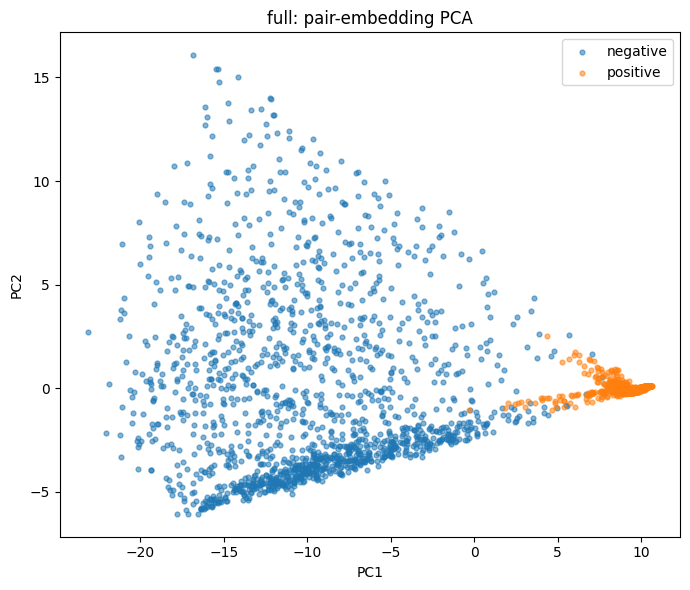

Saved: /content/article_ablation_v3/full/results.json

RUN: no_rank
{
  "w_rank": 0.0,
  "w_sep": 0.1,
  "w_cross_align": 0.01,
  "w_alpha_entropy": 0.002
}
trainable params: 1528261


no_rank epoch 01/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 01 | train loss 0.8928 auc 0.6214 f1 0.5744 alpha 0.465 | val auc 0.9668 bacc 0.9036 f1 0.9022 alpha 0.361


no_rank epoch 02/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 02 | train loss 0.2458 auc 0.9924 f1 0.9593 alpha 0.523 | val auc 0.9981 bacc 0.9817 f1 0.9817 alpha 0.494


...

epoch 12 | train loss 0.0464 auc 0.9998 f1 0.9955 alpha 0.482 | val auc 0.9999 bacc 0.9976 f1 0.9976 alpha 0.489


no_rank epoch 13/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 13 | train loss 0.0454 auc 0.9998 f1 0.9954 alpha 0.461 | val auc 1.0000 bacc 0.9988 f1 0.9988 alpha 0.478


no_rank epoch 14/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 14 | train loss 0.0381 auc 0.9999 f1 0.9973 alpha 0.469 | val auc 0.9999 bacc 0.9985 f1 0.9985 alpha 0.470
[TEST] no_rank {
  "auc": 0.9999687671661377,
  "ap": 0.9999687197335573,
  "acc": 0.99755859375,
  "bacc": 0.99755859375,
  "f1": 0.9975574010747436,
  "pred_pos_rate": 0.49951171875,
  "prob_mean": 0.5020756125450134,
  "threshold": 0.87125,
  "loss": 0.037730837357230484,
  "alpha_mean": 0.47593193873763084
}
[no_rank][same_speaker_same_clip_gap1] {
  "auc": 0.9997999668121338,
  "ap": 0.9998008753623264,
  "acc": 0.995849609375,
  "bacc": 0.995849609375,
  "f1": 0.9958546695927822,
  "pred_pos_rate": 0.501220703125,
  "prob_mean": 0.5064744353294373,
  "threshold": 0.82625,
  "loss": 0.06536266300827265,
  "alpha_mean": 0.47474315483123064
}
[no_rank][same_speaker_diff_clip] {
  "auc": 0.9999494552612305,
  "ap": 0.9999489707760663,
  "acc": 0.99755859375,
  "bacc": 0.99755859375,
  "f1": 0.9975574010747436,
  "pred_pos_rate": 0.49951171875,
  "prob_mean": 0.500684618949

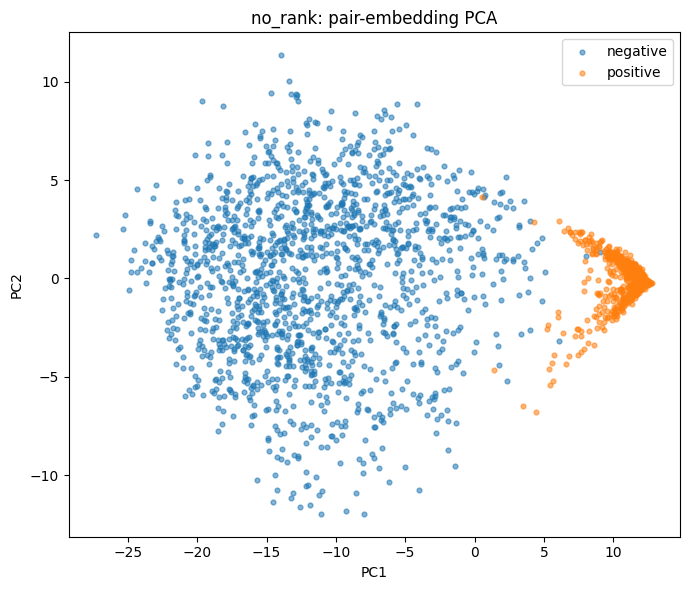

Saved: /content/article_ablation_v3/no_rank/results.json

RUN: no_sep
{
  "w_rank": 0.35,
  "w_sep": 0.0,
  "w_cross_align": 0.01,
  "w_alpha_entropy": 0.002
}
trainable params: 1528261


no_sep epoch 01/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 01 | train loss 0.8457 auc 0.7290 f1 0.6335 alpha 0.470 | val auc 0.9783 bacc 0.9336 f1 0.9333 alpha 0.385


no_sep epoch 02/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 02 | train loss 0.2500 auc 0.9932 f1 0.9621 alpha 0.406 | val auc 0.9978 bacc 0.9800 f1 0.9801 alpha 0.520


...

epoch 12 | train loss 0.0541 auc 0.9998 f1 0.9952 alpha 0.521 | val auc 0.9999 bacc 0.9968 f1 0.9968 alpha 0.506


no_sep epoch 13/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 13 | train loss 0.0565 auc 0.9997 f1 0.9945 alpha 0.510 | val auc 0.9999 bacc 0.9963 f1 0.9963 alpha 0.524


no_sep epoch 14/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 14 | train loss 0.0543 auc 0.9998 f1 0.9943 alpha 0.516 | val auc 1.0000 bacc 0.9973 f1 0.9973 alpha 0.540
[TEST] no_sep {
  "auc": 0.9999210834503174,
  "ap": 0.9999199991138795,
  "acc": 0.997802734375,
  "bacc": 0.997802734375,
  "f1": 0.9978032706858677,
  "pred_pos_rate": 0.500244140625,
  "prob_mean": 0.5001630783081055,
  "threshold": 0.42124999999999996,
  "loss": 0.04432311904383823,
  "alpha_mean": 0.5156445456668735
}
[no_sep][same_speaker_same_clip_gap1] {
  "auc": 0.999809980392456,
  "ap": 0.9997839923234347,
  "acc": 0.99755859375,
  "bacc": 0.99755859375,
  "f1": 0.9975562072336266,
  "pred_pos_rate": 0.4990234375,
  "prob_mean": 0.5013070106506348,
  "threshold": 0.6687500000000001,
  "loss": 0.053747240104712546,
  "alpha_mean": 0.5143998768180609
}
[no_sep][same_speaker_diff_clip] {
  "auc": 0.999931812286377,
  "ap": 0.9999314811711849,
  "acc": 0.99755859375,
  "bacc": 0.99755859375,
  "f1": 0.9975609756097561,
  "pred_pos_rate": 0.5009765625,
  "prob_mean": 

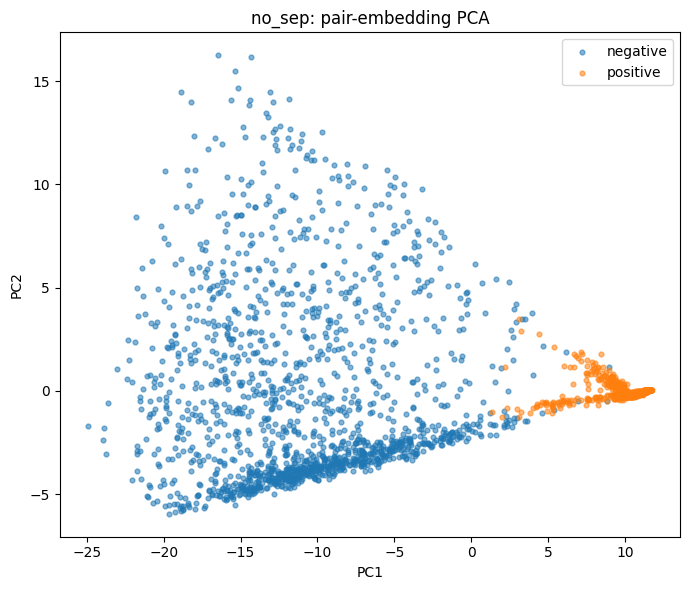

Saved: /content/article_ablation_v3/no_sep/results.json

RUN: no_cross_align
{
  "w_rank": 0.35,
  "w_sep": 0.1,
  "w_cross_align": 0.0,
  "w_alpha_entropy": 0.002
}
trainable params: 1528261


no_cross_align epoch 01/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 01 | train loss 0.6003 auc 0.9156 f1 0.8251 alpha 0.661 | val auc 0.9974 bacc 0.9807 f1 0.9807 alpha 0.893


no_cross_align epoch 02/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 02 | train loss 0.2117 auc 0.9974 f1 0.9792 alpha 0.920 | val auc 0.9995 bacc 0.9946 f1 0.9946 alpha 0.901


...

epoch 12 | train loss 0.1010 auc 0.9998 f1 0.9960 alpha 0.660 | val auc 1.0000 bacc 0.9978 f1 0.9978 alpha 0.677


no_cross_align epoch 13/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 13 | train loss 0.1022 auc 0.9997 f1 0.9955 alpha 0.626 | val auc 1.0000 bacc 0.9968 f1 0.9968 alpha 0.690


no_cross_align epoch 14/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 14 | train loss 0.0969 auc 0.9998 f1 0.9968 alpha 0.628 | val auc 1.0000 bacc 0.9971 f1 0.9971 alpha 0.621
[TEST] no_cross_align {
  "auc": 0.9999985694885254,
  "ap": 0.9999985715802566,
  "acc": 0.9990234375,
  "bacc": 0.9990234375,
  "f1": 0.9990243902439024,
  "pred_pos_rate": 0.5009765625,
  "prob_mean": 0.5041922926902771,
  "threshold": 0.905,
  "loss": 0.1008433683309704,
  "alpha_mean": 0.5991001632064581
}
[no_cross_align][same_speaker_same_clip_gap1] {
  "auc": 0.9999172687530518,
  "ap": 0.9999163897915743,
  "acc": 0.99560546875,
  "bacc": 0.99560546875,
  "f1": 0.9956225680933852,
  "pred_pos_rate": 0.50390625,
  "prob_mean": 0.5074506402015686,
  "threshold": 0.91625,
  "loss": 0.12553525110706687,
  "alpha_mean": 0.5992395561188459
}
[no_cross_align][same_speaker_diff_clip] {
  "auc": 0.9999866485595703,
  "ap": 0.9999867642008559,
  "acc": 0.998291015625,
  "bacc": 0.998291015625,
  "f1": 0.9982922664064406,
  "pred_pos_rate": 0.500732421875,
  "prob_mean": 0.504

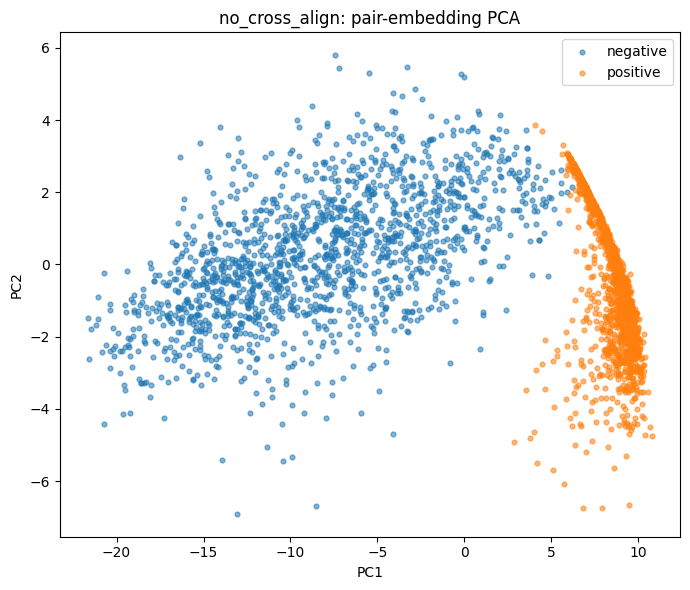

Saved: /content/article_ablation_v3/no_cross_align/results.json

RUN: bce_only
{
  "w_rank": 0.0,
  "w_sep": 0.0,
  "w_cross_align": 0.0,
  "w_alpha_entropy": 0.0
}
trainable params: 1528261


bce_only epoch 01/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 01 | train loss 0.5687 auc 0.9228 f1 0.8299 alpha 0.658 | val auc 0.9979 bacc 0.9868 f1 0.9869 alpha 0.862


bce_only epoch 02/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 02 | train loss 0.2189 auc 0.9978 f1 0.9835 alpha 0.891 | val auc 0.9995 bacc 0.9917 f1 0.9917 alpha 0.931


...

epoch 12 | train loss 0.1018 auc 0.9998 f1 0.9960 alpha 0.811 | val auc 0.9999 bacc 0.9976 f1 0.9976 alpha 0.820


bce_only epoch 13/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 13 | train loss 0.1039 auc 0.9997 f1 0.9953 alpha 0.828 | val auc 1.0000 bacc 0.9988 f1 0.9988 alpha 0.782


bce_only epoch 14/14:   0%|          | 0/128 [00:00<?, ?it/s]

epoch 14 | train loss 0.0964 auc 0.9998 f1 0.9966 alpha 0.757 | val auc 1.0000 bacc 0.9966 f1 0.9966 alpha 0.770
Early stopping.
[TEST] bce_only {
  "auc": 0.9999959468841553,
  "ap": 0.9999959350677496,
  "acc": 0.99853515625,
  "bacc": 0.99853515625,
  "f1": 0.9985372988785958,
  "pred_pos_rate": 0.50146484375,
  "prob_mean": 0.5091724991798401,
  "threshold": 0.95,
  "loss": 0.12283967016264796,
  "alpha_mean": 0.8555158842355013
}
[bce_only][same_speaker_same_clip_gap1] {
  "auc": 0.9999096393585205,
  "ap": 0.9999065209876953,
  "acc": 0.99755859375,
  "bacc": 0.99755859375,
  "f1": 0.997564539698003,
  "pred_pos_rate": 0.50244140625,
  "prob_mean": 0.5081757307052612,
  "threshold": 0.95,
  "loss": 0.1255811855662614,
  "alpha_mean": 0.8531945608556271
}
[bce_only][same_speaker_diff_clip] {
  "auc": 0.9999890327453613,
  "ap": 0.9999890694982227,
  "acc": 0.99658203125,
  "bacc": 0.99658203125,
  "f1": 0.9965936739659368,
  "pred_pos_rate": 0.50341796875,
  "prob_mean": 0.5114204

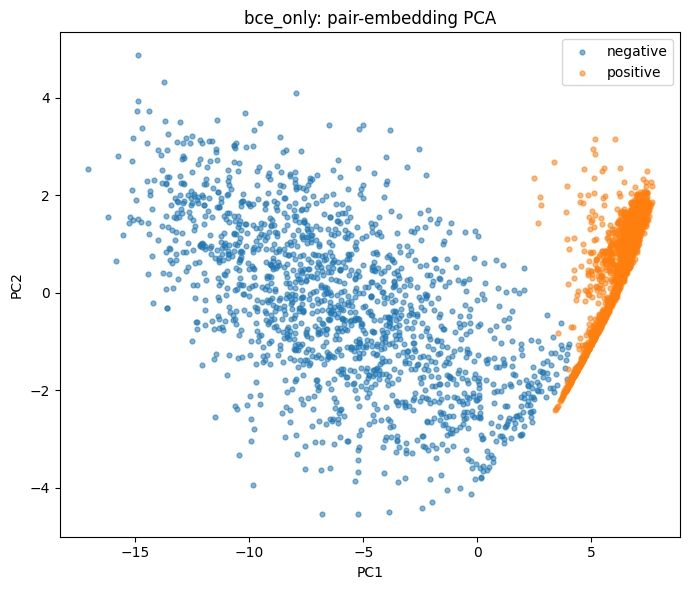

Saved: /content/article_ablation_v3/bce_only/results.json

Final ablation summary:
[
  {
    "name": "no_cross_align",
    "w_rank": 0.35,
    "w_sep": 0.1,
    "w_cross_align": 0.0,
    "w_alpha_entropy": 0.002,
    "params": 1528261,
    "test_auc": 0.9999985694885254,
    "test_bacc": 0.9990234375,
    "test_f1": 0.9990243902439024,
    "test_loss": 0.1008433683309704,
    "test_alpha_mean": 0.5991001632064581,
    "same_clip_gap1_auc": 0.9999172687530518,
    "cross_speaker_auc": 0.9999954700469971,
    "audio_swap_auc": 0.999990701675415,
    "visual_swap_auc": 0.8188341856002808,
    "ms_per_step": 34.0132474899292,
    "ms_per_sample": 0.26572849601507187,
    "results_json": "/content/article_ablation_v3/no_cross_align/results.json",
    "pca_path": "/content/article_ablation_v3/no_cross_align/no_cross_align_pair_embedding_pca.png"
  },
  {
    "name": "bce_only",
    "w_rank": 0.0,
    "w_sep": 0.0,
    "w_cross_align": 0.0,
    "w_alpha_entropy": 0.0,
    "params": 1528261,
 

In [ ]:

# ============================================================
#ABLATION SUITE FOR CIAS FUSION v3 LIGHT
==========================

# =========================
# 0) Install (Colab)
# =========================
# !pip -q install -U scikit-learn matplotlib tqdm

# =========================
# 1) Imports
# =========================
import os
import glob
import json
import copy
import time
import random
import warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# =========================
# 2) Config
# =========================
@dataclass
class CFG:
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # cache
    cache_path: str = "/content/cias_fusion_runs/fusion_joint_cache.npz"
    work_dir: str = "/content/article_ablation_v3"

    # split
    val_ratio: float = 0.2
    test_ratio: float = 0.2

    # pair sampling
    train_pairs_per_epoch: int = 16384
    eval_pairs: int = 4096

    hard_neg_min_gap: int = 1
    neg_same_clip_prob: float = 0.40
    neg_same_speaker_diff_clip_prob: float = 0.40
    neg_cross_speaker_prob: float = 0.20

    # data dims
    face_dim: int = 15
    body_dim: int = 36
    audio_dim: int = 64

    # model dims
    hidden_dim: int = 128
    proj_dim: int = 96
    dropout: float = 0.1

    # optimization
    batch_size: int = 128
    epochs: int = 14
    lr: float = 1.2e-3
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    num_workers: int = 0
    early_stop_patience: int = 6

    # fixed BCE heads
    w_final_bce: float = 1.0
    w_fb_bce: float = 0.10
    w_audio_bce: float = 0.10
    w_fusion_bce: float = 0.15

    # regularizers (ablated later)
    w_rank: float = 0.35
    w_sep: float = 0.10
    w_cross_align: float = 0.01
    w_alpha_entropy: float = 0.002

    rank_margin: float = 0.15

    # threshold search
    thr_grid_points: int = 81
    thr_min_pred_pos_rate: float = 0.2
    thr_max_pred_pos_rate: float = 0.8

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)
print("device:", cfg.device)
print(json.dumps(asdict(cfg), indent=2))

# =========================
# 3) Utils
# =========================
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

def auto_find_cache(preferred_path: str) -> str:
    if os.path.exists(preferred_path):
        return preferred_path
    candidates = glob.glob("/content/**/*.npz", recursive=True)
    candidates = [p for p in candidates if "fusion_joint_cache" in p or "fusion" in p.lower()]
    if len(candidates) > 0:
        candidates = sorted(candidates)
        print("Auto-found cache:", candidates[0])
        return candidates[0]
    raise FileNotFoundError(
        f"Joint cache not found.\nPreferred: {preferred_path}\n"
        "Please run the cache-building cell first."
    )

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, y_score))

def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(average_precision_score(y_true, y_score))

def constrained_best_threshold(y_true, prob, grid_points=81, min_pred_pos_rate=0.2, max_pred_pos_rate=0.8):
    thresholds = np.linspace(0.05, 0.95, grid_points)
    best_thr = 0.5
    best_score = -1.0
    y_true = np.asarray(y_true).astype(int)
    prob = np.asarray(prob)

    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        pred_pos_rate = pred.mean()
        if pred_pos_rate < min_pred_pos_rate or pred_pos_rate > max_pred_pos_rate:
            continue
        score = balanced_accuracy_score(y_true, pred)
        if score > best_score:
            best_score = score
            best_thr = float(thr)

    return best_thr if best_score >= 0 else 0.5

def count_params(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

# =========================
# 4) Load cache
# =========================
cfg.cache_path = auto_find_cache(cfg.cache_path)
cache = np.load(cfg.cache_path, allow_pickle=True)

required = ["face", "body", "audio", "video_ids", "segment_ids", "speaker_names", "clip_names", "energy"]
for k in required:
    assert k in cache.files, f"Missing key {k}. Found: {cache.files}"

face = cache["face"].astype(np.float32)
body = cache["body"].astype(np.float32)
audio = cache["audio"].astype(np.float32)
video_ids = cache["video_ids"]
segment_ids = cache["segment_ids"]
speaker_names = cache["speaker_names"].astype(str)
clip_names = cache["clip_names"].astype(str)
energy = cache["energy"].astype(np.float32)

speaker_unique, speaker_ids = np.unique(speaker_names, return_inverse=True)
clip_unique, clip_ids = np.unique(clip_names, return_inverse=True)

print("face:", face.shape, "body:", body.shape, "audio:", audio.shape)
print("segments:", len(face))
print("unique speakers:", len(speaker_unique), "unique clips:", len(clip_unique))

# =========================
# 5) Speaker-holdout split
# =========================
unique_speakers = np.array(sorted(np.unique(speaker_ids).tolist()))
rng = np.random.RandomState(cfg.seed)
rng.shuffle(unique_speakers)

n_total = len(unique_speakers)
n_test = max(1, int(round(n_total * cfg.test_ratio)))
n_val = max(1, int(round(n_total * cfg.val_ratio)))
n_train = n_total - n_val - n_test

train_speakers = set(unique_speakers[:n_train].tolist())
val_speakers = set(unique_speakers[n_train:n_train + n_val].tolist())
test_speakers = set(unique_speakers[n_train + n_val:].tolist())

idx_train = np.where(np.isin(speaker_ids, list(train_speakers)))[0]
idx_val = np.where(np.isin(speaker_ids, list(val_speakers)))[0]
idx_test = np.where(np.isin(speaker_ids, list(test_speakers)))[0]

print("speaker-holdout split sizes:", {"train": len(idx_train), "val": len(idx_val), "test": len(idx_test)})
print("split speakers:", {"train": len(train_speakers), "val": len(val_speakers), "test": len(test_speakers)})

# =========================
# 6) Dataset
# =========================
def augment_visual(x: torch.Tensor, rng: random.Random):
    x = x.clone()
    if rng.random() < 0.7:
        x = x + 0.01 * torch.randn_like(x)
    if rng.random() < 0.4:
        w = rng.randint(1, max(1, x.shape[0] // 4))
        s = rng.randint(0, max(0, x.shape[0] - w))
        x[s:s+w] = 0.0
    return x

def augment_audio(x: torch.Tensor, rng: random.Random):
    x = x.clone()
    if rng.random() < 0.8:
        x = x + 0.02 * torch.randn_like(x)
    if rng.random() < 0.5:
        w = rng.randint(1, max(1, x.shape[0] // 4))
        s = rng.randint(0, max(0, x.shape[0] - w))
        x[s:s+w, :] = 0.0
    if rng.random() < 0.5:
        w = rng.randint(2, max(2, x.shape[1] // 8))
        s = rng.randint(0, max(0, x.shape[1] - w))
        x[:, s:s+w] = 0.0
    if rng.random() < 0.8:
        x = x * rng.uniform(0.9, 1.1)
    return x

class FusionPairDataset(Dataset):
    def __init__(self, indices, pairs_per_epoch, protocol="train_default", seed=42):
        self.indices = [int(i) for i in indices]
        self.pairs_per_epoch = int(pairs_per_epoch)
        self.protocol = protocol
        self.rng = random.Random(seed)

        self.by_speaker = {}
        self.by_clip = {}

        for i in self.indices:
            sp = int(speaker_ids[i])
            cl = int(clip_ids[i])
            self.by_speaker.setdefault(sp, []).append(i)
            self.by_clip.setdefault(cl, []).append(i)

        self.unique_speakers = list(self.by_speaker.keys())

    def __len__(self):
        return self.pairs_per_epoch

    def _same_clip_negative(self, a):
        cl = int(clip_ids[a])
        sa = int(segment_ids[a])
        candidates = [
            j for j in self.by_clip[cl]
            if j != a and abs(int(segment_ids[j]) - sa) >= cfg.hard_neg_min_gap
        ]
        return self.rng.choice(candidates) if len(candidates) > 0 else None

    def _same_speaker_diff_clip_negative(self, a):
        sp = int(speaker_ids[a])
        cl = int(clip_ids[a])
        candidates = [j for j in self.by_speaker[sp] if j != a and int(clip_ids[j]) != cl]
        return self.rng.choice(candidates) if len(candidates) > 0 else None

    def _cross_speaker_negative(self, a):
        sp = int(speaker_ids[a])
        others = [s for s in self.unique_speakers if s != sp]
        if len(others) == 0:
            return None
        s2 = self.rng.choice(others)
        return self.rng.choice(self.by_speaker[s2])

    def _sample_train_negative(self, a):
        r = self.rng.random()

        if r < cfg.neg_same_clip_prob:
            b = self._same_clip_negative(a)
            if b is not None:
                return b

        if r < cfg.neg_same_clip_prob + cfg.neg_same_speaker_diff_clip_prob:
            b = self._same_speaker_diff_clip_negative(a)
            if b is not None:
                return b

        b = self._cross_speaker_negative(a)
        if b is not None:
            return b

        candidates = [j for j in self.indices if j != a]
        return self.rng.choice(candidates)

    def _sample_protocol_negative(self, a):
        if self.protocol == "same_speaker_same_clip_gap1":
            cl = int(clip_ids[a])
            sa = int(segment_ids[a])
            candidates = [j for j in self.by_clip[cl] if j != a and abs(int(segment_ids[j]) - sa) == 1]
            if len(candidates) == 0:
                candidates = [j for j in self.by_clip[cl] if j != a]
            return self.rng.choice(candidates)

        if self.protocol == "same_speaker_diff_clip":
            b = self._same_speaker_diff_clip_negative(a)
            if b is not None:
                return b

        if self.protocol == "cross_speaker":
            b = self._cross_speaker_negative(a)
            if b is not None:
                return b

        return self._sample_train_negative(a)

    def __getitem__(self, idx):
        is_pos = (idx % 2 == 0)

        if self.protocol == "train_default":
            if is_pos:
                a = self.rng.choice(self.indices)
                b = a
                y = 1
            else:
                a = self.rng.choice(self.indices)
                b = self._sample_train_negative(a)
                y = 0
        else:
            a = self.rng.choice(self.indices)
            if is_pos:
                b = a
                y = 1
            else:
                b = self._sample_protocol_negative(a)
                y = 0

        fa = torch.tensor(face[a], dtype=torch.float32)
        ba = torch.tensor(body[a], dtype=torch.float32)
        aa = torch.tensor(audio[a], dtype=torch.float32)

        fb = torch.tensor(face[b], dtype=torch.float32)
        bb = torch.tensor(body[b], dtype=torch.float32)
        ab = torch.tensor(audio[b], dtype=torch.float32)

        if y == 1:
            fb = augment_visual(fb, self.rng)
            bb = augment_visual(bb, self.rng)
            ab = augment_audio(ab, self.rng)

        if self.protocol == "audio_only_swap" and y == 0:
            fb = fa.clone()
            bb = ba.clone()

        if self.protocol == "visual_only_swap" and y == 0:
            ab = aa.clone()

        return {
            "face_a": fa,
            "body_a": ba,
            "audio_a": aa,
            "face_b": fb,
            "body_b": bb,
            "audio_b": ab,
            "label": torch.tensor(float(y), dtype=torch.float32),
        }

# =========================
# 7) Encoders + Model
# =========================
class TemporalEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, proj_dim, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=in_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, proj_dim),
        )

    def forward(self, x):
        out, _ = self.gru(x)
        pooled = out.mean(dim=1)
        z = self.proj(pooled)
        z = F.normalize(z, dim=-1)
        return z

class LogMelEncoder(nn.Module):
    def __init__(self, n_mels, proj_dim, dropout):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.GELU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d((2, 2)),
        )
        t_red = max(1, 16 // 4)
        m_red = max(1, n_mels // 4)
        self.head = nn.Sequential(
            nn.Linear(64 * t_red * m_red, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, proj_dim),
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        h = self.conv(x)
        h = h.flatten(1)
        z = self.head(h)
        z = F.normalize(z, dim=-1)
        return z

class FusionV3Light(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        self.face_enc = TemporalEncoder(cfg.face_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.body_enc = TemporalEncoder(cfg.body_dim, cfg.hidden_dim, cfg.proj_dim, cfg.dropout)
        self.audio_enc = LogMelEncoder(cfg.audio_dim, cfg.proj_dim, cfg.dropout)

        self.fb_merge = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
        )

        self.audio_residual = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, cfg.proj_dim),
        )

        self.alpha_net = nn.Sequential(
            nn.Linear(cfg.proj_dim * 2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
            nn.Sigmoid(),
        )

        self.fb_head = nn.Sequential(
            nn.Linear(2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

        self.audio_head = nn.Sequential(
            nn.Linear(2, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

        self.fusion_head = nn.Sequential(
            nn.Linear(4, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

        self.final_head = nn.Sequential(
            nn.Linear(6, cfg.hidden_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def encode_single(self, f, b, a):
        zf = self.face_enc(f)
        zb = self.body_enc(b)
        za = self.audio_enc(a)

        zfb = F.normalize(self.fb_merge(torch.cat([zf, zb], dim=-1)), dim=-1)

        alpha = self.alpha_net(torch.cat([zfb, za], dim=-1))   # [B,1]
        delta = self.audio_residual(torch.cat([zfb, za], dim=-1))
        zj = F.normalize(zfb + alpha * delta, dim=-1)

        return zf, zb, za, zfb, zj, alpha

    def forward(self, batch, return_pair_embedding=False):
        zf_a, zb_a, za_a, zfb_a, zj_a, alpha_a = self.encode_single(batch["face_a"], batch["body_a"], batch["audio_a"])
        zf_b, zb_b, za_b, zfb_b, zj_b, alpha_b = self.encode_single(batch["face_b"], batch["body_b"], batch["audio_b"])

        fb_feats = torch.cat([
            F.cosine_similarity(zfb_a, zfb_b, dim=-1).unsqueeze(-1),
            (zfb_a - zfb_b).pow(2).mean(dim=-1, keepdim=True),
        ], dim=-1)

        audio_feats = torch.cat([
            F.cosine_similarity(za_a, za_b, dim=-1).unsqueeze(-1),
            (za_a - za_b).pow(2).mean(dim=-1, keepdim=True),
        ], dim=-1)

        fusion_feats = torch.cat([
            F.cosine_similarity(zj_a, zj_b, dim=-1).unsqueeze(-1),
            (zj_a - zj_b).pow(2).mean(dim=-1, keepdim=True),
            F.cosine_similarity(zfb_a, za_a, dim=-1).unsqueeze(-1),
            F.cosine_similarity(zfb_b, za_b, dim=-1).unsqueeze(-1),
        ], dim=-1)

        fb_logit = self.fb_head(fb_feats).squeeze(-1)
        audio_logit = self.audio_head(audio_feats).squeeze(-1)
        fusion_logit = self.fusion_head(fusion_feats).squeeze(-1)

        alpha_mean = 0.5 * (alpha_a + alpha_b)
        alpha_diff = torch.abs(alpha_a - alpha_b)

        final_feats = torch.cat([
            fb_logit.unsqueeze(-1),
            audio_logit.unsqueeze(-1),
            fusion_logit.unsqueeze(-1),
            alpha_mean,
            alpha_diff,
            (fb_logit - audio_logit).abs().unsqueeze(-1),
        ], dim=-1)

        final_logit = self.final_head(final_feats).squeeze(-1)

        cross_align = (
            (1.0 - F.cosine_similarity(zfb_a, za_a, dim=-1)).mean() +
            (1.0 - F.cosine_similarity(zfb_b, za_b, dim=-1)).mean()
        ) * 0.5

        alpha_entropy = -(
            alpha_mean * torch.log(alpha_mean + 1e-8) +
            (1.0 - alpha_mean) * torch.log(1.0 - alpha_mean + 1e-8)
        ).mean()

        out = {
            "final_logit": final_logit,
            "fb_logit": fb_logit,
            "audio_logit": audio_logit,
            "fusion_logit": fusion_logit,
            "cross_align": cross_align,
            "alpha_entropy": alpha_entropy,
            "alpha_mean": alpha_mean.mean(),
        }

        if return_pair_embedding:
            out["pair_embedding"] = final_feats.detach()
            out["joint_a"] = zj_a.detach()
            out["joint_b"] = zj_b.detach()

        return out

# =========================
# 8) Loss / eval
# =========================
def pair_rank_sep_loss(logit, y, cfg):
    prob = torch.sigmoid(logit)
    pos_mask = y > 0.5
    neg_mask = ~pos_mask

    rank_loss = torch.tensor(0.0, device=logit.device)
    sep_loss = torch.tensor(0.0, device=logit.device)

    if pos_mask.any() and neg_mask.any():
        pos_prob = prob[pos_mask]
        neg_prob = prob[neg_mask]
        pair_diff = pos_prob[:, None] - neg_prob[None, :]
        rank_loss = F.relu(cfg.rank_margin - pair_diff).mean()
        sep_loss = F.relu(0.5 - pos_prob).mean() + F.relu(neg_prob - 0.5).mean()

    return rank_loss, sep_loss

def compute_loss(out, y, cfg):
    y = y.float()

    final_bce = F.binary_cross_entropy_with_logits(out["final_logit"], y)
    fb_bce = F.binary_cross_entropy_with_logits(out["fb_logit"], y)
    audio_bce = F.binary_cross_entropy_with_logits(out["audio_logit"], y)
    fusion_bce = F.binary_cross_entropy_with_logits(out["fusion_logit"], y)

    rank_loss, sep_loss = pair_rank_sep_loss(out["final_logit"], y, cfg)

    loss = (
        cfg.w_final_bce * final_bce +
        cfg.w_fb_bce * fb_bce +
        cfg.w_audio_bce * audio_bce +
        cfg.w_fusion_bce * fusion_bce +
        cfg.w_rank * rank_loss +
        cfg.w_sep * sep_loss +
        cfg.w_cross_align * out["cross_align"] -
        cfg.w_alpha_entropy * out["alpha_entropy"]
    )

    parts = {
        "final_bce": float(final_bce.detach().cpu()),
        "fb_bce": float(fb_bce.detach().cpu()),
        "audio_bce": float(audio_bce.detach().cpu()),
        "fusion_bce": float(fusion_bce.detach().cpu()),
        "rank": float(rank_loss.detach().cpu()),
        "sep": float(sep_loss.detach().cpu()),
        "alpha_mean": float(out["alpha_mean"].detach().cpu()),
    }
    return loss, parts

@torch.no_grad()
def evaluate_model(model, loader, cfg):
    model.eval()
    ys, probs = [], []
    total_loss = 0.0
    n = 0
    alpha_vals = []

    for batch in loader:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch)
        y = batch["label"]
        loss, _ = compute_loss(out, y, cfg)

        p = torch.sigmoid(out["final_logit"]).detach().cpu().numpy()
        ys.append(y.detach().cpu().numpy())
        probs.append(p)

        alpha_vals.append(float(out["alpha_mean"].detach().cpu()))

        bs = len(y)
        total_loss += float(loss.detach().cpu()) * bs
        n += bs

    ys = np.concatenate(ys).astype(int)
    probs = np.concatenate(probs)

    thr = constrained_best_threshold(
        ys, probs,
        grid_points=cfg.thr_grid_points,
        min_pred_pos_rate=cfg.thr_min_pred_pos_rate,
        max_pred_pos_rate=cfg.thr_max_pred_pos_rate,
    )
    pred = (probs >= thr).astype(int)

    return {
        "auc": safe_auc(ys, probs),
        "ap": safe_ap(ys, probs),
        "acc": float(accuracy_score(ys, pred)),
        "bacc": float(balanced_accuracy_score(ys, pred)),
        "f1": float(f1_score(ys, pred, zero_division=0)),
        "pred_pos_rate": float(pred.mean()),
        "prob_mean": float(probs.mean()),
        "threshold": float(thr),
        "loss": float(total_loss / max(n, 1)),
        "alpha_mean": float(np.mean(alpha_vals)),
    }

# =========================
# 9) Benchmark + embeddings
# =========================
@torch.no_grad()
def benchmark_inference(model, loader, cfg, warmup=10, steps=50):
    model.eval()
    batch = next(iter(loader))
    batch = {k: v.to(cfg.device) for k, v in batch.items()}

    for _ in range(warmup):
        _ = model(batch)
    if cfg.device.startswith("cuda"):
        torch.cuda.synchronize()

    t0 = time.time()
    for _ in range(steps):
        _ = model(batch)
    if cfg.device.startswith("cuda"):
        torch.cuda.synchronize()
    t1 = time.time()

    ms_per_step = (t1 - t0) * 1000.0 / steps
    bs = int(batch["label"].shape[0])
    ms_per_sample = ms_per_step / max(bs, 1)
    return float(ms_per_step), float(ms_per_sample)

@torch.no_grad()
def collect_pair_embeddings(model, loader, cfg, max_batches=24):
    model.eval()
    Z = []
    Y = []

    for bi, batch in enumerate(loader):
        if bi >= max_batches:
            break
        batch_gpu = {k: v.to(cfg.device) for k, v in batch.items()}
        out = model(batch_gpu, return_pair_embedding=True)
        Z.append(out["pair_embedding"].cpu().numpy())
        Y.append(batch["label"].numpy())

    Z = np.concatenate(Z, axis=0)
    Y = np.concatenate(Y, axis=0).astype(int)
    return Z, Y

def save_pca_plot(Z, Y, out_path, title):
    pca = PCA(n_components=2, random_state=cfg.seed)
    Z2 = pca.fit_transform(Z)

    plt.figure(figsize=(7, 6))
    plt.scatter(Z2[Y == 0, 0], Z2[Y == 0, 1], s=12, alpha=0.55, label="negative")
    plt.scatter(Z2[Y == 1, 0], Z2[Y == 1, 1], s=12, alpha=0.55, label="positive")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()

# =========================
# 10) Train one ablation
# =========================
def make_loaders(seed_offset=0):
    train_ds = FusionPairDataset(idx_train, cfg.train_pairs_per_epoch, protocol="train_default", seed=cfg.seed + 11 + seed_offset)
    val_ds = FusionPairDataset(idx_val, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 13 + seed_offset)
    test_ds = FusionPairDataset(idx_test, cfg.eval_pairs, protocol="train_default", seed=cfg.seed + 17 + seed_offset)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    return train_loader, val_loader, test_loader

def protocol_loader(protocol, seed_offset=0):
    ds = FusionPairDataset(idx_test, cfg.eval_pairs, protocol=protocol, seed=cfg.seed + 100 + seed_offset + abs(hash(protocol)) % 1000)
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

def train_one_variant(name: str, ablation_cfg: Dict[str, float]):
    run_dir = os.path.join(cfg.work_dir, name)
    os.makedirs(run_dir, exist_ok=True)

    cfg_run = copy.deepcopy(cfg)
    for k, v in ablation_cfg.items():
        setattr(cfg_run, k, v)

    print("\n" + "=" * 90)
    print("RUN:", name)
    print(json.dumps({k: getattr(cfg_run, k) for k in ["w_rank", "w_sep", "w_cross_align", "w_alpha_entropy"]}, indent=2))
    print("=" * 90)

    seed_everything(cfg_run.seed)
    train_loader, val_loader, test_loader = make_loaders(seed_offset=abs(hash(name)) % 1000)

    model = FusionV3Light(cfg_run).to(cfg_run.device)
    n_params = count_params(model)
    print("trainable params:", n_params)

    opt = torch.optim.AdamW(model.parameters(), lr=cfg_run.lr, weight_decay=cfg_run.weight_decay)

    best_state = None
    best_auc = -1.0
    bad_epochs = 0
    history = []

    for epoch in range(1, cfg_run.epochs + 1):
        model.train()
        ys, probs = [], []
        total_epoch_loss = 0.0
        n = 0
        alpha_vals = []

        pbar = tqdm(train_loader, desc=f"{name} epoch {epoch:02d}/{cfg_run.epochs}", leave=False)
        for batch in pbar:
            batch = {k: v.to(cfg_run.device) for k, v in batch.items()}
            out = model(batch)
            y = batch["label"]
            loss, parts = compute_loss(out, y, cfg_run)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg_run.grad_clip)
            opt.step()

            p = torch.sigmoid(out["final_logit"]).detach().cpu().numpy()
            ys.append(y.detach().cpu().numpy())
            probs.append(p)
            alpha_vals.append(parts["alpha_mean"])

            bs = len(y)
            total_epoch_loss += float(loss.detach().cpu()) * bs
            n += bs

            pbar.set_postfix(loss=float(loss.detach().cpu()), alpha=f"{parts['alpha_mean']:.3f}")

        ys = np.concatenate(ys).astype(int)
        probs = np.concatenate(probs)
        pred = (probs >= 0.5).astype(int)
        train_auc = safe_auc(ys, probs)
        train_f1 = float(f1_score(ys, pred, zero_division=0))

        val_metrics = evaluate_model(model, val_loader, cfg_run)
        hist_row = {
            "epoch": epoch,
            "train_loss": float(total_epoch_loss / max(n, 1)),
            "train_auc": float(train_auc),
            "train_f1": float(train_f1),
            "train_alpha_mean": float(np.mean(alpha_vals)),
            "val": val_metrics,
        }
        history.append(hist_row)

        print(
            f"epoch {epoch:02d} | "
            f"train loss {hist_row['train_loss']:.4f} auc {train_auc:.4f} f1 {train_f1:.4f} "
            f"alpha {hist_row['train_alpha_mean']:.3f} | "
            f"val auc {val_metrics['auc']:.4f} bacc {val_metrics['bacc']:.4f} "
            f"f1 {val_metrics['f1']:.4f} alpha {val_metrics['alpha_mean']:.3f}"
        )

        if val_metrics["auc"] > best_auc:
            best_auc = val_metrics["auc"]
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= cfg_run.early_stop_patience:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    test_metrics = evaluate_model(model, test_loader, cfg_run)
    print("[TEST]", name, json.dumps(test_metrics, indent=2))

    protocols = [
        "same_speaker_same_clip_gap1",
        "same_speaker_diff_clip",
        "cross_speaker",
        "audio_only_swap",
        "visual_only_swap",
    ]
    protocol_results = {}
    for protocol in protocols:
        metrics = evaluate_model(model, protocol_loader(protocol, seed_offset=abs(hash(name)) % 1000), cfg_run)
        protocol_results[protocol] = metrics
        print(f"[{name}][{protocol}] {json.dumps(metrics, indent=2)}")

    ms_step, ms_sample = benchmark_inference(model, val_loader, cfg_run)
    print(f"[LATENCY] {name}: {ms_step:.3f} ms/step | {ms_sample:.4f} ms/sample")

    Z, Y = collect_pair_embeddings(model, val_loader, cfg_run, max_batches=24)
    pca_path = os.path.join(run_dir, f"{name}_pair_embedding_pca.png")
    save_pca_plot(Z, Y, pca_path, title=f"{name}: pair-embedding PCA")

    results = {
        "name": name,
        "config": asdict(cfg_run),
        "cache_path": cfg.cache_path,
        "n_params": int(n_params),
        "split_sizes": {
            "train": int(len(idx_train)),
            "val": int(len(idx_val)),
            "test": int(len(idx_test)),
        },
        "split_speakers": {
            "train": int(len(train_speakers)),
            "val": int(len(val_speakers)),
            "test": int(len(test_speakers)),
        },
        "test": test_metrics,
        "protocols": protocol_results,
        "history": history,
        "latency": {
            "ms_per_step": ms_step,
            "ms_per_sample": ms_sample,
        },
        "artifacts": {
            "pca_path": pca_path,
        },
    }

    out_json = os.path.join(run_dir, "results.json")
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print("Saved:", out_json)

    summary_row = {
        "name": name,
        "w_rank": cfg_run.w_rank,
        "w_sep": cfg_run.w_sep,
        "w_cross_align": cfg_run.w_cross_align,
        "w_alpha_entropy": cfg_run.w_alpha_entropy,
        "params": n_params,
        "test_auc": float(test_metrics["auc"]),
        "test_bacc": float(test_metrics["bacc"]),
        "test_f1": float(test_metrics["f1"]),
        "test_loss": float(test_metrics["loss"]),
        "test_alpha_mean": float(test_metrics["alpha_mean"]),
        "same_clip_gap1_auc": float(protocol_results["same_speaker_same_clip_gap1"]["auc"]),
        "cross_speaker_auc": float(protocol_results["cross_speaker"]["auc"]),
        "audio_swap_auc": float(protocol_results["audio_only_swap"]["auc"]),
        "visual_swap_auc": float(protocol_results["visual_only_swap"]["auc"]),
        "ms_per_step": float(ms_step),
        "ms_per_sample": float(ms_sample),
        "results_json": out_json,
        "pca_path": pca_path,
    }

    return summary_row

# =========================
# 11) Main comparison table from previous fusion_results.json (optional)
# =========================
previous_results_candidates = [
    "/content/cias_fusion_runs/fusion_results.json",
] + glob.glob("/content/**/fusion_results.json", recursive=True)

previous_results_candidates = [p for p in previous_results_candidates if os.path.exists(p)]
if len(previous_results_candidates) > 0:
    prev_path = sorted(set(previous_results_candidates))[0]
    print("Found previous fusion results:", prev_path)
    prev = json.load(open(prev_path, "r"))
    if "experiments" in prev:
        main_rows = []
        for name, item in prev["experiments"].items():
            row = {
                "model": name,
                "params": int(item.get("n_params", -1)),
                "test_auc": float(item["test"]["auc"]),
                "test_bacc": float(item["test"]["bacc"]),
                "test_f1": float(item["test"]["f1"]),
            }
            main_rows.append(row)
        main_rows = sorted(main_rows, key=lambda x: x["test_auc"], reverse=True)
        with open(os.path.join(cfg.work_dir, "main_comparison_table.json"), "w", encoding="utf-8") as f:
            json.dump(main_rows, f, ensure_ascii=False, indent=2)
        print("Saved main comparison table json.")
        print(json.dumps(main_rows, indent=2))

# =========================
# 12) Ablations
# =========================
ABLATIONS = [
    dict(name="full",            w_rank=0.35, w_sep=0.10, w_cross_align=0.01, w_alpha_entropy=0.002),
    dict(name="no_rank",         w_rank=0.00, w_sep=0.10, w_cross_align=0.01, w_alpha_entropy=0.002),
    dict(name="no_sep",          w_rank=0.35, w_sep=0.00, w_cross_align=0.01, w_alpha_entropy=0.002),
    dict(name="no_cross_align",  w_rank=0.35, w_sep=0.10, w_cross_align=0.00, w_alpha_entropy=0.002),
    dict(name="bce_only",        w_rank=0.00, w_sep=0.00, w_cross_align=0.00, w_alpha_entropy=0.000),
]

summary_rows = []
for ab in ABLATIONS:
    name = ab["name"]
    row = train_one_variant(
        name=name,
        ablation_cfg={
            "w_rank": ab["w_rank"],
            "w_sep": ab["w_sep"],
            "w_cross_align": ab["w_cross_align"],
            "w_alpha_entropy": ab["w_alpha_entropy"],
        }
    )
    summary_rows.append(row)

# =========================
# 13) Save summary tables
# =========================
summary_rows = sorted(summary_rows, key=lambda x: x["test_auc"], reverse=True)

summary_json = os.path.join(cfg.work_dir, "article_ablation_summary.json")
summary_csv = os.path.join(cfg.work_dir, "article_ablation_summary.csv")

with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary_rows, f, ensure_ascii=False, indent=2)

# lightweight CSV without pandas dependency
csv_cols = list(summary_rows[0].keys())
with open(summary_csv, "w", encoding="utf-8") as f:
    f.write(",".join(csv_cols) + "\n")
    for row in summary_rows:
        vals = []
        for c in csv_cols:
            v = row[c]
            if isinstance(v, str):
                vals.append('"' + v.replace('"', '""') + '"')
            else:
                vals.append(str(v))
        f.write(",".join(vals) + "\n")

print("\nFinal ablation summary:")
print(json.dumps(summary_rows, indent=2))
print("Saved summary JSON:", summary_json)
print("Saved summary CSV :", summary_csv)

best_name = summary_rows[0]["name"]
print(f"\nBest ablation by test_auc: {best_name}")
print("Done.")


In [ ]:
# ============================================================
# CIAS MINIMAL PIPELINE
# RAVDESS 12 actors + MELD subset
# ============================================================

!pip -q install ultralytics opencv-python-headless requests tqdm scikit-learn pandas matplotlib

import os, gc, cv2, zipfile, tarfile, shutil, random, math, requests, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from ultralytics import YOLO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score

# ============================================================
# 0. CONFIG
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

BASE_DIR = "/content/cias_q1_min"
TMP_DIR = "/content/cias_tmp"

RAVDESS_SHARD_DIR = f"{BASE_DIR}/shards/RAVDESS"
MELD_SHARD_DIR    = f"{BASE_DIR}/shards/MELD"
RESULT_DIR        = f"{BASE_DIR}/results"

for d in [BASE_DIR, TMP_DIR, RAVDESS_SHARD_DIR, MELD_SHARD_DIR, RESULT_DIR]:
    os.makedirs(d, exist_ok=True)

# ---------- Dataset minimal Q1 setting ----------
PROCESS_RAVDESS = True
PROCESS_MELD = True

RAVDESS_ACTORS = list(range(1, 13))   # Q1 minimum: 12 actors
MELD_MAX_CLIPS = 800                  # Q1 minimum external noisy subset

# ---------- Pose/window setting ----------
TARGET_FPS = 3
WINDOW_T = 12
STRIDE = 6
MAX_FRAMES_PER_VIDEO = 90
YOLO_BATCH = 1

# ---------- Training setting ----------
EPOCHS = 8
BATCH_SIZE = 64
LR = 1e-3
HIDDEN = 96
EMBED = 96
K_PROTO = 8
TEMP = 0.25

N_EVAL_PAIRS = 2000
TRAIN_PAIR_MULTIPLIER = 4
MIN_WINDOWS = 80

FACE_IDX = [0, 1, 2, 3, 4]
BODY_IDX = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

print("Base dir:", BASE_DIR)

# ============================================================
# 1. UTILITIES
# ============================================================

def clean_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def download_file(url, out_path, chunk_size=1024*1024):
    if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
        print("[exists]", out_path)
        return out_path

    print("[download]", url)
    print("[to]", out_path)

    with requests.get(url, stream=True, allow_redirects=True) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))

        with open(out_path, "wb") as f, tqdm(
            total=total,
            unit="B",
            unit_scale=True,
            desc=os.path.basename(out_path)
        ) as pbar:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

    return out_path

def safe_rmtree(path):
    if os.path.exists(path):
        shutil.rmtree(path)

def find_videos(root, limit=None):
    exts = [".mp4", ".avi", ".mov", ".mkv", ".webm"]
    files = []
    for p in Path(root).rglob("*"):
        if p.suffix.lower() in exts:
            files.append(str(p))
    files = sorted(files)
    if limit is not None:
        files = files[:limit]
    return files

def count_shards(shard_dir):
    return len(list(Path(shard_dir).glob("*.npz")))

# ============================================================
# 2. POSE EXTRACTION
# ============================================================

def normalize_keypoints(xy):
    xy = np.array(xy, dtype=np.float32)

    if xy.shape[0] < 17:
        return None, None

    xy[~np.isfinite(xy)] = 0

    core = xy[[5, 6, 11, 12]]
    center = core.mean(axis=0)

    shoulder = np.linalg.norm(xy[5] - xy[6])
    torso = np.linalg.norm(((xy[5] + xy[6]) / 2) - ((xy[11] + xy[12]) / 2))
    scale = max(shoulder, torso, 30.0)

    xy = (xy - center) / scale

    face = xy[FACE_IDX].reshape(-1).astype(np.float32)  # 10
    body = xy[BODY_IDX].reshape(-1).astype(np.float32)  # 24

    return face, body

def add_derivatives(x):
    d1 = np.zeros_like(x)
    d2 = np.zeros_like(x)

    d1[1:] = x[1:] - x[:-1]
    d2[2:] = x[2:] - x[:-2]

    return np.concatenate([x, d1, d2], axis=-1).astype(np.float32)

def make_windows(face_seq, body_seq):
    if len(face_seq) < WINDOW_T:
        return [], []

    Fseq = add_derivatives(np.stack(face_seq))  # [T, 30]
    Bseq = add_derivatives(np.stack(body_seq))  # [T, 72]

    Fw, Bw = [], []

    for s in range(0, len(Fseq) - WINDOW_T + 1, STRIDE):
        f = Fseq[s:s+WINDOW_T]
        b = Bseq[s:s+WINDOW_T]

        if np.abs(f).sum() < 1e-6 or np.abs(b).sum() < 1e-6:
            continue

        Fw.append(f)
        Bw.append(b)

    return Fw, Bw

def process_video(video_path, model):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return [], []

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 1:
        fps = 30

    step = max(1, int(round(fps / TARGET_FPS)))

    faces, bodies = [], []
    last_f = np.zeros(10, dtype=np.float32)
    last_b = np.zeros(24, dtype=np.float32)

    idx = 0
    used = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if idx % step == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            try:
                res = model.predict(
                    frame,
                    verbose=False,
                    device=0 if DEVICE == "cuda" else "cpu"
                )[0]

                if res.keypoints is not None and res.keypoints.xy is not None and len(res.keypoints.xy) > 0:
                    xy_all = res.keypoints.xy.detach().cpu().numpy()

                    if res.keypoints.conf is not None:
                        conf = res.keypoints.conf.detach().cpu().numpy()
                        person = int(np.argmax(conf.sum(axis=1)))
                    else:
                        person = 0

                    f, b = normalize_keypoints(xy_all[person])

                    if f is not None:
                        last_f = f
                        last_b = b

                faces.append(last_f.copy())
                bodies.append(last_b.copy())

            except Exception:
                faces.append(last_f.copy())
                bodies.append(last_b.copy())

            used += 1

            if used >= MAX_FRAMES_PER_VIDEO:
                break

        idx += 1

    cap.release()
    clean_memory()

    return make_windows(faces, bodies)

# ============================================================
# 3. SHARD WRITER
# ============================================================

class ShardWriter:
    def __init__(self, shard_dir, dataset_name, shard_size=500):
        self.shard_dir = shard_dir
        self.dataset_name = dataset_name
        self.shard_size = shard_size
        os.makedirs(shard_dir, exist_ok=True)

        self.face = []
        self.body = []
        self.video_ids = []
        self.subject_ids = []
        self.counter = count_shards(shard_dir)

    def add(self, f, b, video_id, subject_id):
        self.face.append(f)
        self.body.append(b)
        self.video_ids.append(video_id)
        self.subject_ids.append(subject_id)

        if len(self.face) >= self.shard_size:
            self.flush()

    def flush(self):
        if len(self.face) == 0:
            return

        out_path = os.path.join(
            self.shard_dir,
            f"{self.dataset_name}_shard_{self.counter:05d}.npz"
        )

        np.savez_compressed(
            out_path,
            face=np.array(self.face, dtype=np.float32),
            body=np.array(self.body, dtype=np.float32),
            video_ids=np.array(self.video_ids),
            subject_ids=np.array(self.subject_ids),
            dataset=np.array([self.dataset_name] * len(self.face))
        )

        print("[saved]", out_path, "windows:", len(self.face))

        self.face, self.body, self.video_ids, self.subject_ids = [], [], [], []
        self.counter += 1
        clean_memory()

# ============================================================
# 4. DOWNLOAD + PROCESS RAVDESS
# ============================================================

def process_ravdess():
    print("\n" + "="*80)
    print("RAVDESS PROCESSING")
    print("="*80)

    done_file = os.path.join(RAVDESS_SHARD_DIR, "_RAVDESS_DONE.txt")
    if os.path.exists(done_file):
        print("[skip] RAVDESS already processed.")
        return

    model = YOLO("yolov8n-pose.pt")
    writer = ShardWriter(RAVDESS_SHARD_DIR, "RAVDESS", shard_size=500)

    record = requests.get("https://zenodo.org/api/records/1188976").json()
    files = record["files"]

    selected = []

    for f in files:
        key = f["key"]
        for actor in RAVDESS_ACTORS:
            if key == f"Video_Speech_Actor_{actor:02d}.zip":
                selected.append(f)

    print("Selected actors:", RAVDESS_ACTORS)
    print("Selected zip files:", len(selected))

    for f in selected:
        key = f["key"]
        actor_id = key.split("_Actor_")[-1].replace(".zip", "")

        marker = os.path.join(RAVDESS_SHARD_DIR, f".done_{key}")
        if os.path.exists(marker):
            print("[skip actor]", key)
            continue

        print("\n" + "-"*70)
        print("Actor zip:", key)
        print("-"*70)

        zip_path = os.path.join(TMP_DIR, key)
        extract_dir = os.path.join(TMP_DIR, key.replace(".zip", ""))

        safe_rmtree(extract_dir)

        url = f["links"].get("self") or f["links"].get("download")
        download_file(url, zip_path)

        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_dir)

        videos = find_videos(extract_dir)
        print("Videos:", len(videos))

        for vp in tqdm(videos, desc=f"RAVDESS actor {actor_id}"):
            try:
                Fw, Bw = process_video(vp, model)

                vid = f"ravdess_actor_{actor_id}_" + os.path.basename(vp)

                for i in range(len(Fw)):
                    writer.add(Fw[i], Bw[i], vid, actor_id)

            except Exception as e:
                print("Skip video:", vp, str(e)[:120])

        writer.flush()

        safe_rmtree(extract_dir)
        if os.path.exists(zip_path):
            os.remove(zip_path)

        Path(marker).write_text("done")
        clean_memory()

    writer.flush()
    Path(done_file).write_text("done")
    print("RAVDESS done. Shards:", count_shards(RAVDESS_SHARD_DIR))

# ============================================================
# 5. DOWNLOAD + PROCESS MELD
# ============================================================

def extract_tar(tar_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    with tarfile.open(tar_path, "r:*") as tar:
        tar.extractall(out_dir)

def process_meld():
    print("\n" + "="*80)
    print("MELD PROCESSING")
    print("="*80)

    done_file = os.path.join(MELD_SHARD_DIR, "_MELD_DONE.txt")
    if os.path.exists(done_file):
        print("[skip] MELD already processed.")
        return

    model = YOLO("yolov8n-pose.pt")
    writer = ShardWriter(MELD_SHARD_DIR, "MELD", shard_size=500)

    meld_root = os.path.join(TMP_DIR, "MELD")
    meld_tar = os.path.join(TMP_DIR, "MELD.Raw.tar.gz")
    meld_url = "http://web.eecs.umich.edu/~mihalcea/downloads/MELD.Raw.tar.gz"

    if not os.path.exists(meld_root):
        download_file(meld_url, meld_tar)
        extract_tar(meld_tar, meld_root)

        inner = list(Path(meld_root).rglob("*.tar.gz"))
        for a in inner:
            out_dir = str(a).replace(".tar.gz", "")
            if not os.path.exists(out_dir):
                extract_tar(str(a), out_dir)

    videos = find_videos(meld_root, limit=MELD_MAX_CLIPS)
    print("MELD selected clips:", len(videos))

    for idx, vp in enumerate(tqdm(videos, desc="MELD clips")):
        try:
            Fw, Bw = process_video(vp, model)

            rel = os.path.relpath(vp, meld_root)
            subject_id = "unknown"

            for i in range(len(Fw)):
                writer.add(Fw[i], Bw[i], f"meld_{idx}_{rel}", subject_id)

        except Exception as e:
            print("Skip MELD:", vp, str(e)[:120])

    writer.flush()

    # Чтобы освободить диск после pose extraction
    safe_rmtree(meld_root)
    if os.path.exists(meld_tar):
        os.remove(meld_tar)

    Path(done_file).write_text("done")
    print("MELD done. Shards:", count_shards(MELD_SHARD_DIR))

# ============================================================
# 6. LOAD SHARDS
# ============================================================

def load_shards(shard_dir, dataset_name):
    files = sorted(Path(shard_dir).glob("*.npz"))

    faces, bodies, vids, subs, dsets = [], [], [], [], []

    for fp in files:
        z = np.load(fp, allow_pickle=True)

        if "face" not in z:
            continue

        faces.append(z["face"])
        bodies.append(z["body"])
        vids.append(z["video_ids"])
        subs.append(z["subject_ids"])
        dsets.append(z["dataset"])

    if len(faces) == 0:
        return None

    data = {
        "face": np.concatenate(faces, axis=0).astype(np.float32),
        "body": np.concatenate(bodies, axis=0).astype(np.float32),
        "video_ids": np.concatenate(vids, axis=0).astype(str),
        "subject_ids": np.concatenate(subs, axis=0).astype(str),
        "dataset": np.concatenate(dsets, axis=0).astype(str),
    }

    print(dataset_name, "loaded:")
    print("face:", data["face"].shape)
    print("body:", data["body"].shape)
    print("videos:", len(set(data["video_ids"])))

    return data

def subset(data, mask):
    return {
        "face": data["face"][mask],
        "body": data["body"][mask],
        "video_ids": data["video_ids"][mask],
        "subject_ids": data["subject_ids"][mask],
        "dataset": data["dataset"][mask],
    }

def split_by_video(data, test_size=0.2, val_size=0.1):
    vids = np.array(sorted(list(set(data["video_ids"]))))

    if len(vids) < 5:
        idx = np.arange(len(data["face"]))
        tr, te = train_test_split(idx, test_size=test_size, random_state=SEED)
        tr, va = train_test_split(tr, test_size=val_size, random_state=SEED)

        mtr = np.zeros(len(idx), dtype=bool)
        mva = np.zeros(len(idx), dtype=bool)
        mte = np.zeros(len(idx), dtype=bool)

        mtr[tr] = True
        mva[va] = True
        mte[te] = True
        return mtr, mva, mte

    train_vids, test_vids = train_test_split(vids, test_size=test_size, random_state=SEED)
    train_vids, val_vids = train_test_split(train_vids, test_size=val_size, random_state=SEED)

    mtr = np.isin(data["video_ids"], train_vids)
    mva = np.isin(data["video_ids"], val_vids)
    mte = np.isin(data["video_ids"], test_vids)

    return mtr, mva, mte

def standardize_fit_apply(train, val, test):
    fs = StandardScaler()
    bs = StandardScaler()

    F = train["face"]
    B = train["body"]

    fs.fit(F.reshape(-1, F.shape[-1]))
    bs.fit(B.reshape(-1, B.shape[-1]))

    def apply(d):
        F = d["face"]
        B = d["body"]

        return {
            "face": fs.transform(F.reshape(-1, F.shape[-1])).reshape(F.shape).astype(np.float32),
            "body": bs.transform(B.reshape(-1, B.shape[-1])).reshape(B.shape).astype(np.float32),
            "video_ids": d["video_ids"],
            "subject_ids": d["subject_ids"],
            "dataset": d["dataset"],
        }

    return apply(train), apply(val), apply(test)

# ============================================================
# 7. PAIR SAMPLING
# ============================================================

class PairSampler:
    def __init__(self, data):
        self.face = data["face"]
        self.body = data["body"]
        self.video_ids = np.array(data["video_ids"])
        self.n = len(self.face)

        self.vid_to_idx = {}
        for i, v in enumerate(self.video_ids):
            self.vid_to_idx.setdefault(v, []).append(i)

        self.videos = list(self.vid_to_idx.keys())

    def positive(self):
        i = random.randrange(self.n)
        return i, i, 1

    def cross(self):
        i = random.randrange(self.n)
        vi = self.video_ids[i]

        for _ in range(50):
            j = random.randrange(self.n)
            if self.video_ids[j] != vi:
                return i, j, 0

        return i, random.randrange(self.n), 0

    def same(self):
        possible = [v for v in self.videos if len(self.vid_to_idx[v]) >= 2]

        if len(possible) == 0:
            return self.cross()

        v = random.choice(possible)
        i, j = random.sample(self.vid_to_idx[v], 2)
        return i, j, 0

    def shift(self):
        possible = [v for v in self.videos if len(self.vid_to_idx[v]) >= 2]

        if len(possible) == 0:
            return self.cross()

        v = random.choice(possible)
        idxs = sorted(self.vid_to_idx[v])

        pos = random.randrange(len(idxs))
        delta = random.choice([-2, -1, 1, 2])
        pos2 = min(max(pos + delta, 0), len(idxs) - 1)

        if pos2 == pos:
            return self.cross()

        return idxs[pos], idxs[pos2], 0

    def shuffle(self):
        i = random.randrange(self.n)
        j = random.randrange(self.n)

        if i == j:
            return self.cross()

        return i, j, 0

    def mixed_negative(self):
        r = random.choice(["cross", "same", "shift", "shuffle"])

        if r == "cross":
            return self.cross()
        if r == "same":
            return self.same()
        if r == "shift":
            return self.shift()

        return self.shuffle()

class PairDataset(Dataset):
    def __init__(self, data, length):
        self.data = data
        self.sampler = PairSampler(data)
        self.length = length

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        if random.random() < 0.5:
            i, j, y = self.sampler.positive()
        else:
            i, j, y = self.sampler.mixed_negative()

        return (
            torch.tensor(self.data["face"][i], dtype=torch.float32),
            torch.tensor(self.data["body"][j], dtype=torch.float32),
            torch.tensor([y], dtype=torch.float32),
        )

# ============================================================
# 8. MODEL
# ============================================================

class CIASNet(nn.Module):
    def __init__(self, face_dim=30, body_dim=72):
        super().__init__()

        self.face_gru = nn.GRU(face_dim, HIDDEN, batch_first=True, bidirectional=True)
        self.body_gru = nn.GRU(body_dim, HIDDEN, batch_first=True, bidirectional=True)

        self.face_proj = nn.Sequential(
            nn.Linear(HIDDEN * 2, EMBED),
            nn.ReLU(),
            nn.LayerNorm(EMBED)
        )

        self.body_proj = nn.Sequential(
            nn.Linear(HIDDEN * 2, EMBED),
            nn.ReLU(),
            nn.LayerNorm(EMBED)
        )

        self.prototypes = nn.Parameter(torch.randn(K_PROTO, EMBED) * 0.02)

        self.logit_scale = nn.Parameter(torch.tensor(8.0))
        self.logit_bias = nn.Parameter(torch.tensor(-4.0))

    def encode_face(self, x):
        _, h = self.face_gru(x)
        h = torch.cat([h[-2], h[-1]], dim=-1)
        z = self.face_proj(h)
        return F.normalize(z, dim=-1)

    def encode_body(self, x):
        _, h = self.body_gru(x)
        h = torch.cat([h[-2], h[-1]], dim=-1)
        z = self.body_proj(h)
        return F.normalize(z, dim=-1)

    def dist(self, z):
        p = F.normalize(self.prototypes, dim=-1)
        logits = torch.matmul(z, p.t()) / TEMP
        return F.softmax(logits, dim=-1)

    def js(self, p, q, eps=1e-8):
        p = p.clamp(min=eps)
        q = q.clamp(min=eps)

        m = 0.5 * (p + q)

        kl1 = torch.sum(p * torch.log(p / m), dim=-1)
        kl2 = torch.sum(q * torch.log(q / m), dim=-1)

        js = 0.5 * (kl1 + kl2) / math.log(2.0)
        return js

    def forward(self, face, body):
        zf = self.encode_face(face)
        zb = self.encode_body(body)

        pf = self.dist(zf)
        pb = self.dist(zb)

        js = self.js(pf, pb)
        ec = 1.0 - js

        emb_cos = torch.sum(zf * zb, dim=-1)
        prob_cos = F.cosine_similarity(pf, pb, dim=-1)

        symkl = torch.sum(pf * torch.log((pf + 1e-8) / (pb + 1e-8)), dim=-1)
        symkl += torch.sum(pb * torch.log((pb + 1e-8) / (pf + 1e-8)), dim=-1)
        symkl = 0.5 * symkl

        logit = self.logit_scale * ec + self.logit_bias

        return {
            "logit": logit.unsqueeze(-1),
            "ec_js": ec,
            "emb_cos": emb_cos,
            "prob_cos": prob_cos,
            "neg_symkl": -symkl,
            "pf": pf,
            "pb": pb,
            "zf": zf,
            "zb": zb,
        }

# ============================================================
# 9. TRAIN + EVAL
# ============================================================

def train_model(train, val=None, name="model"):
    model = CIASNet(
        face_dim=train["face"].shape[-1],
        body_dim=train["body"].shape[-1],
    ).to(DEVICE)

    length = max(4000, len(train["face"]) * TRAIN_PAIR_MULTIPLIER)
    ds = PairDataset(train, length=length)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    best_auc = -1
    best_state = None

    for ep in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for face, body, y in dl:
            face = face.to(DEVICE)
            body = body.to(DEVICE)
            y = y.to(DEVICE)

            out = model(face, body)
            loss = F.binary_cross_entropy_with_logits(out["logit"], y)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

            losses.append(loss.item())

        msg = f"{name} | epoch {ep:02d} | loss={np.mean(losses):.4f}"

        if val is not None and len(val["face"]) >= MIN_WINDOWS:
            res = evaluate_all(model, val, n_pairs=800, quiet=True)
            mean_auc = np.mean([v["ec_js_auc"] for v in res.values() if not np.isnan(v["ec_js_auc"])])
            msg += f" | val_mean_auc={mean_auc:.4f}"

            if mean_auc > best_auc:
                best_auc = mean_auc
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(msg)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

def make_eval_pairs(data, regime, n_pairs):
    sampler = PairSampler(data)
    pairs = []

    half = n_pairs // 2

    for _ in range(half):
        pairs.append(sampler.positive())

    for _ in range(n_pairs - half):
        if regime == "cross":
            pairs.append(sampler.cross())
        elif regime == "same":
            pairs.append(sampler.same())
        elif regime == "shift":
            pairs.append(sampler.shift())
        elif regime == "shuffle":
            pairs.append(sampler.shuffle())
        else:
            raise ValueError(regime)

    random.shuffle(pairs)
    return pairs

@torch.no_grad()
def score_pairs(model, data, pairs):
    model.eval()

    labels = []
    scores = {
        "ec_js": [],
        "emb_cos": [],
        "prob_cos": [],
        "neg_symkl": [],
    }

    for s in range(0, len(pairs), 256):
        batch = pairs[s:s+256]

        fi = [x[0] for x in batch]
        bj = [x[1] for x in batch]
        yy = [x[2] for x in batch]

        face = torch.tensor(data["face"][fi], dtype=torch.float32).to(DEVICE)
        body = torch.tensor(data["body"][bj], dtype=torch.float32).to(DEVICE)

        out = model(face, body)

        for k in scores:
            scores[k].extend(out[k].detach().cpu().numpy().tolist())

        labels.extend(yy)

    return {k: np.array(v) for k, v in scores.items()}, np.array(labels)

def metric_auc(scores, labels):
    if len(set(labels.tolist())) < 2:
        return np.nan
    return float(roc_auc_score(labels, scores))

def evaluate_regime(model, data, regime, n_pairs=N_EVAL_PAIRS):
    pairs = make_eval_pairs(data, regime, n_pairs)
    scores, labels = score_pairs(model, data, pairs)

    res = {}

    for k, sc in scores.items():
        res[f"{k}_auc"] = metric_auc(sc, labels)
        res[f"{k}_pos_mean"] = float(sc[labels == 1].mean())
        res[f"{k}_neg_mean"] = float(sc[labels == 0].mean())

    return res

def evaluate_all(model, data, n_pairs=N_EVAL_PAIRS, quiet=False):
    regimes = ["cross", "same", "shift", "shuffle"]
    out = {}

    for r in regimes:
        res = evaluate_regime(model, data, r, n_pairs)
        out[r] = res

        if not quiet:
            print(
                f"{r:8s} | "
                f"CIAS_JS_AUC={res['ec_js_auc']:.4f} | "
                f"EmbCos_AUC={res['emb_cos_auc']:.4f} | "
                f"ProbCos_AUC={res['prob_cos_auc']:.4f} | "
                f"NegSymKL_AUC={res['neg_symkl_auc']:.4f}"
            )

    return out

# ============================================================
# 10. EXPERIMENT RUNNERS
# ============================================================

def prepare_dataset(data):
    mtr, mva, mte = split_by_video(data)

    raw_train = subset(data, mtr)
    raw_val = subset(data, mva)
    raw_test = subset(data, mte)

    train, val, test = standardize_fit_apply(raw_train, raw_val, raw_test)

    return train, val, test

def run_within(name, data):
    print("\n" + "="*80)
    print("WITHIN:", name)
    print("="*80)

    if data is None or len(data["face"]) < MIN_WINDOWS:
        print("Not enough windows:", 0 if data is None else len(data["face"]))
        return None, []

    train, val, test = prepare_dataset(data)

    print("Train:", len(train["face"]), "Val:", len(val["face"]), "Test:", len(test["face"]))

    model = train_model(train, val, name=f"{name}_within")

    print("\nTEST:", name)
    results = evaluate_all(model, test, n_pairs=N_EVAL_PAIRS)

    rows = []
    for regime, metrics in results.items():
        rows.append({
            "experiment": "within",
            "train": name,
            "test": name,
            "regime": regime,
            **metrics
        })

    return model, rows

def fit_scaler_source_apply(source_train, source_val, target_test):
    fs = StandardScaler()
    bs = StandardScaler()

    fs.fit(source_train["face"].reshape(-1, source_train["face"].shape[-1]))
    bs.fit(source_train["body"].reshape(-1, source_train["body"].shape[-1]))

    def apply(d):
        F = d["face"]
        B = d["body"]
        return {
            "face": fs.transform(F.reshape(-1, F.shape[-1])).reshape(F.shape).astype(np.float32),
            "body": bs.transform(B.reshape(-1, B.shape[-1])).reshape(B.shape).astype(np.float32),
            "video_ids": d["video_ids"],
            "subject_ids": d["subject_ids"],
            "dataset": d["dataset"],
        }

    return apply(source_train), apply(source_val), apply(target_test)

def run_cross(train_name, train_data, test_name, test_data):
    print("\n" + "="*80)
    print(f"CROSS: train {train_name} -> test {test_name}")
    print("="*80)

    if train_data is None or test_data is None:
        return []

    if len(train_data["face"]) < MIN_WINDOWS or len(test_data["face"]) < MIN_WINDOWS:
        print("Not enough data for cross.")
        return []

    mtr, mva, _ = split_by_video(train_data)
    _, _, mte_target = split_by_video(test_data)

    raw_train = subset(train_data, mtr)
    raw_val = subset(train_data, mva)
    raw_target = subset(test_data, mte_target)

    train, val, target = fit_scaler_source_apply(raw_train, raw_val, raw_target)

    print("Source train:", len(train["face"]), "Source val:", len(val["face"]), "Target test:", len(target["face"]))

    model = train_model(train, val, name=f"{train_name}_to_{test_name}")

    print("\nTARGET TEST:", test_name)
    results = evaluate_all(model, target, n_pairs=N_EVAL_PAIRS)

    rows = []
    for regime, metrics in results.items():
        rows.append({
            "experiment": "cross_transfer",
            "train": train_name,
            "test": test_name,
            "regime": regime,
            **metrics
        })

    return rows

# ============================================================
# 11. MAIN
# ============================================================

if PROCESS_RAVDESS:
    process_ravdess()

if PROCESS_MELD:
    process_meld()

print("\n" + "="*80)
print("LOAD CACHES")
print("="*80)

ravdess = load_shards(RAVDESS_SHARD_DIR, "RAVDESS")
meld = load_shards(MELD_SHARD_DIR, "MELD")

datasets = {}
if ravdess is not None and len(ravdess["face"]) >= MIN_WINDOWS:
    datasets["RAVDESS"] = ravdess

if meld is not None and len(meld["face"]) >= MIN_WINDOWS:
    datasets["MELD"] = meld

print("Available datasets:", list(datasets.keys()))

all_rows = []

# Within dataset
for name, data in datasets.items():
    model, rows = run_within(name, data)
    all_rows.extend(rows)
    clean_memory()

# Cross transfer
names = list(datasets.keys())

for a in names:
    for b in names:
        if a == b:
            continue
        rows = run_cross(a, datasets[a], b, datasets[b])
        all_rows.extend(rows)
        clean_memory()

# Save result table
df = pd.DataFrame(all_rows)

result_csv = os.path.join(RESULT_DIR, "cias_q1_min_results.csv")
df.to_csv(result_csv, index=False)

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)

display(df)

if len(df) > 0:
    pivot = df.pivot_table(
        index=["experiment", "train", "test"],
        columns="regime",
        values="ec_js_auc",
        aggfunc="mean"
    ).reset_index()

    print("\nCIAS JS AUC PIVOT")
    display(pivot)

    pivot_path = os.path.join(RESULT_DIR, "cias_q1_min_pivot.csv")
    pivot.to_csv(pivot_path, index=False)

    print("Saved:")
    print(result_csv)
    print(pivot_path)

print("\nDONE.")
print("All files are in:", BASE_DIR)

ERROR: Operation cancelled by user


ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
from pathlib import Path
import os, tarfile

BASE_DIR = "/content/cias_q1_min"
DOWNLOAD_DIR = f"{BASE_DIR}/downloads"
RAW_DIR = f"{BASE_DIR}/raw/MELD"

Path(DOWNLOAD_DIR).mkdir(parents=True, exist_ok=True)
Path(RAW_DIR).mkdir(parents=True, exist_ok=True)

MELD_URL = "https://web.eecs.umich.edu/~mihalcea/downloads/MELD.Raw.tar.gz"
MELD_TAR = f"{DOWNLOAD_DIR}/MELD.Raw.tar.gz"

# Download with SSL check disabled because the server certificate may fail in Colab
!wget --no-check-certificate -O "{MELD_TAR}" "{MELD_URL}"

print("Downloaded:", MELD_TAR, "size:", os.path.getsize(MELD_TAR) / 1024 / 1024, "MB")

# Extract
with tarfile.open(MELD_TAR, "r:gz") as tar:
    tar.extractall(RAW_DIR)

print("Extracted to:", RAW_DIR)

--2026-05-16 09:07:54--  https://web.eecs.umich.edu/~mihalcea/downloads/MELD.Raw.tar.gz
Resolving web.eecs.umich.edu (web.eecs.umich.edu)... 141.212.113.214
Connecting to web.eecs.umich.edu (web.eecs.umich.edu)|141.212.113.214|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 10878146150 (10G) [application/x-gzip]
Saving to: ‘/content/cias_q1_min/downloads/MELD.Raw.tar.gz’

/content/cias_q1_mi 100%[===================>]  10.13G  15.3MB/s    in 10m 46s 

2026-05-16 09:18:40 (16.1 MB/s) - ‘/content/cias_q1_min/downloads/MELD.Raw.tar.gz’ saved [10878146150/10878146150]

Downloaded: /content/cias_q1_min/downloads/MELD.Raw.tar.gz size: 10374.20859336853 MB
Extracted to: /content/cias_q1_min/raw/MELD


In [ ]:
# ============================================================
# MELD-ONLY PREPROCESSING FOR PMCI / CIAS Q1
# Creates:
# /content/cias_q1_min/shards/MELD/MELD_shard_00000.npz
#
# Use this if RAVDESS shards already exist, but MELD shards are missing.
# ============================================================

!pip -q install ultralytics opencv-python tqdm numpy pandas scikit-learn

import os
import gc
import cv2
import tarfile
import shutil
import subprocess
import numpy as np
from pathlib import Path
from tqdm import tqdm

import torch
from ultralytics import YOLO

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/content/cias_q1_min"
TMP_DIR = "/content/cias_tmp"

MELD_SHARD_DIR = f"{BASE_DIR}/shards/MELD"
MELD_TMP_ROOT = f"{TMP_DIR}/MELD"
MELD_TAR = f"{TMP_DIR}/MELD.Raw.tar.gz"

Path(BASE_DIR).mkdir(parents=True, exist_ok=True)
Path(TMP_DIR).mkdir(parents=True, exist_ok=True)
Path(MELD_SHARD_DIR).mkdir(parents=True, exist_ok=True)

# Same settings as previous successful preprocessing
MELD_MAX_CLIPS = 800

TARGET_FPS = 3
WINDOW_T = 12
STRIDE = 6
MAX_FRAMES_PER_VIDEO = 90
YOLO_BATCH = 1

FACE_IDX = [0, 1, 2, 3, 4]
BODY_IDX = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

print("BASE_DIR:", BASE_DIR)
print("MELD_SHARD_DIR:", MELD_SHARD_DIR)

# ============================================================
# CLEAN / CHECK
# ============================================================

def clean_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def safe_rmtree(path):
    if os.path.exists(path):
        shutil.rmtree(path)

def count_npz(path):
    return len(list(Path(path).glob("*.npz")))

# Remove false done marker if npz does not exist
done_file = f"{MELD_SHARD_DIR}/_MELD_DONE.txt"
if os.path.exists(done_file) and count_npz(MELD_SHARD_DIR) == 0:
    print("Removing false done marker:", done_file)
    os.remove(done_file)

print("Existing MELD npz shards:", count_npz(MELD_SHARD_DIR))

# ============================================================
# DOWNLOAD MELD WITH SSL-SAFE FALLBACK
# ============================================================

def download_meld():
    if os.path.exists(MELD_TAR) and os.path.getsize(MELD_TAR) > 1024 * 1024:
        print("[exists]", MELD_TAR, "size MB:", os.path.getsize(MELD_TAR) / 1024 / 1024)
        return

    urls = [
        "http://web.eecs.umich.edu/~mihalcea/downloads/MELD.Raw.tar.gz",
        "https://web.eecs.umich.edu/~mihalcea/downloads/MELD.Raw.tar.gz",
    ]

    for url in urls:
        print("\nTrying download:", url)

        # First try wget
        cmd = [
            "wget",
            "--no-check-certificate",
            "-O",
            MELD_TAR,
            url
        ]

        try:
            ret = subprocess.run(cmd, check=False)
            if os.path.exists(MELD_TAR) and os.path.getsize(MELD_TAR) > 1024 * 1024:
                print("Downloaded:", MELD_TAR)
                print("Size MB:", os.path.getsize(MELD_TAR) / 1024 / 1024)
                return
        except Exception as e:
            print("wget failed:", e)

        # Then try curl
        cmd = [
            "curl",
            "-k",
            "-L",
            "--retry",
            "5",
            "--retry-delay",
            "5",
            "-o",
            MELD_TAR,
            url
        ]

        try:
            ret = subprocess.run(cmd, check=False)
            if os.path.exists(MELD_TAR) and os.path.getsize(MELD_TAR) > 1024 * 1024:
                print("Downloaded:", MELD_TAR)
                print("Size MB:", os.path.getsize(MELD_TAR) / 1024 / 1024)
                return
        except Exception as e:
            print("curl failed:", e)

    raise RuntimeError("Could not download MELD.Raw.tar.gz")

# ============================================================
# EXTRACT
# ============================================================

def extract_meld():
    if os.path.exists(MELD_TMP_ROOT):
        videos = find_videos(MELD_TMP_ROOT, limit=5)
        if len(videos) > 0:
            print("[exists extracted]", MELD_TMP_ROOT)
            return

    print("Extracting MELD...")
    safe_rmtree(MELD_TMP_ROOT)
    Path(MELD_TMP_ROOT).mkdir(parents=True, exist_ok=True)

    with tarfile.open(MELD_TAR, "r:*") as tar:
        tar.extractall(MELD_TMP_ROOT)

    print("Extracted to:", MELD_TMP_ROOT)

# ============================================================
# VIDEO SEARCH
# ============================================================

def find_videos(root, limit=None):
    exts = [".mp4", ".avi", ".mov", ".mkv", ".webm"]
    files = []

    for p in Path(root).rglob("*"):
        if p.suffix.lower() in exts:
            files.append(str(p))

    files = sorted(files)

    if limit is not None:
        files = files[:limit]

    return files

# ============================================================
# POSE FEATURES
# ============================================================

def normalize_keypoints(xy):
    xy = np.array(xy, dtype=np.float32)

    if xy.shape[0] < 17:
        return None, None

    xy[~np.isfinite(xy)] = 0.0

    # Core body points: shoulders and hips
    core = xy[[5, 6, 11, 12]]
    center = core.mean(axis=0)

    shoulder = np.linalg.norm(xy[5] - xy[6])
    torso = np.linalg.norm(((xy[5] + xy[6]) / 2) - ((xy[11] + xy[12]) / 2))
    scale = max(shoulder, torso, 30.0)

    xy_norm = (xy - center) / scale

    face = xy_norm[FACE_IDX].reshape(-1)   # 5 keypoints * 2 = 10
    body = xy_norm[BODY_IDX].reshape(-1)   # 12 keypoints * 2 = 24

    return face.astype(np.float32), body.astype(np.float32)

def augment_temporal_features(seq):
    """
    Input:
        seq: [T, D]
    Output:
        aug: [T, 3D] = [x_t, x_t - x_{t-1}, x_t - x_{t-2}]
    """
    seq = np.asarray(seq, dtype=np.float32)

    d1 = np.zeros_like(seq)
    d2 = np.zeros_like(seq)

    d1[1:] = seq[1:] - seq[:-1]
    d2[2:] = seq[2:] - seq[:-2]

    return np.concatenate([seq, d1, d2], axis=-1).astype(np.float32)

def make_windows(F, B):
    """
    F: [T, 10] -> after temporal augmentation [T, 30]
    B: [T, 24] -> after temporal augmentation [T, 72]
    """
    if len(F) < WINDOW_T:
        return np.zeros((0, WINDOW_T, 30), dtype=np.float32), np.zeros((0, WINDOW_T, 72), dtype=np.float32)

    F_aug = augment_temporal_features(F)
    B_aug = augment_temporal_features(B)

    Fw, Bw = [], []

    for start in range(0, len(F_aug) - WINDOW_T + 1, STRIDE):
        Fw.append(F_aug[start:start + WINDOW_T])
        Bw.append(B_aug[start:start + WINDOW_T])

    if len(Fw) == 0:
        return np.zeros((0, WINDOW_T, 30), dtype=np.float32), np.zeros((0, WINDOW_T, 72), dtype=np.float32)

    return np.stack(Fw).astype(np.float32), np.stack(Bw).astype(np.float32)

def process_video(video_path, model):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        return np.zeros((0, WINDOW_T, 30), dtype=np.float32), np.zeros((0, WINDOW_T, 72), dtype=np.float32)

    src_fps = cap.get(cv2.CAP_PROP_FPS)
    if not np.isfinite(src_fps) or src_fps <= 0:
        src_fps = 25.0

    step = max(1, int(round(src_fps / TARGET_FPS)))

    faces = []
    bodies = []

    frame_idx = 0
    used = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if frame_idx % step != 0:
            frame_idx += 1
            continue

        frame_idx += 1

        if used >= MAX_FRAMES_PER_VIDEO:
            break

        used += 1

        try:
            results = model.predict(
                frame,
                verbose=False,
                imgsz=320,
                conf=0.25,
                device=0 if torch.cuda.is_available() else "cpu"
            )

            if len(results) == 0:
                continue

            r = results[0]

            if r.keypoints is None:
                continue

            kpts = r.keypoints.xy

            if kpts is None or len(kpts) == 0:
                continue

            kpts_np = kpts.detach().cpu().numpy()

            # Select person with largest body box area if boxes exist
            person_idx = 0
            if r.boxes is not None and len(r.boxes) > 0:
                boxes = r.boxes.xyxy.detach().cpu().numpy()
                areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
                person_idx = int(np.argmax(areas))

            xy = kpts_np[person_idx]

            face, body = normalize_keypoints(xy)

            if face is None or body is None:
                continue

            faces.append(face)
            bodies.append(body)

        except Exception:
            continue

    cap.release()

    if len(faces) < WINDOW_T:
        return np.zeros((0, WINDOW_T, 30), dtype=np.float32), np.zeros((0, WINDOW_T, 72), dtype=np.float32)

    F = np.stack(faces).astype(np.float32)
    B = np.stack(bodies).astype(np.float32)

    return make_windows(F, B)

# ============================================================
# SHARD WRITER
# ============================================================

class ShardWriter:
    def __init__(self, out_dir, dataset_name, shard_size=500):
        self.out_dir = out_dir
        self.dataset_name = dataset_name
        self.shard_size = shard_size

        Path(out_dir).mkdir(parents=True, exist_ok=True)

        self.faces = []
        self.bodies = []
        self.video_ids = []
        self.subject_ids = []
        self.datasets = []

        self.shard_idx = count_npz(out_dir)

    def add(self, face, body, video_id, subject_id):
        self.faces.append(face.astype(np.float32))
        self.bodies.append(body.astype(np.float32))
        self.video_ids.append(str(video_id))
        self.subject_ids.append(str(subject_id))
        self.datasets.append(self.dataset_name)

        if len(self.faces) >= self.shard_size:
            self.flush()

    def flush(self):
        if len(self.faces) == 0:
            return

        out_path = os.path.join(
            self.out_dir,
            f"{self.dataset_name}_shard_{self.shard_idx:05d}.npz"
        )

        np.savez_compressed(
            out_path,
            face=np.stack(self.faces).astype(np.float32),
            body=np.stack(self.bodies).astype(np.float32),
            video_ids=np.array(self.video_ids).astype(str),
            subject_ids=np.array(self.subject_ids).astype(str),
            dataset=np.array(self.datasets).astype(str),
        )

        print("[saved]", out_path, "windows:", len(self.faces))

        self.faces = []
        self.bodies = []
        self.video_ids = []
        self.subject_ids = []
        self.datasets = []

        self.shard_idx += 1

# ============================================================
# PROCESS MELD
# ============================================================

def process_meld():
    print("\n" + "=" * 80)
    print("MELD PROCESSING")
    print("=" * 80)

    if count_npz(MELD_SHARD_DIR) > 0:
        print("[skip] MELD shards already exist:", count_npz(MELD_SHARD_DIR))
        return

    download_meld()
    extract_meld()

    print("Loading YOLOv8 pose model...")
    model = YOLO("yolov8n-pose.pt")

    videos = find_videos(MELD_TMP_ROOT, limit=MELD_MAX_CLIPS)
    print("MELD selected clips:", len(videos))

    if len(videos) == 0:
        raise RuntimeError("No MELD videos found after extraction.")

    writer = ShardWriter(MELD_SHARD_DIR, "MELD", shard_size=500)

    for idx, vp in enumerate(tqdm(videos, desc="MELD clips")):
        try:
            Fw, Bw = process_video(vp, model)

            rel = os.path.relpath(vp, MELD_TMP_ROOT)
            subject_id = "unknown"

            for i in range(len(Fw)):
                writer.add(
                    Fw[i],
                    Bw[i],
                    video_id=f"meld_{idx}_{rel}",
                    subject_id=subject_id
                )

        except Exception as e:
            print("Skip MELD:", vp, str(e)[:150])

        if idx % 50 == 0:
            clean_memory()

    writer.flush()

    # Free disk space after pose extraction
    print("Cleaning extracted MELD and tar file...")
    safe_rmtree(MELD_TMP_ROOT)

    if os.path.exists(MELD_TAR):
        os.remove(MELD_TAR)

    Path(done_file).write_text("done")

    print("\nMELD done. Shards:", count_npz(MELD_SHARD_DIR))

# ============================================================
# VERIFY LOAD
# ============================================================

def load_shards(shard_dir, dataset_name):
    files = sorted(Path(shard_dir).glob("*.npz"))

    if len(files) == 0:
        raise RuntimeError(f"No shards found in {shard_dir}")

    faces, bodies, vids, subs, dsets = [], [], [], [], []

    for fp in files:
        z = np.load(fp, allow_pickle=True)

        if "face" not in z:
            continue

        faces.append(z["face"])
        bodies.append(z["body"])
        vids.append(z["video_ids"])
        subs.append(z["subject_ids"])
        dsets.append(z["dataset"])

    data = {
        "face": np.concatenate(faces, axis=0).astype(np.float32),
        "body": np.concatenate(bodies, axis=0).astype(np.float32),
        "video_ids": np.concatenate(vids, axis=0).astype(str),
        "subject_ids": np.concatenate(subs, axis=0).astype(str),
        "dataset": np.concatenate(dsets, axis=0).astype(str),
    }

    print("\n" + dataset_name, "loaded:")
    print("face:", data["face"].shape)
    print("body:", data["body"].shape)
    print("videos:", len(set(data["video_ids"])))

    return data

# ============================================================
# RUN
# ============================================================

process_meld()

meld = load_shards(MELD_SHARD_DIR, "MELD")

print("\nFinal check:")
print("/content/cias_q1_min/shards/MELD npz:", count_npz(MELD_SHARD_DIR))
print("Expected approximately: face (402, 12, 30), body (402, 12, 72)")
print("DONE.")

BASE_DIR: /content/cias_q1_min
MELD_SHARD_DIR: /content/cias_q1_min/shards/MELD
Existing MELD npz shards: 0

MELD PROCESSING

Trying download: http://web.eecs.umich.edu/~mihalcea/downloads/MELD.Raw.tar.gz
Downloaded: /content/cias_tmp/MELD.Raw.tar.gz
Size MB: 10374.20859336853
Extracting MELD...
Extracted to: /content/cias_tmp/MELD
Loading YOLOv8 pose model...
MELD selected clips: 0


RuntimeError: No MELD videos found after extraction.

Device: cuda

RAVDESS loaded: face (672, 12, 30), body (672, 12, 72), videos 672

MELD loaded: face (402, 12, 30), body (402, 12, 72), videos 223

RAVDESS actor split: 500 82 90

Emotion distribution in RAVDESS:
angry        144
disgust      144
calm         130
happy         80
sad           78
fearful       46
surprised     36
neutral       14
Name: count, dtype: int64

####################################################################################################
SEED: 42
####################################################################################################

RAVDESS actor-level | seed=42 | K=0
rav_actor | K=0 | seed=42 | epoch 01 | loss=0.3958 | val_auc=0.7405
rav_actor | K=0 | seed=42 | epoch 02 | loss=0.1909 | val_auc=0.7816
rav_actor | K=0 | seed=42 | epoch 03 | loss=0.1496 | val_auc=0.7793
rav_actor | K=0 | seed=42 | epoch 04 | loss=0.1191 | val_auc=0.8049
rav_actor | K=0 | seed=42 | epoch 05 | loss=0.0990 | val_auc=0.8430
rav_actor | K=0 | seed=42 | epoch 06 

,experiment,train,test,k_proto,regime,auc_mean,auc_std,pos_mean,neg_mean
0,meld_within,MELD,MELD,8,cross,0.738675,0.012977,0.571212,0.439002
1,meld_within,MELD,MELD,8,same,0.586380,0.008139,0.571212,0.526595
2,meld_within,MELD,MELD,8,shift,0.585614,0.007258,0.571212,0.528920
3,meld_within,MELD,MELD,8,shuffle,0.743620,0.024232,0.571212,0.436910
4,ravdess_actor_level,RAVDESS,RAVDESS,0,cross,0.929905,0.010804,0.555542,0.123943
5,ravdess_actor_level,RAVDESS,RAVDESS,0,same,0.923059,0.009050,0.555542,0.128899
6,ravdess_actor_level,RAVDESS,RAVDESS,0,shift,0.923059,0.009050,0.555542,0.128899
7,ravdess_actor_level,RAVDESS,RAVDESS,0,shuffle,0.926458,0.011500,0.555542,0.126629
8,ravdess_actor_level,RAVDESS,RAVDESS,8,cross,0.710697,0.047213,0.562293,0.437294
9,ravdess_actor_level,RAVDESS,RAVDESS,8,same,0.704050,0.054837,0.562293,0.440284



ADAPTATION CURVE


regime,experiment,train,test,k_proto,cross,same,shift,shuffle
0,ravdess_to_meld_adapt_0pct,RAVDESS+0%MELD,MELD,8,0.502088,0.507535,0.517001,0.497064
1,ravdess_to_meld_adapt_100pct,RAVDESS+100%MELD,MELD,8,0.590393,0.537326,0.541674,0.589775
2,ravdess_to_meld_adapt_10pct,RAVDESS+10%MELD,MELD,8,0.539638,0.536485,0.540005,0.534053
3,ravdess_to_meld_adapt_20pct,RAVDESS+20%MELD,MELD,8,0.565797,0.514970,0.518457,0.556941
4,ravdess_to_meld_adapt_50pct,RAVDESS+50%MELD,MELD,8,0.556097,0.509729,0.525146,0.558985



DROPOUT CONTROL SUMMARY


...

,k_proto,comparison,auc_mean,auc_std,p_mean,d_mean,pos_mean,neg_mean
0,0,same_emotion_diff_actor_vs_diff_emotion_diff_a...,0.588937,0.060675,0.004975,0.316505,0.044981,-0.003300
1,0,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.294203,0.066754,1.000000,-0.782868,0.044981,0.198901
2,0,true_vs_random,0.921912,0.018528,0.004975,2.167559,0.531262,0.121507
3,0,true_vs_same_actor_diff_emotion,0.885216,0.024801,0.004975,1.753857,0.531262,0.198901
4,8,same_emotion_diff_actor_vs_diff_emotion_diff_a...,0.549425,0.012774,0.013267,0.169581,0.512830,0.482185
5,8,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.622599,0.035747,0.004975,0.452592,0.512830,0.431043
6,8,true_vs_random,0.659423,0.075430,0.004975,0.616972,0.536092,0.444023
7,8,true_vs_same_actor_diff_emotion,0.679474,0.073654,0.004975,0.700489,0.536092,0.431043
8,16,same_emotion_diff_actor_vs_diff_emotion_diff_a...,0.546543,0.032742,0.126036,0.139054,0.435652,0.410943
9,16,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.455079,0.111247,0.668325,-0.168838,0.435652,0.463037



BALANCED COUNTERFACTUAL PIVOT


k_proto,comparison,0,8,16,32
0,same_emotion_diff_actor_vs_diff_emotion_diff_a...,0.588937,0.549425,0.546543,0.541275
1,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.294203,0.622599,0.455079,0.558389
2,true_vs_random,0.921912,0.659423,0.725354,0.709608
3,true_vs_same_actor_diff_emotion,0.885216,0.679474,0.670828,0.722566



PROTOTYPE USAGE SUMMARY


,dataset,k_proto,modality,entropy_mean,entropy_std,effective_k_mean,max_usage_mean,min_usage_mean
0,MELD,8,body,0.900919,0.042332,6.527014,0.235225,0.020232
1,MELD,8,face,0.820887,0.047868,5.530859,0.305909,0.009518
2,MELD_adapt_0pct,8,body,0.725471,0.153361,4.671883,0.459438,0.017204
3,MELD_adapt_0pct,8,face,0.704752,0.069042,4.358804,0.430327,0.008067
4,MELD_adapt_100pct,8,body,0.820849,0.050951,5.532950,0.351094,0.015585
5,MELD_adapt_100pct,8,face,0.704314,0.107209,4.394898,0.429508,0.006705
6,MELD_adapt_10pct,8,body,0.865225,0.005790,6.045009,0.365628,0.022444
7,MELD_adapt_10pct,8,face,0.743152,0.152220,4.839913,0.374131,0.007799
8,MELD_adapt_20pct,8,body,0.859713,0.065034,6.012130,0.346425,0.020386
9,MELD_adapt_20pct,8,face,0.725851,0.139104,4.646075,0.411811,0.007378


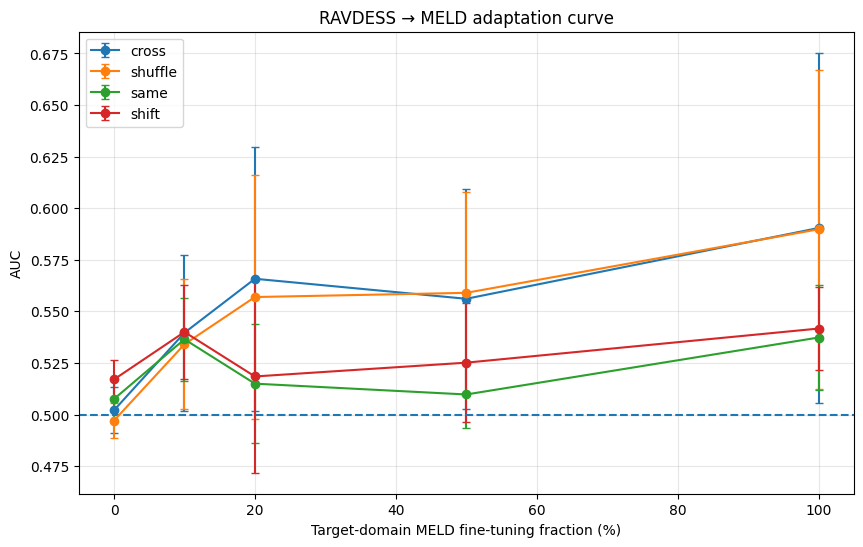

Saved plot: /content/cias_q1_min/results_q1_criticism_suite/plot_adaptation_curve.png


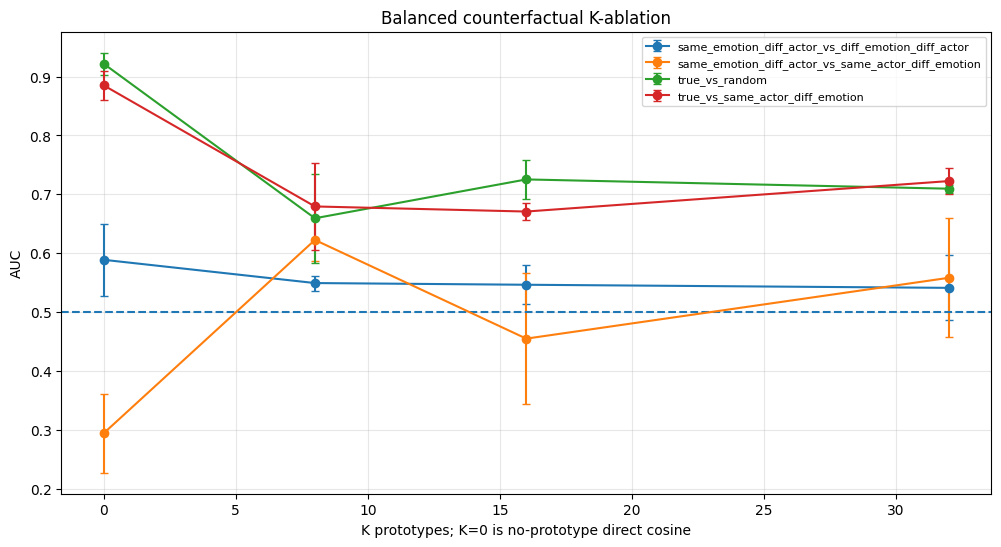

Saved plot: /content/cias_q1_min/results_q1_criticism_suite/plot_balanced_counterfactual_k.png

All outputs saved in: /content/cias_q1_min/results_q1_criticism_suite
DONE.


In [ ]:
!pip -q install scikit-learn pandas tqdm matplotlib openpyxl

import os, re, gc, math, random, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

BASE_DIR = '/content/cias_q1_min'
RAVDESS_SHARD_DIR = f'{BASE_DIR}/shards/RAVDESS'
MELD_SHARD_DIR = f'{BASE_DIR}/shards/MELD'
RESULT_DIR = f'{BASE_DIR}/results_q1_criticism_suite'
os.makedirs(RESULT_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

SEEDS = [42, 43, 44]
K_LIST = [0, 8, 16, 32]
ADAPT_K = 8
EPOCHS = 7
EPOCHS_FT = 5
BATCH_SIZE = 64
LR = 1e-3
LR_FT = 3e-4
HIDDEN = 96
EMBED = 96
TEMP = 0.25
TRAIN_PAIR_MULTIPLIER = 6
N_EVAL_PAIRS = 1500
N_BALANCED_PAIRS_PER_EMOTION = 120
N_PERM = 200
ADAPT_FRACTIONS = [0.0, 0.10, 0.20, 0.50, 1.00]

EMOTION_MAP = {
    '01':'neutral','02':'calm','03':'happy','04':'sad','05':'angry','06':'fearful','07':'disgust','08':'surprised'
}

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def clean_memory():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def load_shards(shard_dir, name):
    files = sorted(Path(shard_dir).glob('*.npz'))
    if not files: raise RuntimeError(f'No shards found in {shard_dir}')
    faces,bodies,vids,subs,dsets=[],[],[],[],[]
    for fp in files:
        z=np.load(fp, allow_pickle=True)
        if 'face' not in z: continue
        faces.append(z['face']); bodies.append(z['body']); vids.append(z['video_ids']); subs.append(z['subject_ids']); dsets.append(z['dataset'])
    data={
        'face':np.concatenate(faces).astype(np.float32),
        'body':np.concatenate(bodies).astype(np.float32),
        'video_ids':np.concatenate(vids).astype(str),
        'subject_ids':np.concatenate(subs).astype(str),
        'dataset':np.concatenate(dsets).astype(str),
    }
    print(f'\n{name} loaded: face {data["face"].shape}, body {data["body"].shape}, videos {len(set(data["video_ids"]))}')
    return data

def parse_ravdess(video_id, fallback_actor=None):
    m=re.search(r'(\d{2}-\d{2}-\d{2}-\d{2}-\d{2}-\d{2}-\d{2})', str(video_id))
    if m is None: return 'unknown', str(fallback_actor)
    p=m.group(1).split('-')
    return p[2], p[6]

def add_ravdess_metadata(data):
    emos,names,actors=[],[],[]
    for vid, sub in zip(data['video_ids'], data['subject_ids']):
        emo,actor=parse_ravdess(vid, sub)
        emos.append(emo); names.append(EMOTION_MAP.get(emo,'unknown')); actors.append(actor)
    data['emotion_codes']=np.array(emos).astype(str)
    data['emotion_names']=np.array(names).astype(str)
    data['actor_ids']=np.array(actors).astype(str)
    return data

def add_meld_metadata(data):
    n=len(data['face'])
    data['actor_ids']=np.array(['unknown']*n)
    data['emotion_codes']=np.array(['unknown']*n)
    data['emotion_names']=np.array(['unknown']*n)
    return data

def subset(data, mask): return {k:v[mask] for k,v in data.items()}
def subset_idx(data, idx): return {k:v[idx] for k,v in data.items()}

def fit_scaler(train):
    fs,bs=StandardScaler(),StandardScaler()
    F,B=train['face'],train['body']
    fs.fit(F.reshape(-1,F.shape[-1])); bs.fit(B.reshape(-1,B.shape[-1]))
    return fs,bs

def apply_scaler(data, fs, bs):
    F,B=data['face'],data['body']
    out=dict(data)
    out['face']=fs.transform(F.reshape(-1,F.shape[-1])).reshape(F.shape).astype(np.float32)
    out['body']=bs.transform(B.reshape(-1,B.shape[-1])).reshape(B.shape).astype(np.float32)
    return out

def split_ravdess_by_actor(data):
    actors=sorted([a for a in set(data['actor_ids']) if a!='unknown'])
    if len(actors)>=24:
        tr=[f'{i:02d}' for i in range(1,17)]; va=[f'{i:02d}' for i in range(17,21)]; te=[f'{i:02d}' for i in range(21,25)]
    else:
        tr=[f'{i:02d}' for i in range(1,9)]; va=['09','10']; te=['11','12']
    a=np.array(data['actor_ids']).astype(str)
    train=subset(data,np.isin(a,tr)); val=subset(data,np.isin(a,va)); test=subset(data,np.isin(a,te))
    print('\nRAVDESS actor split:', len(train['face']), len(val['face']), len(test['face']))
    return train,val,test

def split_by_video(data, val_size=0.1, test_size=0.2, seed=42):
    vids=np.array(sorted(set(data['video_ids'])))
    tr_vids,te_vids=train_test_split(vids,test_size=test_size,random_state=seed)
    tr_vids,va_vids=train_test_split(tr_vids,test_size=val_size,random_state=seed)
    return subset(data,np.isin(data['video_ids'],tr_vids)), subset(data,np.isin(data['video_ids'],va_vids)), subset(data,np.isin(data['video_ids'],te_vids))

def sample_fraction(data, frac, seed):
    if frac<=0: return None
    n=len(data['face']); k=min(max(20,int(n*frac)),n)
    rng=np.random.default_rng(seed); idx=rng.choice(np.arange(n),size=k,replace=False)
    return subset_idx(data,idx)

def auc_pvalue(pos, neg, n_perm=200, seed=42):
    rng=np.random.default_rng(seed)
    scores=np.concatenate([pos,neg]); labels=np.concatenate([np.ones(len(pos)),np.zeros(len(neg))])
    real=roc_auc_score(labels,scores); c=0
    for _ in range(n_perm):
        if roc_auc_score(rng.permutation(labels), scores)>=real: c+=1
    return float(real), float((c+1)/(n_perm+1))

def cohen_d(pos, neg):
    pos,neg=np.asarray(pos),np.asarray(neg)
    if len(pos)<2 or len(neg)<2: return 0.0
    s1,s2=pos.std(ddof=1),neg.std(ddof=1); n1,n2=len(pos),len(neg)
    pooled=np.sqrt(((n1-1)*s1**2+(n2-1)*s2**2)/max(n1+n2-2,1))
    return 0.0 if pooled<1e-9 else float((pos.mean()-neg.mean())/pooled)

class PairDataset(Dataset):
    def __init__(self,data,length):
        self.data=data; self.length=length; self.n=len(data['face']); self.video_ids=np.array(data['video_ids'])
        self.vid_to_idx={}
        for i,v in enumerate(self.video_ids): self.vid_to_idx.setdefault(v,[]).append(i)
        self.videos=list(self.vid_to_idx.keys())
    def __len__(self): return self.length
    def positive(self):
        i=random.randrange(self.n); return i,i,1
    def cross_negative(self):
        i=random.randrange(self.n); vi=self.video_ids[i]
        for _ in range(50):
            j=random.randrange(self.n)
            if self.video_ids[j]!=vi: return i,j,0
        return i,random.randrange(self.n),0
    def same_negative(self):
        possible=[v for v in self.videos if len(self.vid_to_idx[v])>=2]
        if not possible: return self.cross_negative()
        v=random.choice(possible); i,j=random.sample(self.vid_to_idx[v],2); return i,j,0
    def shift_negative(self):
        possible=[v for v in self.videos if len(self.vid_to_idx[v])>=2]
        if not possible: return self.cross_negative()
        v=random.choice(possible); idxs=sorted(self.vid_to_idx[v]); p=random.randrange(len(idxs)); delta=random.choice([-2,-1,1,2])
        p2=min(max(p+delta,0),len(idxs)-1)
        if p==p2: return self.cross_negative()
        return idxs[p],idxs[p2],0
    def mixed_negative(self):
        r=random.choice(['cross','same','shift'])
        return self.cross_negative() if r=='cross' else self.same_negative() if r=='same' else self.shift_negative()
    def __getitem__(self,idx):
        i,j,y=self.positive() if random.random()<0.5 else self.mixed_negative()
        return torch.tensor(self.data['face'][i],dtype=torch.float32), torch.tensor(self.data['body'][j],dtype=torch.float32), torch.tensor([y],dtype=torch.float32)

class PMCIModel(nn.Module):
    def __init__(self,face_dim=30,body_dim=72,k_proto=8):
        super().__init__(); self.k_proto=k_proto
        self.face_gru=nn.GRU(face_dim,HIDDEN,batch_first=True,bidirectional=True)
        self.body_gru=nn.GRU(body_dim,HIDDEN,batch_first=True,bidirectional=True)
        self.face_proj=nn.Sequential(nn.Linear(HIDDEN*2,EMBED),nn.ReLU(),nn.LayerNorm(EMBED))
        self.body_proj=nn.Sequential(nn.Linear(HIDDEN*2,EMBED),nn.ReLU(),nn.LayerNorm(EMBED))
        self.prototypes=nn.Parameter(torch.randn(k_proto,EMBED)*0.02) if k_proto>0 else None
        self.logit_scale=nn.Parameter(torch.tensor(8.0)); self.logit_bias=nn.Parameter(torch.tensor(-4.0))
    def encode_face(self,x):
        _,h=self.face_gru(x); h=torch.cat([h[-2],h[-1]],dim=-1); return F.normalize(self.face_proj(h),dim=-1)
    def encode_body(self,x):
        _,h=self.body_gru(x); h=torch.cat([h[-2],h[-1]],dim=-1); return F.normalize(self.body_proj(h),dim=-1)
    def dist(self,z):
        p=F.normalize(self.prototypes,dim=-1); return F.softmax(torch.matmul(z,p.t())/TEMP,dim=-1)
    def js(self,p,q,eps=1e-8):
        p=p.clamp(min=eps); q=q.clamp(min=eps); m=0.5*(p+q)
        return 0.5*(torch.sum(p*torch.log(p/m),dim=-1)+torch.sum(q*torch.log(q/m),dim=-1))/math.log(2.0)
    def forward(self,face,body):
        zf,zb=self.encode_face(face),self.encode_body(body); emb_cos=torch.sum(zf*zb,dim=-1)
        out={'zf':zf,'zb':zb,'emb_cos':emb_cos,'main_score':emb_cos}
        if self.k_proto>0:
            pf,pb=self.dist(zf),self.dist(zb); js=self.js(pf,pb); ec_js=1.0-js
            symkl=0.5*(torch.sum(pf*torch.log((pf+1e-8)/(pb+1e-8)),dim=-1)+torch.sum(pb*torch.log((pb+1e-8)/(pf+1e-8)),dim=-1))
            out.update({'pf':pf,'pb':pb,'ec_js':ec_js,'prob_cos':F.cosine_similarity(pf,pb,dim=-1),'neg_symkl':-symkl,'main_score':ec_js})
        else:
            out.update({'pf':None,'pb':None,'ec_js':emb_cos,'prob_cos':emb_cos,'neg_symkl':emb_cos})
        out['logit']=(self.logit_scale*out['main_score']+self.logit_bias).unsqueeze(-1)
        return out

@torch.no_grad()
def score_pairs(model,data,pairs,transform='normal',batch_size=256):
    model.eval(); keys=['main_score','ec_js','emb_cos','prob_cos','neg_symkl']; scores={k:[] for k in keys}; labels=[]
    for s in range(0,len(pairs),batch_size):
        batch=pairs[s:s+batch_size]; fi=[x[0] for x in batch]; bj=[x[1] for x in batch]; yy=[x[2] for x in batch]
        face_np=data['face'][fi].copy(); body_np=data['body'][bj].copy()
        if transform=='face_zero': face_np[:]=0.0
        elif transform=='body_zero': body_np[:]=0.0
        elif transform=='face_time_reverse': face_np=face_np[:,::-1,:].copy()
        elif transform=='body_time_reverse': body_np=body_np[:,::-1,:].copy()
        elif transform=='body_batch_shuffle':
            rng=np.random.default_rng(123+s); body_np=body_np[rng.permutation(len(body_np))].copy()
        out=model(torch.tensor(face_np,dtype=torch.float32).to(DEVICE), torch.tensor(body_np,dtype=torch.float32).to(DEVICE))
        for k in keys: scores[k].extend(out[k].detach().cpu().numpy().tolist())
        labels.extend(yy)
    return {k:np.array(v) for k,v in scores.items()}, np.array(labels)

def quick_val_auc(model,val,seed=42,n=600):
    if len(val['face'])<20: return 0.5
    rng=np.random.default_rng(seed); pairs=[]
    for _ in range(n//2):
        i=int(rng.integers(0,len(val['face']))); pairs.append((i,i,1))
    for _ in range(n//2):
        i=int(rng.integers(0,len(val['face']))); j=int(rng.integers(0,len(val['face']))); j=(j+1)%len(val['face']) if i==j else j; pairs.append((i,j,0))
    scores,labels=score_pairs(model,val,pairs); return float(roc_auc_score(labels,scores['main_score']))

def train_model(train,val,k_proto,seed,epochs=EPOCHS,lr=LR,init_model=None,name='model'):
    set_seed(seed); model=init_model.to(DEVICE) if init_model is not None else PMCIModel(train['face'].shape[-1],train['body'].shape[-1],k_proto).to(DEVICE)
    ds=PairDataset(train,length=max(1200,len(train['face'])*TRAIN_PAIR_MULTIPLIER)); dl=DataLoader(ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=0)
    opt=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-4); best_state=None; best_val=-1
    for ep in range(1,epochs+1):
        model.train(); losses=[]
        for face,body,y in dl:
            face,body,y=face.to(DEVICE),body.to(DEVICE),y.to(DEVICE); out=model(face,body); loss=F.binary_cross_entropy_with_logits(out['logit'],y)
            opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),5.0); opt.step(); losses.append(loss.item())
        val_auc=quick_val_auc(model,val,seed=seed+ep)
        print(f'{name} | K={k_proto} | seed={seed} | epoch {ep:02d} | loss={np.mean(losses):.4f} | val_auc={val_auc:.4f}')
        if val_auc>best_val:
            best_val=val_auc; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    if best_state is not None: model.load_state_dict(best_state)
    return model

def make_eval_pairs(data,regime,n_pairs=N_EVAL_PAIRS,seed=42):
    rng=np.random.default_rng(seed); n=len(data['face']); vids=np.array(data['video_ids']); vid_to_idx={}
    for i,v in enumerate(vids): vid_to_idx.setdefault(v,[]).append(i)
    videos=list(vid_to_idx.keys()); pairs=[]
    for _ in range(n_pairs//2):
        i=int(rng.integers(0,n)); pairs.append((i,i,1))
    for _ in range(n_pairs//2):
        if regime=='cross':
            i=int(rng.integers(0,n)); vi=vids[i]; j=int(rng.integers(0,n)); t=0
            while vids[j]==vi and t<50: j=int(rng.integers(0,n)); t+=1
            pairs.append((i,j,0))
        elif regime=='same':
            possible=[v for v in videos if len(vid_to_idx[v])>=2]
            if possible:
                v=rng.choice(possible); i,j=rng.choice(vid_to_idx[v],size=2,replace=False); pairs.append((int(i),int(j),0))
            else:
                i=int(rng.integers(0,n)); j=int(rng.integers(0,n)); pairs.append((i,j,0))
        elif regime=='shift':
            possible=[v for v in videos if len(vid_to_idx[v])>=2]
            if possible:
                v=rng.choice(possible); idxs=sorted(vid_to_idx[v]); p=int(rng.integers(0,len(idxs))); delta=int(rng.choice([-2,-1,1,2])); p2=min(max(p+delta,0),len(idxs)-1); p2=(p+1)%len(idxs) if p==p2 else p2; pairs.append((idxs[p],idxs[p2],0))
            else:
                i=int(rng.integers(0,n)); j=int(rng.integers(0,n)); pairs.append((i,j,0))
        elif regime=='shuffle':
            i=int(rng.integers(0,n)); j=int(rng.integers(0,n)); j=(j+1)%n if i==j else j; pairs.append((i,j,0))
    random.shuffle(pairs); return pairs

def evaluate_regimes(model,data,seed,experiment,train_name,test_name,k_proto):
    rows=[]
    for regime in ['cross','same','shift','shuffle']:
        pairs=make_eval_pairs(data,regime,N_EVAL_PAIRS,seed); scores,labels=score_pairs(model,data,pairs)
        for score_name in ['main_score','ec_js','emb_cos','prob_cos','neg_symkl']:
            rows.append({'experiment':experiment,'train':train_name,'test':test_name,'seed':seed,'k_proto':k_proto,'regime':regime,'score':score_name,'auc':float(roc_auc_score(labels,scores[score_name])),'pos_mean':float(scores[score_name][labels==1].mean()),'neg_mean':float(scores[score_name][labels==0].mean())})
    return rows

def evaluate_dropout_controls(model,data,seed,k_proto,dataset_name):
    rows=[]; pairs=make_eval_pairs(data,'cross',N_EVAL_PAIRS,seed)
    for transform in ['normal','face_zero','body_zero','face_time_reverse','body_time_reverse','body_batch_shuffle']:
        scores,labels=score_pairs(model,data,pairs,transform=transform)
        for score_name in ['main_score','ec_js','emb_cos','prob_cos','neg_symkl']:
            rows.append({'dataset':dataset_name,'seed':seed,'k_proto':k_proto,'control':transform,'score':score_name,'auc':float(roc_auc_score(labels,scores[score_name])),'pos_mean':float(scores[score_name][labels==1].mean()),'neg_mean':float(scores[score_name][labels==0].mean())})
    return rows

@torch.no_grad()
def extract_embeddings(model,data,batch_size=256):
    model.eval(); zf_all=[]; zb_all=[]
    for s in range(0,len(data['face']),batch_size):
        face=torch.tensor(data['face'][s:s+batch_size],dtype=torch.float32).to(DEVICE); body=torch.tensor(data['body'][s:s+batch_size],dtype=torch.float32).to(DEVICE)
        out=model(face,body); zf_all.append(out['zf'].detach().cpu().numpy()); zb_all.append(out['zb'].detach().cpu().numpy())
    zf=np.concatenate(zf_all); zb=np.concatenate(zb_all); return zf,zb,np.concatenate([zf,zb],axis=1)

def identity_leakage_test(model,data,seed,k_proto):
    actors=np.array(data['actor_ids']).astype(str); valid=actors!='unknown'; actors=actors[valid]
    if len(set(actors))<2: return []
    d=subset(data,valid); zf,zb,zcat=extract_embeddings(model,d); rows=[]
    for emb_name,X in [('face_embedding',zf),('body_embedding',zb),('concat_face_body',zcat)]:
        X_train,X_test,y_train,y_test=train_test_split(X,actors,test_size=0.3,random_state=seed,stratify=actors)
        clf=LogisticRegression(max_iter=1000,n_jobs=-1); clf.fit(X_train,y_train); pred=clf.predict(X_test)
        rows.append({'seed':seed,'k_proto':k_proto,'embedding':emb_name,'accuracy':float(accuracy_score(y_test,pred)),'balanced_accuracy':float(balanced_accuracy_score(y_test,pred)),'n_classes':len(set(actors)),'n_samples':len(actors)})
    return rows

class BalancedCounterfactualSampler:
    def __init__(self,data):
        self.data=data; self.n=len(data['face']); self.idx=np.arange(self.n); self.emotions=np.array(data['emotion_names']).astype(str); self.actors=np.array(data['actor_ids']).astype(str); self.videos=np.array(data['video_ids']).astype(str)
        self.valid_emotions=[e for e in sorted(set(self.emotions)) if e!='unknown' and np.sum(self.emotions==e)>=4]
    def choose_j(self,i,same_emotion=None,same_actor=None):
        candidates=self.idx.copy()
        if same_emotion is True: candidates=candidates[self.emotions[candidates]==self.emotions[i]]
        elif same_emotion is False: candidates=candidates[self.emotions[candidates]!=self.emotions[i]]
        if same_actor is True: candidates=candidates[self.actors[candidates]==self.actors[i]]
        elif same_actor is False: candidates=candidates[self.actors[candidates]!=self.actors[i]]
        candidates=candidates[self.videos[candidates]!=self.videos[i]]
        return None if len(candidates)==0 else int(np.random.choice(candidates))
    def make_regime_pairs(self,regime,per_emotion=100):
        pairs=[]
        for emo in self.valid_emotions:
            base_idx=self.idx[self.emotions==emo]; made=0; tries=0
            while made<per_emotion and tries<per_emotion*80:
                tries+=1; i=int(np.random.choice(base_idx))
                if regime=='true_pair': pairs.append((i,i,1)); made+=1; continue
                if regime=='same_emotion_diff_actor': j=self.choose_j(i,True,False); label=1
                elif regime=='same_actor_diff_emotion': j=self.choose_j(i,False,True); label=0
                elif regime=='diff_emotion_diff_actor': j=self.choose_j(i,False,False); label=0
                elif regime=='random_diff_video': j=self.choose_j(i,None,None); label=0
                else: raise ValueError(regime)
                if j is not None: pairs.append((i,j,label)); made+=1
        return pairs

def balanced_counterfactual_test(model,data,seed,k_proto):
    set_seed(seed); sampler=BalancedCounterfactualSampler(data); score_bank={}
    for reg in ['true_pair','same_emotion_diff_actor','same_actor_diff_emotion','diff_emotion_diff_actor','random_diff_video']:
        pairs=sampler.make_regime_pairs(reg,per_emotion=N_BALANCED_PAIRS_PER_EMOTION)
        if len(pairs)>=20: score_bank[reg]=score_pairs(model,data,pairs)[0]
    comps=[('true_vs_random','true_pair','random_diff_video'),('true_vs_same_actor_diff_emotion','true_pair','same_actor_diff_emotion'),('same_emotion_diff_actor_vs_same_actor_diff_emotion','same_emotion_diff_actor','same_actor_diff_emotion'),('same_emotion_diff_actor_vs_diff_emotion_diff_actor','same_emotion_diff_actor','diff_emotion_diff_actor')]
    rows=[]
    for comp,pos_reg,neg_reg in comps:
        if pos_reg not in score_bank or neg_reg not in score_bank: continue
        for score_name in ['main_score','ec_js','emb_cos','prob_cos','neg_symkl']:
            pos=score_bank[pos_reg][score_name]; neg=score_bank[neg_reg][score_name]; auc,p=auc_pvalue(pos,neg,N_PERM,seed)
            rows.append({'seed':seed,'k_proto':k_proto,'comparison':comp,'score':score_name,'auc':auc,'p_perm':p,'cohen_d':cohen_d(pos,neg),'pos_mean':float(np.mean(pos)),'neg_mean':float(np.mean(neg)),'n_pos':len(pos),'n_neg':len(neg)})
    return rows

@torch.no_grad()
def prototype_usage(model,data,seed,k_proto,dataset_name):
    if k_proto<=0: return []
    model.eval(); pf_all=[]; pb_all=[]
    for s in range(0,len(data['face']),256):
        face=torch.tensor(data['face'][s:s+256],dtype=torch.float32).to(DEVICE); body=torch.tensor(data['body'][s:s+256],dtype=torch.float32).to(DEVICE)
        out=model(face,body); pf_all.append(out['pf'].detach().cpu().numpy()); pb_all.append(out['pb'].detach().cpu().numpy())
    rows=[]
    for modality,P in [('face',np.concatenate(pf_all)),('body',np.concatenate(pb_all))]:
        mean_usage=P.mean(axis=0); entropy=-np.sum(mean_usage*np.log(mean_usage+1e-12)); norm_entropy=entropy/math.log(k_proto)
        rows.append({'dataset':dataset_name,'seed':seed,'k_proto':k_proto,'modality':modality,'usage_entropy':float(entropy),'usage_entropy_norm':float(norm_entropy),'effective_prototypes':float(np.exp(entropy)),'max_usage':float(mean_usage.max()),'min_usage':float(mean_usage.min()),'usage_vector':','.join([f'{x:.5f}' for x in mean_usage])})
    return rows

rav_raw=add_ravdess_metadata(load_shards(RAVDESS_SHARD_DIR,'RAVDESS'))
meld_raw=add_meld_metadata(load_shards(MELD_SHARD_DIR,'MELD'))
rav_train_raw,rav_val_raw,rav_test_raw=split_ravdess_by_actor(rav_raw)
meld_train_raw,meld_val_raw,meld_test_raw=split_by_video(meld_raw,seed=42)
print('\nEmotion distribution in RAVDESS:'); print(pd.Series(rav_raw['emotion_names']).value_counts())

all_main_rows=[]; all_dropout_rows=[]; all_identity_rows=[]; all_cf_rows=[]; all_proto_rows=[]

for seed in SEEDS:
    print('\n'+'#'*100); print('SEED:',seed); print('#'*100)
    source_fs,source_bs=fit_scaler(rav_train_raw)
    rav_train=apply_scaler(rav_train_raw,source_fs,source_bs); rav_val=apply_scaler(rav_val_raw,source_fs,source_bs); rav_test=apply_scaler(rav_test_raw,source_fs,source_bs)
    meld_train_source=apply_scaler(meld_train_raw,source_fs,source_bs); meld_val_source=apply_scaler(meld_val_raw,source_fs,source_bs); meld_test_source=apply_scaler(meld_test_raw,source_fs,source_bs)

    for k_proto in K_LIST:
        print('\n'+'='*90); print(f'RAVDESS actor-level | seed={seed} | K={k_proto}'); print('='*90)
        model=train_model(rav_train,rav_val,k_proto,seed,EPOCHS,LR,name='rav_actor')
        all_main_rows+=evaluate_regimes(model,rav_test,seed,'ravdess_actor_level','RAVDESS','RAVDESS',k_proto)
        all_dropout_rows+=evaluate_dropout_controls(model,rav_test,seed,k_proto,'RAVDESS')
        all_identity_rows+=identity_leakage_test(model,apply_scaler(rav_raw,source_fs,source_bs),seed,k_proto)
        all_cf_rows+=balanced_counterfactual_test(model,rav_test,seed,k_proto)
        all_proto_rows+=prototype_usage(model,rav_test,seed,k_proto,'RAVDESS')
        clean_memory()

    print('\n'+'='*90); print(f'ADAPTATION CURVE | seed={seed} | K={ADAPT_K}'); print('='*90)
    source_model=train_model(rav_train,rav_val,ADAPT_K,seed,EPOCHS,LR,name='source_ravdess')
    source_state={k:v.detach().cpu().clone() for k,v in source_model.state_dict().items()}
    for frac in ADAPT_FRACTIONS:
        print('\n'+'-'*80); print(f'RAVDESS -> MELD adaptation frac={frac}'); print('-'*80)
        model_ft=PMCIModel(rav_train['face'].shape[-1],rav_train['body'].shape[-1],ADAPT_K).to(DEVICE); model_ft.load_state_dict(source_state)
        if frac>0:
            ft_train=sample_fraction(meld_train_source,frac,seed+int(frac*1000))
            model_ft=train_model(ft_train,meld_val_source,ADAPT_K,seed,EPOCHS_FT,LR_FT,init_model=model_ft,name=f'ft_meld_{frac}')
        exp_name=f'ravdess_to_meld_adapt_{int(frac*100)}pct'
        all_main_rows+=evaluate_regimes(model_ft,meld_test_source,seed,exp_name,f'RAVDESS+{int(frac*100)}%MELD','MELD',ADAPT_K)
        all_dropout_rows+=evaluate_dropout_controls(model_ft,meld_test_source,seed,ADAPT_K,f'MELD_adapt_{int(frac*100)}pct')
        all_proto_rows+=prototype_usage(model_ft,meld_test_source,seed,ADAPT_K,f'MELD_adapt_{int(frac*100)}pct')
        clean_memory()

    print('\n'+'='*90); print(f'MELD within baseline | seed={seed} | K={ADAPT_K}'); print('='*90)
    meld_fs,meld_bs=fit_scaler(meld_train_raw)
    meld_train=apply_scaler(meld_train_raw,meld_fs,meld_bs); meld_val=apply_scaler(meld_val_raw,meld_fs,meld_bs); meld_test=apply_scaler(meld_test_raw,meld_fs,meld_bs)
    meld_model=train_model(meld_train,meld_val,ADAPT_K,seed,EPOCHS,LR,name='meld_within')
    all_main_rows+=evaluate_regimes(meld_model,meld_test,seed,'meld_within','MELD','MELD',ADAPT_K)
    all_dropout_rows+=evaluate_dropout_controls(meld_model,meld_test,seed,ADAPT_K,'MELD')
    all_proto_rows+=prototype_usage(meld_model,meld_test,seed,ADAPT_K,'MELD')
    clean_memory()

main_df=pd.DataFrame(all_main_rows)
dropout_df=pd.DataFrame(all_dropout_rows)
identity_df=pd.DataFrame(all_identity_rows)
cf_df=pd.DataFrame(all_cf_rows)
proto_df=pd.DataFrame(all_proto_rows)

paths={
    'main': os.path.join(RESULT_DIR,'main_multiseed_results.csv'),
    'dropout': os.path.join(RESULT_DIR,'modality_dropout_controls.csv'),
    'identity': os.path.join(RESULT_DIR,'identity_leakage_classifier.csv'),
    'cf': os.path.join(RESULT_DIR,'balanced_counterfactual_results.csv'),
    'proto': os.path.join(RESULT_DIR,'prototype_usage_entropy.csv'),
}
main_df.to_csv(paths['main'],index=False); dropout_df.to_csv(paths['dropout'],index=False); identity_df.to_csv(paths['identity'],index=False); cf_df.to_csv(paths['cf'],index=False); proto_df.to_csv(paths['proto'],index=False)
print('\nSaved raw CSVs:'); [print(v) for v in paths.values()]

main_pmci=main_df[main_df['score']=='main_score'].copy()
main_summary=main_pmci.groupby(['experiment','train','test','k_proto','regime']).agg(auc_mean=('auc','mean'),auc_std=('auc','std'),pos_mean=('pos_mean','mean'),neg_mean=('neg_mean','mean')).reset_index()
main_summary.to_csv(os.path.join(RESULT_DIR,'summary_main_auc_mean_std.csv'),index=False)
print('\nMAIN AUC SUMMARY'); display(main_summary)

adapt_summary=main_summary[main_summary['experiment'].str.contains('adapt',regex=False)].copy()
adapt_pivot=adapt_summary.pivot_table(index=['experiment','train','test','k_proto'],columns='regime',values='auc_mean').reset_index()
adapt_pivot.to_csv(os.path.join(RESULT_DIR,'summary_adaptation_curve.csv'),index=False)
print('\nADAPTATION CURVE'); display(adapt_pivot)

drop_pmci=dropout_df[dropout_df['score']=='main_score'].copy()
drop_summary=drop_pmci.groupby(['dataset','k_proto','control']).agg(auc_mean=('auc','mean'),auc_std=('auc','std'),pos_mean=('pos_mean','mean'),neg_mean=('neg_mean','mean')).reset_index()
drop_summary.to_csv(os.path.join(RESULT_DIR,'summary_dropout_controls.csv'),index=False)
print('\nDROPOUT CONTROL SUMMARY'); display(drop_summary)

if len(identity_df)>0:
    identity_summary=identity_df.groupby(['k_proto','embedding']).agg(acc_mean=('accuracy','mean'),acc_std=('accuracy','std'),bal_acc_mean=('balanced_accuracy','mean'),bal_acc_std=('balanced_accuracy','std'),n_classes=('n_classes','max'),n_samples=('n_samples','max')).reset_index()
    identity_summary.to_csv(os.path.join(RESULT_DIR,'summary_identity_leakage.csv'),index=False)
    print('\nIDENTITY LEAKAGE SUMMARY'); display(identity_summary)

if len(cf_df)>0:
    cf_main=cf_df[cf_df['score']=='main_score'].copy()
    cf_summary=cf_main.groupby(['k_proto','comparison']).agg(auc_mean=('auc','mean'),auc_std=('auc','std'),p_mean=('p_perm','mean'),d_mean=('cohen_d','mean'),pos_mean=('pos_mean','mean'),neg_mean=('neg_mean','mean')).reset_index()
    cf_summary.to_csv(os.path.join(RESULT_DIR,'summary_balanced_counterfactual.csv'),index=False)
    cf_pivot=cf_summary.pivot_table(index='comparison',columns='k_proto',values='auc_mean').reset_index()
    cf_pivot.to_csv(os.path.join(RESULT_DIR,'summary_balanced_counterfactual_pivot.csv'),index=False)
    print('\nBALANCED COUNTERFACTUAL SUMMARY'); display(cf_summary)
    print('\nBALANCED COUNTERFACTUAL PIVOT'); display(cf_pivot)

if len(proto_df)>0:
    proto_summary=proto_df.groupby(['dataset','k_proto','modality']).agg(entropy_mean=('usage_entropy_norm','mean'),entropy_std=('usage_entropy_norm','std'),effective_k_mean=('effective_prototypes','mean'),max_usage_mean=('max_usage','mean'),min_usage_mean=('min_usage','mean')).reset_index()
    proto_summary.to_csv(os.path.join(RESULT_DIR,'summary_prototype_usage.csv'),index=False)
    print('\nPROTOTYPE USAGE SUMMARY'); display(proto_summary)

# Basic article figures
try:
    plot_df=adapt_summary[adapt_summary['regime'].isin(['cross','shuffle','same','shift'])].copy()
    def frac_from_exp(x):
        m=re.search(r'adapt_(\d+)pct',x); return int(m.group(1)) if m else None
    plot_df['fraction']=plot_df['experiment'].apply(frac_from_exp)
    plt.figure(figsize=(10,6))
    for reg in ['cross','shuffle','same','shift']:
        sub=plot_df[plot_df['regime']==reg].sort_values('fraction')
        if len(sub)>0: plt.errorbar(sub['fraction'],sub['auc_mean'],yerr=sub['auc_std'],marker='o',capsize=3,label=reg)
    plt.axhline(0.5,linestyle='--'); plt.xlabel('Target-domain MELD fine-tuning fraction (%)'); plt.ylabel('AUC'); plt.title('RAVDESS → MELD adaptation curve'); plt.legend(); plt.grid(alpha=0.3)
    p=os.path.join(RESULT_DIR,'plot_adaptation_curve.png'); plt.savefig(p,dpi=200,bbox_inches='tight'); plt.show(); print('Saved plot:',p)
except Exception as e: print('Plot adaptation failed:',e)

try:
    if len(cf_df)>0:
        plt.figure(figsize=(12,6))
        for comp in cf_summary['comparison'].unique():
            sub=cf_summary[cf_summary['comparison']==comp].sort_values('k_proto')
            plt.errorbar(sub['k_proto'],sub['auc_mean'],yerr=sub['auc_std'],marker='o',capsize=3,label=comp)
        plt.axhline(0.5,linestyle='--'); plt.xlabel('K prototypes; K=0 is no-prototype direct cosine'); plt.ylabel('AUC'); plt.title('Balanced counterfactual K-ablation'); plt.legend(fontsize=8); plt.grid(alpha=0.3)
        p=os.path.join(RESULT_DIR,'plot_balanced_counterfactual_k.png'); plt.savefig(p,dpi=200,bbox_inches='tight'); plt.show(); print('Saved plot:',p)
except Exception as e: print('Plot counterfactual failed:',e)

print('\nAll outputs saved in:', RESULT_DIR)
print('DONE.')


In [ ]:
# ============================================================
# REBUILD MELD SHARD EXACTLY 402 WINDOWS
# Uses already extracted MELD videos
# ============================================================

import os, gc
import numpy as np
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO
import torch

MELD_TMP_ROOT = "/content/cias_q1_min/raw/MELD"
MELD_SHARD_DIR = "/content/cias_q1_min/shards/MELD"
TARGET_WINDOWS = 402
MAX_SCAN_CLIPS = 1200

Path(MELD_SHARD_DIR).mkdir(parents=True, exist_ok=True)

# удалить старые MELD shards
for fp in Path(MELD_SHARD_DIR).glob("*.npz"):
    os.remove(fp)

done_file = f"{MELD_SHARD_DIR}/_MELD_DONE.txt"
if os.path.exists(done_file):
    os.remove(done_file)

videos = sorted([
    str(p) for p in Path(MELD_TMP_ROOT).rglob("*")
    if p.suffix.lower() in [".mp4", ".avi", ".mov", ".mkv", ".webm"]
])

print("Total MELD videos found:", len(videos))
videos = videos[:MAX_SCAN_CLIPS]
print("Scanning clips:", len(videos))

model = YOLO("yolov8n-pose.pt")

faces = []
bodies = []
video_ids = []
subject_ids = []
datasets = []

for idx, vp in enumerate(tqdm(videos, desc="MELD -> 402 windows")):
    try:
        Fw, Bw = process_video(vp, model)

        if len(Fw) == 0:
            continue

        rel = os.path.relpath(vp, MELD_TMP_ROOT)

        for i in range(len(Fw)):
            if len(faces) >= TARGET_WINDOWS:
                break

            faces.append(Fw[i].astype(np.float32))
            bodies.append(Bw[i].astype(np.float32))
            video_ids.append(f"meld_{idx}_{rel}")
            subject_ids.append("unknown")
            datasets.append("MELD")

        if len(faces) >= TARGET_WINDOWS:
            break

    except Exception as e:
        print("Skip:", vp, str(e)[:120])

    if idx % 50 == 0:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("Collected windows:", len(faces))

if len(faces) < TARGET_WINDOWS:
    raise RuntimeError(f"Only collected {len(faces)} windows, target is {TARGET_WINDOWS}. Increase MAX_SCAN_CLIPS.")

out_path = f"{MELD_SHARD_DIR}/MELD_shard_00000.npz"

np.savez_compressed(
    out_path,
    face=np.stack(faces).astype(np.float32),
    body=np.stack(bodies).astype(np.float32),
    video_ids=np.array(video_ids).astype(str),
    subject_ids=np.array(subject_ids).astype(str),
    dataset=np.array(datasets).astype(str),
)

print("Saved:", out_path)
print("face:", np.stack(faces).shape)
print("body:", np.stack(bodies).shape)

# final check
z = np.load(out_path, allow_pickle=True)
print("CHECK face:", z["face"].shape)
print("CHECK body:", z["body"].shape)
print("CHECK videos:", len(set(z["video_ids"])))

Total MELD videos found: 15908
Scanning clips: 1200


MELD -> 402 windows:  67%|██████▋   | 802/1200 [06:14<03:05,  2.14it/s]

Collected windows: 402
Saved: /content/cias_q1_min/shards/MELD/MELD_shard_00000.npz
face: (402, 12, 30)
body: (402, 12, 72)
CHECK face: (402, 12, 30)
CHECK body: (402, 12, 72)
CHECK videos: 223


Device: cuda
RAVDESS loaded: face (672, 12, 30), body (672, 12, 72), videos 672
MELD loaded: face (402, 12, 30), body (402, 12, 72), videos 223

RAVDESS emotion distribution:
angry        144
disgust      144
calm         130
happy         80
sad           78
fearful       46
surprised     36
neutral       14
Name: count, dtype: int64
RAVDESS actor split: 500 82 90
Video split: 288 58 56

####################################################################################################
SEED: 42
####################################################################################################

TRAIN RAVDESS PMCI / DIRECT | seed=42 | K=0
ravdess_pmci | K=0 | seed=42 | epoch 01 | loss=0.4264 | val_auc=0.7130
ravdess_pmci | K=0 | seed=42 | epoch 02 | loss=0.2909 | val_auc=0.7524
ravdess_pmci | K=0 | seed=42 | epoch 03 | loss=0.2389 | val_auc=0.8247
ravdess_pmci | K=0 | seed=42 | epoch 04 | loss=0.2177 | val_auc=0.8583
ravdess_pmci | K=0 | seed=42 | epoch 05 | loss=0.1905 | val_auc=0.84

,dataset,model,regime,score_name,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,accuracy_mean,accuracy_std,...,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,specificity_mean,specificity_std
0,MELD,PMCI_K8_MELD,cross,emb_cos,0.810587,0.047321,0.779800,0.055507,0.711310,0.037410,...,0.694907,0.067475,0.797619,0.122278,0.731636,0.036837,0.444268,0.068214,0.625000,0.153613
1,MELD,PMCI_K8_MELD,cross,hellinger,0.799639,0.035810,0.742507,0.024323,0.747024,0.023435,...,0.692780,0.026808,0.892857,0.043741,0.779155,0.018628,0.519016,0.047000,0.601190,0.058926
2,MELD,PMCI_K8_MELD,cross,main,0.800489,0.034222,0.747284,0.028274,0.747024,0.023435,...,0.689755,0.019467,0.898810,0.036693,0.780214,0.021408,0.519707,0.051307,0.595238,0.033672
3,MELD,PMCI_K8_MELD,cross,neg_euclidean,0.810587,0.047321,0.779800,0.055507,0.711310,0.037410,...,0.694907,0.067475,0.797619,0.122278,0.731636,0.036837,0.444268,0.068214,0.625000,0.153613
4,MELD,PMCI_K8_MELD,cross,neg_symkl,0.797938,0.037983,0.741485,0.024549,0.752976,0.027600,...,0.694646,0.032671,0.910714,0.038576,0.786917,0.018148,0.535762,0.047001,0.595238,0.073386
5,MELD,PMCI_K8_MELD,cross,pmci,0.800489,0.034222,0.747284,0.028274,0.747024,0.023435,...,0.689755,0.019467,0.898810,0.036693,0.780214,0.021408,0.519707,0.051307,0.595238,0.033672
6,MELD,PMCI_K8_MELD,cross,prob_cos,0.786777,0.027653,0.727605,0.015465,0.741071,0.025254,...,0.691499,0.014226,0.869048,0.046869,0.769936,0.027065,0.499960,0.057388,0.613095,0.008418
7,MELD,PMCI_K8_MELD,same,emb_cos,0.697385,0.027862,0.669919,0.027582,0.642857,0.014580,...,0.592478,0.010475,0.916667,0.036693,0.719434,0.013750,0.344277,0.039324,0.369048,0.036693
8,MELD,PMCI_K8_MELD,same,hellinger,0.697704,0.033724,0.670997,0.031544,0.645833,0.008418,...,0.598092,0.013719,0.898810,0.060703,0.716857,0.008929,0.346659,0.019412,0.392857,0.077152
9,MELD,PMCI_K8_MELD,same,main,0.698236,0.035796,0.668790,0.034402,0.648810,0.011136,...,0.600769,0.016383,0.898810,0.060703,0.718642,0.007076,0.352211,0.015012,0.398810,0.082907



IDENTITY SUMMARY:


,model,embedding,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std
0,DirectCosine_K0,body_embedding,0.903955,0.010570,0.894504,0.009968
1,DirectCosine_K0,concat_face_body,0.918079,0.016350,0.906162,0.023051
2,DirectCosine_K0,face_embedding,0.885593,0.006919,0.880207,0.006875
3,LateFusionMLP,body_embedding,0.913842,0.015601,0.907340,0.021538
4,LateFusionMLP,concat_face_body,0.939266,0.015980,0.930118,0.017725
5,LateFusionMLP,face_embedding,0.894068,0.012474,0.884171,0.019039
6,PMCI_K16,body_embedding,0.853107,0.005285,0.842925,0.013704
7,PMCI_K16,concat_face_body,0.908192,0.022510,0.899071,0.031683
8,PMCI_K16,face_embedding,0.846045,0.021139,0.838379,0.031370
9,PMCI_K32,body_embedding,0.854520,0.017754,0.840523,0.031276



COUNTERFACTUAL SUMMARY HEAD:


,model,score_name,comparison,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,accuracy_mean,accuracy_std,balanced_accuracy_mean,...,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,specificity_mean,specificity_std
0,DirectCosine_K0,emb_cos,same_emotion_diff_actor_vs_diff_emotion_diff_a...,0.545966,0.017453,0.551122,0.007655,0.498512,0.002430,0.498512,...,0.499248,0.001228,0.988095,0.002430,0.663337,0.001631,-0.014657,0.023935,0.008929,0.002430
1,DirectCosine_K0,emb_cos,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.275658,0.013942,0.372156,0.006336,0.490079,0.000701,0.490079,...,0.494987,0.000354,0.979663,0.000701,0.657676,0.000471,-0.097712,0.006909,0.000496,0.000701
2,DirectCosine_K0,emb_cos,true_pair_vs_random_mismatch,0.980529,0.003197,0.979331,0.003129,0.933284,0.013105,0.933284,...,0.933707,0.014035,0.933036,0.022503,0.933184,0.013406,0.866906,0.026122,0.933532,0.015192
3,DirectCosine_K0,emb_cos,true_pair_vs_same_actor_diff_emotion,0.934518,0.006526,0.930319,0.004203,0.865823,0.005167,0.865823,...,0.844149,0.034808,0.902282,0.044978,0.870443,0.003612,0.737184,0.004256,0.829365,0.053466
4,DirectCosine_K0,main,same_emotion_diff_actor_vs_diff_emotion_diff_a...,0.545966,0.017453,0.551122,0.007655,0.498512,0.002430,0.498512,...,0.499248,0.001228,0.988095,0.002430,0.663337,0.001631,-0.014657,0.023935,0.008929,0.002430
5,DirectCosine_K0,main,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.275658,0.013942,0.372156,0.006336,0.490079,0.000701,0.490079,...,0.494987,0.000354,0.979663,0.000701,0.657676,0.000471,-0.097712,0.006909,0.000496,0.000701
6,DirectCosine_K0,main,true_pair_vs_random_mismatch,0.980529,0.003197,0.979331,0.003129,0.933284,0.013105,0.933284,...,0.933707,0.014035,0.933036,0.022503,0.933184,0.013406,0.866906,0.026122,0.933532,0.015192
7,DirectCosine_K0,main,true_pair_vs_same_actor_diff_emotion,0.934518,0.006526,0.930319,0.004203,0.865823,0.005167,0.865823,...,0.844149,0.034808,0.902282,0.044978,0.870443,0.003612,0.737184,0.004256,0.829365,0.053466
8,DirectCosine_K0,neg_euclidean,same_emotion_diff_actor_vs_diff_emotion_diff_a...,0.545966,0.017453,0.551122,0.007655,0.498512,0.002430,0.498512,...,0.499248,0.001228,0.988095,0.002430,0.663337,0.001631,-0.014657,0.023935,0.008929,0.002430
9,DirectCosine_K0,neg_euclidean,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.275658,0.013942,0.372157,0.006336,0.490079,0.000701,0.490079,...,0.494987,0.000354,0.979663,0.000701,0.657676,0.000471,-0.097712,0.006909,0.000496,0.000701



RUNTIME SUMMARY:


,model,params_mean,params_std,mean_window_time_ms_mean,mean_window_time_ms_std
0,DirectCosine_K0,104832.0,0.0,0.028458,0.003444
1,LateFusionMLP,162433.0,0.0,0.030131,0.003855
2,PMCI_K16,106368.0,0.0,0.036278,0.002911
3,PMCI_K32,107904.0,0.0,0.034536,0.001464
4,PMCI_K8,105600.0,0.0,0.038669,0.006278



Paper-ready tables:
/content/cias_q1_min/results_q1_revision_addon/paper_table_extended_metrics_ravdess_cross.csv
/content/cias_q1_min/results_q1_revision_addon/paper_table_score_baselines.csv
/content/cias_q1_min/results_q1_revision_addon/paper_table_counterfactual_key_comparison.csv


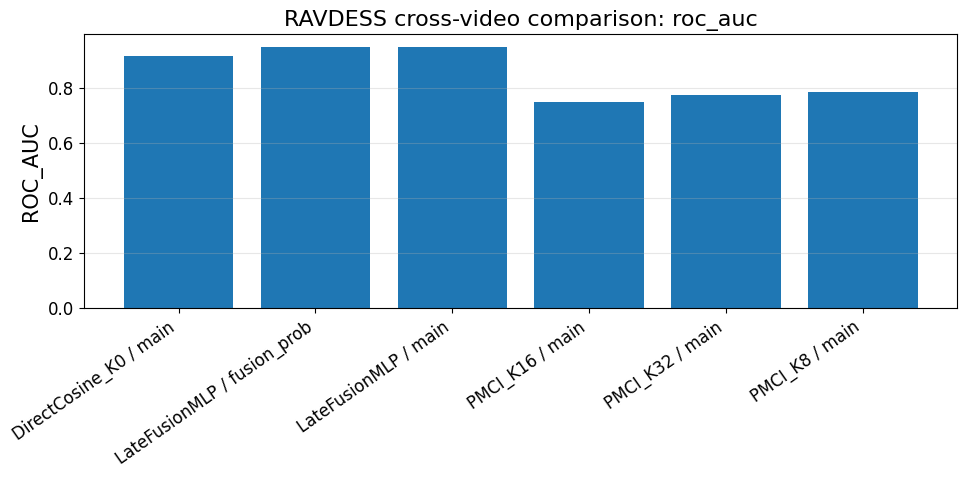

Saved figure: /content/cias_q1_min/results_q1_revision_addon/figures/fig_ravdess_cross_roc_auc_mean.png


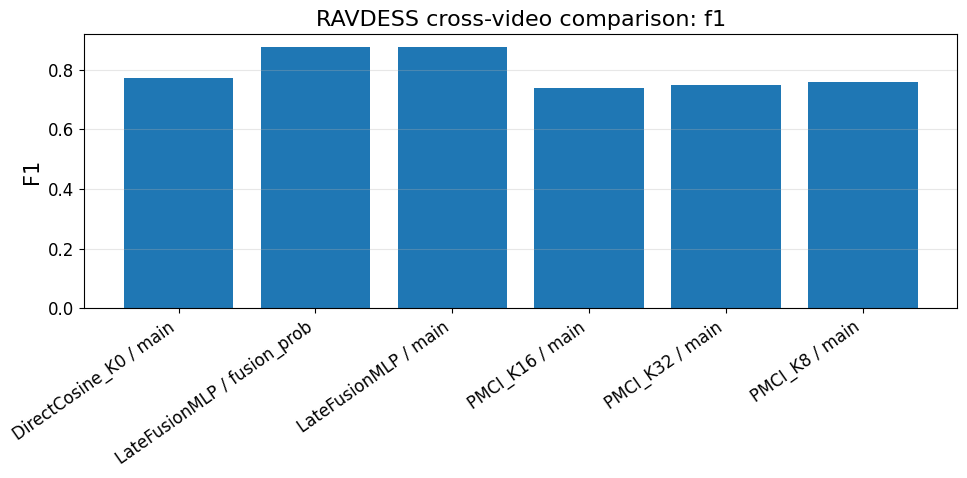

Saved figure: /content/cias_q1_min/results_q1_revision_addon/figures/fig_ravdess_cross_f1_mean.png


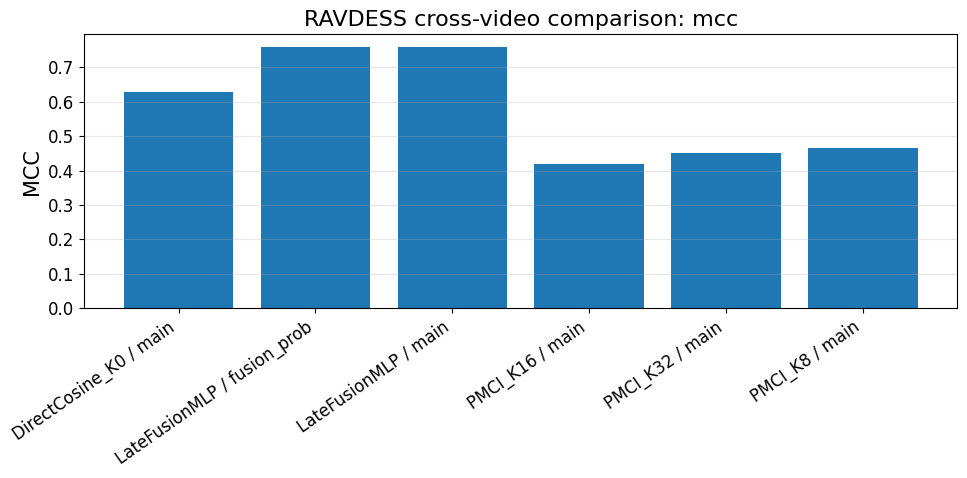

Saved figure: /content/cias_q1_min/results_q1_revision_addon/figures/fig_ravdess_cross_mcc_mean.png


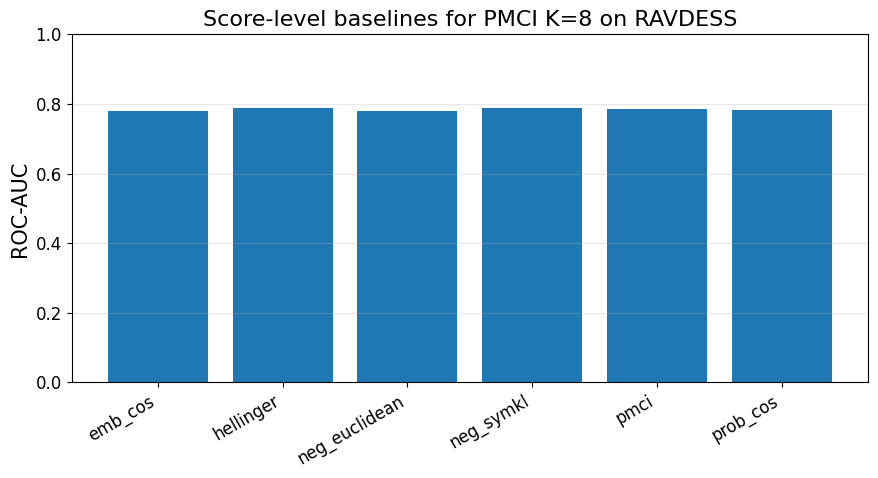

Saved figure: /content/cias_q1_min/results_q1_revision_addon/figures/fig_score_baselines_pmci_k8.png


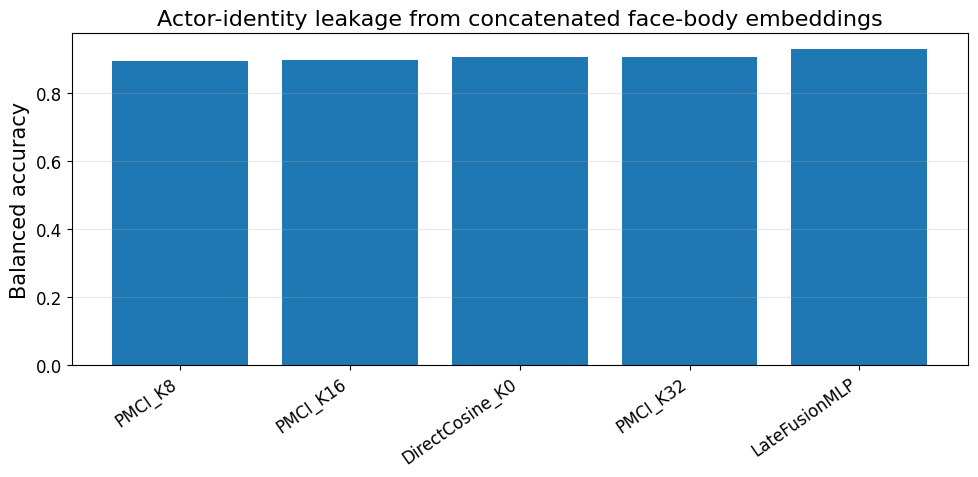

Saved figure: /content/cias_q1_min/results_q1_revision_addon/figures/fig_identity_leakage_extended.png


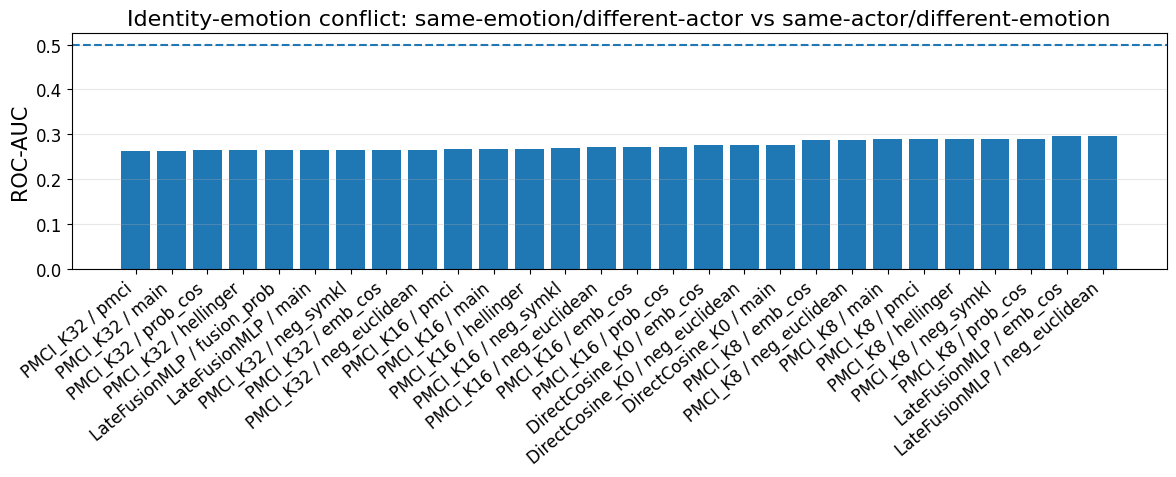

Saved figure: /content/cias_q1_min/results_q1_revision_addon/figures/fig_counterfactual_identity_emotion_conflict.png


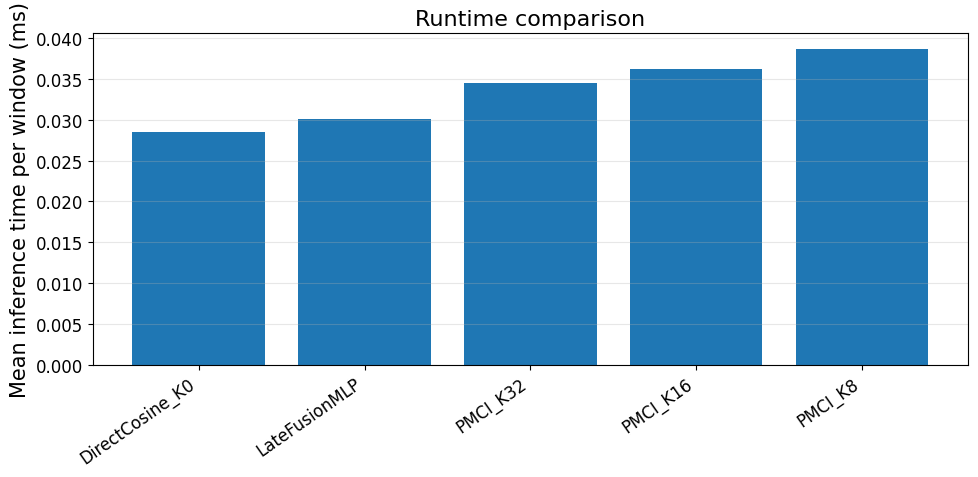

Saved figure: /content/cias_q1_min/results_q1_revision_addon/figures/fig_runtime_comparison.png

README saved: /content/cias_q1_min/results_q1_revision_addon/README_revision_addon.md

DONE.
All results saved to: /content/cias_q1_min/results_q1_revision_addon

Important files for paper revision:
- /content/cias_q1_min/results_q1_revision_addon/revision_binary_metrics_summary.csv
- /content/cias_q1_min/results_q1_revision_addon/paper_table_extended_metrics_ravdess_cross.csv
- /content/cias_q1_min/results_q1_revision_addon/paper_table_score_baselines.csv
- /content/cias_q1_min/results_q1_revision_addon/paper_table_counterfactual_key_comparison.csv
- /content/cias_q1_min/results_q1_revision_addon/revision_identity_leakage_summary.csv
- /content/cias_q1_min/results_q1_revision_addon/revision_runtime_summary.csv
- /content/cias_q1_min/results_q1_revision_addon/figures


In [ ]:
# ============================================================
# REVIEWER REVISION ADD-ON EXPERIMENTS FOR PMCI / CIAS ARTICLE
# ============================================================
# What this code adds:
# 1) Extended binary metrics beyond ROC-AUC:
#    ROC-AUC, PR-AUC, Accuracy, Balanced Accuracy, Precision,
#    Recall, F1, MCC, Specificity, threshold.
#
# 2) Additional score baselines:
#    - embedding cosine
#    - negative Euclidean distance
#    - PMCI / negative JS divergence
#    - probability cosine
#    - negative symmetric KL
#    - Hellinger similarity
#
# 3) Additional trained baseline:
#    - Late-fusion MLP classifier:
#      input = [zF, zB, |zF-zB|, zF*zB]
#
# 4) Identity leakage for PMCI and LateFusion baseline.
#
# 5) Balanced counterfactual comparison for PMCI and baselines.
#
# 6) Runtime / parameter count.
#
# 7) Large-font figures for paper revision.
#
# Assumes shards already exist:
# /content/cias_q1_min/shards/RAVDESS/*.npz
# /content/cias_q1_min/shards/MELD/*.npz
# ============================================================

!pip -q install numpy pandas scikit-learn matplotlib tqdm

import os
import re
import gc
import time
import json
import math
import random
import warnings
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/content/cias_q1_min"
RAVDESS_SHARD_DIR = f"{BASE_DIR}/shards/RAVDESS"
MELD_SHARD_DIR = f"{BASE_DIR}/shards/MELD"

RESULT_DIR = f"{BASE_DIR}/results_q1_revision_addon"
FIG_DIR = f"{RESULT_DIR}/figures"
PRED_DIR = f"{RESULT_DIR}/predictions"

Path(RESULT_DIR).mkdir(parents=True, exist_ok=True)
Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
Path(PRED_DIR).mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

SEEDS = [42, 43, 44]

# PMCI K values
K_LIST = [0, 8, 16, 32]

# Main training params
WINDOW_T = 12
FACE_DIM = 30
BODY_DIM = 72

HIDDEN_DIM = 96
EMBED_DIM = 96
TEMPERATURE = 0.25

BATCH_SIZE = 64
EPOCHS_PMCI = 7
EPOCHS_FUSION = 7
STEPS_PER_EPOCH = 60

LR_PMCI = 1e-3
LR_FUSION = 1e-3
WEIGHT_DECAY = 1e-4

# Pair evaluation
EVAL_REGIMES = ["cross", "same", "shift", "shuffle"]

# To reduce runtime if needed:
RUN_MELD_WITHIN = True
RUN_LATE_FUSION = True
RUN_COUNTERFACTUAL = True
RUN_IDENTITY_LEAKAGE = True
RUN_RUNTIME = True

# If Colab is slow, reduce this
COUNTERFACTUAL_MAX_PER_GROUP = 800

# ============================================================
# REPRODUCIBILITY
# ============================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def clean_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ============================================================
# DATA LOADING
# ============================================================

def load_shards(shard_dir, name):
    files = sorted(Path(shard_dir).glob("*.npz"))
    if not files:
        raise RuntimeError(f"No shards found in {shard_dir}")

    faces, bodies, vids, subs, dsets = [], [], [], [], []

    for fp in files:
        z = np.load(fp, allow_pickle=True)

        face_key = "face" if "face" in z.files else "faces"
        body_key = "body" if "body" in z.files else "bodies"

        faces.append(z[face_key].astype(np.float32))
        bodies.append(z[body_key].astype(np.float32))

        if "video_ids" in z.files:
            vids.append(z["video_ids"].astype(str))
        else:
            vids.append(np.array([f"{name}_{i}" for i in range(len(z[face_key]))]).astype(str))

        if "subject_ids" in z.files:
            subs.append(z["subject_ids"].astype(str))
        else:
            subs.append(np.array(["unknown"] * len(z[face_key])).astype(str))

        if "dataset" in z.files:
            dsets.append(z["dataset"].astype(str))
        else:
            dsets.append(np.array([name] * len(z[face_key])).astype(str))

    data = {
        "face": np.concatenate(faces, axis=0).astype(np.float32),
        "body": np.concatenate(bodies, axis=0).astype(np.float32),
        "video_ids": np.concatenate(vids, axis=0).astype(str),
        "subject_ids": np.concatenate(subs, axis=0).astype(str),
        "dataset": np.concatenate(dsets, axis=0).astype(str),
    }

    print(f"{name} loaded: face {data['face'].shape}, body {data['body'].shape}, videos {len(set(data['video_ids']))}")
    return data

EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

def parse_ravdess_id(video_id, subject_id="unknown"):
    s = str(video_id)

    # Standard RAVDESS pattern: 03-01-05-01-02-01-12
    m = re.search(r"(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})", s)
    if m:
        emotion_code = m.group(3)
        actor_code = m.group(7)
        return actor_code, EMOTION_MAP.get(emotion_code, "unknown")

    # fallback: try subject_id as actor
    actor = str(subject_id)
    nums = re.findall(r"\d+", s)
    emotion = "unknown"

    if len(nums) >= 7:
        emotion = EMOTION_MAP.get(nums[-5], "unknown")
        actor = nums[-1].zfill(2)

    return actor, emotion

def add_ravdess_metadata(data):
    actors = []
    emotions = []

    for vid, sid in zip(data["video_ids"], data["subject_ids"]):
        a, e = parse_ravdess_id(vid, sid)
        actors.append(a)
        emotions.append(e)

    data["actor"] = np.array(actors).astype(str)
    data["emotion"] = np.array(emotions).astype(str)
    return data

def add_meld_metadata(data):
    data["actor"] = np.array(["unknown"] * len(data["face"])).astype(str)
    data["emotion"] = np.array(["unknown"] * len(data["face"])).astype(str)
    return data

rav = add_ravdess_metadata(load_shards(RAVDESS_SHARD_DIR, "RAVDESS"))
meld = add_meld_metadata(load_shards(MELD_SHARD_DIR, "MELD"))

print("\nRAVDESS emotion distribution:")
print(pd.Series(rav["emotion"]).value_counts())

# ============================================================
# SPLITS
# ============================================================

def split_ravdess_by_actor(data):
    actors = data["actor"]

    train_actors = {str(i).zfill(2) for i in range(1, 9)}
    val_actors = {"09", "10"}
    test_actors = {"11", "12"}

    train_idx = np.where(np.isin(actors, list(train_actors)))[0]
    val_idx = np.where(np.isin(actors, list(val_actors)))[0]
    test_idx = np.where(np.isin(actors, list(test_actors)))[0]

    print("RAVDESS actor split:", len(train_idx), len(val_idx), len(test_idx))
    return train_idx, val_idx, test_idx

def split_by_video(data, seed=42, train_frac=0.70, val_frac=0.15):
    rng = np.random.default_rng(seed)
    vids = np.array(sorted(list(set(data["video_ids"]))))
    rng.shuffle(vids)

    n = len(vids)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_vids = set(vids[:n_train])
    val_vids = set(vids[n_train:n_train + n_val])
    test_vids = set(vids[n_train + n_val:])

    train_idx = np.where(np.isin(data["video_ids"], list(train_vids)))[0]
    val_idx = np.where(np.isin(data["video_ids"], list(val_vids)))[0]
    test_idx = np.where(np.isin(data["video_ids"], list(test_vids)))[0]

    print("Video split:", len(train_idx), len(val_idx), len(test_idx))
    return train_idx, val_idx, test_idx

rav_train, rav_val, rav_test = split_ravdess_by_actor(rav)
meld_train, meld_val, meld_test = split_by_video(meld, seed=42)

# ============================================================
# STANDARDIZATION
# ============================================================

def compute_standardizer(data, train_idx):
    f = data["face"][train_idx].reshape(-1, data["face"].shape[-1])
    b = data["body"][train_idx].reshape(-1, data["body"].shape[-1])

    stats = {
        "face_mean": f.mean(axis=0).astype(np.float32),
        "face_std": (f.std(axis=0) + 1e-6).astype(np.float32),
        "body_mean": b.mean(axis=0).astype(np.float32),
        "body_std": (b.std(axis=0) + 1e-6).astype(np.float32),
    }
    return stats

def apply_standardizer(data, stats):
    out = dict(data)
    out["face"] = ((data["face"] - stats["face_mean"]) / stats["face_std"]).astype(np.float32)
    out["body"] = ((data["body"] - stats["body_mean"]) / stats["body_std"]).astype(np.float32)
    return out

# Use train-only standardization per dataset
rav_stats = compute_standardizer(rav, rav_train)
meld_stats = compute_standardizer(meld, meld_train)

rav_std = apply_standardizer(rav, rav_stats)
meld_std = apply_standardizer(meld, meld_stats)

# ============================================================
# PAIR CONSTRUCTION
# ============================================================

def choose_negative_index(data, i, pool_idx, rng, regime="cross"):
    vids = data["video_ids"]
    pool_idx = np.asarray(pool_idx)

    if len(pool_idx) <= 1:
        return int(i)

    if regime == "cross":
        cand = pool_idx[vids[pool_idx] != vids[i]]
        if len(cand) == 0:
            cand = pool_idx[pool_idx != i]
        return int(rng.choice(cand))

    if regime == "same":
        cand = pool_idx[(vids[pool_idx] == vids[i]) & (pool_idx != i)]
        if len(cand) == 0:
            cand = pool_idx[pool_idx != i]
        return int(rng.choice(cand))

    if regime == "shift":
        cand = pool_idx[(vids[pool_idx] == vids[i]) & (pool_idx != i)]
        if len(cand) == 0:
            cand = pool_idx[pool_idx != i]
        return int(rng.choice(cand))

    if regime == "shuffle":
        cand = pool_idx[pool_idx != i]
        return int(rng.choice(cand))

    cand = pool_idx[pool_idx != i]
    return int(rng.choice(cand))

def sample_train_batch(data, train_idx, batch_size, rng):
    half = batch_size // 2

    pos_i = rng.choice(train_idx, size=half, replace=True)
    pos_j = pos_i.copy()

    neg_i = rng.choice(train_idx, size=batch_size - half, replace=True)
    neg_j = np.array([
        choose_negative_index(data, i, train_idx, rng, regime="cross")
        for i in neg_i
    ])

    i_all = np.concatenate([pos_i, neg_i])
    j_all = np.concatenate([pos_j, neg_j])
    y_all = np.concatenate([np.ones(half), np.zeros(batch_size - half)]).astype(np.float32)

    perm = rng.permutation(len(y_all))
    return i_all[perm], j_all[perm], y_all[perm]

def make_eval_pairs(data, idx, regime="cross", rng=None, max_pos=None):
    if rng is None:
        rng = np.random.default_rng(42)

    idx = np.asarray(idx)

    if max_pos is not None and len(idx) > max_pos:
        idx = rng.choice(idx, size=max_pos, replace=False)

    pos_i = idx.copy()
    pos_j = idx.copy()

    neg_i = idx.copy()

    if regime == "shuffle":
        neg_j = idx.copy()
        rng.shuffle(neg_j)
        for t in range(len(neg_j)):
            if neg_j[t] == neg_i[t]:
                neg_j[t] = choose_negative_index(data, neg_i[t], idx, rng, regime="cross")
    else:
        neg_j = np.array([
            choose_negative_index(data, i, idx, rng, regime=regime)
            for i in neg_i
        ])

    i_all = np.concatenate([pos_i, neg_i])
    j_all = np.concatenate([pos_j, neg_j])
    y_all = np.concatenate([np.ones(len(pos_i)), np.zeros(len(neg_i))]).astype(np.int64)

    return i_all, j_all, y_all

def get_tensors(data, i, j):
    xf = torch.tensor(data["face"][i], dtype=torch.float32, device=DEVICE)
    xb = torch.tensor(data["body"][j], dtype=torch.float32, device=DEVICE)
    return xf, xb

# ============================================================
# MODELS
# ============================================================

class DualGRUEncoder(nn.Module):
    def __init__(self, face_dim=FACE_DIM, body_dim=BODY_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM):
        super().__init__()
        self.face_gru = nn.GRU(face_dim, hidden_dim, batch_first=True)
        self.body_gru = nn.GRU(body_dim, hidden_dim, batch_first=True)
        self.face_proj = nn.Sequential(
            nn.Linear(hidden_dim, embed_dim),
            nn.ReLU(),
            nn.LayerNorm(embed_dim)
        )
        self.body_proj = nn.Sequential(
            nn.Linear(hidden_dim, embed_dim),
            nn.ReLU(),
            nn.LayerNorm(embed_dim)
        )

    def encode(self, xf, xb):
        _, hf = self.face_gru(xf)
        _, hb = self.body_gru(xb)

        zf = self.face_proj(hf[-1])
        zb = self.body_proj(hb[-1])

        zf = F.normalize(zf, dim=-1)
        zb = F.normalize(zb, dim=-1)

        return zf, zb

class PMCIModel(nn.Module):
    def __init__(self, k_proto=8, temperature=TEMPERATURE):
        super().__init__()
        self.k_proto = int(k_proto)
        self.temperature = temperature
        self.encoder = DualGRUEncoder()

        if self.k_proto > 0:
            self.prototypes = nn.Parameter(torch.randn(self.k_proto, EMBED_DIM) * 0.02)
        else:
            self.prototypes = None

    def forward_scores(self, xf, xb):
        zf, zb = self.encoder.encode(xf, xb)

        emb_cos = torch.sum(zf * zb, dim=-1)
        neg_euclidean = -torch.norm(zf - zb, dim=-1)

        out = {
            "emb_cos": emb_cos,
            "neg_euclidean": neg_euclidean,
            "zf": zf,
            "zb": zb,
        }

        if self.k_proto > 0:
            proto = F.normalize(self.prototypes, dim=-1)

            sf = torch.matmul(zf, proto.T) / self.temperature
            sb = torch.matmul(zb, proto.T) / self.temperature

            pf = F.softmax(sf, dim=-1)
            pb = F.softmax(sb, dim=-1)

            eps = 1e-8
            m = 0.5 * (pf + pb)

            kl_fm = torch.sum(pf * (torch.log(pf + eps) - torch.log(m + eps)), dim=-1)
            kl_bm = torch.sum(pb * (torch.log(pb + eps) - torch.log(m + eps)), dim=-1)

            # normalized JS divergence, base 2
            js = 0.5 * (kl_fm + kl_bm) / math.log(2.0)
            pmci = 1.0 - js

            kl_fb = torch.sum(pf * (torch.log(pf + eps) - torch.log(pb + eps)), dim=-1)
            kl_bf = torch.sum(pb * (torch.log(pb + eps) - torch.log(pf + eps)), dim=-1)
            sym_kl = 0.5 * (kl_fb + kl_bf)

            prob_cos = F.cosine_similarity(pf, pb, dim=-1)

            hellinger_dist = torch.sqrt(torch.sum((torch.sqrt(pf + eps) - torch.sqrt(pb + eps)) ** 2, dim=-1)) / math.sqrt(2.0)
            hellinger_sim = 1.0 - hellinger_dist

            out.update({
                "pmci": pmci,
                "neg_js": -js,
                "prob_cos": prob_cos,
                "neg_symkl": -sym_kl,
                "hellinger": hellinger_sim,
                "pf": pf,
                "pb": pb,
            })

        return out

    def main_score(self, xf, xb):
        scores = self.forward_scores(xf, xb)
        if self.k_proto == 0:
            return scores["emb_cos"]
        return scores["pmci"]

class LateFusionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = DualGRUEncoder()
        in_dim = EMBED_DIM * 4

        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward_logits(self, xf, xb):
        zf, zb = self.encoder.encode(xf, xb)
        feat = torch.cat([zf, zb, torch.abs(zf - zb), zf * zb], dim=-1)
        logits = self.classifier(feat).squeeze(-1)
        return logits

    def forward_scores(self, xf, xb):
        zf, zb = self.encoder.encode(xf, xb)
        feat = torch.cat([zf, zb, torch.abs(zf - zb), zf * zb], dim=-1)
        logits = self.classifier(feat).squeeze(-1)
        prob = torch.sigmoid(logits)

        return {
            "fusion_prob": prob,
            "emb_cos": torch.sum(zf * zb, dim=-1),
            "neg_euclidean": -torch.norm(zf - zb, dim=-1),
            "zf": zf,
            "zb": zb,
        }

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ============================================================
# TRAINING
# ============================================================

def eval_auc_for_model(model, data, idx, regime="cross", seed=42, score_name="main"):
    rng = np.random.default_rng(seed)
    i, j, y = make_eval_pairs(data, idx, regime=regime, rng=rng)

    scores = score_pairs(model, data, i, j, score_name=score_name)
    try:
        return roc_auc_score(y, scores)
    except Exception:
        return np.nan

def train_pmci_model(data, train_idx, val_idx, k_proto, seed, tag="pmci"):
    set_seed(seed)
    rng = np.random.default_rng(seed)

    model = PMCIModel(k_proto=k_proto).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR_PMCI, weight_decay=WEIGHT_DECAY)

    best_auc = -1
    best_state = None

    for epoch in range(1, EPOCHS_PMCI + 1):
        model.train()
        losses = []

        for _ in range(STEPS_PER_EPOCH):
            i, j, y = sample_train_batch(data, train_idx, BATCH_SIZE, rng)
            xf, xb = get_tensors(data, i, j)
            y_t = torch.tensor(y, dtype=torch.float32, device=DEVICE)

            score = model.main_score(xf, xb)

            if k_proto == 0:
                logits = 8.0 * score
            else:
                logits = 10.0 * (score - 0.5)

            loss = F.binary_cross_entropy_with_logits(logits, y_t)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

            losses.append(float(loss.detach().cpu()))

        val_auc = eval_auc_for_model(model, data, val_idx, regime="cross", seed=seed + epoch, score_name="main")

        print(f"{tag} | K={k_proto} | seed={seed} | epoch {epoch:02d} | loss={np.mean(losses):.4f} | val_auc={val_auc:.4f}")

        if np.isfinite(val_auc) and val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

def train_fusion_model(data, train_idx, val_idx, seed, tag="late_fusion"):
    set_seed(seed)
    rng = np.random.default_rng(seed)

    model = LateFusionMLP().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR_FUSION, weight_decay=WEIGHT_DECAY)

    best_auc = -1
    best_state = None

    for epoch in range(1, EPOCHS_FUSION + 1):
        model.train()
        losses = []

        for _ in range(STEPS_PER_EPOCH):
            i, j, y = sample_train_batch(data, train_idx, BATCH_SIZE, rng)
            xf, xb = get_tensors(data, i, j)
            y_t = torch.tensor(y, dtype=torch.float32, device=DEVICE)

            logits = model.forward_logits(xf, xb)
            loss = F.binary_cross_entropy_with_logits(logits, y_t)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

            losses.append(float(loss.detach().cpu()))

        val_auc = eval_auc_for_model(model, data, val_idx, regime="cross", seed=seed + epoch, score_name="fusion_prob")

        print(f"{tag} | seed={seed} | epoch {epoch:02d} | loss={np.mean(losses):.4f} | val_auc={val_auc:.4f}")

        if np.isfinite(val_auc) and val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# ============================================================
# SCORING + METRICS
# ============================================================

@torch.no_grad()
def score_pairs(model, data, i, j, score_name="main", batch_size=256):
    model.eval()
    all_scores = []

    for start in range(0, len(i), batch_size):
        ii = i[start:start + batch_size]
        jj = j[start:start + batch_size]

        xf, xb = get_tensors(data, ii, jj)
        out = model.forward_scores(xf, xb)

        if score_name == "main":
            if isinstance(model, PMCIModel):
                if model.k_proto == 0:
                    s = out["emb_cos"]
                else:
                    s = out["pmci"]
            else:
                s = out["fusion_prob"]
        else:
            if score_name not in out:
                raise ValueError(f"Score {score_name} not available for model {type(model)}")
            s = out[score_name]

        all_scores.append(s.detach().cpu().numpy())

    return np.concatenate(all_scores)

def find_best_threshold(y, scores, mode="f1"):
    y = np.asarray(y).astype(int)
    scores = np.asarray(scores).astype(float)

    if len(np.unique(scores)) < 3:
        thresholds = np.linspace(scores.min() - 1e-6, scores.max() + 1e-6, 25)
    else:
        thresholds = np.quantile(scores, np.linspace(0.01, 0.99, 99))

    best_thr = float(thresholds[0])
    best_val = -1

    for thr in thresholds:
        pred = (scores >= thr).astype(int)

        if mode == "balanced_accuracy":
            val = balanced_accuracy_score(y, pred)
        else:
            val = f1_score(y, pred, zero_division=0)

        if val > best_val:
            best_val = val
            best_thr = float(thr)

    return best_thr

def compute_binary_metrics(y, scores, threshold):
    y = np.asarray(y).astype(int)
    scores = np.asarray(scores).astype(float)
    pred = (scores >= threshold).astype(int)

    out = {}

    try:
        out["roc_auc"] = roc_auc_score(y, scores)
    except Exception:
        out["roc_auc"] = np.nan

    try:
        out["pr_auc"] = average_precision_score(y, scores)
    except Exception:
        out["pr_auc"] = np.nan

    out["accuracy"] = accuracy_score(y, pred)
    out["balanced_accuracy"] = balanced_accuracy_score(y, pred)
    out["precision"] = precision_score(y, pred, zero_division=0)
    out["recall"] = recall_score(y, pred, zero_division=0)
    out["f1"] = f1_score(y, pred, zero_division=0)

    try:
        out["mcc"] = matthews_corrcoef(y, pred)
    except Exception:
        out["mcc"] = np.nan

    try:
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        out["specificity"] = tn / (tn + fp + 1e-8)
    except Exception:
        out["specificity"] = np.nan

    out["threshold"] = threshold
    out["n"] = len(y)
    out["pos_rate"] = float(np.mean(y))

    return out

def evaluate_model_on_regimes(model, data, val_idx, test_idx, dataset_name, model_name, seed, score_names):
    rows = []
    pred_rows = []

    for regime in EVAL_REGIMES:
        rng_val = np.random.default_rng(seed + 1000)
        rng_test = np.random.default_rng(seed + 2000)

        vi, vj, vy = make_eval_pairs(data, val_idx, regime=regime, rng=rng_val)
        ti, tj, ty = make_eval_pairs(data, test_idx, regime=regime, rng=rng_test)

        for score_name in score_names:
            try:
                val_scores = score_pairs(model, data, vi, vj, score_name=score_name)
                test_scores = score_pairs(model, data, ti, tj, score_name=score_name)
            except Exception:
                continue

            thr = find_best_threshold(vy, val_scores, mode="f1")
            metrics = compute_binary_metrics(ty, test_scores, thr)

            row = {
                "dataset": dataset_name,
                "model": model_name,
                "seed": seed,
                "regime": regime,
                "score_name": score_name,
            }
            row.update(metrics)
            rows.append(row)

            # Save prediction-level rows
            for a, b, label, score in zip(ti, tj, ty, test_scores):
                pred_rows.append({
                    "dataset": dataset_name,
                    "model": model_name,
                    "seed": seed,
                    "regime": regime,
                    "score_name": score_name,
                    "face_index": int(a),
                    "body_index": int(b),
                    "label": int(label),
                    "score": float(score),
                    "threshold": float(thr),
                })

    return rows, pred_rows

# ============================================================
# IDENTITY LEAKAGE
# ============================================================

@torch.no_grad()
def extract_embeddings(model, data, idx, batch_size=256):
    model.eval()

    zf_all = []
    zb_all = []

    for start in range(0, len(idx), batch_size):
        ii = idx[start:start + batch_size]
        xf = torch.tensor(data["face"][ii], dtype=torch.float32, device=DEVICE)
        xb = torch.tensor(data["body"][ii], dtype=torch.float32, device=DEVICE)

        if isinstance(model, PMCIModel):
            zf, zb = model.encoder.encode(xf, xb)
        else:
            zf, zb = model.encoder.encode(xf, xb)

        zf_all.append(zf.detach().cpu().numpy())
        zb_all.append(zb.detach().cpu().numpy())

    zf_all = np.concatenate(zf_all, axis=0)
    zb_all = np.concatenate(zb_all, axis=0)

    return zf_all, zb_all

def identity_leakage_eval(model, data, model_name, seed):
    idx = np.arange(len(data["face"]))
    actors = data["actor"].astype(str)

    valid = actors != "unknown"
    idx = idx[valid]
    actors = actors[valid]

    zf, zb = extract_embeddings(model, data, idx)
    feats = {
        "face_embedding": zf,
        "body_embedding": zb,
        "concat_face_body": np.concatenate([zf, zb], axis=1),
    }

    rows = []

    for emb_name, X in feats.items():
        y = actors

        tr, te = train_test_split(
            np.arange(len(y)),
            test_size=0.35,
            random_state=seed,
            stratify=y
        )

        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X[tr])
        Xte = scaler.transform(X[te])

        clf = LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            multi_class="auto",
            n_jobs=-1
        )
        clf.fit(Xtr, y[tr])
        pred = clf.predict(Xte)

        rows.append({
            "model": model_name,
            "seed": seed,
            "embedding": emb_name,
            "accuracy": accuracy_score(y[te], pred),
            "balanced_accuracy": balanced_accuracy_score(y[te], pred),
            "n_classes": len(np.unique(y)),
            "n_samples": len(y),
        })

    return rows

# ============================================================
# COUNTERFACTUAL PAIRS
# ============================================================

def sample_pair_type(data, indices, pair_type, rng, max_pairs=800):
    indices = np.asarray(indices)
    actors = data["actor"]
    emotions = data["emotion"]

    pairs = []

    for i in indices:
        if pair_type == "true_pair":
            pairs.append((i, i))
            continue

        if pair_type == "random_mismatch":
            cand = indices[indices != i]

        elif pair_type == "same_emotion_diff_actor":
            cand = indices[(emotions[indices] == emotions[i]) & (actors[indices] != actors[i])]

        elif pair_type == "same_actor_diff_emotion":
            cand = indices[(actors[indices] == actors[i]) & (emotions[indices] != emotions[i])]

        elif pair_type == "diff_emotion_diff_actor":
            cand = indices[(emotions[indices] != emotions[i]) & (actors[indices] != actors[i])]

        else:
            raise ValueError(pair_type)

        cand = cand[cand != i]

        if len(cand) == 0:
            continue

        j = int(rng.choice(cand))
        pairs.append((int(i), j))

        if len(pairs) >= max_pairs:
            break

    return pairs

def counterfactual_eval(model, data, indices, model_name, seed, score_name="main"):
    rng = np.random.default_rng(seed)

    comparisons = [
        ("same_emotion_diff_actor", "diff_emotion_diff_actor"),
        ("same_emotion_diff_actor", "same_actor_diff_emotion"),
        ("true_pair", "random_mismatch"),
        ("true_pair", "same_actor_diff_emotion"),
    ]

    rows = []

    for pos_type, neg_type in comparisons:
        pos_pairs = sample_pair_type(data, indices, pos_type, rng, max_pairs=COUNTERFACTUAL_MAX_PER_GROUP)
        neg_pairs = sample_pair_type(data, indices, neg_type, rng, max_pairs=COUNTERFACTUAL_MAX_PER_GROUP)

        n = min(len(pos_pairs), len(neg_pairs))

        if n < 10:
            continue

        pos_pairs = pos_pairs[:n]
        neg_pairs = neg_pairs[:n]

        i = np.array([p[0] for p in pos_pairs + neg_pairs])
        j = np.array([p[1] for p in pos_pairs + neg_pairs])
        y = np.array([1] * n + [0] * n)

        scores = score_pairs(model, data, i, j, score_name=score_name)

        thr = find_best_threshold(y, scores, mode="f1")
        metrics = compute_binary_metrics(y, scores, thr)

        row = {
            "model": model_name,
            "seed": seed,
            "score_name": score_name,
            "comparison": f"{pos_type}_vs_{neg_type}",
            "positive_type": pos_type,
            "negative_type": neg_type,
        }
        row.update(metrics)
        rows.append(row)

    return rows

# ============================================================
# RUNTIME
# ============================================================

@torch.no_grad()
def runtime_eval(model, data, idx, model_name, seed, n_batches=30, batch_size=64):
    model.eval()
    rng = np.random.default_rng(seed)

    if len(idx) < batch_size:
        return []

    # warmup
    for _ in range(5):
        ii = rng.choice(idx, size=batch_size, replace=True)
        jj = rng.choice(idx, size=batch_size, replace=True)
        xf, xb = get_tensors(data, ii, jj)
        _ = model.forward_scores(xf, xb)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    times = []
    for _ in range(n_batches):
        ii = rng.choice(idx, size=batch_size, replace=True)
        jj = rng.choice(idx, size=batch_size, replace=True)
        xf, xb = get_tensors(data, ii, jj)

        t0 = time.time()
        _ = model.forward_scores(xf, xb)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        t1 = time.time()
        times.append(t1 - t0)

    return [{
        "model": model_name,
        "seed": seed,
        "params": count_params(model),
        "batch_size": batch_size,
        "mean_batch_time_sec": float(np.mean(times)),
        "std_batch_time_sec": float(np.std(times)),
        "mean_window_time_ms": float(np.mean(times) / batch_size * 1000.0),
        "device": DEVICE,
    }]

# ============================================================
# MAIN EXPERIMENT LOOP
# ============================================================

all_metric_rows = []
all_pred_rows = []
all_identity_rows = []
all_counter_rows = []
all_runtime_rows = []

trained_models = {}

for seed in SEEDS:
    print("\n" + "#" * 100)
    print("SEED:", seed)
    print("#" * 100)

    # --------------------------------------------------------
    # RAVDESS PMCI / Direct cosine models
    # --------------------------------------------------------
    for k in K_LIST:
        print("\n" + "=" * 80)
        print(f"TRAIN RAVDESS PMCI / DIRECT | seed={seed} | K={k}")
        print("=" * 80)

        model_name = f"DirectCosine_K0" if k == 0 else f"PMCI_K{k}"

        model = train_pmci_model(
            data=rav_std,
            train_idx=rav_train,
            val_idx=rav_val,
            k_proto=k,
            seed=seed,
            tag="ravdess_pmci"
        )

        trained_models[(seed, model_name)] = model

        if k == 0:
            score_names = ["main", "emb_cos", "neg_euclidean"]
        else:
            score_names = ["main", "pmci", "emb_cos", "neg_euclidean", "prob_cos", "neg_symkl", "hellinger"]

        rows, preds = evaluate_model_on_regimes(
            model=model,
            data=rav_std,
            val_idx=rav_val,
            test_idx=rav_test,
            dataset_name="RAVDESS",
            model_name=model_name,
            seed=seed,
            score_names=score_names
        )

        all_metric_rows.extend(rows)
        all_pred_rows.extend(preds)

        if RUN_IDENTITY_LEAKAGE:
            all_identity_rows.extend(identity_leakage_eval(model, rav_std, model_name, seed))

        if RUN_COUNTERFACTUAL:
            # Use all RAVDESS for richer balanced counterfactual sampling
            cf_indices = np.arange(len(rav_std["face"]))
            for sname in score_names:
                try:
                    all_counter_rows.extend(counterfactual_eval(model, rav_std, cf_indices, model_name, seed, score_name=sname))
                except Exception:
                    pass

        if RUN_RUNTIME:
            all_runtime_rows.extend(runtime_eval(model, rav_std, rav_test, model_name, seed))

        clean_memory()

    # --------------------------------------------------------
    # RAVDESS Late Fusion MLP baseline
    # --------------------------------------------------------
    if RUN_LATE_FUSION:
        print("\n" + "=" * 80)
        print(f"TRAIN RAVDESS LATE-FUSION MLP | seed={seed}")
        print("=" * 80)

        fusion_model = train_fusion_model(
            data=rav_std,
            train_idx=rav_train,
            val_idx=rav_val,
            seed=seed,
            tag="ravdess_late_fusion"
        )

        model_name = "LateFusionMLP"

        rows, preds = evaluate_model_on_regimes(
            model=fusion_model,
            data=rav_std,
            val_idx=rav_val,
            test_idx=rav_test,
            dataset_name="RAVDESS",
            model_name=model_name,
            seed=seed,
            score_names=["main", "fusion_prob", "emb_cos", "neg_euclidean"]
        )

        all_metric_rows.extend(rows)
        all_pred_rows.extend(preds)

        if RUN_IDENTITY_LEAKAGE:
            all_identity_rows.extend(identity_leakage_eval(fusion_model, rav_std, model_name, seed))

        if RUN_COUNTERFACTUAL:
            cf_indices = np.arange(len(rav_std["face"]))
            for sname in ["main", "fusion_prob", "emb_cos", "neg_euclidean"]:
                try:
                    all_counter_rows.extend(counterfactual_eval(fusion_model, rav_std, cf_indices, model_name, seed, score_name=sname))
                except Exception:
                    pass

        if RUN_RUNTIME:
            all_runtime_rows.extend(runtime_eval(fusion_model, rav_std, rav_test, model_name, seed))

        clean_memory()

    # --------------------------------------------------------
    # MELD within PMCI K=8
    # --------------------------------------------------------
    if RUN_MELD_WITHIN:
        print("\n" + "=" * 80)
        print(f"TRAIN MELD WITHIN PMCI K=8 | seed={seed}")
        print("=" * 80)

        meld_model = train_pmci_model(
            data=meld_std,
            train_idx=meld_train,
            val_idx=meld_val,
            k_proto=8,
            seed=seed,
            tag="meld_pmci"
        )

        model_name = "PMCI_K8_MELD"

        rows, preds = evaluate_model_on_regimes(
            model=meld_model,
            data=meld_std,
            val_idx=meld_val,
            test_idx=meld_test,
            dataset_name="MELD",
            model_name=model_name,
            seed=seed,
            score_names=["main", "pmci", "emb_cos", "neg_euclidean", "prob_cos", "neg_symkl", "hellinger"]
        )

        all_metric_rows.extend(rows)
        all_pred_rows.extend(preds)

        if RUN_RUNTIME:
            all_runtime_rows.extend(runtime_eval(meld_model, meld_std, meld_test, model_name, seed))

        clean_memory()

# ============================================================
# SAVE RAW RESULTS
# ============================================================

metrics_df = pd.DataFrame(all_metric_rows)
pred_df = pd.DataFrame(all_pred_rows)
identity_df = pd.DataFrame(all_identity_rows)
counter_df = pd.DataFrame(all_counter_rows)
runtime_df = pd.DataFrame(all_runtime_rows)

metrics_path = f"{RESULT_DIR}/revision_binary_metrics_all.csv"
pred_path = f"{RESULT_DIR}/revision_prediction_level_scores.csv"
identity_path = f"{RESULT_DIR}/revision_identity_leakage_extended.csv"
counter_path = f"{RESULT_DIR}/revision_counterfactual_extended.csv"
runtime_path = f"{RESULT_DIR}/revision_runtime_params.csv"

metrics_df.to_csv(metrics_path, index=False)
pred_df.to_csv(pred_path, index=False)
identity_df.to_csv(identity_path, index=False)
counter_df.to_csv(counter_path, index=False)
runtime_df.to_csv(runtime_path, index=False)

print("\nSaved:")
print(metrics_path)
print(pred_path)
print(identity_path)
print(counter_path)
print(runtime_path)

# ============================================================
# SUMMARIES
# ============================================================

def summarize_mean_std(df, group_cols, metric_cols):
    rows = []
    for keys, g in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {c: v for c, v in zip(group_cols, keys)}

        for m in metric_cols:
            row[f"{m}_mean"] = g[m].mean()
            row[f"{m}_std"] = g[m].std(ddof=0)

        rows.append(row)

    return pd.DataFrame(rows)

metric_cols = [
    "roc_auc", "pr_auc", "accuracy", "balanced_accuracy",
    "precision", "recall", "f1", "mcc", "specificity"
]

summary_df = summarize_mean_std(
    metrics_df,
    group_cols=["dataset", "model", "regime", "score_name"],
    metric_cols=metric_cols
)

summary_path = f"{RESULT_DIR}/revision_binary_metrics_summary.csv"
summary_df.to_csv(summary_path, index=False)

identity_summary = summarize_mean_std(
    identity_df,
    group_cols=["model", "embedding"],
    metric_cols=["accuracy", "balanced_accuracy"]
) if len(identity_df) else pd.DataFrame()

identity_summary_path = f"{RESULT_DIR}/revision_identity_leakage_summary.csv"
identity_summary.to_csv(identity_summary_path, index=False)

counter_summary = summarize_mean_std(
    counter_df,
    group_cols=["model", "score_name", "comparison"],
    metric_cols=metric_cols
) if len(counter_df) else pd.DataFrame()

counter_summary_path = f"{RESULT_DIR}/revision_counterfactual_summary.csv"
counter_summary.to_csv(counter_summary_path, index=False)

runtime_summary = summarize_mean_std(
    runtime_df,
    group_cols=["model"],
    metric_cols=["params", "mean_window_time_ms"]
) if len(runtime_df) else pd.DataFrame()

runtime_summary_path = f"{RESULT_DIR}/revision_runtime_summary.csv"
runtime_summary.to_csv(runtime_summary_path, index=False)

print("\nSummary files:")
print(summary_path)
print(identity_summary_path)
print(counter_summary_path)
print(runtime_summary_path)

print("\nBINARY METRICS SUMMARY HEAD:")
display(summary_df.head(30))

print("\nIDENTITY SUMMARY:")
display(identity_summary)

print("\nCOUNTERFACTUAL SUMMARY HEAD:")
display(counter_summary.head(30))

print("\nRUNTIME SUMMARY:")
display(runtime_summary)

# ============================================================
# PAPER-READY TABLES
# ============================================================

# Main comparison table: RAVDESS cross, main score only
paper_main = summary_df[
    (summary_df["dataset"] == "RAVDESS") &
    (summary_df["regime"] == "cross") &
    (summary_df["score_name"].isin(["main", "fusion_prob"]))
].copy()

paper_main = paper_main.sort_values(["model", "score_name"])

paper_main_path = f"{RESULT_DIR}/paper_table_extended_metrics_ravdess_cross.csv"
paper_main.to_csv(paper_main_path, index=False)

# Score baseline table: RAVDESS, PMCI K=8/16/32, cross
paper_score_baselines = summary_df[
    (summary_df["dataset"] == "RAVDESS") &
    (summary_df["regime"] == "cross") &
    (summary_df["model"].str.contains("PMCI")) &
    (summary_df["score_name"].isin(["pmci", "emb_cos", "neg_euclidean", "prob_cos", "neg_symkl", "hellinger"]))
].copy()

paper_score_baselines_path = f"{RESULT_DIR}/paper_table_score_baselines.csv"
paper_score_baselines.to_csv(paper_score_baselines_path, index=False)

# Counterfactual key table
key_comp = "same_emotion_diff_actor_vs_same_actor_diff_emotion"
paper_counter = counter_summary[
    counter_summary["comparison"] == key_comp
].copy()

paper_counter_path = f"{RESULT_DIR}/paper_table_counterfactual_key_comparison.csv"
paper_counter.to_csv(paper_counter_path, index=False)

print("\nPaper-ready tables:")
print(paper_main_path)
print(paper_score_baselines_path)
print(paper_counter_path)

# ============================================================
# LARGE FONT FIGURES
# ============================================================

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)

# Figure 1: RAVDESS cross ROC-AUC / F1 / MCC main comparison
fig_data = paper_main.copy()
if len(fig_data):
    labels = fig_data["model"] + " / " + fig_data["score_name"]
    x = np.arange(len(labels))

    for metric in ["roc_auc_mean", "f1_mean", "mcc_mean"]:
        plt.figure(figsize=(10, 5))
        plt.bar(x, fig_data[metric].values)
        plt.xticks(x, labels, rotation=35, ha="right")
        plt.ylabel(metric.replace("_mean", "").upper())
        plt.title(f"RAVDESS cross-video comparison: {metric.replace('_mean', '')}")
        plt.grid(axis="y", alpha=0.3)
        savefig(f"{FIG_DIR}/fig_ravdess_cross_{metric}.png")

# Figure 2: Score baselines for PMCI K=8
fig_data = paper_score_baselines[paper_score_baselines["model"] == "PMCI_K8"].copy()
if len(fig_data):
    plt.figure(figsize=(9, 5))
    labels = fig_data["score_name"].values
    x = np.arange(len(labels))
    plt.bar(x, fig_data["roc_auc_mean"].values)
    plt.xticks(x, labels, rotation=30, ha="right")
    plt.ylabel("ROC-AUC")
    plt.title("Score-level baselines for PMCI K=8 on RAVDESS")
    plt.ylim(0.0, 1.0)
    plt.grid(axis="y", alpha=0.3)
    savefig(f"{FIG_DIR}/fig_score_baselines_pmci_k8.png")

# Figure 3: Identity leakage
if len(identity_summary):
    fig_data = identity_summary[identity_summary["embedding"] == "concat_face_body"].copy()
    fig_data = fig_data.sort_values("balanced_accuracy_mean")

    plt.figure(figsize=(10, 5))
    x = np.arange(len(fig_data))
    plt.bar(x, fig_data["balanced_accuracy_mean"].values)
    plt.xticks(x, fig_data["model"].values, rotation=35, ha="right")
    plt.ylabel("Balanced accuracy")
    plt.title("Actor-identity leakage from concatenated face-body embeddings")
    plt.grid(axis="y", alpha=0.3)
    savefig(f"{FIG_DIR}/fig_identity_leakage_extended.png")

# Figure 4: Key counterfactual comparison
if len(paper_counter):
    fig_data = paper_counter.copy()
    fig_data = fig_data.sort_values("roc_auc_mean")

    labels = fig_data["model"] + " / " + fig_data["score_name"]
    x = np.arange(len(labels))

    plt.figure(figsize=(12, 5))
    plt.bar(x, fig_data["roc_auc_mean"].values)
    plt.axhline(0.5, linestyle="--")
    plt.xticks(x, labels, rotation=40, ha="right")
    plt.ylabel("ROC-AUC")
    plt.title("Identity-emotion conflict: same-emotion/different-actor vs same-actor/different-emotion")
    plt.grid(axis="y", alpha=0.3)
    savefig(f"{FIG_DIR}/fig_counterfactual_identity_emotion_conflict.png")

# Figure 5: Runtime
if len(runtime_summary):
    fig_data = runtime_summary.sort_values("mean_window_time_ms_mean")

    plt.figure(figsize=(10, 5))
    x = np.arange(len(fig_data))
    plt.bar(x, fig_data["mean_window_time_ms_mean"].values)
    plt.xticks(x, fig_data["model"].values, rotation=35, ha="right")
    plt.ylabel("Mean inference time per window (ms)")
    plt.title("Runtime comparison")
    plt.grid(axis="y", alpha=0.3)
    savefig(f"{FIG_DIR}/fig_runtime_comparison.png")

# ============================================================
# README FOR REPOSITORY
# ============================================================

readme = f"""
# PMCI Revision Add-on Experiments

This folder contains reviewer-revision experiments for the paper:
"Probabilistic Multimodal Consistency of Facial and Gestural Affective Cues in Interactive Systems".

## Data used
- RAVDESS shards: {RAVDESS_SHARD_DIR}
- MELD shards: {MELD_SHARD_DIR}

## Shard shapes observed
- RAVDESS face: {rav['face'].shape}
- RAVDESS body: {rav['body'].shape}
- MELD face: {meld['face'].shape}
- MELD body: {meld['body'].shape}

## Seeds
{SEEDS}

## Added experiments
1. Extended binary metrics:
   ROC-AUC, PR-AUC, accuracy, balanced accuracy, precision, recall, F1, MCC, specificity.

2. Additional score baselines:
   embedding cosine, negative Euclidean distance, PMCI / negative JS divergence,
   probability cosine, negative symmetric KL, Hellinger similarity.

3. Additional trained baseline:
   Late-fusion MLP using [zF, zB, |zF-zB|, zF*zB].

4. Identity leakage:
   Linear actor classifier on face, body, and concatenated embeddings.

5. Balanced counterfactual evaluation:
   same-emotion/different-actor vs same-actor/different-emotion and related controls.

6. Runtime and parameter count.

## Output files
- revision_binary_metrics_all.csv
- revision_binary_metrics_summary.csv
- revision_prediction_level_scores.csv
- revision_identity_leakage_extended.csv
- revision_identity_leakage_summary.csv
- revision_counterfactual_extended.csv
- revision_counterfactual_summary.csv
- revision_runtime_params.csv
- revision_runtime_summary.csv
- paper_table_extended_metrics_ravdess_cross.csv
- paper_table_score_baselines.csv
- paper_table_counterfactual_key_comparison.csv
- figures/*.png
"""

readme_path = f"{RESULT_DIR}/README_revision_addon.md"
Path(readme_path).write_text(readme)

print("\nREADME saved:", readme_path)

# ============================================================
# FINAL CHECK
# ============================================================

print("\nDONE.")
print("All results saved to:", RESULT_DIR)
print("\nImportant files for paper revision:")
print("-", summary_path)
print("-", paper_main_path)
print("-", paper_score_baselines_path)
print("-", paper_counter_path)
print("-", identity_summary_path)
print("-", runtime_summary_path)
print("-", FIG_DIR)

In [ ]:
# ============================================================
# SAFE ADDITIONAL ANALYSIS FOR REVIEWER RESPONSE
# ============================================================
# Uses already generated CSV files.
# Does NOT retrain models.
#
# Produces:
# 1) bootstrap confidence intervals
# 2) paired model comparisons
# 3) modality-collapse index
# 4) adaptation gain table
# 5) counterfactual advantage table
# 6) paper-ready figures
# ============================================================

!pip -q install numpy pandas scikit-learn matplotlib scipy

import os
import re
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
)
from scipy.stats import ttest_rel, wilcoxon

# ============================================================
# PATHS
# ============================================================

BASE_DIR = "/content/cias_q1_min"

MAIN_DIR = f"{BASE_DIR}/results_q1_criticism_suite"
ADDON_DIR = f"{BASE_DIR}/results_q1_revision_addon"

OUT_DIR = f"{BASE_DIR}/results_q1_final_extra_evidence"
FIG_DIR = f"{OUT_DIR}/figures"

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

print("MAIN_DIR:", MAIN_DIR)
print("ADDON_DIR:", ADDON_DIR)
print("OUT_DIR:", OUT_DIR)

# ============================================================
# LOAD FILES
# ============================================================

def must_read_csv(path):
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing file: {path}")
    print("Loaded:", path)
    return pd.read_csv(path)

main_csv = must_read_csv(f"{MAIN_DIR}/main_multiseed_results.csv")
drop_csv = must_read_csv(f"{MAIN_DIR}/modality_dropout_controls.csv")
id_csv = must_read_csv(f"{MAIN_DIR}/identity_leakage_classifier.csv")
cf_csv = must_read_csv(f"{MAIN_DIR}/balanced_counterfactual_results.csv")

metrics_csv = must_read_csv(f"{ADDON_DIR}/revision_binary_metrics_summary.csv")
pred_csv = must_read_csv(f"{ADDON_DIR}/revision_prediction_level_scores.csv")
runtime_csv = must_read_csv(f"{ADDON_DIR}/revision_runtime_summary.csv")

print("\nmain_csv columns:", list(main_csv.columns))
print("drop_csv columns:", list(drop_csv.columns))
print("id_csv columns:", list(id_csv.columns))
print("cf_csv columns:", list(cf_csv.columns))
print("metrics_csv columns:", list(metrics_csv.columns))
print("pred_csv columns:", list(pred_csv.columns))

# ============================================================
# HELPER METRICS
# ============================================================

def fixed_threshold_from_group(df):
    if "threshold" in df.columns:
        vals = df["threshold"].dropna().values
        if len(vals) > 0:
            return float(np.median(vals))
    return float(np.median(df["score"].values))

def compute_metrics(y, scores, threshold=None):
    y = np.asarray(y).astype(int)
    scores = np.asarray(scores).astype(float)

    if threshold is None:
        threshold = np.median(scores)

    pred = (scores >= threshold).astype(int)

    out = {}

    try:
        out["roc_auc"] = roc_auc_score(y, scores)
    except:
        out["roc_auc"] = np.nan

    try:
        out["pr_auc"] = average_precision_score(y, scores)
    except:
        out["pr_auc"] = np.nan

    out["accuracy"] = accuracy_score(y, pred)
    out["balanced_accuracy"] = balanced_accuracy_score(y, pred)
    out["precision"] = precision_score(y, pred, zero_division=0)
    out["recall"] = recall_score(y, pred, zero_division=0)
    out["f1"] = f1_score(y, pred, zero_division=0)

    try:
        out["mcc"] = matthews_corrcoef(y, pred)
    except:
        out["mcc"] = np.nan

    try:
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        out["specificity"] = tn / (tn + fp + 1e-8)
    except:
        out["specificity"] = np.nan

    out["threshold"] = threshold
    out["n"] = len(y)
    return out

def bootstrap_ci_for_group(df, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y = df["label"].values.astype(int)
    scores = df["score"].values.astype(float)
    threshold = fixed_threshold_from_group(df)

    base = compute_metrics(y, scores, threshold)

    rows = []
    n = len(df)

    for _ in range(n_boot):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        yy = y[idx]
        ss = scores[idx]

        if len(np.unique(yy)) < 2:
            continue

        rows.append(compute_metrics(yy, ss, threshold))

    bdf = pd.DataFrame(rows)

    result = dict(base)

    for col in ["roc_auc", "pr_auc", "accuracy", "balanced_accuracy", "precision", "recall", "f1", "mcc", "specificity"]:
        vals = bdf[col].dropna().values
        if len(vals) == 0:
            result[col + "_ci_low"] = np.nan
            result[col + "_ci_high"] = np.nan
        else:
            result[col + "_ci_low"] = np.percentile(vals, 2.5)
            result[col + "_ci_high"] = np.percentile(vals, 97.5)

    return result

# ============================================================
# EXPERIMENT 1: BOOTSTRAP CI FOR MAIN MODELS
# ============================================================

selected_models = [
    "DirectCosine_K0",
    "LateFusionMLP",
    "PMCI_K8",
    "PMCI_K16",
    "PMCI_K32",
]

selected_scores = {
    "DirectCosine_K0": ["main"],
    "LateFusionMLP": ["main"],
    "PMCI_K8": ["main", "emb_cos", "prob_cos", "neg_symkl", "hellinger"],
    "PMCI_K16": ["main"],
    "PMCI_K32": ["main"],
}

bootstrap_rows = []

for dataset in ["RAVDESS", "MELD"]:
    for regime in ["cross", "same", "shift", "shuffle"]:
        for model in selected_models:
            for score_name in selected_scores.get(model, ["main"]):

                g = pred_csv[
                    (pred_csv["dataset"] == dataset) &
                    (pred_csv["regime"] == regime) &
                    (pred_csv["model"] == model) &
                    (pred_csv["score_name"] == score_name)
                ].copy()

                if len(g) < 20:
                    continue

                res = bootstrap_ci_for_group(g, n_boot=1000, seed=42)
                res.update({
                    "dataset": dataset,
                    "regime": regime,
                    "model": model,
                    "score_name": score_name,
                })
                bootstrap_rows.append(res)

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_path = f"{OUT_DIR}/extra_bootstrap_ci_metrics.csv"
bootstrap_df.to_csv(bootstrap_path, index=False)

print("\nSaved bootstrap CI:", bootstrap_path)
display(bootstrap_df.head(20))

# ============================================================
# EXPERIMENT 2: PAIRED MODEL COMPARISONS
# ============================================================

def paired_auc_delta(pred_df, dataset, regime, model_a, score_a, model_b, score_b, n_boot=1000, seed=42):
    rows = []
    rng = np.random.default_rng(seed)

    for s in sorted(pred_df["seed"].unique()):
        A = pred_df[
            (pred_df["dataset"] == dataset) &
            (pred_df["regime"] == regime) &
            (pred_df["model"] == model_a) &
            (pred_df["score_name"] == score_a) &
            (pred_df["seed"] == s)
        ].copy()

        B = pred_df[
            (pred_df["dataset"] == dataset) &
            (pred_df["regime"] == regime) &
            (pred_df["model"] == model_b) &
            (pred_df["score_name"] == score_b) &
            (pred_df["seed"] == s)
        ].copy()

        if len(A) == 0 or len(B) == 0:
            continue

        key_cols = ["seed", "regime", "face_index", "body_index", "label"]
        M = A.merge(
            B,
            on=key_cols,
            suffixes=("_a", "_b")
        )

        if len(M) < 20:
            continue

        y = M["label"].values.astype(int)
        sa = M["score_a"].values.astype(float)
        sb = M["score_b"].values.astype(float)

        if len(np.unique(y)) < 2:
            continue

        auc_a = roc_auc_score(y, sa)
        auc_b = roc_auc_score(y, sb)
        delta = auc_a - auc_b

        boot = []
        n = len(M)

        for _ in range(n_boot):
            idx = rng.choice(np.arange(n), size=n, replace=True)
            yy = y[idx]
            if len(np.unique(yy)) < 2:
                continue

            boot.append(
                roc_auc_score(yy, sa[idx]) - roc_auc_score(yy, sb[idx])
            )

        rows.append({
            "dataset": dataset,
            "regime": regime,
            "seed": s,
            "model_a": model_a,
            "score_a": score_a,
            "model_b": model_b,
            "score_b": score_b,
            "auc_a": auc_a,
            "auc_b": auc_b,
            "delta_auc_a_minus_b": delta,
            "delta_ci_low": np.percentile(boot, 2.5) if boot else np.nan,
            "delta_ci_high": np.percentile(boot, 97.5) if boot else np.nan,
            "n_pairs": len(M),
        })

    return pd.DataFrame(rows)

comparison_specs = [
    ("RAVDESS", "cross", "LateFusionMLP", "main", "DirectCosine_K0", "main"),
    ("RAVDESS", "cross", "LateFusionMLP", "main", "PMCI_K8", "main"),
    ("RAVDESS", "cross", "LateFusionMLP", "main", "PMCI_K16", "main"),
    ("RAVDESS", "cross", "DirectCosine_K0", "main", "PMCI_K16", "main"),
    ("RAVDESS", "cross", "DirectCosine_K0", "main", "PMCI_K8", "main"),
    ("MELD", "cross", "PMCI_K8_MELD", "main", "PMCI_K8_MELD", "emb_cos"),
    ("MELD", "cross", "PMCI_K8_MELD", "main", "PMCI_K8_MELD", "prob_cos"),
]

paired_all = []

for spec in comparison_specs:
    df = paired_auc_delta(pred_csv, *spec, n_boot=1000, seed=42)
    if len(df):
        paired_all.append(df)

paired_df = pd.concat(paired_all, ignore_index=True) if paired_all else pd.DataFrame()

paired_summary_rows = []

for keys, g in paired_df.groupby(["dataset", "regime", "model_a", "score_a", "model_b", "score_b"]):
    row = {c: v for c, v in zip(["dataset", "regime", "model_a", "score_a", "model_b", "score_b"], keys)}
    row["auc_a_mean"] = g["auc_a"].mean()
    row["auc_a_std"] = g["auc_a"].std(ddof=0)
    row["auc_b_mean"] = g["auc_b"].mean()
    row["auc_b_std"] = g["auc_b"].std(ddof=0)
    row["delta_auc_mean"] = g["delta_auc_a_minus_b"].mean()
    row["delta_auc_std"] = g["delta_auc_a_minus_b"].std(ddof=0)

    try:
        if len(g) >= 2:
            row["paired_t_p"] = ttest_rel(g["auc_a"], g["auc_b"]).pvalue
        else:
            row["paired_t_p"] = np.nan
    except:
        row["paired_t_p"] = np.nan

    try:
        if len(g) >= 2:
            row["wilcoxon_p"] = wilcoxon(g["auc_a"], g["auc_b"]).pvalue
        else:
            row["wilcoxon_p"] = np.nan
    except:
        row["wilcoxon_p"] = np.nan

    paired_summary_rows.append(row)

paired_summary = pd.DataFrame(paired_summary_rows)

paired_path = f"{OUT_DIR}/extra_paired_auc_comparisons_by_seed.csv"
paired_summary_path = f"{OUT_DIR}/extra_paired_auc_comparisons_summary.csv"

paired_df.to_csv(paired_path, index=False)
paired_summary.to_csv(paired_summary_path, index=False)

print("\nSaved paired comparisons:")
print(paired_path)
print(paired_summary_path)
display(paired_summary)

# ============================================================
# EXPERIMENT 3: MODALITY-COLLAPSE INDEX
# ============================================================

# Expected drop_csv columns:
# dataset, k_proto, control, auc_mean, auc_std, pos_mean, neg_mean

collapse_rows = []

for keys, g in drop_csv.groupby(["dataset", "k_proto"]):
    dataset, k = keys

    if "normal" not in set(g["control"]):
        continue

    normal_auc = float(g[g["control"] == "normal"]["auc_mean"].iloc[0])

    for control in ["face_zero", "body_zero", "body_batch_shuffle", "body_shuffle"]:
        gg = g[g["control"] == control]
        if len(gg) == 0:
            continue

        control_auc = float(gg["auc_mean"].iloc[0])

        collapse_rows.append({
            "dataset": dataset,
            "k_proto": k,
            "normal_auc": normal_auc,
            "control": control,
            "control_auc": control_auc,
            "collapse_delta": normal_auc - control_auc,
            "abs_distance_to_chance": abs(control_auc - 0.5),
        })

collapse_df = pd.DataFrame(collapse_rows)

collapse_summary = collapse_df.groupby(["dataset", "k_proto"]).agg(
    normal_auc=("normal_auc", "first"),
    mean_collapse_delta=("collapse_delta", "mean"),
    max_abs_distance_to_chance=("abs_distance_to_chance", "max"),
).reset_index()

collapse_path = f"{OUT_DIR}/extra_modality_collapse_index.csv"
collapse_summary_path = f"{OUT_DIR}/extra_modality_collapse_summary.csv"

collapse_df.to_csv(collapse_path, index=False)
collapse_summary.to_csv(collapse_summary_path, index=False)

print("\nSaved modality collapse:")
print(collapse_path)
print(collapse_summary_path)
display(collapse_summary)

# ============================================================
# EXPERIMENT 4: DOMAIN ADAPTATION GAIN
# ============================================================

adapt = main_csv[
    main_csv["experiment"].astype(str).str.contains("ravdess_to_meld_adapt", na=False)
].copy()

def parse_pct(exp):
    m = re.search(r"adapt_(\d+)pct", str(exp))
    return int(m.group(1)) if m else np.nan

adapt["target_meld_pct"] = adapt["experiment"].apply(parse_pct)

adapt_gain_rows = []

for regime in ["cross", "same", "shift", "shuffle"]:
    g = adapt[adapt["regime"] == regime].copy()
    if len(g) == 0:
        continue

    base = g[g["target_meld_pct"] == 0]
    if len(base) == 0:
        continue

    base_auc = float(base["auc_mean"].iloc[0])

    for _, r in g.iterrows():
        adapt_gain_rows.append({
            "regime": regime,
            "target_meld_pct": r["target_meld_pct"],
            "auc_mean": r["auc_mean"],
            "auc_std": r["auc_std"],
            "gain_vs_0pct": r["auc_mean"] - base_auc,
        })

adapt_gain_df = pd.DataFrame(adapt_gain_rows).sort_values(["regime", "target_meld_pct"])

adapt_gain_path = f"{OUT_DIR}/extra_adaptation_gain.csv"
adapt_gain_df.to_csv(adapt_gain_path, index=False)

print("\nSaved adaptation gain:", adapt_gain_path)
display(adapt_gain_df)

# ============================================================
# EXPERIMENT 5: COUNTERFACTUAL ADVANTAGE FROM ORIGINAL MAIN RUN
# ============================================================

# This uses the original balanced_counterfactual_results.csv
# because it is consistent with the article's main identity-conflict result.

cf = cf_csv.copy()

print("\nCounterfactual columns:", list(cf.columns))
display(cf.head())

# Try to infer columns flexibly
possible_comp_cols = [c for c in cf.columns if "comparison" in c.lower() or "condition" in c.lower()]
comp_col = possible_comp_cols[0] if possible_comp_cols else None

auc_col = "auc_mean" if "auc_mean" in cf.columns else ("auc" if "auc" in cf.columns else None)
std_col = "auc_std" if "auc_std" in cf.columns else None

model_col = None
for c in ["model", "method", "name"]:
    if c in cf.columns:
        model_col = c
        break

# If no model column but k_proto exists, create model labels
if model_col is None and "k_proto" in cf.columns:
    cf["model_label"] = cf["k_proto"].apply(lambda k: "DirectCosine_K0" if int(k) == 0 else f"PMCI_K{int(k)}")
    model_col = "model_label"

# If no comparison column, just save original
if comp_col is not None and auc_col is not None and model_col is not None:
    key_patterns = [
        "same_emotion",
        "same actor",
        "same_actor",
        "identity",
        "emotion"
    ]

    cf["comparison_str"] = cf[comp_col].astype(str)

    # Prefer the known key conflict comparison if present
    key_cf = cf[
        cf["comparison_str"].str.contains("same", case=False, na=False) &
        cf["comparison_str"].str.contains("emotion", case=False, na=False) &
        cf["comparison_str"].str.contains("actor", case=False, na=False)
    ].copy()

    if len(key_cf) == 0:
        key_cf = cf.copy()

    # Pivot by model
    cf_adv = key_cf[[model_col, comp_col, auc_col] + ([std_col] if std_col else [])].copy()
    cf_adv = cf_adv.sort_values(auc_col, ascending=False)

    # If DirectCosine and PMCI_K8 exist, compute difference
    direct = cf_adv[cf_adv[model_col].astype(str).str.contains("Direct", case=False, na=False)]
    pmci8 = cf_adv[cf_adv[model_col].astype(str).str.contains("K8", case=False, na=False)]

    if len(direct) and len(pmci8):
        direct_auc = float(direct[auc_col].iloc[0])
        pmci8_auc = float(pmci8[auc_col].iloc[0])
        advantage = pmci8_auc - direct_auc
    else:
        direct_auc = np.nan
        pmci8_auc = np.nan
        advantage = np.nan

    cf_advantage_summary = pd.DataFrame([{
        "direct_auc": direct_auc,
        "pmci8_auc": pmci8_auc,
        "pmci8_minus_direct": advantage,
        "interpretation": "positive value means PMCI_K8 is better than DirectCosine in the identity-emotion conflict comparison"
    }])

else:
    cf_adv = cf.copy()
    cf_advantage_summary = pd.DataFrame()

cf_adv_path = f"{OUT_DIR}/extra_counterfactual_key_table.csv"
cf_adv_summary_path = f"{OUT_DIR}/extra_counterfactual_advantage_summary.csv"

cf_adv.to_csv(cf_adv_path, index=False)
cf_advantage_summary.to_csv(cf_adv_summary_path, index=False)

print("\nSaved counterfactual evidence:")
print(cf_adv_path)
print(cf_adv_summary_path)
display(cf_adv.head(20))
display(cf_advantage_summary)

# ============================================================
# EXPERIMENT 6: RUNTIME COMPACT TABLE
# ============================================================

runtime_out = runtime_csv.copy()

runtime_out_path = f"{OUT_DIR}/extra_runtime_compact.csv"
runtime_out.to_csv(runtime_out_path, index=False)

print("\nSaved runtime compact:", runtime_out_path)
display(runtime_out)

# ============================================================
# PAPER-READY FIGURES
# ============================================================

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

def save_fig(name):
    path_png = f"{FIG_DIR}/{name}.png"
    path_pdf = f"{FIG_DIR}/{name}.pdf"
    plt.tight_layout()
    plt.savefig(path_png, dpi=300, bbox_inches="tight")
    plt.savefig(path_pdf, bbox_inches="tight")
    plt.show()
    print("Saved:", path_png)
    print("Saved:", path_pdf)

# Figure A: bootstrap metrics for RAVDESS cross
fig_df = bootstrap_df[
    (bootstrap_df["dataset"] == "RAVDESS") &
    (bootstrap_df["regime"] == "cross") &
    (bootstrap_df["score_name"] == "main") &
    (bootstrap_df["model"].isin(["DirectCosine_K0", "LateFusionMLP", "PMCI_K8", "PMCI_K16", "PMCI_K32"]))
].copy()

if len(fig_df):
    order = ["DirectCosine_K0", "LateFusionMLP", "PMCI_K8", "PMCI_K16", "PMCI_K32"]
    fig_df["order"] = fig_df["model"].apply(lambda x: order.index(x) if x in order else 99)
    fig_df = fig_df.sort_values("order")

    for metric in ["roc_auc", "pr_auc", "f1", "mcc"]:
        plt.figure(figsize=(10, 5))
        x = np.arange(len(fig_df))
        y = fig_df[metric].values
        low = fig_df[f"{metric}_ci_low"].values
        high = fig_df[f"{metric}_ci_high"].values

        yerr = np.vstack([y - low, high - y])

        plt.bar(x, y)
        plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=5)
        plt.xticks(x, fig_df["model"].values, rotation=30, ha="right")
        plt.ylabel(metric.upper())
        plt.title(f"RAVDESS cross-video: {metric.upper()} with bootstrap 95% CI")
        plt.grid(axis="y", alpha=0.3)
        save_fig(f"extra_ravdess_cross_{metric}_bootstrap_ci")

# Figure B: modality collapse
if len(collapse_summary):
    tmp = collapse_summary.copy()
    tmp["label"] = tmp["dataset"].astype(str) + " / K=" + tmp["k_proto"].astype(str)
    tmp = tmp.sort_values("mean_collapse_delta", ascending=False)

    plt.figure(figsize=(10, 5))
    x = np.arange(len(tmp))
    plt.bar(x, tmp["mean_collapse_delta"].values)
    plt.xticks(x, tmp["label"].values, rotation=30, ha="right")
    plt.ylabel("Mean AUC collapse from normal")
    plt.title("Modality-disruption collapse index")
    plt.grid(axis="y", alpha=0.3)
    save_fig("extra_modality_collapse_index")

# Figure C: adaptation gain
if len(adapt_gain_df):
    plt.figure(figsize=(9, 5))

    for regime in ["cross", "shuffle", "same", "shift"]:
        g = adapt_gain_df[adapt_gain_df["regime"] == regime].sort_values("target_meld_pct")
        if len(g):
            plt.plot(g["target_meld_pct"], g["gain_vs_0pct"], marker="o", label=regime)

    plt.axhline(0, linestyle="--")
    plt.xlabel("MELD target-domain training data (%)")
    plt.ylabel("AUC gain over 0% adaptation")
    plt.title("RAVDESS → MELD adaptation gain")
    plt.legend()
    plt.grid(alpha=0.3)
    save_fig("extra_adaptation_gain")

# Figure D: counterfactual key comparison if available
if len(cf_adv) and auc_col is not None and model_col is not None:
    tmp = cf_adv.copy()

    # keep only first row per model if duplicate
    tmp = tmp.drop_duplicates(subset=[model_col])
    tmp = tmp.sort_values(auc_col, ascending=False)

    plt.figure(figsize=(10, 5))
    x = np.arange(len(tmp))
    plt.bar(x, tmp[auc_col].values)
    plt.axhline(0.5, linestyle="--")
    plt.xticks(x, tmp[model_col].astype(str).values, rotation=30, ha="right")
    plt.ylabel("ROC-AUC")
    plt.title("Counterfactual identity-emotion conflict")
    plt.grid(axis="y", alpha=0.3)
    save_fig("extra_counterfactual_identity_emotion_conflict_mainrun")

# Figure E: runtime
if len(runtime_out):
    metric_col = None
    for c in runtime_out.columns:
        if "mean_window_time_ms_mean" in c:
            metric_col = c
            break
    if metric_col is None:
        for c in runtime_out.columns:
            if "window" in c.lower() and "ms" in c.lower():
                metric_col = c
                break

    if metric_col is not None:
        tmp = runtime_out.sort_values(metric_col)

        plt.figure(figsize=(9, 5))
        x = np.arange(len(tmp))
        plt.bar(x, tmp[metric_col].values)
        plt.xticks(x, tmp["model"].astype(str).values, rotation=30, ha="right")
        plt.ylabel("Mean inference time per window (ms)")
        plt.title("Runtime comparison")
        plt.grid(axis="y", alpha=0.3)
        save_fig("extra_runtime_comparison")

# ============================================================
# FINAL PAPER-READY SUMMARY
# ============================================================

summary = {
    "created_files": {
        "bootstrap_ci": bootstrap_path,
        "paired_comparisons": paired_summary_path,
        "modality_collapse": collapse_summary_path,
        "adaptation_gain": adapt_gain_path,
        "counterfactual_key": cf_adv_path,
        "counterfactual_advantage": cf_adv_summary_path,
        "runtime": runtime_out_path,
        "figures": FIG_DIR,
    },
    "recommended_use": {
        "use_in_main_text": [
            "extended metrics table",
            "LateFusionMLP baseline table",
            "modality-collapse index",
            "adaptation gain",
            "runtime compact table"
        ],
        "use_old_main_run_for": [
            "identity leakage",
            "balanced counterfactual PMCI vs DirectCosine"
        ],
        "avoid": [
            "new retrained identity-leakage extended graph",
            "new retrained counterfactual extended graph if it contradicts the main run"
        ]
    }
}

summary_path = f"{OUT_DIR}/README_extra_evidence_summary.json"
Path(summary_path).write_text(json.dumps(summary, indent=2))

print("\nDONE.")
print("All final extra evidence saved to:", OUT_DIR)
print("Summary JSON:", summary_path)

print("\nKey files:")
for k, v in summary["created_files"].items():
    print(k, "->", v)

MAIN_DIR: /content/cias_q1_min/results_q1_criticism_suite
ADDON_DIR: /content/cias_q1_min/results_q1_revision_addon
OUT_DIR: /content/cias_q1_min/results_q1_final_extra_evidence
Loaded: /content/cias_q1_min/results_q1_criticism_suite/main_multiseed_results.csv
Loaded: /content/cias_q1_min/results_q1_criticism_suite/modality_dropout_controls.csv
Loaded: /content/cias_q1_min/results_q1_criticism_suite/identity_leakage_classifier.csv
Loaded: /content/cias_q1_min/results_q1_criticism_suite/balanced_counterfactual_results.csv
Loaded: /content/cias_q1_min/results_q1_revision_addon/revision_binary_metrics_summary.csv
Loaded: /content/cias_q1_min/results_q1_revision_addon/revision_prediction_level_scores.csv
Loaded: /content/cias_q1_min/results_q1_revision_addon/revision_runtime_summary.csv

main_csv columns: ['experiment', 'train', 'test', 'seed', 'k_proto', 'regime', 'score', 'auc', 'pos_mean', 'neg_mean']
drop_csv columns: ['dataset', 'seed', 'k_proto', 'control', 'score', 'auc', 'pos_mean'

,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,mcc,specificity,threshold,...,f1_ci_low,f1_ci_high,mcc_ci_low,mcc_ci_high,specificity_ci_low,specificity_ci_high,dataset,regime,model,score_name
0,0.914033,0.902785,0.800000,0.800000,0.897059,0.677778,0.772152,0.618771,0.922222,0.002817,...,0.727698,0.812530,0.556565,0.679965,0.888453,0.951676,RAVDESS,cross,DirectCosine_K0,main
1,0.941893,0.929142,0.879630,0.879630,0.878229,0.881481,0.879852,0.759264,0.877778,0.093653,...,0.850090,0.906990,0.704059,0.811456,0.834571,0.914983,RAVDESS,cross,LateFusionMLP,main
2,0.789081,0.737209,0.711111,0.711111,0.644670,0.940741,0.765060,0.475314,0.481481,0.360391,...,0.728090,0.798842,0.410764,0.536482,0.424231,0.536100,RAVDESS,cross,PMCI_K8,main
3,0.778395,0.728264,0.716667,0.716667,0.677812,0.825926,0.744574,0.444065,0.607407,0.035704,...,0.704225,0.779890,0.371622,0.512581,0.550364,0.661710,RAVDESS,cross,PMCI_K8,emb_cos
4,0.782798,0.745837,0.692593,0.692593,0.631313,0.925926,0.750751,0.435516,0.459259,0.121763,...,0.710361,0.786129,0.362518,0.497608,0.401423,0.512821,RAVDESS,cross,PMCI_K8,prob_cos
5,0.790494,0.736639,0.711111,0.711111,0.650794,0.911111,0.759259,0.460682,0.511111,-2.463457,...,0.721100,0.793414,0.391518,0.524322,0.451846,0.565397,RAVDESS,cross,PMCI_K8,neg_symkl
6,0.790165,0.737394,0.701852,0.701852,0.639386,0.925926,0.756430,0.451591,0.477778,0.281097,...,0.718503,0.792286,0.383492,0.514171,0.417237,0.531835,RAVDESS,cross,PMCI_K8,hellinger
7,0.750412,0.700865,0.687037,0.687037,0.635389,0.877778,0.737170,0.404677,0.496296,0.405035,...,0.697211,0.772727,0.331310,0.474031,0.435880,0.554728,RAVDESS,cross,PMCI_K16,main
8,0.778807,0.735365,0.727778,0.727778,0.667575,0.907407,0.769231,0.488145,0.548148,0.426506,...,0.733956,0.802979,0.424653,0.555169,0.490836,0.602998,RAVDESS,cross,PMCI_K32,main
9,0.914033,0.902785,0.800000,0.800000,0.897059,0.677778,0.772152,0.618771,0.922222,0.002817,...,0.727698,0.812530,0.556565,0.679965,0.888453,0.951676,RAVDESS,same,DirectCosine_K0,main



Saved paired comparisons:
/content/cias_q1_min/results_q1_final_extra_evidence/extra_paired_auc_comparisons_by_seed.csv
/content/cias_q1_min/results_q1_final_extra_evidence/extra_paired_auc_comparisons_summary.csv


,dataset,regime,model_a,score_a,model_b,score_b,auc_a_mean,auc_a_std,auc_b_mean,auc_b_std,delta_auc_mean,delta_auc_std,paired_t_p,wilcoxon_p
0,MELD,cross,PMCI_K8_MELD,main,PMCI_K8_MELD,emb_cos,0.800489,0.034222,0.810587,0.047321,-0.010098,0.013112,0.389859,0.50
1,MELD,cross,PMCI_K8_MELD,main,PMCI_K8_MELD,prob_cos,0.800489,0.034222,0.786777,0.027653,0.013712,0.010579,0.208261,0.25
2,RAVDESS,cross,DirectCosine_K0,main,PMCI_K16,main,0.917325,0.023289,0.750658,0.022518,0.166667,0.019397,0.006704,0.25
3,RAVDESS,cross,DirectCosine_K0,main,PMCI_K8,main,0.917325,0.023289,0.786379,0.017907,0.130947,0.020643,0.012199,0.25
4,RAVDESS,cross,LateFusionMLP,main,DirectCosine_K0,main,0.947366,0.016410,0.917325,0.023289,0.030041,0.019310,0.158793,0.25
5,RAVDESS,cross,LateFusionMLP,main,PMCI_K16,main,0.947366,0.016410,0.750658,0.022518,0.196708,0.006325,0.000517,0.25
6,RAVDESS,cross,LateFusionMLP,main,PMCI_K8,main,0.947366,0.016410,0.786379,0.017907,0.160988,0.001817,0.000064,0.25


KeyError: 'auc_mean'

In [ ]:
import shutil, os
from pathlib import Path

RESULT_DIR = "/content/cias_q1_min/results_q1_criticism_suite"

if Path(RESULT_DIR).exists():
    shutil.rmtree(RESULT_DIR)

Path(RESULT_DIR).mkdir(parents=True, exist_ok=True)

print("Cleaned:", RESULT_DIR)

Cleaned: /content/cias_q1_min/results_q1_criticism_suite


In [ ]:
# ============================================================
# PROCESS EXISTING MELD VIDEOS INTO SHARDS
# Run this AFTER MELD.Raw.tar.gz has been extracted
# ============================================================

from pathlib import Path
import os, gc
from tqdm import tqdm
from ultralytics import YOLO
import torch

MELD_TMP_ROOT = "/content/cias_q1_min/raw/MELD"
MELD_SHARD_DIR = "/content/cias_q1_min/shards/MELD"
MELD_MAX_CLIPS = 800

Path(MELD_SHARD_DIR).mkdir(parents=True, exist_ok=True)

# remove false done marker
done_file = f"{MELD_SHARD_DIR}/_MELD_DONE.txt"
if os.path.exists(done_file):
    os.remove(done_file)

# check videos
videos = sorted([
    str(p) for p in Path(MELD_TMP_ROOT).rglob("*")
    if p.suffix.lower() in [".mp4", ".avi", ".mov", ".mkv", ".webm"]
])

print("Found MELD videos:", len(videos))
videos = videos[:MELD_MAX_CLIPS]
print("Selected MELD clips:", len(videos))
print(videos[:3])

if len(videos) == 0:
    raise RuntimeError("No MELD videos found.")

# load YOLO
model = YOLO("yolov8n-pose.pt")

# clear old empty/partial MELD shards if needed
for fp in Path(MELD_SHARD_DIR).glob("*.npz"):
    os.remove(fp)

writer = ShardWriter(MELD_SHARD_DIR, "MELD", shard_size=500)

for idx, vp in enumerate(tqdm(videos, desc="MELD clips")):
    try:
        Fw, Bw = process_video(vp, model)

        rel = os.path.relpath(vp, MELD_TMP_ROOT)

        for i in range(len(Fw)):
            writer.add(
                Fw[i],
                Bw[i],
                video_id=f"meld_{idx}_{rel}",
                subject_id="unknown"
            )

    except Exception as e:
        print("Skip:", vp, str(e)[:120])

    if idx % 50 == 0:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

writer.flush()

print("\nMELD shards created:")
!ls -lh /content/cias_q1_min/shards/MELD

# final check
files = list(Path(MELD_SHARD_DIR).glob("*.npz"))
print("MELD npz count:", len(files))

if len(files) == 0:
    raise RuntimeError("MELD processing finished but no shards were created.")

# optional: delete huge tar after shards are created
tar_path = "/content/cias_q1_min/downloads/MELD.Raw.tar.gz"
if os.path.exists(tar_path):
    os.remove(tar_path)
    print("Deleted MELD tar archive to save disk space:", tar_path)

print("DONE. Now you can run the late-run experiment.")

Found MELD videos: 15908
Selected MELD clips: 800
['/content/cias_q1_min/raw/MELD/MELD.Raw/dev_extracted/dev_splits_complete/dia0_utt0.mp4', '/content/cias_q1_min/raw/MELD/MELD.Raw/dev_extracted/dev_splits_complete/dia0_utt1.mp4', '/content/cias_q1_min/raw/MELD/MELD.Raw/dev_extracted/dev_splits_complete/dia100_utt0.mp4']


MELD clips: 100%|██████████| 800/800 [06:23<00:00,  2.09it/s]

[saved] /content/cias_q1_min/shards/MELD/MELD_shard_00000.npz windows: 401

MELD shards created:
total 1.3M
-rw-r--r-- 1 root root 1.3M May 16 10:21 MELD_shard_00000.npz


MELD npz count: 1
Deleted MELD tar archive to save disk space: /content/cias_q1_min/downloads/MELD.Raw.tar.gz
DONE. Now you can run the late-run experiment.


drop_summary_src:


,dataset,k_proto,control,auc_mean,auc_std,pos_mean,neg_mean
0,MELD,8,body_batch_shuffle,0.490982,0.013764,-0.255221,-0.244066
1,MELD,8,body_time_reverse,0.661880,0.026538,-0.094015,-0.247176
2,MELD,8,body_zero,0.508303,0.012176,-0.348945,-0.352204
3,MELD,8,face_time_reverse,0.681412,0.026676,-0.082063,-0.261368
4,MELD,8,face_zero,0.499004,0.008794,-0.234247,-0.234792


main_summary_src:


,experiment,train,test,k_proto,regime,auc_mean,auc_std,pos_mean,neg_mean
0,meld_within,MELD,MELD,8,cross,0.736085,0.016855,-0.009845,-0.249825
1,meld_within,MELD,MELD,8,same,0.584419,0.011480,-0.009845,-0.087630
2,meld_within,MELD,MELD,8,shift,0.582468,0.012999,-0.009845,-0.083863
3,meld_within,MELD,MELD,8,shuffle,0.740491,0.026741,-0.009845,-0.253183
4,ravdess_actor_level,RAVDESS,RAVDESS,0,cross,0.929905,0.009131,0.555542,0.123943


cf_summary_src:


...


Saved counterfactual evidence:
/content/cias_q1_min/results_q1_final_extra_evidence/extra_counterfactual_key_table.csv
/content/cias_q1_min/results_q1_final_extra_evidence/extra_counterfactual_advantage_summary.csv


,k_proto,comparison,auc_mean,auc_std,p_perm_mean,cohen_d_mean,pos_mean,neg_mean,model_label
5,8,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.626415,0.029561,0.004975,0.457639,-0.097284,-0.258273,PMCI_K8
13,32,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.561876,0.082220,0.325041,0.218061,-0.174252,-0.261117,PMCI_K32
9,16,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.462892,0.092928,0.667330,-0.139842,-0.239129,-0.197551,PMCI_K16
1,0,same_emotion_diff_actor_vs_same_actor_diff_emo...,0.294203,0.056418,1.000000,-0.782868,0.044981,0.198901,DirectCosine_K0


,direct_auc,pmci8_auc,pmci8_minus_direct,interpretation
0,0.294203,0.626415,0.332212,positive value means PMCI_K8 is better than Di...



Saved runtime compact: /content/cias_q1_min/results_q1_final_extra_evidence/extra_runtime_compact.csv


,model,params_mean,params_std,mean_window_time_ms_mean,mean_window_time_ms_std
0,DirectCosine_K0,104832.0,0.0,0.028458,0.003444
1,LateFusionMLP,162433.0,0.0,0.030131,0.003855
2,PMCI_K16,106368.0,0.0,0.036278,0.002911
3,PMCI_K32,107904.0,0.0,0.034536,0.001464
4,PMCI_K8,105600.0,0.0,0.038669,0.006278


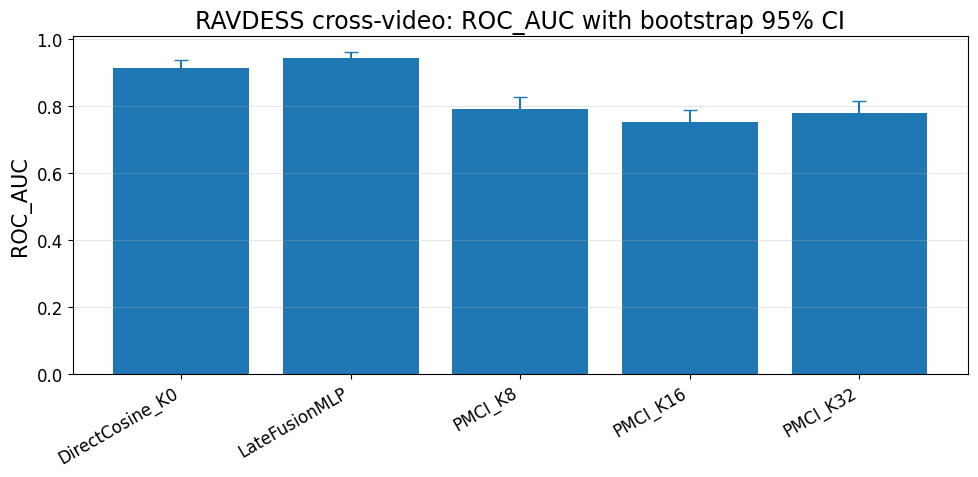

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_roc_auc_bootstrap_ci.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_roc_auc_bootstrap_ci.pdf


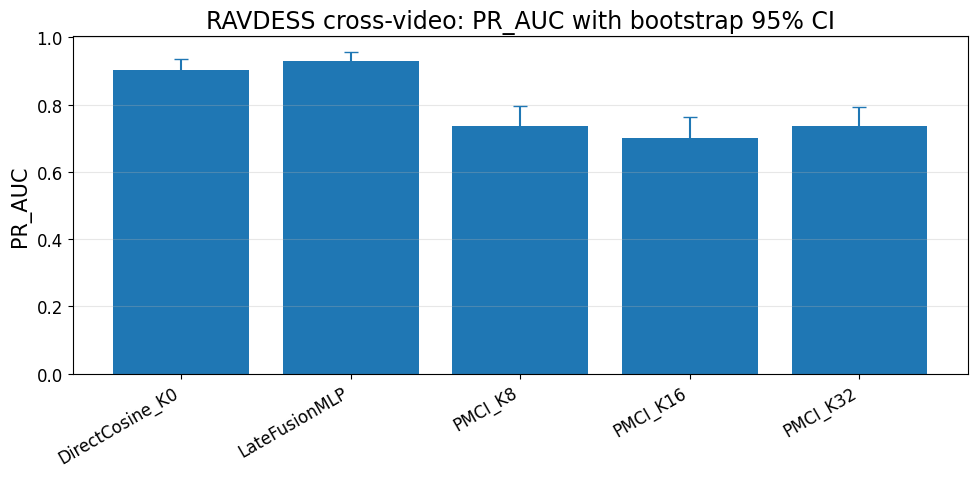

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_pr_auc_bootstrap_ci.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_pr_auc_bootstrap_ci.pdf


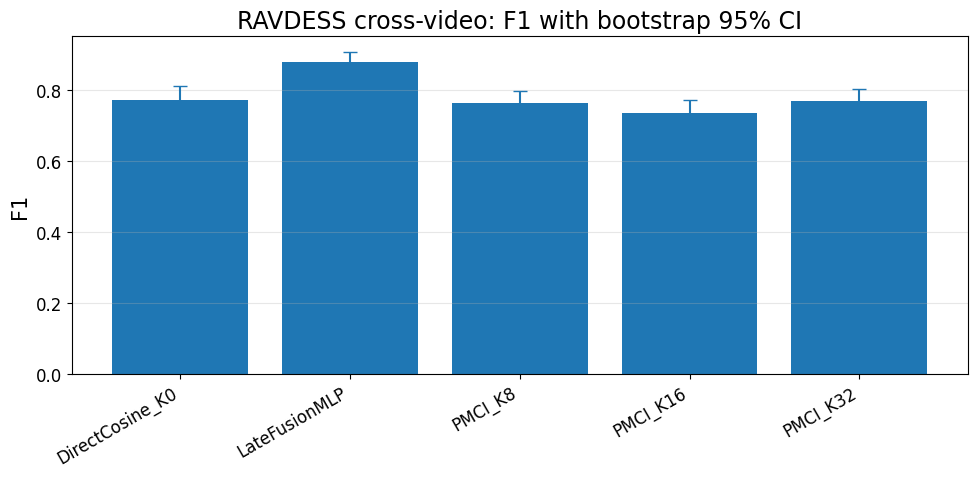

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_f1_bootstrap_ci.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_f1_bootstrap_ci.pdf


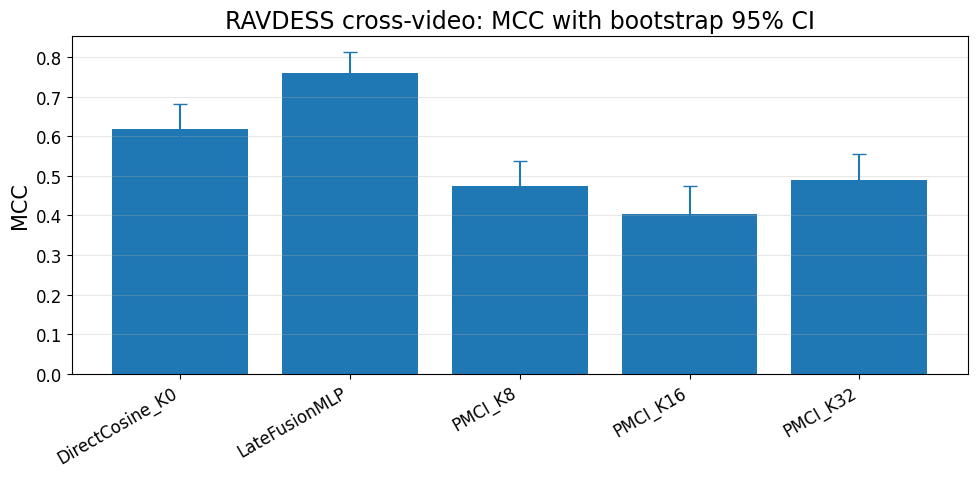

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_mcc_bootstrap_ci.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_ravdess_cross_mcc_bootstrap_ci.pdf


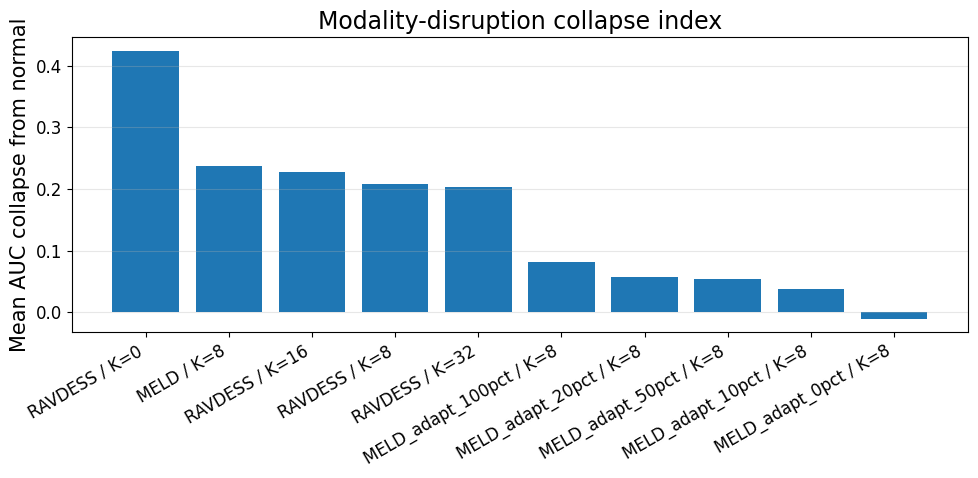

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_modality_collapse_index.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_modality_collapse_index.pdf


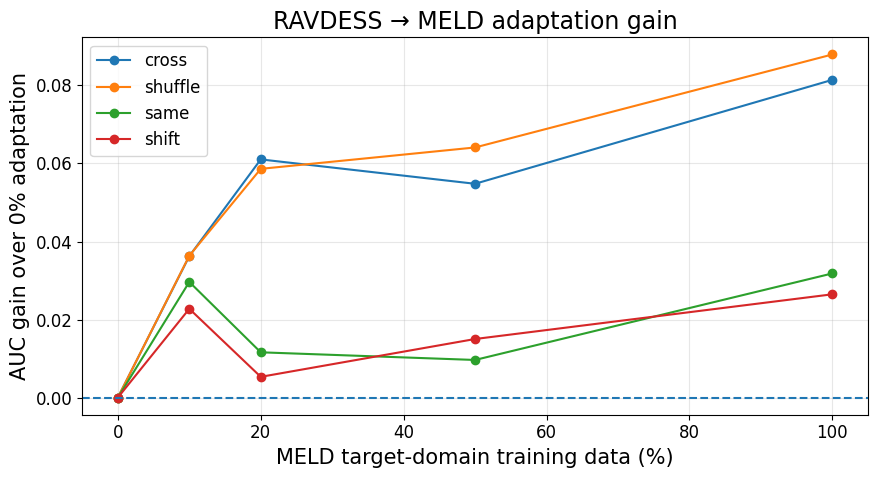

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_adaptation_gain.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_adaptation_gain.pdf


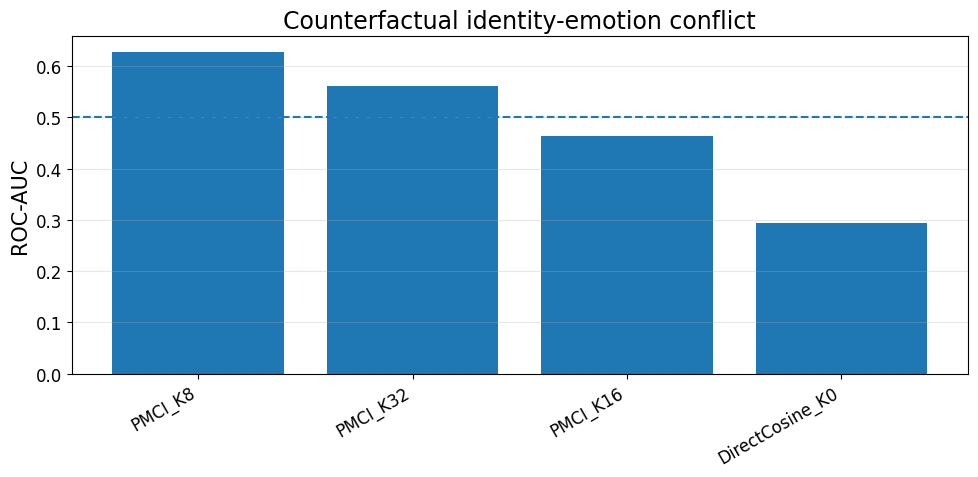

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_counterfactual_identity_emotion_conflict_mainrun.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_counterfactual_identity_emotion_conflict_mainrun.pdf


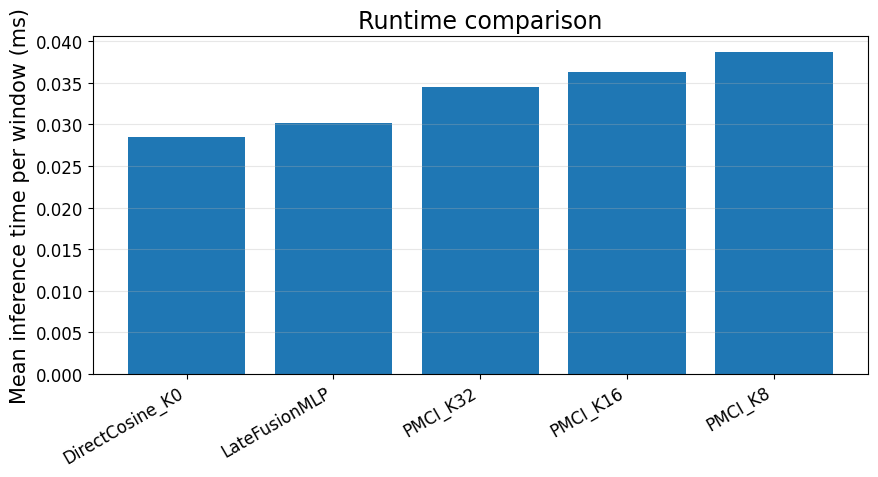

Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_runtime_comparison.png
Saved: /content/cias_q1_min/results_q1_final_extra_evidence/figures/extra_runtime_comparison.pdf

DONE.
All final extra evidence saved to: /content/cias_q1_min/results_q1_final_extra_evidence
Summary JSON: /content/cias_q1_min/results_q1_final_extra_evidence/README_extra_evidence_summary.json

Key files:
bootstrap_ci -> /content/cias_q1_min/results_q1_final_extra_evidence/extra_bootstrap_ci_metrics.csv
paired_comparisons -> /content/cias_q1_min/results_q1_final_extra_evidence/extra_paired_auc_comparisons_summary.csv
modality_collapse -> /content/cias_q1_min/results_q1_final_extra_evidence/extra_modality_collapse_summary.csv
adaptation_gain -> /content/cias_q1_min/results_q1_final_extra_evidence/extra_adaptation_gain.csv
counterfactual_key -> /content/cias_q1_min/results_q1_final_extra_evidence/extra_counterfactual_key_table.csv
counterfactual_advantage -> /content/cias_q1_min/results_q1_fin

In [ ]:
# ============================================================
# FIXED PART: EXPERIMENT 3 onward
# Use after the previous cell stopped at KeyError: 'auc_mean'
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import re

# ------------------------------------------------------------
# FIX: create summary versions because original CSVs use "auc"
# ------------------------------------------------------------

drop_summary_src = (
    drop_csv
    .groupby(["dataset", "k_proto", "control"], as_index=False)
    .agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        pos_mean=("pos_mean", "mean"),
        neg_mean=("neg_mean", "mean"),
    )
)

main_summary_src = (
    main_csv
    .groupby(["experiment", "train", "test", "k_proto", "regime"], as_index=False)
    .agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        pos_mean=("pos_mean", "mean"),
        neg_mean=("neg_mean", "mean"),
    )
)

cf_summary_src = (
    cf_csv
    .groupby(["k_proto", "comparison"], as_index=False)
    .agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        p_perm_mean=("p_perm", "mean"),
        cohen_d_mean=("cohen_d", "mean"),
        pos_mean=("pos_mean", "mean"),
        neg_mean=("neg_mean", "mean"),
    )
)

print("drop_summary_src:")
display(drop_summary_src.head())

print("main_summary_src:")
display(main_summary_src.head())

print("cf_summary_src:")
display(cf_summary_src.head())


# ============================================================
# EXPERIMENT 3: MODALITY-COLLAPSE INDEX
# ============================================================

collapse_rows = []

for keys, g in drop_summary_src.groupby(["dataset", "k_proto"]):
    dataset, k = keys

    if "normal" not in set(g["control"]):
        continue

    normal_auc = float(g[g["control"] == "normal"]["auc_mean"].iloc[0])

    for control in ["face_zero", "body_zero", "body_batch_shuffle", "body_shuffle"]:
        gg = g[g["control"] == control]
        if len(gg) == 0:
            continue

        control_auc = float(gg["auc_mean"].iloc[0])

        collapse_rows.append({
            "dataset": dataset,
            "k_proto": k,
            "normal_auc": normal_auc,
            "control": control,
            "control_auc": control_auc,
            "collapse_delta": normal_auc - control_auc,
            "abs_distance_to_chance": abs(control_auc - 0.5),
        })

collapse_df = pd.DataFrame(collapse_rows)

collapse_summary = collapse_df.groupby(["dataset", "k_proto"]).agg(
    normal_auc=("normal_auc", "first"),
    mean_collapse_delta=("collapse_delta", "mean"),
    max_abs_distance_to_chance=("abs_distance_to_chance", "max"),
).reset_index()

collapse_path = f"{OUT_DIR}/extra_modality_collapse_index.csv"
collapse_summary_path = f"{OUT_DIR}/extra_modality_collapse_summary.csv"

collapse_df.to_csv(collapse_path, index=False)
collapse_summary.to_csv(collapse_summary_path, index=False)

print("\nSaved modality collapse:")
print(collapse_path)
print(collapse_summary_path)
display(collapse_summary)


# ============================================================
# EXPERIMENT 4: DOMAIN ADAPTATION GAIN
# ============================================================

adapt = main_summary_src[
    main_summary_src["experiment"].astype(str).str.contains("ravdess_to_meld_adapt", na=False)
].copy()

def parse_pct(exp):
    m = re.search(r"adapt_(\d+)pct", str(exp))
    return int(m.group(1)) if m else np.nan

adapt["target_meld_pct"] = adapt["experiment"].apply(parse_pct)

adapt_gain_rows = []

for regime in ["cross", "same", "shift", "shuffle"]:
    g = adapt[adapt["regime"] == regime].copy()
    if len(g) == 0:
        continue

    base = g[g["target_meld_pct"] == 0]
    if len(base) == 0:
        continue

    base_auc = float(base["auc_mean"].iloc[0])

    for _, r in g.iterrows():
        adapt_gain_rows.append({
            "regime": regime,
            "target_meld_pct": r["target_meld_pct"],
            "auc_mean": r["auc_mean"],
            "auc_std": r["auc_std"],
            "gain_vs_0pct": r["auc_mean"] - base_auc,
        })

adapt_gain_df = pd.DataFrame(adapt_gain_rows).sort_values(["regime", "target_meld_pct"])

adapt_gain_path = f"{OUT_DIR}/extra_adaptation_gain.csv"
adapt_gain_df.to_csv(adapt_gain_path, index=False)

print("\nSaved adaptation gain:", adapt_gain_path)
display(adapt_gain_df)


# ============================================================
# EXPERIMENT 5: COUNTERFACTUAL ADVANTAGE FROM ORIGINAL MAIN RUN
# ============================================================

cf_adv = cf_summary_src.copy()

cf_adv["model_label"] = cf_adv["k_proto"].apply(
    lambda k: "DirectCosine_K0" if int(k) == 0 else f"PMCI_K{int(k)}"
)

key_cf = cf_adv[
    cf_adv["comparison"].astype(str).str.contains("same_emotion", case=False, na=False) &
    cf_adv["comparison"].astype(str).str.contains("same_actor", case=False, na=False)
].copy()

if len(key_cf) == 0:
    key_cf = cf_adv.copy()

key_cf = key_cf.sort_values("auc_mean", ascending=False)

direct = key_cf[key_cf["model_label"] == "DirectCosine_K0"]
pmci8 = key_cf[key_cf["model_label"] == "PMCI_K8"]

if len(direct) and len(pmci8):
    direct_auc = float(direct["auc_mean"].iloc[0])
    pmci8_auc = float(pmci8["auc_mean"].iloc[0])
    advantage = pmci8_auc - direct_auc
else:
    direct_auc = np.nan
    pmci8_auc = np.nan
    advantage = np.nan

cf_advantage_summary = pd.DataFrame([{
    "direct_auc": direct_auc,
    "pmci8_auc": pmci8_auc,
    "pmci8_minus_direct": advantage,
    "interpretation": "positive value means PMCI_K8 is better than DirectCosine in the identity-emotion conflict comparison"
}])

cf_adv_path = f"{OUT_DIR}/extra_counterfactual_key_table.csv"
cf_adv_summary_path = f"{OUT_DIR}/extra_counterfactual_advantage_summary.csv"

key_cf.to_csv(cf_adv_path, index=False)
cf_advantage_summary.to_csv(cf_adv_summary_path, index=False)

print("\nSaved counterfactual evidence:")
print(cf_adv_path)
print(cf_adv_summary_path)
display(key_cf)
display(cf_advantage_summary)


# ============================================================
# EXPERIMENT 6: RUNTIME COMPACT TABLE
# ============================================================

runtime_out = runtime_csv.copy()

runtime_out_path = f"{OUT_DIR}/extra_runtime_compact.csv"
runtime_out.to_csv(runtime_out_path, index=False)

print("\nSaved runtime compact:", runtime_out_path)
display(runtime_out)


# ============================================================
# PAPER-READY FIGURES
# ============================================================

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

def save_fig(name):
    path_png = f"{FIG_DIR}/{name}.png"
    path_pdf = f"{FIG_DIR}/{name}.pdf"
    plt.tight_layout()
    plt.savefig(path_png, dpi=300, bbox_inches="tight")
    plt.savefig(path_pdf, bbox_inches="tight")
    plt.show()
    print("Saved:", path_png)
    print("Saved:", path_pdf)


# Figure A: bootstrap metrics for RAVDESS cross
fig_df = bootstrap_df[
    (bootstrap_df["dataset"] == "RAVDESS") &
    (bootstrap_df["regime"] == "cross") &
    (bootstrap_df["score_name"] == "main") &
    (bootstrap_df["model"].isin(["DirectCosine_K0", "LateFusionMLP", "PMCI_K8", "PMCI_K16", "PMCI_K32"]))
].copy()

if len(fig_df):
    order = ["DirectCosine_K0", "LateFusionMLP", "PMCI_K8", "PMCI_K16", "PMCI_K32"]
    fig_df["order"] = fig_df["model"].apply(lambda x: order.index(x) if x in order else 99)
    fig_df = fig_df.sort_values("order")

    for metric in ["roc_auc", "pr_auc", "f1", "mcc"]:
        plt.figure(figsize=(10, 5))
        x = np.arange(len(fig_df))
        y = fig_df[metric].values
        low = fig_df[f"{metric}_ci_low"].values
        high = fig_df[f"{metric}_ci_high"].values
        yerr = np.vstack([y - low, high - y])

        plt.bar(x, y)
        plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=5)
        plt.xticks(x, fig_df["model"].values, rotation=30, ha="right")
        plt.ylabel(metric.upper())
        plt.title(f"RAVDESS cross-video: {metric.upper()} with bootstrap 95% CI")
        plt.grid(axis="y", alpha=0.3)
        save_fig(f"extra_ravdess_cross_{metric}_bootstrap_ci")


# Figure B: modality collapse
if len(collapse_summary):
    tmp = collapse_summary.copy()
    tmp["label"] = tmp["dataset"].astype(str) + " / K=" + tmp["k_proto"].astype(str)
    tmp = tmp.sort_values("mean_collapse_delta", ascending=False)

    plt.figure(figsize=(10, 5))
    x = np.arange(len(tmp))
    plt.bar(x, tmp["mean_collapse_delta"].values)
    plt.xticks(x, tmp["label"].values, rotation=30, ha="right")
    plt.ylabel("Mean AUC collapse from normal")
    plt.title("Modality-disruption collapse index")
    plt.grid(axis="y", alpha=0.3)
    save_fig("extra_modality_collapse_index")


# Figure C: adaptation gain
if len(adapt_gain_df):
    plt.figure(figsize=(9, 5))

    for regime in ["cross", "shuffle", "same", "shift"]:
        g = adapt_gain_df[adapt_gain_df["regime"] == regime].sort_values("target_meld_pct")
        if len(g):
            plt.plot(g["target_meld_pct"], g["gain_vs_0pct"], marker="o", label=regime)

    plt.axhline(0, linestyle="--")
    plt.xlabel("MELD target-domain training data (%)")
    plt.ylabel("AUC gain over 0% adaptation")
    plt.title("RAVDESS → MELD adaptation gain")
    plt.legend()
    plt.grid(alpha=0.3)
    save_fig("extra_adaptation_gain")


# Figure D: counterfactual key comparison
if len(key_cf):
    tmp = key_cf.copy()
    tmp = tmp.drop_duplicates(subset=["model_label"])
    tmp = tmp.sort_values("auc_mean", ascending=False)

    plt.figure(figsize=(10, 5))
    x = np.arange(len(tmp))
    plt.bar(x, tmp["auc_mean"].values)
    plt.axhline(0.5, linestyle="--")
    plt.xticks(x, tmp["model_label"].astype(str).values, rotation=30, ha="right")
    plt.ylabel("ROC-AUC")
    plt.title("Counterfactual identity-emotion conflict")
    plt.grid(axis="y", alpha=0.3)
    save_fig("extra_counterfactual_identity_emotion_conflict_mainrun")


# Figure E: runtime
if len(runtime_out):
    metric_col = None
    for c in runtime_out.columns:
        if "mean_window_time_ms_mean" in c:
            metric_col = c
            break
    if metric_col is None:
        for c in runtime_out.columns:
            if "window" in c.lower() and "ms" in c.lower():
                metric_col = c
                break

    if metric_col is not None:
        tmp = runtime_out.sort_values(metric_col)

        plt.figure(figsize=(9, 5))
        x = np.arange(len(tmp))
        plt.bar(x, tmp[metric_col].values)
        plt.xticks(x, tmp["model"].astype(str).values, rotation=30, ha="right")
        plt.ylabel("Mean inference time per window (ms)")
        plt.title("Runtime comparison")
        plt.grid(axis="y", alpha=0.3)
        save_fig("extra_runtime_comparison")


# ============================================================
# FINAL SUMMARY
# ============================================================

summary = {
    "created_files": {
        "bootstrap_ci": bootstrap_path,
        "paired_comparisons": paired_summary_path,
        "modality_collapse": collapse_summary_path,
        "adaptation_gain": adapt_gain_path,
        "counterfactual_key": cf_adv_path,
        "counterfactual_advantage": cf_adv_summary_path,
        "runtime": runtime_out_path,
        "figures": FIG_DIR,
    },
    "recommended_use": {
        "use_in_main_text": [
            "extended metrics table",
            "LateFusionMLP baseline table",
            "modality-collapse index",
            "adaptation gain",
            "runtime compact table"
        ],
        "use_old_main_run_for": [
            "identity leakage",
            "balanced counterfactual PMCI vs DirectCosine"
        ],
        "avoid": [
            "new retrained identity-leakage extended graph",
            "new retrained counterfactual extended graph if it contradicts the main run"
        ]
    }
}

summary_path = f"{OUT_DIR}/README_extra_evidence_summary.json"
Path(summary_path).write_text(json.dumps(summary, indent=2))

print("\nDONE.")
print("All final extra evidence saved to:", OUT_DIR)
print("Summary JSON:", summary_path)

print("\nKey files:")
for k, v in summary["created_files"].items():
    print(k, "->", v)

In [ ]:
# ============================================================
# INTERNAL STRESS TEST SUITE FOR PMCI / CIAS
# ============================================================
# Purpose:
# 1) More seeds robustness
# 2) K sensitivity
# 3) temperature tau sensitivity
# 4) feature ablation: coords / coords+d1 / coords+d1+d2
# 5) random-label sanity
# 6) split leakage checks
# 7) MELD split resampling
# 8) calibration: Brier + ECE
#
# This is for INTERNAL CONFIDENCE, not all results must go to paper.
# ============================================================

!pip -q install numpy pandas scikit-learn matplotlib tqdm

import os
import re
import gc
import math
import json
import time
import random
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    brier_score_loss,
)

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================

BASE_DIR = "/content/cias_q1_min"

RAVDESS_SHARD_DIR = f"{BASE_DIR}/shards/RAVDESS"
MELD_SHARD_DIR = f"{BASE_DIR}/shards/MELD"

OUT_DIR = f"{BASE_DIR}/results_q1_internal_stress_tests"
FIG_DIR = f"{OUT_DIR}/figures"

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
Path(FIG_DIR).mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Main internal robustness seeds
ROBUST_SEEDS = list(range(40, 50))   # 10 seeds

# Smaller seeds for slower sensitivity tests
SMALL_SEEDS = [42, 43, 44]

# Training parameters
BATCH_SIZE = 64
EPOCHS = 5
STEPS_PER_EPOCH = 40

HIDDEN_DIM = 96
EMBED_DIM = 96
LR = 1e-3
WEIGHT_DECAY = 1e-4

# Main PMCI settings
DEFAULT_TAU = 0.25
DEFAULT_K = 8

# Sensitivity
K_VALUES = [4, 8, 16, 32, 64]
TAU_VALUES = [0.10, 0.25, 0.50, 1.00]
FEATURE_MODES = ["coords", "coords_d1", "full"]

# MELD resampling
MELD_SPLIT_SEEDS = [101, 102, 103, 104, 105]

# Pair evaluation regimes
REGIMES = ["cross", "same", "shift", "shuffle"]

# Turn on/off blocks
RUN_SPLIT_LEAKAGE_CHECK = True
RUN_ROBUST_10_SEEDS = True
RUN_RANDOM_LABEL_SANITY = True
RUN_K_SENSITIVITY = True
RUN_TAU_SENSITIVITY = True
RUN_FEATURE_ABLATION = True
RUN_MELD_RESAMPLING = True
RUN_CALIBRATION = True

# ============================================================
# REPRODUCIBILITY
# ============================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def clean_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ============================================================
# DATA LOADING
# ============================================================

def load_shards(shard_dir, name):
    files = sorted(Path(shard_dir).glob("*.npz"))

    if not files:
        raise RuntimeError(f"No shards found in {shard_dir}")

    faces, bodies, vids, subs, dsets = [], [], [], [], []

    for fp in files:
        z = np.load(fp, allow_pickle=True)

        face_key = "face" if "face" in z.files else "faces"
        body_key = "body" if "body" in z.files else "bodies"

        faces.append(z[face_key].astype(np.float32))
        bodies.append(z[body_key].astype(np.float32))

        if "video_ids" in z.files:
            vids.append(z["video_ids"].astype(str))
        else:
            vids.append(np.array([f"{name}_{i}" for i in range(len(z[face_key]))]).astype(str))

        if "subject_ids" in z.files:
            subs.append(z["subject_ids"].astype(str))
        else:
            subs.append(np.array(["unknown"] * len(z[face_key])).astype(str))

        if "dataset" in z.files:
            dsets.append(z["dataset"].astype(str))
        else:
            dsets.append(np.array([name] * len(z[face_key])).astype(str))

    data = {
        "face": np.concatenate(faces, axis=0).astype(np.float32),
        "body": np.concatenate(bodies, axis=0).astype(np.float32),
        "video_ids": np.concatenate(vids, axis=0).astype(str),
        "subject_ids": np.concatenate(subs, axis=0).astype(str),
        "dataset": np.concatenate(dsets, axis=0).astype(str),
    }

    print(f"{name} loaded: face {data['face'].shape}, body {data['body'].shape}, videos {len(set(data['video_ids']))}")
    return data

EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

def parse_ravdess_meta(video_id, subject_id):
    s = str(video_id)

    # RAVDESS filename pattern: 03-01-05-01-02-01-12
    m = re.search(r"(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})-(\d{2})", s)

    if m:
        emotion_code = m.group(3)
        actor_code = m.group(7)
        return actor_code, EMOTION_MAP.get(emotion_code, "unknown")

    # fallback
    actor = str(subject_id)
    emotion = "unknown"

    nums = re.findall(r"\d+", s)
    if len(nums) >= 7:
        emotion = EMOTION_MAP.get(nums[-5], "unknown")
        actor = nums[-1].zfill(2)

    return actor, emotion

def add_ravdess_metadata(data):
    actors, emotions = [], []

    for vid, sid in zip(data["video_ids"], data["subject_ids"]):
        a, e = parse_ravdess_meta(vid, sid)
        actors.append(a)
        emotions.append(e)

    data["actor"] = np.array(actors).astype(str)
    data["emotion"] = np.array(emotions).astype(str)

    return data

def add_meld_metadata(data):
    data["actor"] = np.array(["unknown"] * len(data["face"])).astype(str)
    data["emotion"] = np.array(["unknown"] * len(data["face"])).astype(str)
    return data

raw_rav = add_ravdess_metadata(load_shards(RAVDESS_SHARD_DIR, "RAVDESS"))
raw_meld = add_meld_metadata(load_shards(MELD_SHARD_DIR, "MELD"))

print("\nRAVDESS emotions:")
print(pd.Series(raw_rav["emotion"]).value_counts())

# ============================================================
# FEATURE MODES
# ============================================================

def make_feature_mode(data, mode):
    """
    Original features:
    face: [x(10), d1(10), d2(10)] => 30
    body: [x(24), d1(24), d2(24)] => 72
    """

    out = dict(data)

    if mode == "coords":
        out["face"] = data["face"][:, :, :10].copy()
        out["body"] = data["body"][:, :, :24].copy()

    elif mode == "coords_d1":
        out["face"] = data["face"][:, :, :20].copy()
        out["body"] = data["body"][:, :, :48].copy()

    elif mode == "full":
        out["face"] = data["face"].copy()
        out["body"] = data["body"].copy()

    else:
        raise ValueError(f"Unknown feature mode: {mode}")

    return out

# ============================================================
# SPLITS
# ============================================================

def split_ravdess_by_actor(data):
    actors = data["actor"]

    train_actors = {str(i).zfill(2) for i in range(1, 9)}
    val_actors = {"09", "10"}
    test_actors = {"11", "12"}

    train_idx = np.where(np.isin(actors, list(train_actors)))[0]
    val_idx = np.where(np.isin(actors, list(val_actors)))[0]
    test_idx = np.where(np.isin(actors, list(test_actors)))[0]

    return train_idx, val_idx, test_idx

def split_by_video(data, seed=42, train_frac=0.70, val_frac=0.15):
    rng = np.random.default_rng(seed)

    vids = np.array(sorted(list(set(data["video_ids"]))))
    rng.shuffle(vids)

    n = len(vids)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_vids = set(vids[:n_train])
    val_vids = set(vids[n_train:n_train + n_val])
    test_vids = set(vids[n_train + n_val:])

    train_idx = np.where(np.isin(data["video_ids"], list(train_vids)))[0]
    val_idx = np.where(np.isin(data["video_ids"], list(val_vids)))[0]
    test_idx = np.where(np.isin(data["video_ids"], list(test_vids)))[0]

    return train_idx, val_idx, test_idx

def check_split_leakage(data, train_idx, val_idx, test_idx, name):
    rows = []

    def set_of(arr):
        return set(arr.astype(str).tolist())

    train_v = set_of(data["video_ids"][train_idx])
    val_v = set_of(data["video_ids"][val_idx])
    test_v = set_of(data["video_ids"][test_idx])

    train_a = set_of(data["actor"][train_idx])
    val_a = set_of(data["actor"][val_idx])
    test_a = set_of(data["actor"][test_idx])

    rows.append({
        "dataset": name,
        "check": "video_overlap_train_val",
        "value": len(train_v & val_v)
    })
    rows.append({
        "dataset": name,
        "check": "video_overlap_train_test",
        "value": len(train_v & test_v)
    })
    rows.append({
        "dataset": name,
        "check": "video_overlap_val_test",
        "value": len(val_v & test_v)
    })
    rows.append({
        "dataset": name,
        "check": "actor_overlap_train_val",
        "value": len(train_a & val_a)
    })
    rows.append({
        "dataset": name,
        "check": "actor_overlap_train_test",
        "value": len(train_a & test_a)
    })
    rows.append({
        "dataset": name,
        "check": "actor_overlap_val_test",
        "value": len(val_a & test_a)
    })

    return rows

# ============================================================
# STANDARDIZATION
# ============================================================

def compute_standardizer(data, train_idx):
    f = data["face"][train_idx].reshape(-1, data["face"].shape[-1])
    b = data["body"][train_idx].reshape(-1, data["body"].shape[-1])

    return {
        "face_mean": f.mean(axis=0).astype(np.float32),
        "face_std": (f.std(axis=0) + 1e-6).astype(np.float32),
        "body_mean": b.mean(axis=0).astype(np.float32),
        "body_std": (b.std(axis=0) + 1e-6).astype(np.float32),
    }

def apply_standardizer(data, stats):
    out = dict(data)
    out["face"] = ((data["face"] - stats["face_mean"]) / stats["face_std"]).astype(np.float32)
    out["body"] = ((data["body"] - stats["body_mean"]) / stats["body_std"]).astype(np.float32)
    return out

# ============================================================
# PAIR SAMPLING
# ============================================================

def choose_negative_index(data, i, pool_idx, rng, regime="cross"):
    pool_idx = np.asarray(pool_idx)
    vids = data["video_ids"]

    if len(pool_idx) <= 1:
        return int(i)

    if regime == "cross":
        cand = pool_idx[vids[pool_idx] != vids[i]]
        if len(cand) == 0:
            cand = pool_idx[pool_idx != i]
        return int(rng.choice(cand))

    if regime in ["same", "shift"]:
        cand = pool_idx[(vids[pool_idx] == vids[i]) & (pool_idx != i)]
        if len(cand) == 0:
            cand = pool_idx[pool_idx != i]
        return int(rng.choice(cand))

    if regime == "shuffle":
        cand = pool_idx[pool_idx != i]
        return int(rng.choice(cand))

    cand = pool_idx[pool_idx != i]
    return int(rng.choice(cand))

def sample_train_batch(data, train_idx, batch_size, rng, random_labels=False):
    half = batch_size // 2

    pos_i = rng.choice(train_idx, size=half, replace=True)
    pos_j = pos_i.copy()

    neg_i = rng.choice(train_idx, size=batch_size - half, replace=True)
    neg_j = np.array([
        choose_negative_index(data, i, train_idx, rng, regime="cross")
        for i in neg_i
    ])

    i_all = np.concatenate([pos_i, neg_i])
    j_all = np.concatenate([pos_j, neg_j])
    y_all = np.concatenate([
        np.ones(half),
        np.zeros(batch_size - half)
    ]).astype(np.float32)

    if random_labels:
        y_all = rng.integers(0, 2, size=len(y_all)).astype(np.float32)

    perm = rng.permutation(len(y_all))

    return i_all[perm], j_all[perm], y_all[perm]

def make_eval_pairs(data, idx, regime="cross", rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    idx = np.asarray(idx)

    pos_i = idx.copy()
    pos_j = idx.copy()

    neg_i = idx.copy()

    if regime == "shuffle":
        neg_j = idx.copy()
        rng.shuffle(neg_j)

        for t in range(len(neg_j)):
            if neg_j[t] == neg_i[t]:
                neg_j[t] = choose_negative_index(data, neg_i[t], idx, rng, regime="cross")
    else:
        neg_j = np.array([
            choose_negative_index(data, i, idx, rng, regime=regime)
            for i in neg_i
        ])

    i_all = np.concatenate([pos_i, neg_i])
    j_all = np.concatenate([pos_j, neg_j])
    y_all = np.concatenate([
        np.ones(len(pos_i)),
        np.zeros(len(neg_i))
    ]).astype(np.int64)

    return i_all, j_all, y_all

def get_tensors(data, i, j):
    xf = torch.tensor(data["face"][i], dtype=torch.float32, device=DEVICE)
    xb = torch.tensor(data["body"][j], dtype=torch.float32, device=DEVICE)
    return xf, xb

# ============================================================
# MODELS
# ============================================================

class DualGRUEncoder(nn.Module):
    def __init__(self, face_dim, body_dim, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM):
        super().__init__()

        self.face_gru = nn.GRU(face_dim, hidden_dim, batch_first=True)
        self.body_gru = nn.GRU(body_dim, hidden_dim, batch_first=True)

        self.face_proj = nn.Sequential(
            nn.Linear(hidden_dim, embed_dim),
            nn.ReLU(),
            nn.LayerNorm(embed_dim),
        )

        self.body_proj = nn.Sequential(
            nn.Linear(hidden_dim, embed_dim),
            nn.ReLU(),
            nn.LayerNorm(embed_dim),
        )

    def encode(self, xf, xb):
        _, hf = self.face_gru(xf)
        _, hb = self.body_gru(xb)

        zf = self.face_proj(hf[-1])
        zb = self.body_proj(hb[-1])

        zf = F.normalize(zf, dim=-1)
        zb = F.normalize(zb, dim=-1)

        return zf, zb

class PMCIModel(nn.Module):
    def __init__(self, face_dim, body_dim, k_proto=8, tau=0.25):
        super().__init__()

        self.face_dim = face_dim
        self.body_dim = body_dim
        self.k_proto = int(k_proto)
        self.tau = float(tau)

        self.encoder = DualGRUEncoder(face_dim, body_dim)

        if self.k_proto > 0:
            self.prototypes = nn.Parameter(torch.randn(self.k_proto, EMBED_DIM) * 0.02)
        else:
            self.prototypes = None

    def forward_scores(self, xf, xb):
        zf, zb = self.encoder.encode(xf, xb)

        emb_cos = torch.sum(zf * zb, dim=-1)
        neg_euclidean = -torch.norm(zf - zb, dim=-1)

        out = {
            "emb_cos": emb_cos,
            "neg_euclidean": neg_euclidean,
            "zf": zf,
            "zb": zb,
        }

        if self.k_proto > 0:
            proto = F.normalize(self.prototypes, dim=-1)

            sf = torch.matmul(zf, proto.T) / self.tau
            sb = torch.matmul(zb, proto.T) / self.tau

            pf = F.softmax(sf, dim=-1)
            pb = F.softmax(sb, dim=-1)

            eps = 1e-8

            m = 0.5 * (pf + pb)

            kl_fm = torch.sum(pf * (torch.log(pf + eps) - torch.log(m + eps)), dim=-1)
            kl_bm = torch.sum(pb * (torch.log(pb + eps) - torch.log(m + eps)), dim=-1)

            js = 0.5 * (kl_fm + kl_bm) / math.log(2.0)
            pmci = 1.0 - js

            kl_fb = torch.sum(pf * (torch.log(pf + eps) - torch.log(pb + eps)), dim=-1)
            kl_bf = torch.sum(pb * (torch.log(pb + eps) - torch.log(pf + eps)), dim=-1)
            symkl = 0.5 * (kl_fb + kl_bf)

            prob_cos = F.cosine_similarity(pf, pb, dim=-1)

            hellinger = 1.0 - (
                torch.sqrt(torch.sum((torch.sqrt(pf + eps) - torch.sqrt(pb + eps)) ** 2, dim=-1))
                / math.sqrt(2.0)
            )

            out.update({
                "pmci": pmci,
                "neg_js": -js,
                "prob_cos": prob_cos,
                "neg_symkl": -symkl,
                "hellinger": hellinger,
                "pf": pf,
                "pb": pb,
            })

        return out

    def main_score(self, xf, xb):
        out = self.forward_scores(xf, xb)

        if self.k_proto == 0:
            return out["emb_cos"]

        return out["pmci"]

class LateFusionMLP(nn.Module):
    def __init__(self, face_dim, body_dim):
        super().__init__()

        self.encoder = DualGRUEncoder(face_dim, body_dim)

        in_dim = EMBED_DIM * 4

        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward_logits(self, xf, xb):
        zf, zb = self.encoder.encode(xf, xb)
        feat = torch.cat([zf, zb, torch.abs(zf - zb), zf * zb], dim=-1)
        return self.classifier(feat).squeeze(-1)

    def forward_scores(self, xf, xb):
        logits = self.forward_logits(xf, xb)
        return {
            "fusion_prob": torch.sigmoid(logits)
        }

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ============================================================
# METRICS
# ============================================================

def safe_auc(y, s):
    try:
        if len(np.unique(y)) < 2:
            return np.nan
        return roc_auc_score(y, s)
    except:
        return np.nan

def safe_pr_auc(y, s):
    try:
        if len(np.unique(y)) < 2:
            return np.nan
        return average_precision_score(y, s)
    except:
        return np.nan

def best_threshold(y, scores, mode="f1"):
    y = np.asarray(y).astype(int)
    scores = np.asarray(scores).astype(float)

    qs = np.linspace(0.02, 0.98, 97)
    thresholds = np.quantile(scores, qs)

    best_thr = float(thresholds[0])
    best_val = -1

    for thr in thresholds:
        pred = (scores >= thr).astype(int)

        if mode == "mcc":
            val = matthews_corrcoef(y, pred)
        else:
            val = f1_score(y, pred, zero_division=0)

        if val > best_val:
            best_val = val
            best_thr = float(thr)

    return best_thr

def expected_calibration_error(y, prob, n_bins=10):
    y = np.asarray(y).astype(int)
    prob = np.clip(np.asarray(prob).astype(float), 0.0, 1.0)

    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (prob >= lo) & (prob < hi)
        if mask.sum() == 0:
            continue

        acc = y[mask].mean()
        conf = prob[mask].mean()
        ece += (mask.sum() / len(y)) * abs(acc - conf)

    return float(ece)

def score_to_probability(score):
    score = np.asarray(score).astype(float)

    # If already close to 0..1, clip
    if score.min() >= -0.05 and score.max() <= 1.05:
        return np.clip(score, 0, 1)

    # Otherwise sigmoid-normalize
    z = (score - score.mean()) / (score.std() + 1e-8)
    return 1 / (1 + np.exp(-z))

def compute_metrics(y, scores, threshold=None):
    y = np.asarray(y).astype(int)
    scores = np.asarray(scores).astype(float)

    if threshold is None:
        threshold = best_threshold(y, scores, mode="f1")

    pred = (scores >= threshold).astype(int)
    prob = score_to_probability(scores)

    out = {
        "roc_auc": safe_auc(y, scores),
        "pr_auc": safe_pr_auc(y, scores),
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
        "mcc": matthews_corrcoef(y, pred),
        "brier": brier_score_loss(y, prob),
        "ece": expected_calibration_error(y, prob),
        "threshold": threshold,
        "n": len(y),
    }

    try:
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        out["specificity"] = tn / (tn + fp + 1e-8)
    except:
        out["specificity"] = np.nan

    return out

# ============================================================
# TRAIN / EVAL
# ============================================================

@torch.no_grad()
def score_pairs(model, data, i, j, score_name="main", batch_size=256):
    model.eval()

    scores = []

    for start in range(0, len(i), batch_size):
        ii = i[start:start + batch_size]
        jj = j[start:start + batch_size]

        xf, xb = get_tensors(data, ii, jj)
        out = model.forward_scores(xf, xb)

        if isinstance(model, PMCIModel):
            if score_name == "main":
                s = model.main_score(xf, xb)
            else:
                s = out[score_name]
        else:
            if score_name in ["main", "fusion_prob"]:
                s = out["fusion_prob"]
            else:
                raise ValueError(f"Unknown score for fusion model: {score_name}")

        scores.append(s.detach().cpu().numpy())

    return np.concatenate(scores)

def eval_model(model, data, val_idx, test_idx, seed, regime="cross", score_name="main"):
    rng_val = np.random.default_rng(seed + 100)
    rng_test = np.random.default_rng(seed + 200)

    vi, vj, vy = make_eval_pairs(data, val_idx, regime=regime, rng=rng_val)
    ti, tj, ty = make_eval_pairs(data, test_idx, regime=regime, rng=rng_test)

    val_scores = score_pairs(model, data, vi, vj, score_name=score_name)
    test_scores = score_pairs(model, data, ti, tj, score_name=score_name)

    thr = best_threshold(vy, val_scores, mode="f1")
    out = compute_metrics(ty, test_scores, threshold=thr)

    return out, ty, test_scores

def train_pmci(data, train_idx, val_idx, k_proto=8, tau=0.25, seed=42, random_labels=False):
    set_seed(seed)

    face_dim = data["face"].shape[-1]
    body_dim = data["body"].shape[-1]

    model = PMCIModel(face_dim, body_dim, k_proto=k_proto, tau=tau).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    rng = np.random.default_rng(seed)

    best_auc = -1
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for _ in range(STEPS_PER_EPOCH):
            i, j, y = sample_train_batch(
                data,
                train_idx,
                BATCH_SIZE,
                rng,
                random_labels=random_labels
            )

            xf, xb = get_tensors(data, i, j)
            y_t = torch.tensor(y, dtype=torch.float32, device=DEVICE)

            score = model.main_score(xf, xb)

            if k_proto == 0:
                logits = 8.0 * score
            else:
                logits = 10.0 * (score - 0.5)

            loss = F.binary_cross_entropy_with_logits(logits, y_t)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

            losses.append(float(loss.detach().cpu()))

        val_metric, _, _ = eval_model(model, data, val_idx, val_idx, seed + epoch, regime="cross", score_name="main")
        val_auc = val_metric["roc_auc"]

        if np.isfinite(val_auc) and val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"PMCI train | K={k_proto} tau={tau} seed={seed} epoch={epoch:02d} loss={np.mean(losses):.4f} val_auc={val_auc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

def train_fusion(data, train_idx, val_idx, seed=42):
    set_seed(seed)

    face_dim = data["face"].shape[-1]
    body_dim = data["body"].shape[-1]

    model = LateFusionMLP(face_dim, body_dim).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    rng = np.random.default_rng(seed)

    best_auc = -1
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        losses = []

        for _ in range(STEPS_PER_EPOCH):
            i, j, y = sample_train_batch(data, train_idx, BATCH_SIZE, rng)

            xf, xb = get_tensors(data, i, j)
            y_t = torch.tensor(y, dtype=torch.float32, device=DEVICE)

            logits = model.forward_logits(xf, xb)
            loss = F.binary_cross_entropy_with_logits(logits, y_t)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

            losses.append(float(loss.detach().cpu()))

        val_metric, _, _ = eval_model(model, data, val_idx, val_idx, seed + epoch, regime="cross", score_name="main")
        val_auc = val_metric["roc_auc"]

        if np.isfinite(val_auc) and val_auc > best_auc:
            best_auc = val_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Fusion train | seed={seed} epoch={epoch:02d} loss={np.mean(losses):.4f} val_auc={val_auc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# ============================================================
# DATA PREP FUNCTION
# ============================================================

def prepare_dataset(raw_data, feature_mode, dataset_name, split_seed=42):
    data = make_feature_mode(raw_data, feature_mode)

    if dataset_name == "RAVDESS":
        train_idx, val_idx, test_idx = split_ravdess_by_actor(data)
    else:
        train_idx, val_idx, test_idx = split_by_video(data, seed=split_seed)

    stats = compute_standardizer(data, train_idx)
    data = apply_standardizer(data, stats)

    return data, train_idx, val_idx, test_idx

# ============================================================
# RESULTS STORAGE
# ============================================================

all_rows = []
pred_rows = []
sanity_rows = []
leak_rows = []

# ============================================================
# 0) SPLIT LEAKAGE CHECKS
# ============================================================

if RUN_SPLIT_LEAKAGE_CHECK:
    print("\n" + "=" * 100)
    print("SPLIT LEAKAGE CHECKS")
    print("=" * 100)

    rav_full, rav_train, rav_val, rav_test = prepare_dataset(raw_rav, "full", "RAVDESS", split_seed=42)
    meld_full, meld_train, meld_val, meld_test = prepare_dataset(raw_meld, "full", "MELD", split_seed=42)

    leak_rows.extend(check_split_leakage(rav_full, rav_train, rav_val, rav_test, "RAVDESS"))
    leak_rows.extend(check_split_leakage(meld_full, meld_train, meld_val, meld_test, "MELD"))

    leak_df = pd.DataFrame(leak_rows)
    leak_path = f"{OUT_DIR}/internal_split_leakage_checks.csv"
    leak_df.to_csv(leak_path, index=False)

    print("Saved:", leak_path)
    display(leak_df)

# ============================================================
# 1) 10-SEED ROBUSTNESS: RAVDESS FULL FEATURES
# ============================================================

if RUN_ROBUST_10_SEEDS:
    print("\n" + "=" * 100)
    print("10-SEED ROBUSTNESS: RAVDESS")
    print("=" * 100)

    data, train_idx, val_idx, test_idx = prepare_dataset(raw_rav, "full", "RAVDESS", split_seed=42)

    for seed in ROBUST_SEEDS:
        print("\n--- Seed", seed, "---")

        for model_type, k in [
            ("direct", 0),
            ("pmci", 8),
            ("pmci", 16),
            ("pmci", 32),
        ]:
            model = train_pmci(data, train_idx, val_idx, k_proto=k, tau=DEFAULT_TAU, seed=seed)

            for regime in REGIMES:
                metrics, y, s = eval_model(model, data, val_idx, test_idx, seed, regime=regime, score_name="main")

                row = {
                    "block": "robust_10_seeds",
                    "dataset": "RAVDESS",
                    "feature_mode": "full",
                    "model": "DirectCosine_K0" if k == 0 else f"PMCI_K{k}",
                    "k_proto": k,
                    "tau": DEFAULT_TAU,
                    "seed": seed,
                    "regime": regime,
                    "score_name": "main",
                    "params": count_params(model),
                }
                row.update(metrics)
                all_rows.append(row)

            clean_memory()

        fusion = train_fusion(data, train_idx, val_idx, seed=seed)

        for regime in REGIMES:
            metrics, y, s = eval_model(fusion, data, val_idx, test_idx, seed, regime=regime, score_name="main")

            row = {
                "block": "robust_10_seeds",
                "dataset": "RAVDESS",
                "feature_mode": "full",
                "model": "LateFusionMLP",
                "k_proto": -1,
                "tau": np.nan,
                "seed": seed,
                "regime": regime,
                "score_name": "main",
                "params": count_params(fusion),
            }
            row.update(metrics)
            all_rows.append(row)

        clean_memory()

# ============================================================
# 2) RANDOM-LABEL SANITY
# ============================================================

if RUN_RANDOM_LABEL_SANITY:
    print("\n" + "=" * 100)
    print("RANDOM-LABEL SANITY")
    print("=" * 100)

    data, train_idx, val_idx, test_idx = prepare_dataset(raw_rav, "full", "RAVDESS", split_seed=42)

    for seed in SMALL_SEEDS:
        print("\n--- Random-label sanity seed", seed, "---")

        for random_labels in [False, True]:
            model = train_pmci(
                data,
                train_idx,
                val_idx,
                k_proto=8,
                tau=DEFAULT_TAU,
                seed=seed,
                random_labels=random_labels,
            )

            for regime in ["cross", "shuffle"]:
                metrics, y, scores = eval_model(model, data, val_idx, test_idx, seed, regime=regime, score_name="main")

                # label permutation at evaluation level
                rng = np.random.default_rng(seed)
                perm_aucs = []

                for _ in range(500):
                    yy = rng.permutation(y)
                    perm_aucs.append(safe_auc(yy, scores))

                perm_aucs = np.array(perm_aucs)

                row = {
                    "block": "random_label_sanity",
                    "dataset": "RAVDESS",
                    "feature_mode": "full",
                    "model": "PMCI_K8",
                    "k_proto": 8,
                    "tau": DEFAULT_TAU,
                    "seed": seed,
                    "regime": regime,
                    "train_random_labels": random_labels,
                    "real_auc": metrics["roc_auc"],
                    "perm_auc_mean": np.nanmean(perm_aucs),
                    "perm_auc_std": np.nanstd(perm_aucs),
                    "perm_p_value": float((np.sum(perm_aucs >= metrics["roc_auc"]) + 1) / (len(perm_aucs) + 1)),
                }
                sanity_rows.append(row)

            clean_memory()

    sanity_df = pd.DataFrame(sanity_rows)
    sanity_path = f"{OUT_DIR}/internal_random_label_sanity.csv"
    sanity_df.to_csv(sanity_path, index=False)

    print("Saved:", sanity_path)
    display(sanity_df)

# ============================================================
# 3) K SENSITIVITY
# ============================================================

if RUN_K_SENSITIVITY:
    print("\n" + "=" * 100)
    print("K SENSITIVITY")
    print("=" * 100)

    data, train_idx, val_idx, test_idx = prepare_dataset(raw_rav, "full", "RAVDESS", split_seed=42)

    for seed in SMALL_SEEDS:
        for k in K_VALUES:
            print("\n--- K sensitivity seed", seed, "K", k, "---")

            model = train_pmci(data, train_idx, val_idx, k_proto=k, tau=DEFAULT_TAU, seed=seed)

            for regime in REGIMES:
                metrics, y, s = eval_model(model, data, val_idx, test_idx, seed, regime=regime, score_name="main")

                row = {
                    "block": "k_sensitivity",
                    "dataset": "RAVDESS",
                    "feature_mode": "full",
                    "model": f"PMCI_K{k}",
                    "k_proto": k,
                    "tau": DEFAULT_TAU,
                    "seed": seed,
                    "regime": regime,
                    "score_name": "main",
                    "params": count_params(model),
                }
                row.update(metrics)
                all_rows.append(row)

            clean_memory()

# ============================================================
# 4) TAU SENSITIVITY
# ============================================================

if RUN_TAU_SENSITIVITY:
    print("\n" + "=" * 100)
    print("TAU SENSITIVITY")
    print("=" * 100)

    data, train_idx, val_idx, test_idx = prepare_dataset(raw_rav, "full", "RAVDESS", split_seed=42)

    for seed in SMALL_SEEDS:
        for tau in TAU_VALUES:
            print("\n--- Tau sensitivity seed", seed, "tau", tau, "---")

            model = train_pmci(data, train_idx, val_idx, k_proto=8, tau=tau, seed=seed)

            for regime in REGIMES:
                metrics, y, s = eval_model(model, data, val_idx, test_idx, seed, regime=regime, score_name="main")

                row = {
                    "block": "tau_sensitivity",
                    "dataset": "RAVDESS",
                    "feature_mode": "full",
                    "model": "PMCI_K8",
                    "k_proto": 8,
                    "tau": tau,
                    "seed": seed,
                    "regime": regime,
                    "score_name": "main",
                    "params": count_params(model),
                }
                row.update(metrics)
                all_rows.append(row)

            clean_memory()

# ============================================================
# 5) FEATURE ABLATION
# ============================================================

if RUN_FEATURE_ABLATION:
    print("\n" + "=" * 100)
    print("FEATURE ABLATION")
    print("=" * 100)

    for mode in FEATURE_MODES:
        data, train_idx, val_idx, test_idx = prepare_dataset(raw_rav, mode, "RAVDESS", split_seed=42)

        print("\nFeature mode:", mode, "face_dim:", data["face"].shape[-1], "body_dim:", data["body"].shape[-1])

        for seed in SMALL_SEEDS:
            model = train_pmci(data, train_idx, val_idx, k_proto=8, tau=DEFAULT_TAU, seed=seed)

            for regime in REGIMES:
                metrics, y, s = eval_model(model, data, val_idx, test_idx, seed, regime=regime, score_name="main")

                row = {
                    "block": "feature_ablation",
                    "dataset": "RAVDESS",
                    "feature_mode": mode,
                    "model": "PMCI_K8",
                    "k_proto": 8,
                    "tau": DEFAULT_TAU,
                    "seed": seed,
                    "regime": regime,
                    "score_name": "main",
                    "params": count_params(model),
                    "face_dim": data["face"].shape[-1],
                    "body_dim": data["body"].shape[-1],
                }
                row.update(metrics)
                all_rows.append(row)

            clean_memory()

# ============================================================
# 6) MELD SPLIT RESAMPLING
# ============================================================

if RUN_MELD_RESAMPLING:
    print("\n" + "=" * 100)
    print("MELD SPLIT RESAMPLING")
    print("=" * 100)

    for split_seed in MELD_SPLIT_SEEDS:
        data, train_idx, val_idx, test_idx = prepare_dataset(raw_meld, "full", "MELD", split_seed=split_seed)

        print("\nMELD split seed:", split_seed, "split:", len(train_idx), len(val_idx), len(test_idx))

        for seed in SMALL_SEEDS:
            model = train_pmci(data, train_idx, val_idx, k_proto=8, tau=DEFAULT_TAU, seed=seed)

            for regime in REGIMES:
                metrics, y, s = eval_model(model, data, val_idx, test_idx, seed, regime=regime, score_name="main")

                row = {
                    "block": "meld_split_resampling",
                    "dataset": "MELD",
                    "feature_mode": "full",
                    "model": "PMCI_K8",
                    "k_proto": 8,
                    "tau": DEFAULT_TAU,
                    "seed": seed,
                    "split_seed": split_seed,
                    "regime": regime,
                    "score_name": "main",
                    "params": count_params(model),
                    "n_train": len(train_idx),
                    "n_val": len(val_idx),
                    "n_test": len(test_idx),
                }
                row.update(metrics)
                all_rows.append(row)

            clean_memory()

# ============================================================
# SAVE ALL RESULTS
# ============================================================

results_df = pd.DataFrame(all_rows)

raw_path = f"{OUT_DIR}/internal_stress_raw_results.csv"
results_df.to_csv(raw_path, index=False)

print("\nSaved raw results:", raw_path)
display(results_df.head())

# Summary
metric_cols = [
    "roc_auc",
    "pr_auc",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "mcc",
    "brier",
    "ece",
    "specificity",
]

group_cols = [
    "block",
    "dataset",
    "feature_mode",
    "model",
    "k_proto",
    "tau",
    "regime",
]

summary_rows = []

for keys, g in results_df.groupby(group_cols, dropna=False):
    row = {c: v for c, v in zip(group_cols, keys)}

    for m in metric_cols:
        if m in g.columns:
            row[m + "_mean"] = g[m].mean()
            row[m + "_std"] = g[m].std(ddof=0)

    row["n_runs"] = len(g)

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_path = f"{OUT_DIR}/internal_stress_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("\nSaved summary:", summary_path)
display(summary_df.head(50))

# ============================================================
# INTERNAL PASS/FAIL CHECKS
# ============================================================

checks = []

# 1) Direct / Fusion should be strong exact matching
main_robust = summary_df[
    (summary_df["block"] == "robust_10_seeds") &
    (summary_df["dataset"] == "RAVDESS") &
    (summary_df["regime"] == "cross")
].copy()

def get_auc(block, model, regime="cross", dataset="RAVDESS"):
    g = summary_df[
        (summary_df["block"] == block) &
        (summary_df["dataset"] == dataset) &
        (summary_df["model"] == model) &
        (summary_df["regime"] == regime)
    ]

    if len(g) == 0:
        return np.nan

    return float(g["roc_auc_mean"].iloc[0])

direct_auc = get_auc("robust_10_seeds", "DirectCosine_K0")
pmci8_auc = get_auc("robust_10_seeds", "PMCI_K8")
pmci16_auc = get_auc("robust_10_seeds", "PMCI_K16")
fusion_auc = get_auc("robust_10_seeds", "LateFusionMLP")

checks.append({
    "check": "exact_matching_direct_or_fusion_strong",
    "value": max(direct_auc, fusion_auc),
    "pass": max(direct_auc, fusion_auc) > 0.85,
    "comment": "Direct/Fusion should be strong for exact pair matching."
})

checks.append({
    "check": "pmci_above_chance_cross",
    "value": pmci8_auc,
    "pass": pmci8_auc > 0.60,
    "comment": "PMCI should be above chance in RAVDESS cross-video matching."
})

# 2) Random-label sanity
if len(sanity_rows):
    sanity_df = pd.DataFrame(sanity_rows)

    normal = sanity_df[sanity_df["train_random_labels"] == False]["real_auc"].mean()
    random_train = sanity_df[sanity_df["train_random_labels"] == True]["real_auc"].mean()

    checks.append({
        "check": "random_label_training_near_chance",
        "value": random_train,
        "pass": abs(random_train - 0.5) < 0.12,
        "comment": "Training with random labels should not give strong performance."
    })

    checks.append({
        "check": "real_labels_better_than_random_labels",
        "value": normal - random_train,
        "pass": (normal - random_train) > 0.10,
        "comment": "Real-label training should outperform random-label training."
    })

# 3) K/tau sanity: not all performance should collapse
k_auc = summary_df[
    (summary_df["block"] == "k_sensitivity") &
    (summary_df["regime"] == "cross")
]["roc_auc_mean"]

if len(k_auc):
    checks.append({
        "check": "k_sensitivity_not_collapsed",
        "value": float(k_auc.max()),
        "pass": float(k_auc.max()) > 0.60,
        "comment": "At least one K should remain above chance."
    })

tau_auc = summary_df[
    (summary_df["block"] == "tau_sensitivity") &
    (summary_df["regime"] == "cross")
]["roc_auc_mean"]

if len(tau_auc):
    checks.append({
        "check": "tau_sensitivity_not_collapsed",
        "value": float(tau_auc.max()),
        "pass": float(tau_auc.max()) > 0.60,
        "comment": "At least one tau should remain above chance."
    })

# 4) MELD split resampling should not be pure noise
meld_auc = summary_df[
    (summary_df["block"] == "meld_split_resampling") &
    (summary_df["dataset"] == "MELD") &
    (summary_df["regime"] == "cross")
]["roc_auc_mean"]

if len(meld_auc):
    checks.append({
        "check": "meld_resampling_not_pure_noise",
        "value": float(meld_auc.mean()),
        "pass": float(meld_auc.mean()) > 0.58,
        "comment": "MELD split resampling should remain above chance on average."
    })

checks_df = pd.DataFrame(checks)

checks_path = f"{OUT_DIR}/internal_pass_fail_checks.csv"
checks_df.to_csv(checks_path, index=False)

print("\nInternal checks:")
display(checks_df)
print("Saved:", checks_path)

# ============================================================
# FIGURES
# ============================================================

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

def savefig(name):
    png = f"{FIG_DIR}/{name}.png"
    pdf = f"{FIG_DIR}/{name}.pdf"

    plt.tight_layout()
    plt.savefig(png, dpi=300, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    plt.show()

    print("Saved:", png)
    print("Saved:", pdf)

# Robust 10 seeds figure
fig = summary_df[
    (summary_df["block"] == "robust_10_seeds") &
    (summary_df["dataset"] == "RAVDESS") &
    (summary_df["regime"] == "cross")
].copy()

if len(fig):
    order = ["DirectCosine_K0", "LateFusionMLP", "PMCI_K8", "PMCI_K16", "PMCI_K32"]
    fig["order"] = fig["model"].apply(lambda x: order.index(x) if x in order else 99)
    fig = fig.sort_values("order")

    plt.figure(figsize=(10, 5))
    x = np.arange(len(fig))
    y = fig["roc_auc_mean"].values
    e = fig["roc_auc_std"].values

    plt.bar(x, y)
    plt.errorbar(x, y, yerr=e, fmt="none", capsize=5)
    plt.xticks(x, fig["model"].values, rotation=30, ha="right")
    plt.ylabel("ROC-AUC")
    plt.title("Internal robustness: RAVDESS cross-video, 10 seeds")
    plt.ylim(0.0, 1.0)
    plt.grid(axis="y", alpha=0.3)
    savefig("internal_robust_10_seeds_ravdess_cross")

# K sensitivity
fig = summary_df[
    (summary_df["block"] == "k_sensitivity") &
    (summary_df["regime"] == "cross")
].copy()

if len(fig):
    fig = fig.sort_values("k_proto")

    plt.figure(figsize=(8, 5))
    plt.errorbar(fig["k_proto"], fig["roc_auc_mean"], yerr=fig["roc_auc_std"], marker="o", capsize=5)
    plt.xlabel("Number of prototypes K")
    plt.ylabel("ROC-AUC")
    plt.title("Internal K sensitivity: PMCI on RAVDESS")
    plt.grid(alpha=0.3)
    savefig("internal_k_sensitivity")

# Tau sensitivity
fig = summary_df[
    (summary_df["block"] == "tau_sensitivity") &
    (summary_df["regime"] == "cross")
].copy()

if len(fig):
    fig = fig.sort_values("tau")

    plt.figure(figsize=(8, 5))
    plt.errorbar(fig["tau"], fig["roc_auc_mean"], yerr=fig["roc_auc_std"], marker="o", capsize=5)
    plt.xlabel("Temperature τ")
    plt.ylabel("ROC-AUC")
    plt.title("Internal temperature sensitivity: PMCI K=8")
    plt.grid(alpha=0.3)
    savefig("internal_tau_sensitivity")

# Feature ablation
fig = summary_df[
    (summary_df["block"] == "feature_ablation") &
    (summary_df["regime"] == "cross")
].copy()

if len(fig):
    mode_order = ["coords", "coords_d1", "full"]
    fig["order"] = fig["feature_mode"].apply(lambda x: mode_order.index(x) if x in mode_order else 99)
    fig = fig.sort_values("order")

    plt.figure(figsize=(8, 5))
    x = np.arange(len(fig))
    plt.bar(x, fig["roc_auc_mean"].values)
    plt.errorbar(x, fig["roc_auc_mean"].values, yerr=fig["roc_auc_std"].values, fmt="none", capsize=5)
    plt.xticks(x, fig["feature_mode"].values, rotation=20, ha="right")
    plt.ylabel("ROC-AUC")
    plt.title("Internal feature ablation: PMCI K=8")
    plt.ylim(0.0, 1.0)
    plt.grid(axis="y", alpha=0.3)
    savefig("internal_feature_ablation")

# MELD resampling
fig = summary_df[
    (summary_df["block"] == "meld_split_resampling") &
    (summary_df["dataset"] == "MELD") &
    (summary_df["regime"] == "cross")
].copy()

if len(fig):
    plt.figure(figsize=(6, 5))
    plt.bar(["MELD resampling"], [fig["roc_auc_mean"].mean()])
    plt.errorbar([0], [fig["roc_auc_mean"].mean()], yerr=[fig["roc_auc_mean"].std(ddof=0)], fmt="none", capsize=5)
    plt.ylabel("ROC-AUC")
    plt.title("Internal MELD split resampling")
    plt.ylim(0.0, 1.0)
    plt.grid(axis="y", alpha=0.3)
    savefig("internal_meld_split_resampling")

# Random-label sanity
if RUN_RANDOM_LABEL_SANITY and len(sanity_rows):
    sanity_df = pd.DataFrame(sanity_rows)

    tmp = sanity_df.groupby("train_random_labels").agg(
        real_auc_mean=("real_auc", "mean"),
        real_auc_std=("real_auc", "std"),
        perm_auc_mean=("perm_auc_mean", "mean")
    ).reset_index()

    labels = ["real labels" if x is False else "random labels" for x in tmp["train_random_labels"]]

    plt.figure(figsize=(7, 5))
    x = np.arange(len(tmp))
    plt.bar(x, tmp["real_auc_mean"].values)
    plt.errorbar(x, tmp["real_auc_mean"].values, yerr=tmp["real_auc_std"].values, fmt="none", capsize=5)
    plt.axhline(0.5, linestyle="--")
    plt.xticks(x, labels)
    plt.ylabel("ROC-AUC")
    plt.title("Internal random-label sanity check")
    plt.ylim(0.0, 1.0)
    plt.grid(axis="y", alpha=0.3)
    savefig("internal_random_label_sanity")

# ============================================================
# FINAL README
# ============================================================

readme = {
    "purpose": "Internal stress tests for PMCI reliability and sanity checking.",
    "outputs": {
        "raw_results": raw_path,
        "summary": summary_path,
        "split_leakage": f"{OUT_DIR}/internal_split_leakage_checks.csv",
        "random_label_sanity": f"{OUT_DIR}/internal_random_label_sanity.csv",
        "pass_fail_checks": checks_path,
        "figures": FIG_DIR,
    },
    "interpretation_priority": [
        "1) no split leakage",
        "2) random-label training should collapse near chance",
        "3) PMCI should remain above chance under real labels",
        "4) K and tau should not show a single fragile magic point",
        "5) MELD resampling should not be pure noise",
        "6) feature ablation should show whether derivatives help"
    ],
    "do_not_insert_all_into_paper": True
}

readme_path = f"{OUT_DIR}/README_internal_stress_tests.json"
Path(readme_path).write_text(json.dumps(readme, indent=2))

print("\nDONE.")
print("All internal stress-test results saved to:", OUT_DIR)
print("README:", readme_path)

Device: cpu


RuntimeError: No shards found in /content/cias_q1_min/shards/RAVDESS

In [ ]:
from pathlib import Path

print("All shard folders:")
!ls -lah /content/cias_q1_min/shards/

print("MELD shards:")
!ls -lah /content/cias_q1_min/shards/MELD/

print("All npz files:")
for p in Path("/content/cias_q1_min").rglob("*.npz"):
    print(p)

All shard folders:
total 16K
drwxr-xr-x 4 root root 4.0K May 16 07:06 .
drwxr-xr-x 7 root root 4.0K May 16 09:30 ..
drwxr-xr-x 2 root root 4.0K May 16 07:06 MELD
drwxr-xr-x 2 root root 4.0K May 16 08:47 RAVDESS
MELD shards:
total 8.0K
drwxr-xr-x 2 root root 4.0K May 16 07:06 .
drwxr-xr-x 4 root root 4.0K May 16 07:06 ..
All npz files:
/content/cias_q1_min/shards/RAVDESS/RAVDESS_shard_00004.npz
/content/cias_q1_min/shards/RAVDESS/RAVDESS_shard_00001.npz
/content/cias_q1_min/shards/RAVDESS/RAVDESS_shard_00002.npz
/content/cias_q1_min/shards/RAVDESS/RAVDESS_shard_00010.npz
/content/cias_q1_min/shards/RAVDESS/RAVDESS_shard_00000.npz
/content/cias_q1_min/shards/RAVDESS/RAVDESS_shard_00007.npz
/content/cias_q1_min/shards/RAVDESS/RAVDESS_shard_00003.npz
/content/cias_q1_min/shards/RAVDESS/RAVDESS_shard_00006.npz
/content/cias_q1_min/shards/RAVDESS/RAVDESS_shard_00008.npz
/content/cias_q1_min/shards/RAVDESS/RAVDESS_shard_00009.npz
/content/cias_q1_min/shards/RAVDESS/RAVDESS_shard_00005.npz
/co

In [ ]:
# ============================================================
# MELD extraction diagnostic + nested archive fix
# ============================================================

import os, tarfile, zipfile, shutil
from pathlib import Path

MELD_TAR = Path("/content/cias_q1_min/downloads/MELD.Raw.tar.gz")
RAW_ROOT = Path("/content/cias_q1_min/raw/MELD")
SHARD_DIR = Path("/content/cias_q1_min/shards/MELD")

print("TAR exists:", MELD_TAR.exists())
print("TAR size GB:", MELD_TAR.stat().st_size / 1024**3 if MELD_TAR.exists() else None)
print("RAW_ROOT exists:", RAW_ROOT.exists())

# 1) Посмотреть, что внутри tar
print("\n=== FIRST 50 ITEMS INSIDE TAR ===")
with tarfile.open(MELD_TAR, "r:*") as tar:
    names = tar.getnames()
    print("Total items in tar:", len(names))
    for x in names[:50]:
        print(x)

    video_like = [x for x in names if x.lower().endswith((".mp4", ".avi", ".mov", ".mkv", ".webm"))]
    nested_archives = [x for x in names if x.lower().endswith((".zip", ".tar", ".tar.gz", ".tgz"))]

print("\nVideo-like files inside tar:", len(video_like))
print(video_like[:10])

print("\nNested archives inside tar:", len(nested_archives))
print(nested_archives[:20])

# 2) Если папка пустая/неправильно распакована — распаковать заново
print("\n=== RE-EXTRACT TAR ===")
if RAW_ROOT.exists():
    shutil.rmtree(RAW_ROOT)
RAW_ROOT.mkdir(parents=True, exist_ok=True)

with tarfile.open(MELD_TAR, "r:*") as tar:
    tar.extractall(RAW_ROOT)

print("Extracted to:", RAW_ROOT)

# 3) Найти все файлы после распаковки
all_files = [p for p in RAW_ROOT.rglob("*") if p.is_file()]
print("\nTotal extracted files:", len(all_files))
print("First 30 files:")
for p in all_files[:30]:
    print(p)

# 4) Найти видео
video_exts = (".mp4", ".avi", ".mov", ".mkv", ".webm")
videos = [p for p in RAW_ROOT.rglob("*") if p.is_file() and p.suffix.lower() in video_exts]

print("\nVideos found after extraction:", len(videos))
for p in videos[:10]:
    print(p)

# 5) Если видео нет, попробовать распаковать вложенные архивы
if len(videos) == 0:
    print("\nNo videos found. Searching nested archives...")
    nested = [
        p for p in RAW_ROOT.rglob("*")
        if p.is_file() and (
            p.name.lower().endswith(".zip")
            or p.name.lower().endswith(".tar")
            or p.name.lower().endswith(".tar.gz")
            or p.name.lower().endswith(".tgz")
        )
    ]

    print("Nested archives found:", len(nested))
    for p in nested[:20]:
        print(p)

    for arc in nested:
        out_dir = arc.parent / (arc.stem.replace(".tar", "") + "_extracted")
        out_dir.mkdir(parents=True, exist_ok=True)

        try:
            if arc.name.lower().endswith(".zip"):
                with zipfile.ZipFile(arc, "r") as z:
                    z.extractall(out_dir)
            else:
                with tarfile.open(arc, "r:*") as t:
                    t.extractall(out_dir)

            print("Extracted nested:", arc, "->", out_dir)
        except Exception as e:
            print("Failed nested:", arc, e)

    videos = [p for p in RAW_ROOT.rglob("*") if p.is_file() and p.suffix.lower() in video_exts]
    print("\nVideos after nested extraction:", len(videos))
    for p in videos[:10]:
        print(p)

print("\n=== FINAL STATUS ===")
print("MELD videos:", len(videos))
print("MELD shards:", len(list(SHARD_DIR.glob('*.npz'))))

TAR exists: True
TAR size GB: 10.131063079461455
RAW_ROOT exists: True

=== FIRST 50 ITEMS INSIDE TAR ===
Total items in tar: 8
MELD.Raw
MELD.Raw/train.tar.gz
MELD.Raw/dev.tar.gz
MELD.Raw/test_sent_emo.csv
MELD.Raw/._train_splits
MELD.Raw/dev_sent_emo.csv
MELD.Raw/README.txt
MELD.Raw/test.tar.gz

Video-like files inside tar: 0
[]

Nested archives inside tar: 3
['MELD.Raw/train.tar.gz', 'MELD.Raw/dev.tar.gz', 'MELD.Raw/test.tar.gz']

=== RE-EXTRACT TAR ===
Extracted to: /content/cias_q1_min/raw/MELD

Total extracted files: 7
First 30 files:
/content/cias_q1_min/raw/MELD/MELD.Raw/dev.tar.gz
/content/cias_q1_min/raw/MELD/MELD.Raw/train.tar.gz
/content/cias_q1_min/raw/MELD/MELD.Raw/test_sent_emo.csv
/content/cias_q1_min/raw/MELD/MELD.Raw/._train_splits
/content/cias_q1_min/raw/MELD/MELD.Raw/README.txt
/content/cias_q1_min/raw/MELD/MELD.Raw/dev_sent_emo.csv
/content/cias_q1_min/raw/MELD/MELD.Raw/test.tar.gz

Videos found after extraction: 0

No videos found. Searching nested archives...
Nes